# Post-referee color-metrics

## Purpose

Revised Paper 3 analysis following referee comments. This notebook preserves the original galaxy sample and environmental framework, but replaces the local-annulus background-subtraction interpretation with separate host-centered and local-environment measurements. Peng-matched magnitude cuts and independently calibrated external components are included for sensitivity tests. [Coma_Gal_CSS_Asymmetries](Coma_Gal_CSS_Asymmetries.ipynb) 

## Outline

- add the corrected GMM/Peng-cut logic;
- rebuild the core metrics;
- clearly separate:
    - host-centered P_inner
    - surrounding P_ann
    - direct contrast Delta_P_IE
    - fg/bg-only correction
    - ICGC sensitivity analysis
    - permutation tests


# Initialization and load

In [191]:
# Module imports

import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, Dict
from tqdm.auto import tqdm

import ast
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import rayleightest
from scipy.stats import binomtest, ks_2samp, chi2, spearmanr

from shapely.geometry import Polygon, Point
import logging

from src.config import (
    Columns,
    BCG,
    AnalysisConfig,
    ClusterCenter,
)

RNG_SEED = 20260830
rng = np.random.default_rng(RNG_SEED)

N_PERM = 1000   # development run

%load_ext autoreload
%autoreload 2
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# logging function

def setup_logging(verbose=False, name = "Coma_GCs_debug"):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [4]:
# Set verbosity here:
name = "Coma_color_metrics"
setup_logging(verbose=True, name = name)   # or False

# testing logging
logger = logging.getLogger(name)
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 09:13:00.615 Debug messages are ON
Info messages are always shown
[WARNING] 09:13:00.616 Warnings also show up


## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [5]:

def prep_gal_shapes(gals_df: pd.DataFrame) -> pd.DataFrame:
    g = gals_df.copy()

    # Convert minor axis from arcmin -> arcsec when present
    # (Your 'galdim_minaxis' is arcmin per your note)
    g["minor_axis_arcsec"] = np.where(
        np.isfinite(g["galdim_minaxis"]),
        g["galdim_minaxis"].astype(float) * 60.0,
        np.nan
    )

    # Axis ratio q=b/a using available axes (ratio is robust to diameter vs semi-axis ambiguity)
    a = g["major_axis_arcsec"].astype(float)
    b = g["minor_axis_arcsec"].astype(float)

    q = b / a
    # Clip to sane range; if missing, default to circular
    g["q_axis"] = np.where(np.isfinite(q), np.clip(q, 0.2, 1.0), 1.0)

    # Clean PA; if missing, set 0 (ellipse aligned N-S; effect minimal for q~1)
    g["pa_deg"] = pd.to_numeric(g["galdim_angle"], errors="coerce").fillna(0.0)

    return g


In [6]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
    gals_df_from_csv = gals_df.copy()
    gals_df = prep_gal_shapes(gals_df)
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.tail(5)

[WARNING] 09:13:03.297 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors


,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,...,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src,minor_axis_arcsec,q_axis,pa_deg
169,NGC 4874,194.898789,27.959248,LIN,0.023910,12.71,13.7,0.990000,12.6472,11.7979,...,4.8,142.014382,NaN,NaN,NaN,1.254257,g-i,135.64440,0.966099,63.0
170,NGC 4869,194.847328,27.911592,EmG,0.022879,13.52,14.9,1.379999,14.4290,13.6240,...,3.2,23.865957,NaN,NaN,NaN,1.230054,g-i,41.45118,0.834300,47.0
171,NGC 4889,195.033738,27.977025,EmG,0.021500,11.30,13.0,1.700000,12.3528,11.5017,...,4.8,110.525917,NaN,NaN,NaN,1.033334,g-i,109.01400,0.621500,75.0
172,SDSS J130042.56+280658.6,195.177360,28.116320,LSB,0.020701,18.24,NaN,NaN,17.6480,17.0110,...,3.2,33.052243,NaN,NaN,NaN,0.868321,g-i,19.49800,1.000000,0.0
173,Coma cluster,195.017071,27.977025,CLUSTER,0.021500,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0


In [7]:
# Test the load
gal1=['IC 4051','NGC 4883','NGC 4876']
for gal_i in gal1:
    gal_row = gals_df.loc[gals_df['name'] == gal_i].iloc[0]
    print(f"{gal_i}: mv={gal_row['mV_app']:4.2f} mag, MV={gal_row['MV_abs']:5.2f} mag")


IC 4051: mv=13.34 mag, MV=-21.66 mag
NGC 4883: mv=14.34 mag, MV=-20.66 mag
NGC 4876: mv=14.49 mag, MV=-20.51 mag


In [8]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [9]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [10]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]
data_bright = data.loc[data['mag_814']<=25.0].copy()  # take a cut of data where completeness is > ~90% 

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [11]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)
total_bright = len(data_bright)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Total bright (F814W ≤ 25.0 mag): ', total_bright)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Total bright (F814W ≤ 25.0 mag):  10304
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [12]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='str')

## Load the footprint mask of pointings

Now load the union footprint mask from the HST ACS pointing rectangles right on the RA/Dec grid using Matplotlib’s `Path.contains_points`. We can then apply that mask to both observed and simulated grids. This was created for paper 2 in `Coma_LSD_CSS/data`.


In [13]:
import os
from glob import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord


def extract_filter(hdr):
    """
    Return the science filter from HST FITS header.
    Prefer FILTER2 if FILTER1 is CLEAR or vice versa.
    """
    f1 = hdr.get('FILTER1', '').strip().upper()
    f2 = hdr.get('FILTER2', '').strip().upper()

    # If either is CLEAR, return the other
    if 'CLEAR' in f1:
        return f2
    elif 'CLEAR' in f2:
        return f1
    else:
        # Default: return FILTER2 if both are populated
        return f2 or f1

    
def get_fits_outlines(base_dir, filter_key='F814W'):
    
    # Search recursively for FITS files
    all_fits = sorted(glob(os.path.join(base_dir, '**', '*.fits'), recursive=True), key=str.lower)

    excluded_regions = ['/OS17/', '/OS21/', '3-5/jb2','OS3', 'OS4', '/7-7/', 'OS13']
    footprint = []
    for path in all_fits:
        if any(region in path for region in excluded_regions):  # → True / False
            logger.debug(f'Skipping excluded pointing {path}')
            continue 
        try:
            with fits.open(path) as hdul:
                hdr = hdul[0].header
                # Try to extract filter name from common header keywords
                filter_name = extract_filter(hdr)
                if filter_name is None or filter_key.upper() not in filter_name:
#                     print(f'{filter_key} not found in {path}: Got {filter_name}')
                    continue
                logger.debug(f'{filter_key} found in {path}: Got {filter_name}')
                hdr = hdul[1].header
                data = hdul[1].data
                w = WCS(hdr)
                ny, nx = data.shape

                # Define corners of the image in pixel space
                corners_pix = np.array([[0, 0], [0, ny], [nx, ny], [nx, 0]])
                # Convert to sky (RA/Dec)
                corners_world = w.pixel_to_world(corners_pix[:, 0], corners_pix[:, 1])
                footprint.append(corners_world)

        except Exception as e:
            print(f"Skipping {path}: {e}")
            continue
            
    return footprint

fits_paths = "../Coma_Intracluster_GC/regions/"
footprint_pointings = get_fits_outlines(base_dir=fits_paths)



[DEBUG] 09:13:14.125 F814W found in ../Coma_Intracluster_GC/regions/1-1/h_v01_F814W_ivm_drz_cl_ver2.fits: Got F814W
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
[DEBUG] 09:13:14.300 F814W found in ../Coma_Intracluster_GC/regions/1-2/h_v02_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 09:13:14.323 F814W found in ../Coma_Intracluster_GC/regions/1-3/h_v03_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 09:13:14.349 F814W found in ../Coma_Intracluster_GC/regions/2-0/jc1g01010_drc.fits: Got F814W
[DEBUG] 09:13:14.377 F814W found in ../Coma_Intracluster_GC/regions/2-1/h_v08_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 09:13:14.402 F814W found in ../Coma_Intracluster_GC/regions/2-2/h_v09_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 09:13:14.426 F814W found in ../Coma_Intracluster_GC/regions/2-3/h_v10_F814W_ivm_drz_cl_ver2.fits: Got F814W
[DEBUG] 09:13:14.448 F814W found in ../Coma_Intracluster_GC/regions/2-4/jc1g03010_drc.fits: Got F814W
[DEBUG] 09:13:14.497 F814W found

In [14]:
footprint_pointings

[<SkyCoord (ICRS): (ra, dec) in deg
     [(195.23570959, 28.1040964 ), (195.16947825, 28.11651924),
      (195.1556421 , 28.0591134 ), (195.22183965, 28.0466972 )]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.17064472, 28.10384122), (195.10441601, 28.11626653),
      (195.09061603, 28.05886724), (195.15681095, 28.04644857)]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.10563512, 28.10407604), (195.03935992, 28.11651548),
      (195.02558471, 28.05913415), (195.0918261 , 28.04670134)]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.29086698, 28.04112605), (195.23060453, 28.06823964),
      (195.20041394, 28.01592672), (195.26065472, 27.9888263 )]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.22074629, 28.05097239), (195.15453896, 28.06340212),
      (195.14076171, 28.00600306), (195.20693533, 27.99357994)]>,
 <SkyCoord (ICRS): (ra, dec) in deg
     [(195.15581978, 28.05100248), (195.08955297, 28.06336852),
      (195.07569426, 28.00595465), (195.14192733, 27.99359526)]>,
 <Sk

In [15]:

# Convert SkyCoord corners to shapely polygons
footprint_polys = []

for sc in footprint_pointings:
    coords = [(ra, dec) for ra, dec in zip(sc.ra.deg, sc.dec.deg)]
    footprint_polys.append(Polygon(coords))

In [16]:
footprint_polys

[<POLYGON ((195.236 28.104, 195.169 28.117, 195.156 28.059, 195.222 28.047, 1...>,
 <POLYGON ((195.171 28.104, 195.104 28.116, 195.091 28.059, 195.157 28.046, 1...>,
 <POLYGON ((195.106 28.104, 195.039 28.117, 195.026 28.059, 195.092 28.047, 1...>,
 <POLYGON ((195.291 28.041, 195.231 28.068, 195.2 28.016, 195.261 27.989, 195...>,
 <POLYGON ((195.221 28.051, 195.155 28.063, 195.141 28.006, 195.207 27.994, 1...>,
 <POLYGON ((195.156 28.051, 195.09 28.063, 195.076 28.006, 195.142 27.994, 19...>,
 <POLYGON ((195.091 28.051, 195.024 28.063, 195.011 28.006, 195.077 27.994, 1...>,
 <POLYGON ((195.025 28.052, 194.958 28.063, 194.947 28.005, 195.013 27.994, 1...>,
 <POLYGON ((194.961 28.051, 194.894 28.063, 194.881 28.006, 194.947 27.993, 1...>,
 <POLYGON ((194.896 28.051, 194.83 28.063, 194.816 28.006, 194.882 27.993, 19...>,
 <POLYGON ((194.831 28.051, 194.764 28.063, 194.751 28.006, 194.817 27.993, 1...>,
 <POLYGON ((195.273 27.995, 195.208 28.012, 195.189 27.956, 195.253 27.939, 1...>,
 <PO

In [17]:
def parse_arraylike(x):
    # already array-like
    if isinstance(x, (list, tuple, np.ndarray)):
        return np.asarray(x, dtype=float)

    # missing values
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.array([], dtype=float)

    if isinstance(x, str):
        s = x.strip()

        # strip optional "array(...)" wrapper
        if s.startswith("array(") and s.endswith(")"):
            s = s[6:-1].strip()

        # Try normal Python literal first
        try:
            return np.asarray(ast.literal_eval(s), dtype=float)
        except (ValueError, SyntaxError):
            pass

        # Fallback for numpy-style "[1.0 2.0 3.0]" strings
        if s.startswith("[") and s.endswith("]"):
            body = s[1:-1].strip()
            if body == "":
                return np.array([], dtype=float)
            return np.fromstring(body, sep=" ", dtype=float)

    raise ValueError(f"Could not parse array-like value: {x!r}")

footprint_df = pd.read_csv("../Coma_LSD_CSS/data/footprint_df.csv")

footprint_df["corners_ra"] = footprint_df["corners_ra"].apply(parse_arraylike)
footprint_df["corners_dec"] = footprint_df["corners_dec"].apply(parse_arraylike)

footprint_df["polygon"] = footprint_df.apply(
    lambda row: Polygon(list(zip(row["corners_ra"], row["corners_dec"]))),
    axis=1
)

In [18]:
print(footprint_df["corners_ra"].iloc[0])
print(type(footprint_df["corners_ra"].iloc[0]))
print(len(footprint_df["corners_ra"].iloc[0]))

print(footprint_df[["pointing", "f_eff", "f_eff_rel"]].sort_values("f_eff", ascending=False).head(10))
print(footprint_df["polygon"].iloc[0].is_valid)

[195.23570959 195.16947825 195.1556421  195.22183965]
<class 'numpy.ndarray'>
4
   pointing     f_eff  f_eff_rel
14      3-3  0.365998   2.041245
1       1-2  0.179301   1.000000
2       1-3  0.179301   1.000000
3       2-0  0.179301   1.000000
4       2-1  0.179301   1.000000
5       2-2  0.179301   1.000000
6       2-3  0.179301   1.000000
7       2-4  0.179301   1.000000
0       1-1  0.179301   1.000000
8       2-5  0.179301   1.000000
True


# Initial Code Setup

## Implement Blue Probability function from GMM

This function was initially implemented and tested for recovery of GMM in [Coma_CSS_color/Coma_Gal_Radial.ipynb](http://localhost:8888/lab/tree/Coma_CSS_color/Coma_Gal_Radial.ipynb). It has been lifted and copied directly here. Any changes should not materially affect the modeling without retesting the recovery capabilities.


In [19]:
# Add in blue probability (based on magnitude and color of GCs)
# NOTE: The compute_Pblue function was originally below, but moved above as needs executing before 
# running this cell.

from src.color_metrics import compute_Pblue 

Pblue_all, mag_bin_id = compute_Pblue(
    mag814=data["mag_814"].values,
    color=data["color"].values,
    logger=logger,
)

data = data.copy()
data["Pblue"] = Pblue_all


[DEBUG] 09:13:21.999 Adding Pblue to CSS data.
[DEBUG] 09:13:22.000 ... 23.0–24.0: mu_b=1.521, sigma_b=0.162, mu_r=1.707, sigma_r=0.229, f_b=0.560, D=0.938
[DEBUG] 09:13:22.001 ... 24.0–25.0: mu_b=1.457, sigma_b=0.176, mu_r=1.668, sigma_r=0.246, f_b=0.580, D=0.987
[DEBUG] 09:13:22.002 ... 25.0–26.0: mu_b=1.399, sigma_b=0.224, mu_r=1.641, sigma_r=0.282, f_b=0.570, D=0.950
[DEBUG] 09:13:22.002 ... 26.0–27.0: mu_b=1.217, sigma_b=0.183, mu_r=1.596, sigma_r=0.291, f_b=0.450, D=1.559


In [20]:
data.head(10)

,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15,Pblue
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN,0.238884
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN,0.765614
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN,0.774826
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN,0.015541
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN,0.065011
6,194.09979,27.235885,1.487736,0.542884,24.874280,26.617753,1.743473,OS21,1306.513,3927.627,gc,194.09979,27.235885,gc,OS21,NaN,0.349782
7,194.09986,27.222173,1.069459,0.649342,25.232684,26.423337,1.190652,OS21,2290.271,4009.262,gc,194.09986,27.222173,gc,OS21,NaN,0.794900
8,194.10028,27.227642,5.331913,1.259348,23.488387,25.704156,2.215769,OS21,1900.555,3948.175,gc,194.10028,27.227642,gc,OS21,NaN,0.002148
9,194.10047,27.227568,6.507843,2.545716,23.272002,24.939995,1.667993,OS21,1906.749,3936.637,gc,194.10047,27.227568,gc,OS21,NaN,0.547392
10,194.10141,27.233344,0.449847,0.223680,26.172932,27.580455,1.407522,OS21,1497.961,3840.661,gc,194.10141,27.233344,gc,OS21,NaN,0.482748


In [21]:

from src.config import ColorConfig
from src.selection import _select_css_color_within_radius, get_selected_css_for_galaxy


In [22]:
print(sorted(gals_df["gal_color_src"].dropna().unique()))

['B-V', 'g-i']


In [23]:
from astropy.coordinates import Angle
import astropy.units as u

def hms_to_deg_astropy(hms):
    ang = Angle(hms, unit=u.hourangle)
    return ang.degree

def dms_to_deg(dms):
    # dms = dms.replace(":", " ")
    # d, m, s = map(float, dms.split())

    # sign = -1 if d < 0 else 1
    # return sign * (abs(d) + m/60 + s/3600)
    ang = Angle(dms, unit=u.deg)
    return ang.degree


# Diagnostic and metrics code setup

## Record and convert Coma 'centers'

In [24]:
logger.debug("NGC 4874")
print(f'RA:  {hms_to_deg_astropy("12h59m35.7s"):.4f}')
print(f'Dec: {dms_to_deg("+27d57m33s"):.4f}')

[DEBUG] 09:13:24.904 NGC 4874


RA:  194.8987
Dec: 27.9592


In [25]:
logger.debug("NGC 4889")
print(f'RA:  {hms_to_deg_astropy("13h00m08.1s"):.4f}')
print(f'Dec: {dms_to_deg("+27d58m37.29s"):.4f}')

[DEBUG] 09:13:25.494 NGC 4889


RA:  195.0337
Dec: 27.9770


In [26]:
logger.debug("X-ray center - XMM-Newton/Chandra")
print(f'RA:  {hms_to_deg_astropy("12h59m42.5s"):.4f}')
print(f'Dec: {dms_to_deg("+27d58m14s"):.4f}')

[DEBUG] 09:13:27.290 X-ray center - XMM-Newton/Chandra


RA:  194.9271
Dec: 27.9706


In [27]:
logger.debug("SZ center - Planck")
print(f'RA:  {hms_to_deg_astropy("12h59m47.3s"):.4f}')
print(f'Dec: {dms_to_deg("+27d55m52s"):.4f}')

[DEBUG] 09:13:27.704 SZ center - Planck


RA:  194.9471
Dec: 27.9311


In [28]:
logger.debug("Geometric center - Abell")
print(f'RA:  {hms_to_deg_astropy("12 59 44.40"):.4f}')
print(f'Dec: {dms_to_deg("+27 54 44.9 "):.4f}')

[DEBUG] 09:13:28.306 Geometric center - Abell


RA:  194.9350
Dec: 27.9125


## Modular color metric and environment testing script

This is a script which we can iterate without rewriting everything when we swap between metrics ... $\Delta(\text{median GC color}) \rightarrow \Delta\langle P_\text{blue}\rangle \rightarrow \Delta f_b \rightarrow \Delta\mu_\text{blue}/\mu_\text{red}$.

I.e., a modular script skeleton that:

 - builds per-galaxy metrics within 8Re (median color, GMM-based $f_b$, $\langle P_\text{blue}\rangle$, $\mu_\text{blue}$, $\mu_\text{red}$ + uncertainties via bootstrap), 
 - builds environment metrics (cluster-centric radius, distance to each BCG, nearest-BCG distance, midpoint radius, tidal proxy),
 - builds an optional local GC density metric using a Voronoi map + an annulus “background density” per galaxy,
 - fits a baseline vs. $M_V$ *per metric* and computes residuals,
 - outputs one tidy per-galaxy table which can be shown as a plot immediately.


In [29]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

In [30]:
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List, Union

from astropy.coordinates import SkyCoord
import astropy.units as u

from sklearn.mixture import GaussianMixture
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

from scipy.spatial import Voronoi
from scipy.spatial.distance import cdist
from shapely.geometry import Point


# ----------------------------
# Config / assumptions
# ----------------------------

# import dataclasses

from src.config import (
    Columns,
    BCG,
    AnalysisConfig,
    ClusterCenter,
)

# ----------------------------
# Utilities
# ----------------------------

from src.color_metrics import (
    get_matched_color_pblue_samples,
)

from src.selection import (
    center_to_skycoord, 
    skycoord_from_df, 
    angsep_arcsec, 
    tangent_plane_xy_arcsec, 
    elliptical_radius_kRe, 
    circular_area, 
    annulus_area,
)

from src.selection import CenterSpec

from src.coverage import weighted_coverage_fraction_elliptical

# At some point, in the functions below, it would be good to rename 
#     good_bg --> good_ann
# and
#     A_bg_eff --> A_ann_eff
# as the 'bg' parameters are still relevant, but their meaning has changed. We're not longer saying this flag states whether the background is valid,
# but now whether the annular comparison region is sufficiently covered to measure.

# ----------------------------
# 0) compute per-galaxy support from footprint / point polygons
# ----------------------------

def compute_galaxy_coverage(
    gal_row, cols, cfg, footprint_df, nsamp=5000
):
    Re_arcsec = gal_row[cols.gal_Re_arcsec]
    q_axis = gal_row["q_axis"]
    pa_deg = gal_row["pa_deg"]

    f_ap_geom = weighted_coverage_fraction_elliptical(
        gal_row[cols.gal_ra], gal_row[cols.gal_dec],
        Re_arcsec, q_axis, pa_deg,
        rin_kRe=0.0, rout_kRe=cfg.aperture_Re,
        footprint_df=footprint_df, nsamp=nsamp,
        weight_col=None
    )

    f_ann_geom = weighted_coverage_fraction_elliptical(
        gal_row[cols.gal_ra], gal_row[cols.gal_dec],
        Re_arcsec, q_axis, pa_deg,
        rin_kRe=cfg.annulus_inner_Re, rout_kRe=cfg.annulus_outer_Re,
        footprint_df=footprint_df, nsamp=nsamp,
        weight_col=None
    )

    f_ap_w = weighted_coverage_fraction_elliptical(
        gal_row[cols.gal_ra], gal_row[cols.gal_dec],
        Re_arcsec, q_axis, pa_deg,
        rin_kRe=0.0, rout_kRe=cfg.aperture_Re,
        footprint_df=footprint_df, nsamp=nsamp,
        weight_col="f_eff_rel"
    )

    f_ann_w = weighted_coverage_fraction_elliptical(
        gal_row[cols.gal_ra], gal_row[cols.gal_dec],
        Re_arcsec, q_axis, pa_deg,
        rin_kRe=cfg.annulus_inner_Re, rout_kRe=cfg.annulus_outer_Re,
        footprint_df=footprint_df, nsamp=nsamp,
        weight_col="f_eff_rel"
    )

    a_ap = cfg.aperture_Re * Re_arcsec
    a_in = cfg.annulus_inner_Re * Re_arcsec
    a_out = cfg.annulus_outer_Re * Re_arcsec

    A_ap_geom = np.pi * a_ap**2 * q_axis
    A_ann_geom = np.pi * (a_out**2 - a_in**2) * q_axis

    return {
        "f_cov_ap_geom": f_ap_geom,
        "f_cov_ann_geom": f_ann_geom,
        "cov_ap_depthw": f_ap_w,
        "cov_ann_depthw": f_ann_w,
        "A_ap_geom": A_ap_geom,
        "A_ann_geom": A_ann_geom,
        "A_ap_eff": f_ap_w * A_ap_geom if np.isfinite(f_ap_w) else np.nan,
        "A_ann_eff": f_ann_w * A_ann_geom if np.isfinite(f_ann_w) else np.nan,
    }


# ----------------------------
# 1) Select GCs within aperture (requires host association)
# ----------------------------
from src.selection import select_gc_samples_for_galaxy, elliptical_radius_kRe


# ----------------------------
# 2) GMM metrics (P_blue, f_b, mu_blue/red) with bootstrap (see gmm_metrics.py)
# ----------------------------
from src.color_metrics import bootstrap_Pblue_mean


# ----------------------------
# 3) Compute per-galaxy metrics table
# ----------------------------

def compute_metrics_for_galaxy(
    inner,
    annulus,
    gal_row,
    cols,
    cfg,
    coverage=None,
    matched_samples=None,
):

    min_area = 1e-8

    # --- Coverage / area bookkeeping ---
    if coverage is None:
        # Fall back to purely geometric areas
        A_ap_geom = np.pi * (cfg.aperture_Re * gal_row[cols.gal_Re_arcsec])**2 * gal_row["q_axis"]
        A_ann_geom = np.pi * (
            (cfg.annulus_outer_Re * gal_row[cols.gal_Re_arcsec])**2 -
            (cfg.annulus_inner_Re * gal_row[cols.gal_Re_arcsec])**2
        ) * gal_row["q_axis"]
    
        # In the no-coverage case, effective area defaults to geometric area
        area_inner = A_ap_geom
        area_ann = A_ann_geom
    
        # Coverage was not evaluated
        f_cov_ap_geom = np.nan
        f_cov_ann_geom = np.nan
        cov_ap_depthw = np.nan
        cov_ann_depthw = np.nan
    
        coverage_ok_ap = np.nan
        coverage_ok_ann = np.nan
        coverage_ok_both = np.nan
    
    else:
        A_ap_geom = coverage["A_ap_geom"]
        A_ann_geom = coverage["A_ann_geom"]
    
        # Depth-weighted effective areas used for background scaling
        area_inner = coverage["A_ap_eff"]
        area_ann = coverage["A_ann_eff"]
    
        # Geometric support fractions
        f_cov_ap_geom = coverage["f_cov_ap_geom"]
        f_cov_ann_geom = coverage["f_cov_ann_geom"]
    
        # Depth-weighted support measures
        cov_ap_depthw = coverage["cov_ap_depthw"]
        cov_ann_depthw = coverage["cov_ann_depthw"]
    
        # Support flags should be based on geometric footprint coverage only
        coverage_ok_ap = bool(np.isfinite(f_cov_ap_geom) and (f_cov_ap_geom >= 0.8))
        coverage_ok_ann = bool(np.isfinite(f_cov_ann_geom) and (f_cov_ann_geom >= 0.8))
        coverage_ok_both = coverage_ok_ap and coverage_ok_ann

    # --- Effective-area validity for use in bg subtraction ---
    good_ap = np.isfinite(area_inner) and (area_inner > min_area)
    good_ann = np.isfinite(area_ann) and (area_ann > min_area)
    
    out = {
        "N_inner": len(inner),
        "N_annulus": len(annulus),
    
        # geometric areas
        "A_ap_geom": A_ap_geom,
        "A_ann_geom": A_ann_geom,
    
        # effective areas actually used in background scaling
        "A_ap_eff": area_inner,
        "A_ann_eff": area_ann,
    
        # useful diagnostics
        "A_ap_eff_over_geom": area_inner / A_ap_geom if np.isfinite(A_ap_geom) and (A_ap_geom > 0) else np.nan,
        "A_ann_eff_over_geom": area_ann / A_ann_geom if np.isfinite(A_ann_geom) and (A_ann_geom > 0) else np.nan,
    
        # support diagnostics
        "f_cov_ap_geom": f_cov_ap_geom,
        "f_cov_ann_geom": f_cov_ann_geom,
        "cov_ap_depthw": cov_ap_depthw,
        "cov_ann_depthw": cov_ann_depthw,
    
        # thresholded footprint flags
        "coverage_ok_ap": coverage_ok_ap,
        "coverage_ok_ann": coverage_ok_ann,
        "coverage_ok_both": coverage_ok_both,
    
        # effective-area sanity flags
        "good_ap_area": bool(good_ap),
        "good_ann_area": bool(good_ann),
        
    }

    # --- create inner/annulus mask ---
    # This is to ensure the same CSS are used for both Pblue and color metrics

    # --- first calculate CSS sample indices for inner and annulus for galaxy if not passed in (should be for caching!)
    if matched_samples is None:
        samples = get_matched_color_pblue_samples(
            inner,
            annulus,
            cols,
        )
    else:
        samples = matched_samples
    
    # inner_color = inner[cols.gc_color].to_numpy(dtype=float) if cols.gc_color in inner.columns else np.array([], dtype=float)
    # inner_pblue = inner["Pblue"].to_numpy(dtype=float)
    # inner_mask = np.isfinite(inner_color) & np.isfinite(inner_pblue)
    # inner_col = inner_color[inner_mask]
    # inner_p = inner_pblue[inner_mask]
    inner_col = samples["inner_color"]
    inner_p = samples["inner_pblue"]
    
    # ann_color = annulus[cols.gc_color].to_numpy(dtype=float) if cols.gc_color in annulus.columns else np.array([], dtype=float)
    # ann_pblue = annulus["Pblue"].to_numpy(dtype=float)
    # ann_mask   = np.isfinite(ann_color) & np.isfinite(ann_pblue)
    # ann_col   = ann_color[ann_mask]
    # ann_p   = ann_pblue[ann_mask]
    ann_col = samples["ann_color"]
    ann_p = samples["ann_pblue"]

    assert len(inner_col) == len(inner_p), \
        "Inner color/Pblue samples are not matched"
    
    assert len(ann_col) == len(ann_p), \
        "Annulus color/Pblue samples are not matched"
    
    n_in_col = len(inner_col)
    n_ann_col = len(ann_col)
    out["N_inner_color"] = n_in_col
    out["N_annulus_color"] = n_ann_col

    min_p = max(5, int(cfg.min_gc_for_Pblue))

    # --- Median color ---
    out["median_color"] = float(np.median(inner_col)) if n_in_col > 0 else np.nan


    # --- Fixed-Coma mixture metrics via precomputed Pblue ---
    n_in_p = len(inner_p)
    n_ann_p = len(ann_p)
    out["N_inner_Pblue"] = n_in_p
    out["N_annulus_Pblue"] = n_ann_p
    out["matched_color_Pblue_samples"] = bool((n_in_col == n_in_p) and (n_ann_col == n_ann_p))  # Always True - Matched CSS sets for color and Pblue by design
        
    out["Pblue_mean_inner"] = float(np.mean(inner_p)) if n_in_p > 0 else np.nan
    out["Pblue_mean_annulus"] = float(np.mean(ann_p)) if n_ann_p > 0 else np.nan
    
    out["median_color_inner"] = float(np.median(inner_col)) if n_in_col > 0 else np.nan
    out["median_color_annulus"] = float(np.median(ann_col)) if n_ann_col > 0 else np.nan
    out["mean_color_inner"] = float(np.mean(inner_col)) if n_in_col > 0 else np.nan
    out["mean_color_annulus"] = float(np.mean(ann_col)) if n_ann_col > 0 else np.nan


    # --- Direct inner-environment contrasts ---
    #
    # Revised referee-response metric:
    # compare the host-centered population directly with the local
    # 12--20 Re environment. No area/count-scaled annulus subtraction.
    #
    # The metric itself is calculated whenever both regions contain
    # finite matched samples. Science-sample quality cuts are applied later.
    
    valid_inner_color = (good_ap and n_in_col > 0 and np.isfinite(out["mean_color_inner"]))
    valid_ann_color = (good_ann and n_ann_col > 0 and np.isfinite(out["mean_color_annulus"]))
    valid_inner_pblue = (good_ap and n_in_p > 0 and np.isfinite(out["Pblue_mean_inner"]))
    valid_ann_pblue = (good_ann and n_ann_p > 0 and np.isfinite(out["Pblue_mean_annulus"]))
    
    # Primary Pblue contrast
    out["Pblue_mean_IE_contrast"] = (
        out["Pblue_mean_inner"] - out["Pblue_mean_annulus"] if valid_inner_pblue and valid_ann_pblue else np.nan
    )
    
    # Mean-color analogue
    out["mean_color_IE_contrast"] = (
        out["mean_color_inner"] - out["mean_color_annulus"] if valid_inner_color and valid_ann_color else np.nan
    )
    
    # Median-color analogue -- useful as a secondary diagnostic
    out["median_color_IE_contrast"] = (
        out["median_color_inner"] - out["median_color_annulus"] if valid_inner_color and valid_ann_color else np.nan
    )
    

    # --- The values below are saved for diagnostics and robustness tests ---
    # --- The actual area ratio used in the subtraction ---
    out["alpha_eff"] = area_inner / area_ann if good_ap and good_ann and area_ann > 0 else np.nan
    out["alpha_geom"] = A_ap_geom / A_ann_geom if np.isfinite(A_ap_geom) and np.isfinite(A_ann_geom) and A_ann_geom > 0 else np.nan

    # --- Weighted sums of Pblue --- 
    out["sum_Pblue_inner"] = float(np.sum(inner_p)) if n_in_p > 0 else np.nan
    out["sum_Pblue_annulus"] = float(np.sum(ann_p)) if n_ann_p > 0 else np.nan

    # --- Std Dev / scatter terms ---
    out["Pblue_std_inner"] = float(np.std(inner_p, ddof=1)) if n_in_p > 1 else np.nan
    out["Pblue_std_annulus"] = float(np.std(ann_p, ddof=1)) if n_ann_p > 1 else np.nan
    
    out["color_std_inner"] = float(np.std(inner_col, ddof=1)) if n_in_col > 1 else np.nan
    out["color_std_annulus"] = float(np.std(ann_col, ddof=1)) if n_ann_col > 1 else np.nan

    # --- save pass/fail on minimum threshold explicitly ---
    out["Pblue_inner_meets_min"] = bool(n_in_p >= min_p)
    out["Pblue_annulus_nonzero"] = bool(n_ann_p > 0)
    out["min_gc_for_Pblue"] = min_p


    out["Pblue_mean"] = np.nan
    out["Pblue_mean_err"] = np.nan
    out["fb"] = np.nan
    out["fb_err"] = np.nan
    
    if n_in_p >= min_p:
        p_med, p_err = bootstrap_Pblue_mean(inner_p, cfg.n_boot, seed=0)
        out["Pblue_mean"] = p_med
        out["Pblue_mean_err"] = p_err
        out["fb"] = p_med
        out["fb_err"] = p_err

    # --- final resets (future values) ---
    out["mu_blue"] = np.nan
    out["mu_blue_err"] = np.nan
    out["mu_red"] = np.nan
    out["mu_red_err"] = np.nan

    return out


# ----------------------------
# 4) Environment metrics (Coma binary BCGs)
# ----------------------------

def add_environment_metrics(
    df: pd.DataFrame,
    cols: Columns,
    bcg1: BCG,
    bcg2: BCG,
    centers: Optional[Dict[str, CenterSpec]] = None,
    cluster_center_key: Optional[str] = None,
    add_bcg_midpoint: bool = True,
) -> pd.DataFrame:
    """
    Adds environment/cluster-centric metrics.

    Always adds (BCG-related):
      R_<bcg1.name>_arcmin, R_<bcg2.name>_arcmin,
      R_nearBCG_arcmin, nearer_BCG,
      tidal_proxy

    Optionally adds (additional centers):
      For each entry in `centers` dict with key K:
        R_<K>_arcmin

      If cluster_center_key is provided and exists in centers:
        R_cluster_arcmin = R_<cluster_center_key>_arcmin

    Optionally adds:
      R_bcg_mid_arcmin (midpoint between the two BCGs) if add_bcg_midpoint=True

    If add_bcg_midpoint=True, the midpoint is also inserted into the centers
    dict under the key "bcg_mid" (unless already present).
    """
    logger.debug("Adding BCG environment metrics...")
    out = df.copy()

    # Galaxy coords
    gcoords = skycoord_from_df(out, cols.gal_ra, cols.gal_dec)

    # --- BCG distances ---
    c1 = SkyCoord(bcg1.ra_deg * u.deg, bcg1.dec_deg * u.deg, frame="icrs")
    c2 = SkyCoord(bcg2.ra_deg * u.deg, bcg2.dec_deg * u.deg, frame="icrs")
    
    r1 = gcoords.separation(c1).to(u.arcmin).value
    r2 = gcoords.separation(c2).to(u.arcmin).value
    
    col_r1 = f"R_{bcg1.name}_arcmin"
    col_r2 = f"R_{bcg2.name}_arcmin"
    
    out[col_r1] = r1
    logger.debug(f"... added {bcg1.name}")
    
    out[col_r2] = r2
    logger.debug(f"... added {bcg2.name}")
    
    # Default nearest-BCG assignment
    out["R_nearBCG_arcmin"] = np.minimum(r1, r2)
    out["nearer_BCG"] = np.where(r1 <= r2, bcg1.name, bcg2.name)
    
    # Avoid zero-distance self-terms for the BCGs themselves:
    # NGC 4874 is assigned distance to NGC 4889, and vice versa.
    mask_bcg1 = out["name"].eq(bcg1.name)
    mask_bcg2 = out["name"].eq(bcg2.name)
    
    out.loc[mask_bcg1, "R_nearBCG_arcmin"] = out.loc[mask_bcg1, col_r2]
    out.loc[mask_bcg1, "nearer_BCG"] = bcg2.name
    
    out.loc[mask_bcg2, "R_nearBCG_arcmin"] = out.loc[mask_bcg2, col_r1]
    out.loc[mask_bcg2, "nearer_BCG"] = bcg1.name
    
    logger.debug("... flagged nearest non-self BCG")
    
    # --- BCG midpoint ---
    cmid = None
    if add_bcg_midpoint:
        logger.debug("... adding BCG midpoint")
        cmid = ClusterCenter(
            "bcg_mid",
            (bcg1.ra_deg + bcg2.ra_deg) / 2,
            (bcg1.dec_deg + bcg2.dec_deg) / 2,
        )
        out["R_bcg_mid_arcmin"] = gcoords.separation(
            SkyCoord(cmid.ra_deg * u.deg, cmid.dec_deg * u.deg, frame="icrs")
        ).to(u.arcmin).value

        # Ensure midpoint is also available in centers dict
        if centers is None:
            centers = {}
        else:
            centers = dict(centers)  # avoid mutating caller's dict unexpectedly

        if "bcg_mid" not in centers:
            centers["bcg_mid"] = cmid
            logger.debug("... inserted bcg_mid into centers dict")

    # --- tidal proxy: sum(L / R^3) ---
    def L_from_MV(MV):
        return 10 ** (-0.4 * MV)

    if (bcg1.MV is not None) and (bcg2.MV is not None):
        logger.debug("... calculating BCG tidal proxy from magnitudes.")
        L1 = L_from_MV(bcg1.MV)
        L2 = L_from_MV(bcg2.MV)
    else:
        logger.debug("... ignoring tidal proxy.")
        L1, L2 = 1.0, 1.0

    eps = 1e-6
    out["tidal_proxy"] = (L1 / (r1 + eps) ** 3) + (L2 / (r2 + eps) ** 3)

    # --- additional centers (X-ray peak, SZ peak, geometric, etc.) ---
    if centers:
        logger.debug("Now additional cluster centers...")
        for key, spec in centers.items():
            logger.debug(f"... calculating {key} with spec: {spec}")
            c = center_to_skycoord(spec)
            out[f"R_{key}_arcmin"] = gcoords.separation(c).to(u.arcmin).value

        if cluster_center_key is not None:
            logger.debug(f"... using center: {cluster_center_key}")
            k = str(cluster_center_key).strip()
            if k not in centers:
                raise KeyError(
                    f"cluster_center_key='{k}' not found in centers dict keys: {list(centers.keys())}"
                )

            c_main = center_to_skycoord(centers[k])
            out["R_cluster_arcmin"] = gcoords.separation(c_main).to(u.arcmin).value

    return out

    
# ----------------------------
# 5) Baseline vs MV and residuals (per metric)
# ----------------------------

from src.color_metrics import fit_baseline_huber, add_residuals


# ----------------------------
# 6) Local GC density via Voronoi (optional)
# ----------------------------

def voronoi_cell_areas(vor: Voronoi) -> np.ndarray:
    """
    Returns area for each point's Voronoi region (in the same units as input squared),
    with np.nan for open regions.
    """
    areas = np.full(len(vor.point_region), np.nan, dtype=float)

    for i, reg_idx in enumerate(vor.point_region):
        region = vor.regions[reg_idx]
        if -1 in region or len(region) == 0:
            continue
        poly = vor.vertices[region]
        x, y = poly[:, 0], poly[:, 1]
        # polygon area (shoelace)
        areas[i] = 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))
    return areas

def add_local_gc_density(
    out_df: pd.DataFrame,
    data: pd.DataFrame,
    gals_df: pd.DataFrame,
    cols: Columns,
    cfg: AnalysisConfig,
    density_inner_Re=None,
    density_outer_Re=None,
    output_col="gc_voronoi_density_arcsec2_inv",

) -> pd.DataFrame:
    """
    Build a Voronoi density map from GC positions (projected), then assign each galaxy
    a "local background GC density" measured in an annulus (defined in config) around the galaxy.

    NOTE: This is intentionally conservative: it tries to avoid circularity by sampling
    the *background* around the galaxy, not the inner 8Re.
    """
    # reference point for tangent plane: use midpoint between BCGs? here use median galaxy position
    logger.debug("Adding local GC density")
    ref = SkyCoord(np.median(gals_df[cols.gal_ra]) * u.deg,
                   np.median(gals_df[cols.gal_dec]) * u.deg)

    gc_coords = skycoord_from_df(data, cols.gc_ra, cols.gc_dec)
    xy = tangent_plane_xy_arcsec(gc_coords, ref)  # arcsec plane

    vor = Voronoi(xy)
    areas = voronoi_cell_areas(vor)  # arcsec^2
    # density per GC cell (1 per cell): 1/area
    dens = 1.0 / areas  # arcsec^-2
    dens[~np.isfinite(dens)] = np.nan

    # For each galaxy, sample GC-cell densities in an annulus
    gcoords = skycoord_from_df(out_df, cols.gal_ra, cols.gal_dec)
    gxy = tangent_plane_xy_arcsec(gcoords, ref)

    # Distances from each galaxy to each GC in arcsec on tangent plane
    D = cdist(gxy, xy)  # (Ngal x Ngc)

    # check for passed parameters (used for density shell validation tests)
    if density_inner_Re is None:
        density_inner_Re = cfg.annulus_inner_Re
    if density_outer_Re is None:
        density_outer_Re = cfg.annulus_outer_Re
        
    # Need Re in arcsec per galaxy
    Re = out_df[cols.gal_Re_arcsec].to_numpy().reshape(-1, 1)
    inner = density_inner_Re * Re
    outer = density_outer_Re * Re

    in_ann = (D >= inner) & (D < outer)

    # # optional: exclude GCs assigned to the galaxy and within inner aperture (if data has host)
    # if use_only_gcs_in_aperture_exclusion and (cols.gc_host is not None) and (cols.gc_host in data.columns):
    #     # nothing fancy: may look to refine later
    #     pass

    vals = np.where(in_ann, dens.reshape(1, -1), np.nan)  # (Ngal x Ngc)

    local = np.full(vals.shape[0], np.nan, dtype=float)
    for i in range(vals.shape[0]):
        row = vals[i]
        if np.isfinite(row).any():
            local[i] = np.nanmedian(row)
        # else: leave as NaN (no warning)

    out = out_df.copy()
    out[output_col] = local
    return out


# ----------------------------
# 7) Orchestrator
# ----------------------------

def build_galaxy_metric_table(
    data: pd.DataFrame,
    gals_df: pd.DataFrame,
    cols: Columns,
    cfg: AnalysisConfig,
    footprint_df=None,
    nsamp_cov=5000,
    bootstrap_cache=None,
):
    
    rows = []
    
    logger.debug("Building galaxy metric table.")
    for _, gal in tqdm(gals_df.iterrows(), total=len(gals_df), desc="Galaxies"):
        inner, ann = select_gc_samples_for_galaxy(
            data, gal, cols,
            kRe_inner=cfg.aperture_Re,
            kRe_outer=(cfg.annulus_inner_Re, cfg.annulus_outer_Re),
        )
    
        coverage = None
        if footprint_df is not None:
            coverage = compute_galaxy_coverage(
                gal, cols, cfg, footprint_df, nsamp=nsamp_cov
            )

        # determine matched CSS samples to use for galaxy
        samples = get_matched_color_pblue_samples(
            inner,
            ann,
            cols,
        )

        metrics = compute_metrics_for_galaxy(
            inner, ann, gal, cols, cfg, coverage=coverage, matched_samples=samples,
        )

        # cache exact IDs of CSS to ensure same sample used for later bootstrapping
        if bootstrap_cache is not None:
            bootstrap_cache[gal[cols.gal_id]] = {
            key: value.copy()
            for key, value in samples.items()
        }
    
        row = {cols.gal_id: gal[cols.gal_id]}
        row.update(metrics)
        rows.append(row)
    
    return pd.DataFrame(rows).merge(gals_df, on=cols.gal_id, how="left")    

def run_pipeline_no_ownership(
    data: pd.DataFrame,
    gals_df: pd.DataFrame,
    cols: Columns,
    cfg: AnalysisConfig,
    bcg1: BCG,
    bcg2: BCG,
    centers: Optional[Dict[str, CenterSpec]] = None,
    cluster_center_key: Optional[str] = None,
    add_voronoi_density: bool = True,
    footprint_df=None,
    nsamp_cov: int = 5000,
    bootstrap_cache=None,
) -> pd.DataFrame:

    df = build_galaxy_metric_table(
        data, gals_df, cols, cfg,
        footprint_df=footprint_df,
        nsamp_cov=nsamp_cov,
        bootstrap_cache=bootstrap_cache,
    )
    
    df = add_environment_metrics(
        df, cols,
        bcg1=bcg1, bcg2=bcg2,
        centers=centers,
        cluster_center_key=cluster_center_key,
        add_bcg_midpoint=True,
    )

    metrics = [
        "median_color_inner", "median_color_annulus", "median_color_IE_contrast", 
        "mean_color_inner", "mean_color_annulus", "mean_color_IE_contrast",
        "Pblue_mean_inner", "Pblue_mean_annulus", "Pblue_mean_IE_contrast",
    ]
    
    # df = add_residuals(df, cols, cfg, metrics, logger)  # commented out, as we want to add the residuals AFTER the sample selection

    if add_voronoi_density:
        df = add_local_gc_density(df, data, gals_df, cols, cfg)

    return df


In [31]:
print(sorted(gals_df["Re_best_src"].dropna().unique()))

['SDSS', 'SIMBAD_proxy(maj/8)']


In [32]:
len(gals_df.loc[gals_df["Re_best_src"]=='SDSS'])

162

In [194]:
# ----------------------------
# Pipeline initiation 
# ----------------------------

# Fill these in with actual BCG coordinates & (optional) MV from galaxy datafile
gal_row = gals_df.loc[gals_df['name'] == 'NGC 4874'].iloc[0]
bcg_4874 = BCG(name=gal_row['name'], ra_deg=gal_row['ra'], dec_deg=gal_row['dec'], MV=gal_row['MV_abs'])
gal_row = gals_df.loc[gals_df['name'] == 'NGC 4889'].iloc[0]
bcg_4889 = BCG(name=gal_row['name'], ra_deg=gal_row['ra'], dec_deg=gal_row['dec'], MV=gal_row['MV_abs'])

from src.config import Columns, AnalysisConfig
cols = Columns
cfg = AnalysisConfig

# cols = Columns(
#     gal_id="name",
#     gal_ra="ra",
#     gal_dec="dec",
#     gal_Re_arcsec="Re_best_arcsec",
#     gal_MV="MV_abs",
    
#     gc_ra="x_wcs",
#     gc_dec="y_wcs",
#     gc_color="color",
#     gc_mag="mag_814",
#     gc_host=None,  # <- doesn't exist at this stage - may need later (weighted assignment?)
# )

# cfg = AnalysisConfig(
#     aperture_Re=8.0,
#     annulus_inner_Re=12.0,          # was 8.0
#     annulus_outer_Re=20.0,          # was 12.0
#     n_boot=300,
#     min_gc_for_gmm=30,
# ) 

# results_df = run_pipeline(data, gals_df, cols, cfg, bcg_4874, bcg_4889, add_voronoi_density=True)
# results_df.head()

centers = {
    "xray_peak": ClusterCenter("xray_peak", 194.9271, 27.9706),
    "sz_peak":   ClusterCenter("sz_peak",   194.9471, 27.9311),
    "geom":      ClusterCenter("geom",      194.9350, 27.9125),
}


In [34]:
# FOR TESTING ONLY

test_galaxies = [
    "NGC 4883",
    "NGC 4876",
    "NGC 4874",
    "NGC 4889",
    "IC 4051",
    "NGC 4869",
    "LEDA 126771",
    "2MASX J12592536+2756038",
    "SDSS J130033.33+275849.3",
    "GMP 2550",
]

gals_test = gals_df[
    gals_df[cols.gal_id].isin(test_galaxies)
].copy()

print(
    gals_test[cols.gal_id]
    .to_string(index=False)
)

             LEDA 126771
SDSS J130033.33+275849.3
 2MASX J12592536+2756038
                GMP 2550
                 IC 4051
                NGC 4876
                NGC 4883
                NGC 4874
                NGC 4869
                NGC 4889


## Pipeline Execution

In [78]:
# ----------------------------
# Pipeline execution 
# ----------------------------
# DO NOT RUN THIS CELL UNLESS NEW DATA AVAILABLE - instead, reload CSV in next cell

bootstrap_cache = {}

metrics_df = run_pipeline_no_ownership(
    data=data,
    gals_df=gals_df,
    cols=cols,
    cfg=cfg,
    footprint_df=footprint_df,
    bcg1=bcg_4874, bcg2=bcg_4889,
    centers=centers,
    cluster_center_key="xray_peak",   # <- pick which defines R_cluster_arcmin
    add_voronoi_density=True,
    bootstrap_cache=bootstrap_cache,
)

metrics_df.to_csv("../Coma_CSS_color/data/metrics_df_fiducial_w_pie.csv", index=False)
metrics_df.head()

cache_file = "../Coma_CSS_color/data/intermediate/bootstrap_cache_fiducial.pkl"

with open(cache_file, "wb") as f:
    pickle.dump(bootstrap_cache, f, protocol=pickle.HIGHEST_PROTOCOL, )

logger.debug(f"Saved {len(bootstrap_cache)} galaxies to {cache_file}")


[DEBUG] 18:28:36.430 Building galaxy metric table.


Galaxies:   0%|          | 0/174 [00:00<?, ?it/s]

[DEBUG] 20:02:33.315 Adding BCG environment metrics...
[DEBUG] 20:02:33.318 ... added NGC 4874
[DEBUG] 20:02:33.319 ... added NGC 4889
[DEBUG] 20:02:33.324 ... flagged nearest non-self BCG
[DEBUG] 20:02:33.325 ... adding BCG midpoint
[DEBUG] 20:02:33.326 ... inserted bcg_mid into centers dict
[DEBUG] 20:02:33.327 ... calculating BCG tidal proxy from magnitudes.
[DEBUG] 20:02:33.328 Now additional cluster centers...
[DEBUG] 20:02:33.328 ... calculating xray_peak with spec: ClusterCenter(name='xray_peak', ra_deg=194.9271, dec_deg=27.9706)
[DEBUG] 20:02:33.330 ... calculating sz_peak with spec: ClusterCenter(name='sz_peak', ra_deg=194.9471, dec_deg=27.9311)
[DEBUG] 20:02:33.333 ... calculating geom with spec: ClusterCenter(name='geom', ra_deg=194.935, dec_deg=27.9125)
[DEBUG] 20:02:33.335 ... calculating bcg_mid with spec: ClusterCenter(name='bcg_mid', ra_deg=np.float64(194.966263284225), dec_deg=np.float64(27.968136651695005))
[DEBUG] 20:02:33.337 ... using center: xray_peak
[DEBUG] 20:0

In [35]:
# df_recovered = metrics_df.__self__
metrics_df = pd.read_csv("../Coma_CSS_color/data/metrics_df_fiducial_w_pie.csv")
logger.debug(f"loaded fiducial metrics dataframe")

with open("../Coma_CSS_color/data/intermediate/bootstrap_cache_fiducial.pkl", "rb") as f:
    bootstrap_cache = pickle.load(f)

logger.debug(f"loaded fiducial galaxy CSS cache: {len(bootstrap_cache)}")

metrics = [
    "median_color_inner", "median_color_annulus", "median_color_IE_contrast", 
    "mean_color_inner", "mean_color_annulus", "mean_color_IE_contrast",
    "Pblue_mean_inner", "Pblue_mean_annulus", "Pblue_mean_IE_contrast",
]

# metrics_df = add_residuals(metrics_df, cols, cfg, metrics, logger)


[DEBUG] 09:13:47.190 loaded fiducial metrics dataframe
[DEBUG] 09:13:47.196 loaded fiducial galaxy CSS cache: 174


In [36]:
metrics_df.columns

Index(['name', 'N_inner', 'N_annulus', 'A_ap_geom', 'A_ann_geom', 'A_ap_eff',
       'A_ann_eff', 'A_ap_eff_over_geom', 'A_ann_eff_over_geom',
       'f_cov_ap_geom',
       ...
       'Delta_mean_color_annulus', 'mean_color_IE_contrast_exp',
       'Delta_mean_color_IE_contrast', 'Pblue_mean_inner_exp',
       'Delta_Pblue_mean_inner', 'Pblue_mean_annulus_exp',
       'Delta_Pblue_mean_annulus', 'Pblue_mean_IE_contrast_exp',
       'Delta_Pblue_mean_IE_contrast', 'gc_voronoi_density_arcsec2_inv'],
      dtype='str', length=159)

In [37]:
def add_noselfsep4BCGs(df, fn):
    metrics_df = pd.read_csv(fn)

    # temp_df = metrics_df.copy()
    
    bcg1coords = skycoord_from_df(df.loc[df["name"]=="NGC 4874"], 'ra', 'dec')
    bcg2coords = skycoord_from_df(df.loc[df["name"]=="NGC 4889"], 'ra', 'dec')
    
    # c1 = SkyCoord(bcg1.ra_deg * u.deg, bcg1.dec_deg * u.deg, frame="icrs")
    # c2 = SkyCoord(bcg2.ra_deg * u.deg, bcg2.dec_deg * u.deg, frame="icrs")
    
    r1 = bcg2coords.separation(bcg1coords).to(u.arcmin).value
    r2 = bcg1coords.separation(bcg2coords).to(u.arcmin).value
    
    print(r1[0], r2[0])

    bcg_sep_arcmin = r1[0]

    print(df.loc[df["R_nearBCG_arcmin"]==0, ["name","ra","dec","R_nearBCG_arcmin","nearer_BCG"]])
    print(df.loc[df["name"].isin(["NGC 4874","NGC 4889"]), ["name","ra","dec","R_nearBCG_arcmin","nearer_BCG"]])
    
    df.loc[df["name"].eq("NGC 4874"), "R_nearBCG_arcmin"] = bcg_sep_arcmin
    df.loc[df["name"].eq("NGC 4874"), "nearer_BCG"] = "NGC 4889"
    
    df.loc[df["name"].eq("NGC 4889"), "R_nearBCG_arcmin"] = bcg_sep_arcmin
    df.loc[df["name"].eq("NGC 4889"), "nearer_BCG"] = "NGC 4874"
    
    print(df.loc[df["R_nearBCG_arcmin"]==0, ["name","ra","dec","R_nearBCG_arcmin","nearer_BCG"]])
    print(df.loc[df["name"].isin(["NGC 4874","NGC 4889"]), ["name","ra","dec","R_nearBCG_arcmin","nearer_BCG"]])

    df.to_csv(fn, index=False)



In [38]:
add_noselfsep4BCGs(metrics_df, "../Coma_CSS_color/data/metrics_df_fiducial_w_pie.csv")

7.230359733741236 7.230359733741266
Empty DataFrame
Columns: [name, ra, dec, R_nearBCG_arcmin, nearer_BCG]
Index: []
         name          ra        dec  R_nearBCG_arcmin nearer_BCG
169  NGC 4874  194.898789  27.959248           7.23036   NGC 4889
171  NGC 4889  195.033738  27.977025           7.23036   NGC 4874
Empty DataFrame
Columns: [name, ra, dec, R_nearBCG_arcmin, nearer_BCG]
Index: []
         name          ra        dec  R_nearBCG_arcmin nearer_BCG
169  NGC 4874  194.898789  27.959248           7.23036   NGC 4889
171  NGC 4889  195.033738  27.977025           7.23036   NGC 4874


In [39]:
logger.debug("Geometric Support:")
logger.debug("...is the galaxy actually in the footprint in a meaningful geometric sense?")
print(metrics_df[[
    "f_cov_ap_geom", "f_cov_ann_geom",
    "coverage_ok_ap", "coverage_ok_ann", "coverage_ok_both"
]].head())

print(metrics_df["f_cov_ap_geom"].isna().sum(), "NaN f_cov_ap_geom values")
print(metrics_df["f_cov_ann_geom"].isna().sum(), "NaN f_cov_ann_geom values")

print("\ncoverage_ok_ap")
print(metrics_df["coverage_ok_ap"].value_counts(dropna=False))

print("\ncoverage_ok_ann")
print(metrics_df["coverage_ok_ann"].value_counts(dropna=False))

print("\ncoverage_ok_both")
print(metrics_df["coverage_ok_both"].value_counts(dropna=False))

[DEBUG] 09:13:54.438 Geometric Support:
[DEBUG] 09:13:54.439 ...is the galaxy actually in the footprint in a meaningful geometric sense?


   f_cov_ap_geom  f_cov_ann_geom  coverage_ok_ap  coverage_ok_ann  \
0            1.0          0.9132            True             True   
1            1.0          1.0000            True             True   
2            1.0          1.0000            True             True   
3            1.0          1.0000            True             True   
4            1.0          1.0000            True             True   

   coverage_ok_both  
0              True  
1              True  
2              True  
3              True  
4              True  
5 NaN f_cov_ap_geom values
5 NaN f_cov_ann_geom values

coverage_ok_ap
coverage_ok_ap
True     123
False     51
Name: count, dtype: int64

coverage_ok_ann
coverage_ok_ann
True     111
False     63
Name: count, dtype: int64

coverage_ok_both
coverage_ok_both
True     111
False     63
Name: count, dtype: int64


In [40]:
logger.debug("Depth-weighted Support:")
logger.debug("... is pointing 3-3 or any other depth difference materially changing the effective support?")
print(metrics_df[[
    "f_cov_ap_geom", "cov_ap_depthw",
    "f_cov_ann_geom", "cov_ann_depthw"
]].describe())
print(metrics_df[[
    "A_ap_eff_over_geom", "A_ann_eff_over_geom"
]].describe())

[DEBUG] 09:13:55.330 Depth-weighted Support:
[DEBUG] 09:13:55.331 ... is pointing 3-3 or any other depth difference materially changing the effective support?


       f_cov_ap_geom  cov_ap_depthw  f_cov_ann_geom  cov_ann_depthw
count     169.000000     169.000000      169.000000      169.000000
mean        0.742309       0.808742        0.730729        0.780008
std         0.421717       0.514668        0.391381        0.452171
min         0.000000       0.000000        0.000000        0.000000
25%         0.353200       0.353200        0.460200        0.460200
50%         1.000000       1.000000        1.000000        1.000000
75%         1.000000       1.000000        1.000000        1.000000
max         1.000000       2.041245        1.000000        2.041245
       A_ap_eff_over_geom  A_ann_eff_over_geom
count          169.000000           169.000000
mean             0.808742             0.780008
std              0.514668             0.452171
min              0.000000             0.000000
25%              0.353200             0.460200
50%              1.000000             1.000000
75%              1.000000             1.000000
max         

In [41]:
logger.debug("Identify galaxies affected by depth weighting:")
logger.debug("... which galaxies are being influenced by 3-3 pointing")
depth_boosted = metrics_df[
    (metrics_df["A_ap_eff_over_geom"] > 1.05) |
    (metrics_df["A_ann_eff_over_geom"] > 1.05)
]

print(depth_boosted[[
    "name",
    "f_cov_ap_geom", "cov_ap_depthw",
    "f_cov_ann_geom", "cov_ann_depthw",
    "A_ap_eff_over_geom", "A_ann_eff_over_geom"
]].head(20))

[DEBUG] 09:13:56.793 Identify galaxies affected by depth weighting:
[DEBUG] 09:13:56.794 ... which galaxies are being influenced by 3-3 pointing


                         name  f_cov_ap_geom  cov_ap_depthw  f_cov_ann_geom  \
0                 LEDA 126771         1.0000       2.041245          0.9132   
19                LEDA 126769         1.0000       1.088506          1.0000   
26                 LEDA 44692         1.0000       1.153480          1.0000   
30                 LEDA 44708         0.9722       1.736474          0.9652   
51                LEDA 126768         0.9890       2.001715          0.9008   
55   SDSS J125953.93+275813.6         1.0000       1.325701          1.0000   
58   SDSS J130008.39+275716.7         1.0000       2.041245          0.9710   
62   SDSS J130000.97+275929.5         1.0000       1.898803          1.0000   
70   SDSS J130005.34+275628.8         1.0000       2.041245          1.0000   
72    2MASX J13001036+2757332         1.0000       2.041245          1.0000   
85                   NGC 4894         0.9870       1.281464          0.8850   
86                   NGC 4886         1.0000       2

In [42]:
logger.debug("Geometry failures vs. missing structural info:")
logger.debug("")
# valid_re = np.isfinite(metrics_df["Re_best_arcsec"]) & (metrics_df["Re_best_arcsec"] > 0)

# outside_footprint = valid_re & (metrics_df["f_cov_ap_geom"] == 0)
# partial_support = valid_re & (metrics_df["f_cov_ap_geom"] > 0) & (~metrics_df["coverage_ok_both"])
# high_support = valid_re & (metrics_df["coverage_ok_both"] == True)

# print("Valid Re:", valid_re.sum())
# print("Outside footprint:", outside_footprint.sum())
# print("Partial support:", partial_support.sum())
# print("High support:", high_support.sum())

ycol = "Delta_Pblue_mean_IE_contrast"

valid_re = np.isfinite(metrics_df["Re_best_arcsec"]) & (metrics_df["Re_best_arcsec"] > 0)

mask_full = valid_re & np.isfinite(metrics_df[ycol])

outside_footprint = valid_re & (metrics_df["f_cov_ap_geom"] == 0)
partial_support = valid_re & (metrics_df["f_cov_ap_geom"] > 0) & (~metrics_df["coverage_ok_both"])
high_support_geom = valid_re & (metrics_df["coverage_ok_both"] == True)

mask_high_support = mask_full & high_support_geom
mask_excl_outlier = mask_full & (metrics_df["name"] != "2MASX J12595670+2755483")

print("valid_re:", valid_re.sum())
print("mask_full:", mask_full.sum())
print("outside_footprint:", outside_footprint.sum())
print("partial_support:", partial_support.sum())
print("high_support_geom:", high_support_geom.sum())
print("mask_high_support:", mask_high_support.sum())
print("mask_excl_outlier:", mask_excl_outlier.sum())

[DEBUG] 09:13:57.678 Geometry failures vs. missing structural info:
[DEBUG] 09:13:57.679 


valid_re: 169
mask_full: 130
outside_footprint: 35
partial_support: 23
high_support_geom: 111
mask_high_support: 109
mask_excl_outlier: 129


Of the 169 galaxies with valid structural parameters, 35 lie effectively outside the usable HST footprint for the aperture-based analysis, leaving 134 galaxies with non-zero aperture support. Of these, 111 satisfy the adopted high-coverage criterion in both the inner aperture and the $12–20 R_e$ background annulus.

In [43]:
metrics_df.columns[metrics_df.columns.str.contains("color_src", case=False, na=False)].tolist()

metrics_df.loc[mask_excl_outlier & (metrics_df["gal_color_src"]!="g-i")]


,name,N_inner,N_annulus,A_ap_geom,A_ann_geom,A_ap_eff,A_ann_eff,A_ap_eff_over_geom,A_ann_eff_over_geom,f_cov_ap_geom,...,Delta_mean_color_annulus,mean_color_IE_contrast_exp,Delta_mean_color_IE_contrast,Pblue_mean_inner_exp,Delta_Pblue_mean_inner,Pblue_mean_annulus_exp,Delta_Pblue_mean_annulus,Pblue_mean_IE_contrast_exp,Delta_Pblue_mean_IE_contrast,gc_voronoi_density_arcsec2_inv
4,SDSS J125942.36+280158.5,7,12,154.378177,617.512709,154.378177,617.512709,1.0,1.0,1.0,...,-0.148579,-0.009308,0.101911,0.613495,0.056263,0.590895,0.109933,0.016633,-0.047703,0.018760
20,SDSS J130004.03+280030.7,2,2,44.888332,179.553330,44.888332,179.553330,1.0,1.0,1.0,...,0.269977,-0.009776,-0.243014,0.614049,-0.050933,0.590938,-0.254163,0.017042,0.209299,0.018643
66,SDSS J130022.65+275754.9,5,1,63.334822,253.339288,63.334822,253.339288,1.0,1.0,1.0,...,-0.064611,-0.006660,0.236779,0.610359,-0.085620,0.590648,0.110382,0.014314,-0.190606,0.010625
100,IC 4040,21,104,2465.346658,9861.386634,2465.346658,9861.386634,1.0,1.0,1.0,...,-0.051224,0.048637,-0.115725,0.544866,0.078319,0.585486,0.012129,-0.034095,0.059664,0.008077


In [44]:
metrics_df.columns


Index(['name', 'N_inner', 'N_annulus', 'A_ap_geom', 'A_ann_geom', 'A_ap_eff',
       'A_ann_eff', 'A_ap_eff_over_geom', 'A_ann_eff_over_geom',
       'f_cov_ap_geom',
       ...
       'Delta_mean_color_annulus', 'mean_color_IE_contrast_exp',
       'Delta_mean_color_IE_contrast', 'Pblue_mean_inner_exp',
       'Delta_Pblue_mean_inner', 'Pblue_mean_annulus_exp',
       'Delta_Pblue_mean_annulus', 'Pblue_mean_IE_contrast_exp',
       'Delta_Pblue_mean_IE_contrast', 'gc_voronoi_density_arcsec2_inv'],
      dtype='str', length=159)

In [45]:
arcmin_cols = metrics_df.columns[metrics_df.columns.str.contains("arcmin", case=False, na=False)].tolist()
arcmin_cols

['R_NGC 4874_arcmin',
 'R_NGC 4889_arcmin',
 'R_nearBCG_arcmin',
 'R_bcg_mid_arcmin',
 'R_xray_peak_arcmin',
 'R_sz_peak_arcmin',
 'R_geom_arcmin',
 'R_cluster_arcmin']

In [46]:

def add_arcmin_to_kpc_columns(
    df: pd.DataFrame,
    arcmin_cols: list[str],
    distance_mpc: float = 100.0,
    suffix_old: str = "_arcmin",
    suffix_new: str = "_kpc",
    inplace: bool = False,
) -> pd.DataFrame:
    """
    Add kpc versions of arcmin distance columns using the small-angle approximation.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    arcmin_cols : list[str]
        Column names containing projected distances in arcmin.
    distance_mpc : float, default=100.0
        Distance to the system in Mpc.
    suffix_old : str, default="_arcmin"
        Suffix to replace in old column names.
    suffix_new : str, default="_kpc"
        Suffix for the new columns.
    inplace : bool, default=False
        If True, modify df in place. Otherwise return a copy.

    Returns
    -------
    pd.DataFrame
        DataFrame with added *_kpc columns.
    """
    out = df if inplace else df.copy()

    # 1 arcmin in radians
    arcmin_to_rad = np.pi / (180.0 * 60.0)

    # Convert Mpc to kpc
    distance_kpc = distance_mpc * 1000.0

    # Physical scale corresponding to 1 arcmin
    kpc_per_arcmin = distance_kpc * arcmin_to_rad

    for col in arcmin_cols:
        if col not in out.columns:
            print(f"Warning: column '{col}' not found, skipping.")
            continue

        if suffix_old in col:
            new_col = col.replace(suffix_old, suffix_new)
        else:
            new_col = f"{col}{suffix_new}"

        out[new_col] = out[col] * kpc_per_arcmin

    return out

In [47]:
kpc_per_arcmin = 100.0 * 1000.0 * np.pi / (180.0 * 60.0)
print(f"1 arcmin = {kpc_per_arcmin:.3f} kpc")
kpc_per_arcsec = 100.0 * 1000.0 * np.pi / (180.0 * 60.0 * 60)
print(f"1 arcsec = {kpc_per_arcsec:.3f} kpc")

1 arcmin = 29.089 kpc
1 arcsec = 0.485 kpc


In [48]:
metrics_df = add_arcmin_to_kpc_columns(metrics_df, arcmin_cols, distance_mpc=100.0, inplace=False)

In [49]:
metrics_df[[c for c in metrics_df.columns if "R_" in c and ("arcmin" in c or "kpc" in c)]].head()


,R_NGC 4874_arcmin,R_NGC 4889_arcmin,R_nearBCG_arcmin,R_bcg_mid_arcmin,R_xray_peak_arcmin,R_sz_peak_arcmin,R_geom_arcmin,R_cluster_arcmin,R_NGC 4874_kpc,R_NGC 4889_kpc,R_nearBCG_kpc,R_bcg_mid_kpc,R_xray_peak_kpc,R_sz_peak_kpc,R_geom_kpc,R_cluster_kpc
0,6.189980,1.225905,1.225905,2.614930,4.695447,4.140232,5.284278,4.695447,180.059211,35.660128,35.660128,76.065222,136.585002,120.434474,153.713409,136.585002
1,12.786486,5.575562,5.575562,9.176988,11.238011,10.585859,11.548666,11.238011,371.943813,162.186526,162.186526,266.947763,326.900488,307.930145,335.937071,326.900488
2,2.729744,9.780916,2.729744,6.203939,4.366033,4.855765,4.412368,4.366033,79.405037,284.515312,79.405037,180.465269,127.002766,141.248466,128.350570,127.002766
3,14.293750,7.095480,7.095480,10.689147,12.687444,12.348554,13.391811,12.687444,415.788338,206.399144,206.399144,310.934693,369.062778,359.204864,389.551990,369.062778
4,4.658389,6.595090,4.658389,4.420101,3.739318,6.205569,7.239094,3.739318,135.507038,191.843382,135.507038,128.575526,108.772342,180.512683,210.576716,108.772342


In [50]:
bcg_sep = 7.23036 * kpc_per_arcmin
bcg_sep

210.32264684082867

In [51]:

# metrics_df = build_galaxy_metric_table(data, gals_df, cols, cfg)
metrics_df.describe()


,N_inner,N_annulus,A_ap_geom,A_ann_geom,A_ap_eff,A_ann_eff,A_ap_eff_over_geom,A_ann_eff_over_geom,f_cov_ap_geom,f_cov_ann_geom,...,Delta_Pblue_mean_IE_contrast,gc_voronoi_density_arcsec2_inv,R_NGC 4874_kpc,R_NGC 4889_kpc,R_nearBCG_kpc,R_bcg_mid_kpc,R_xray_peak_kpc,R_sz_peak_kpc,R_geom_kpc,R_cluster_kpc
count,174.000000,174.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,169.000000,...,130.000000,140.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000
mean,179.126437,232.833333,4347.729033,17390.916134,4198.793466,11814.312108,0.808742,0.780008,0.742309,0.730729,...,-0.001987,0.036632,240.194460,223.620791,159.258376,217.116966,226.313843,229.229770,242.617694,226.313843
std,802.395190,663.260305,14827.361496,59309.445984,16196.933891,29878.310398,0.514668,0.452171,0.421717,0.391381,...,0.097795,0.048258,139.401406,103.092041,85.469848,103.228500,121.828609,116.310889,125.826963,121.828609
min,0.000000,0.000000,0.076328,0.305311,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.255187,0.000651,0.000000,0.000000,12.974358,13.661017,14.904369,19.127329,0.062838,14.904369
25%,1.000000,4.250000,554.525846,2218.103383,63.334822,563.698110,0.353200,0.460200,0.353200,0.460200,...,-0.047566,0.007221,134.889764,156.681845,91.753330,132.158821,137.222554,140.762456,144.886956,137.222554
50%,12.000000,31.500000,1256.095043,5024.380172,815.472237,3669.030865,1.000000,1.000000,1.000000,1.000000,...,-0.000522,0.013239,211.188362,223.172887,155.942852,210.524710,219.114147,213.043311,226.223828,219.114147
75%,50.000000,136.250000,3078.032684,12312.130735,2272.042714,9068.297964,1.000000,1.000000,1.000000,1.000000,...,0.052625,0.046259,332.546727,302.164847,219.075615,281.902377,291.756568,301.403256,331.069141,291.756568
max,7653.000000,6296.000000,170033.220253,680132.881013,169829.180389,252949.405112,2.041245,2.041245,1.000000,1.000000,...,0.316526,0.248229,604.719322,441.344643,398.203262,501.066949,557.186622,552.592566,583.446114,557.186622


In [52]:
bad_cov = metrics_df[metrics_df["f_cov_ap_geom"].isna()]
print(bad_cov[["name", "Re_best_arcsec", "q_axis", "pa_deg", "f_cov_ap_geom", "f_cov_ann_geom"]])

                           name  Re_best_arcsec  q_axis  pa_deg  \
5                 [EDG2007] 265             NaN     1.0     0.0   
39   CAIRNS J125947.21+280315.7             NaN     1.0     0.0   
42                     GMP 3397             NaN     1.0     0.0   
45   CAIRNS J130005.15+275835.8             NaN     1.0     0.0   
173                Coma cluster             NaN     1.0     0.0   

     f_cov_ap_geom  f_cov_ann_geom  
5              NaN             NaN  
39             NaN             NaN  
42             NaN             NaN  
45             NaN             NaN  
173            NaN             NaN  


In [53]:
# valid_re = np.isfinite(metrics_df["Re_best_arcsec"]) & (metrics_df["Re_best_arcsec"] > 0)

print("Valid Re:", valid_re.sum())
print("Invalid Re:", (~valid_re).sum())

print("\ncoverage_ok_ap among valid Re:")
print(metrics_df.loc[valid_re, "coverage_ok_ap"].value_counts(dropna=False))

print("\ncoverage_ok_ann among valid Re:")
print(metrics_df.loc[valid_re, "coverage_ok_ann"].value_counts(dropna=False))

print("\ncoverage_ok_both among valid Re:")
print(metrics_df.loc[valid_re, "coverage_ok_both"].value_counts(dropna=False))

Valid Re: 169
Invalid Re: 5

coverage_ok_ap among valid Re:
coverage_ok_ap
True     123
False     46
Name: count, dtype: int64

coverage_ok_ann among valid Re:
coverage_ok_ann
True     111
False     58
Name: count, dtype: int64

coverage_ok_both among valid Re:
coverage_ok_both
True     111
False     58
Name: count, dtype: int64


In [54]:
# valid_re = np.isfinite(metrics_df["Re_best_arcsec"]) & (metrics_df["Re_best_arcsec"] > 0)
low_support = valid_re & (~metrics_df["coverage_ok_both"])

print(metrics_df.loc[low_support, ["name", "MV_abs", "Re_best_arcsec", "f_cov_ap_geom", "f_cov_ann_geom"]].head(20))


                          name     MV_abs  Re_best_arcsec  f_cov_ap_geom  \
7                [EDG2007] 205 -18.598000        0.281250         0.0000   
10                    GMP 2710 -15.376791        2.178373         0.0000   
12                  LEDA 44609 -17.532363        0.745095         0.0000   
24     2MASX J12594422+2752037 -18.525985        2.678816         0.0000   
31                    NGC 4867 -20.365717        2.623710         1.0000   
33     2MASX J12595140+2804232 -18.527776        4.186173         0.0000   
34     2MASX J12595178+2805542 -18.142812        4.693978         0.0000   
37                 LEDA 126748 -18.051586        5.956006         0.0000   
41                [EDG2007] 34 -19.039618        1.508259         0.3532   
44  CAIRNS J125930.08+274933.2 -16.561140        2.318061         0.0000   
48                  LEDA 44542 -17.330000        0.671250         0.0000   
57               [EDG2007] 474 -17.100000        0.687500         0.0000   
60          

In [55]:
metrics_df.columns

Index(['name', 'N_inner', 'N_annulus', 'A_ap_geom', 'A_ann_geom', 'A_ap_eff',
       'A_ann_eff', 'A_ap_eff_over_geom', 'A_ann_eff_over_geom',
       'f_cov_ap_geom',
       ...
       'Delta_Pblue_mean_IE_contrast', 'gc_voronoi_density_arcsec2_inv',
       'R_NGC 4874_kpc', 'R_NGC 4889_kpc', 'R_nearBCG_kpc', 'R_bcg_mid_kpc',
       'R_xray_peak_kpc', 'R_sz_peak_kpc', 'R_geom_kpc', 'R_cluster_kpc'],
      dtype='str', length=167)

In [56]:
metrics_df.loc[~(metrics_df['coverage_ok_ap'])]

,name,N_inner,N_annulus,A_ap_geom,A_ann_geom,A_ap_eff,A_ann_eff,A_ap_eff_over_geom,A_ann_eff_over_geom,f_cov_ap_geom,...,Delta_Pblue_mean_IE_contrast,gc_voronoi_density_arcsec2_inv,R_NGC 4874_kpc,R_NGC 4889_kpc,R_nearBCG_kpc,R_bcg_mid_kpc,R_xray_peak_kpc,R_sz_peak_kpc,R_geom_kpc,R_cluster_kpc
5,[EDG2007] 265,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,108.046474,145.076823,108.046474,72.786244,90.290385,19.127329,44.312354,90.290385
7,[EDG2007] 205,0,0,15.904313,63.617251,0.000000,0.000000,0.0000,0.0000,0.0000,...,NaN,NaN,203.266943,198.688040,198.688040,171.313825,170.346039,234.825960,268.516356,170.346039
10,GMP 2710,0,0,810.985848,3243.943391,0.000000,0.000000,0.0000,0.0000,0.0000,...,NaN,NaN,339.540226,204.830763,204.830763,259.903436,311.263638,251.293528,258.148733,311.263638
12,LEDA 44609,0,0,96.431209,385.724835,0.000000,0.000000,0.0000,0.0000,0.0000,...,NaN,NaN,225.017624,317.019602,225.017624,254.013051,219.687740,295.209647,318.628720,219.687740
24,2MASX J12594422+2752037,0,0,1242.669566,4970.678263,0.000000,0.000000,0.0000,0.0000,0.0000,...,NaN,NaN,168.877423,244.896559,168.877423,182.150591,179.946269,112.444654,78.218231,179.946269
33,2MASX J12595140+2804232,0,2,2672.350535,10689.402141,0.000000,1259.211572,0.0000,0.1178,0.0000,...,NaN,0.007162,222.865810,199.035251,199.035251,183.286088,187.868324,249.297057,283.952533,187.868324
34,2MASX J12595178+2805542,0,0,3291.997540,13167.990159,0.000000,0.000000,0.0000,0.0000,0.0000,...,NaN,NaN,264.035857,236.552465,236.552465,227.574612,231.053774,293.615034,328.103983,231.053774
37,LEDA 126748,0,0,4918.946855,19675.787421,0.000000,0.000000,0.0000,0.0000,0.0000,...,NaN,NaN,584.596089,393.688617,393.688617,487.131513,546.527965,502.878834,518.139735,546.527965
39,CAIRNS J125947.21+280315.7,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,181.992743,190.123016,181.992743,153.571902,149.523274,215.302195,248.448830,149.523274
41,[EDG2007] 34,1,39,457.384944,1829.539778,161.548362,842.320114,0.3532,0.4604,0.3532,...,0.032951,0.062870,146.321094,351.419145,146.321094,247.787730,187.276182,231.499316,227.908912,187.276182


In [57]:
# Inspect metrics
logger.debug("Inspecting galaxy calculated metrics")
logger.debug(f"Full galaxy count: {len(metrics_df.loc[metrics_df['name']!=''])}")
logger.debug(f"Coverage okay count -   aperture: {len(metrics_df.loc[(metrics_df['coverage_ok_ap'])])}")
logger.debug(f"Coverage okay count - background: {len(metrics_df.loc[(metrics_df['coverage_ok_ann'])])}")
logger.debug(f"Coverage okay count -       both: {len(metrics_df.loc[(metrics_df['coverage_ok_both'])])}")


[DEBUG] 09:14:26.741 Inspecting galaxy calculated metrics
[DEBUG] 09:14:26.742 Full galaxy count: 174
[DEBUG] 09:14:26.745 Coverage okay count -   aperture: 123
[DEBUG] 09:14:26.747 Coverage okay count - background: 111
[DEBUG] 09:14:26.750 Coverage okay count -       both: 111


In [58]:
# make a copy of the full dataset with augmented columns
metrics_df_all = metrics_df.copy()


In [176]:
# add log values for density and tidal proxy

metrics_df_all["log_gc_voronoi_density"] = np.log10(metrics_df_all["gc_voronoi_density_arcsec2_inv"])
metrics_df_all["log_tidal_proxy"] = np.log10(metrics_df_all["tidal_proxy"])


In [177]:
# full results
metrics_df = metrics_df_all.copy()

sample_def = "full_dataset"
logger.debug(f"Full dataset: {len(metrics_df_all)}")


science_mask = (
    metrics_df["Pblue_inner_meets_min"]
    & metrics_df["good_ap_area"]
    & metrics_df["good_ann_area"]
    & metrics_df["Pblue_annulus_nonzero"]
    & np.isfinite(metrics_df["Pblue_mean_IE_contrast"])
    & np.isfinite(metrics_df[cols.gal_MV])
)

science_ids = metrics_df_all.index[science_mask]
metrics_df = metrics_df_all.loc[science_mask]
sample_def = "sci_dataset"
logger.debug(f"Revised SCI sample N ={len(science_ids)}")

metrics_df = add_residuals(metrics_df, cols, cfg, metrics, logger)

logger.info(f"Using dataset: {sample_def} with {len(metrics_df)} rows.")

high_support_mask = (
    science_mask
    & metrics_df_all["coverage_ok_both"]
)

high_support_ids = metrics_df_all.index[high_support_mask]

logger.info(f"Fiducial SCI DF:                  {science_mask.sum()}")
logger.info(f"High-Support DF (>=80% coverage): {high_support_mask.sum()}")


[DEBUG] 16:25:27.929 Full dataset: 174
[DEBUG] 16:25:27.933 Revised SCI sample N =93
[DEBUG] 16:25:27.934 Adding residuals
Using dataset: sci_dataset with 93 rows.
Fiducial SCI DF:                  93
High-Support DF (>=80% coverage): 78


## Define clean masks

Enforce minimum-N cuts before any interpretation

In [61]:
# --- quality cuts ---
mask_color = metrics_df["N_inner"] >= 8

mask_gmm = metrics_df["N_inner"] >= cfg.min_gc_for_gmm

mask_ann = (
    (metrics_df["N_inner"] >= cfg.min_gc_for_gmm) &
    (metrics_df["N_annulus"] >= 8)
)
logger.debug(f"length of color mask (N_inner>=8): {len(mask_color)}")
logger.debug(f"length of gmm mask - (N_inner>={cfg.min_gc_for_gmm}): {len(mask_gmm)}")
logger.debug(f"length of annulus mask (N_inner>={cfg.min_gc_for_gmm} & N_annulus>=8): {len(mask_ann)}")


[DEBUG] 09:15:01.293 length of color mask (N_inner>=8): 93
[DEBUG] 09:15:01.294 length of gmm mask - (N_inner>=30): 93
[DEBUG] 09:15:01.294 length of annulus mask (N_inner>=30 & N_annulus>=8): 93


In [62]:
from src.test_utils import search_cols

search_cols(metrics_df, ["median_color"])


median_color:
['median_color', 'median_color_inner', 'median_color_annulus', 'median_color_IE_contrast', 'median_color_inner_exp', 'Delta_median_color_inner', 'median_color_annulus_exp', 'Delta_median_color_annulus', 'median_color_IE_contrast_exp', 'Delta_median_color_IE_contrast']


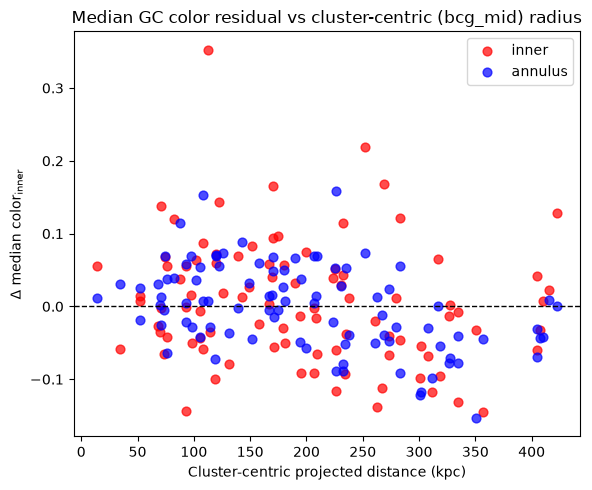

In [63]:
import matplotlib.pyplot as plt

clust_cen_def = "bcg_mid"

x = metrics_df.loc[mask_full, f"R_{clust_cen_def}_kpc"]
y = metrics_df.loc[mask_full, "Delta_median_color_inner"]
y2 = metrics_df.loc[mask_full, "Delta_median_color_annulus"]


plt.figure(figsize=(6,5))
plt.scatter(x, y, s=40, alpha=0.7, c="r", label="inner")
plt.scatter(x, y2, s=40, alpha=0.7, c="b", label="annulus")

plt.axhline(0, color="k", ls="--", lw=1)
plt.xlabel("Cluster-centric projected distance (kpc)")
plt.ylabel(r"$\Delta$ median color$_\mathrm{inner}$")

plt.legend(loc="best")

plt.title(f"Median GC color residual vs cluster-centric ({clust_cen_def}) radius")
plt.tight_layout()
plt.show()


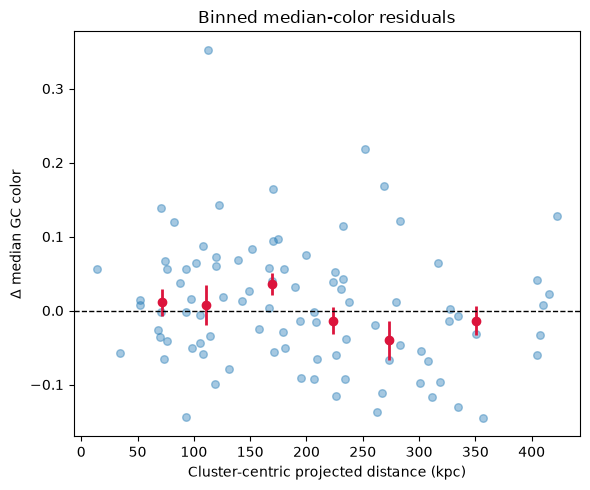

In [64]:
def equal_N_binned_stat(x, y, nbin=6):
    order = np.argsort(x)
    x, y = x[order], y[order]

    bins = np.array_split(np.arange(len(x)), nbin)

    xb, yb, yerr = [], [], []
    for b in bins:
        xb.append(np.median(x[b]))
        yb.append(np.median(y[b]))
        yerr.append(np.std(y[b], ddof=1) / np.sqrt(len(b)))

    return np.array(xb), np.array(yb), np.array(yerr)

xb, yb, yerr = equal_N_binned_stat(x.values, y.values, nbin=6)

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=30, alpha=0.4)
plt.errorbar(xb, yb, yerr=yerr, fmt="o", color="crimson", lw=2)

plt.axhline(0, color="k", ls="--", lw=1)
plt.xlabel("Cluster-centric projected distance (kpc)")
plt.ylabel(r"$\Delta$ median GC color")

plt.title("Binned median-color residuals")
plt.tight_layout()
plt.show()


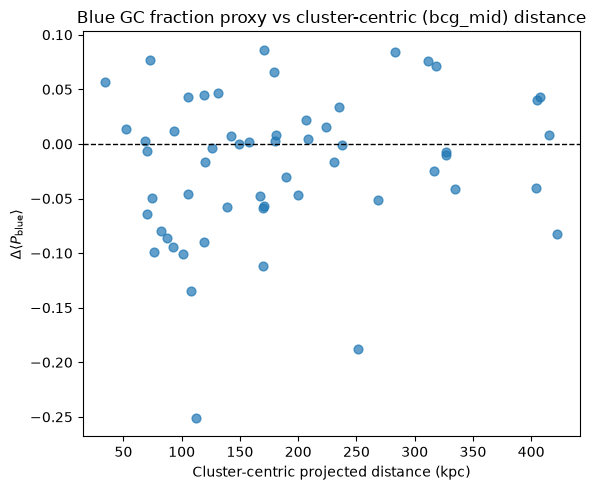

In [65]:
x = metrics_df.loc[mask_gmm, f"R_{clust_cen_def}_kpc"]
y = metrics_df.loc[mask_gmm, "Delta_Pblue_mean_inner"]

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=40, alpha=0.7)

plt.axhline(0, color="k", ls="--", lw=1)
plt.xlabel("Cluster-centric projected distance (kpc)")
plt.ylabel(r"$\Delta\langle P_{\rm blue}\rangle$")

plt.title(f"Blue GC fraction proxy vs cluster-centric ({clust_cen_def}) distance")
plt.tight_layout()
plt.show()


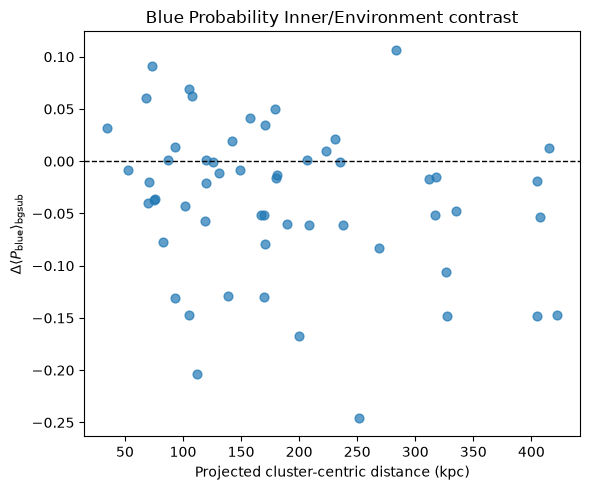

In [66]:
x = metrics_df.loc[mask_ann, f"R_{clust_cen_def}_kpc"]
y = metrics_df.loc[mask_ann, "Pblue_mean_IE_contrast"]

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=40, alpha=0.7)

plt.axhline(0, color="k", ls="--", lw=1)
plt.xlabel("Projected cluster-centric distance (kpc)")
plt.ylabel(r"$\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$")

plt.title("Blue Probability Inner/Environment contrast")
plt.tight_layout()
plt.show()


In [67]:
metrics_df.columns

Index(['name', 'N_inner', 'N_annulus', 'A_ap_geom', 'A_ann_geom', 'A_ap_eff',
       'A_ann_eff', 'A_ap_eff_over_geom', 'A_ann_eff_over_geom',
       'f_cov_ap_geom',
       ...
       'Delta_Pblue_mean_IE_contrast', 'gc_voronoi_density_arcsec2_inv',
       'R_NGC 4874_kpc', 'R_NGC 4889_kpc', 'R_nearBCG_kpc', 'R_bcg_mid_kpc',
       'R_xray_peak_kpc', 'R_sz_peak_kpc', 'R_geom_kpc', 'R_cluster_kpc'],
      dtype='str', length=167)

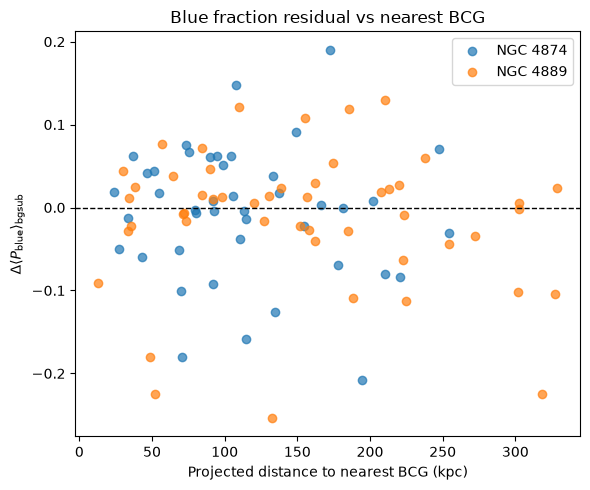

In [68]:
x = metrics_df.loc[mask_full, "R_nearBCG_kpc"]
y = metrics_df.loc[mask_full, "Delta_Pblue_mean_IE_contrast"]
c = metrics_df.loc[mask_full, "nearer_BCG"]

plt.figure(figsize=(6,5))
for bcg in ["NGC 4874", "NGC 4889"]:
    sel = c == bcg
    plt.scatter(x[sel], y[sel], label=bcg, alpha=0.7)

plt.axhline(0, color="k", ls="--", lw=1)
plt.xlabel("Projected distance to nearest BCG (kpc)")
plt.ylabel(r"$\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$")
plt.legend()

plt.title("Blue fraction residual vs nearest BCG")
plt.tight_layout()
plt.show()


## Quantify trends and add uncertainties

Code now moved to `src.stats`

In [69]:
from src.stats import quantify_trend, bootstrap_slope

# Metrics


In [70]:
summary_rows=[]


In [71]:
search_cols(metrics_df,["Delta_"])


Delta_:
['Delta_median_color_inner', 'Delta_median_color_annulus', 'Delta_median_color_IE_contrast', 'Delta_mean_color_inner', 'Delta_mean_color_annulus', 'Delta_mean_color_IE_contrast', 'Delta_Pblue_mean_inner', 'Delta_Pblue_mean_annulus', 'Delta_Pblue_mean_IE_contrast']


<a id="metric-cluster-centric"></a>

## $\Delta \langle P_\mathrm{blue}\rangle_\mathrm{inner}$ vs cluster-centric radius

In [72]:
summary_rows.append(quantify_trend(
    metrics_df,
    xcol=f"R_{clust_cen_def}_kpc",
    ycol="Delta_Pblue_mean_inner",
    mask=mask_full,
    label=f"Δ<P_blue>_inner vs R_mid ({clust_cen_def})",
    test_name="Delta_Pblue_mean_inner_vs_Rmid",
    sample_def=sample_def,
    logger=logger,
))


--- Δ<P_blue>_inner vs R_mid (bcg_mid) ---
N = 93
Spearman ρ = 0.163, p = 1.175e-01
Slope = 7.925e-05 [4.706e-06, 1.547e-04]
Δ(inner−outer) = -0.015




<a id="metric-cluster-centric"></a>

## $\Delta \langle P_\mathrm{blue}\rangle_\mathrm{annulus}$ vs cluster-centric radius

In [73]:
summary_rows.append(quantify_trend(
    metrics_df,
    xcol=f"R_{clust_cen_def}_kpc",
    ycol="Delta_Pblue_mean_annulus",
    mask=mask_full,
    label=f"Δ<P_blue>_annulus vs R_mid ({clust_cen_def})",
    test_name="Delta_Pblue_mean_annulus_vs_Rmid",
    sample_def=sample_def,
    logger=logger,
))


--- Δ<P_blue>_annulus vs R_mid (bcg_mid) ---
N = 93
Spearman ρ = 0.460, p = 3.582e-06
Slope = 2.255e-04 [1.742e-04, 2.798e-04]
Δ(inner−outer) = -0.030




<a id="metric-cluster-centric-bgsub"></a>
## $\Delta \langle P_\mathrm{blue}\rangle_\mathrm{contrast}$ vs cluster-centric radius

In [74]:
summary_rows.append(quantify_trend(
    metrics_df,
    xcol=f"R_{clust_cen_def}_kpc",
    ycol="Delta_Pblue_mean_IE_contrast",
    mask=mask_full,
    label=f"Δ<P_blue>_contrast vs R_mid ({clust_cen_def})",
    test_name="Delta_Pblue_mean_contrast_vs_Rmid",
    sample_def=sample_def,
    logger=logger,
))


--- Δ<P_blue>_contrast vs R_mid (bcg_mid) ---
N = 93
Spearman ρ = -0.173, p = 9.807e-02
Slope = -1.283e-04 [-2.033e-04, -5.994e-05]
Δ(inner−outer) = 0.006




## Define metric labels

In [75]:
metric_labels = {
    "Delta_Pblue_mean_inner": "inner",
    "Delta_Pblue_mean_annulus": "annulus",
    "Delta_Pblue_mean_IE_contrast": "contrast",
}

# use... for metric, label in metric_labels.items():
    

<a id="metric-nearest-bcg"></a>
## Nearest BCG — split by 4874 / 4889

In [76]:
RMAX = 6.0  # arcmin
kpc_per_arcmin = 100.0 * 1000.0 * np.pi / (180.0 * 60.0)
RMAX_kpc = RMAX * kpc_per_arcmin
logger.info(f"Max radius: {RMAX} arcmin = {RMAX_kpc:.2f} kpc\n")

for bcg in ["NGC 4874", "NGC 4889"]:
    for metric, label in metric_labels.items():
        sel = (mask_full) & (metrics_df["nearer_BCG"] == bcg)
    
        summary_rows.append(quantify_trend(
            metrics_df,
            xcol="R_nearBCG_kpc",
            ycol=metric,
            mask=sel,
            rmax=RMAX_kpc,
            label=f"Δ<P_blue>_{label} vs R_nearBCG ({bcg})",
            test_name=f"NearBCG_{bcg}_split",
            sample_def=sample_def,
            logger=logger,
        ))


Max radius: 6.0 arcmin = 174.53 kpc

--- Δ<P_blue>_inner vs R_nearBCG (NGC 4874) ---
N = 35
Spearman ρ = 0.373, p = 2.740e-02
Slope = 4.561e-04 [2.696e-04, 6.324e-04]
Δ(inner−outer) = -0.027


--- Δ<P_blue>_annulus vs R_nearBCG (NGC 4874) ---
N = 35
Spearman ρ = 0.260, p = 1.311e-01
Slope = 2.697e-04 [1.079e-04, 4.331e-04]
Δ(inner−outer) = -0.012


--- Δ<P_blue>_contrast vs R_nearBCG (NGC 4874) ---
N = 35
Spearman ρ = 0.106, p = 5.439e-01
Slope = 1.999e-04 [-9.048e-05, 5.272e-04]
Δ(inner−outer) = -0.012


--- Δ<P_blue>_inner vs R_nearBCG (NGC 4889) ---
N = 30
Spearman ρ = 0.697, p = 1.907e-05
Slope = 1.162e-03 [9.750e-04, 1.363e-03]
Δ(inner−outer) = -0.124


--- Δ<P_blue>_annulus vs R_nearBCG (NGC 4889) ---
N = 30
Spearman ρ = 0.713, p = 9.979e-06
Slope = 1.066e-03 [8.782e-04, 1.230e-03]
Δ(inner−outer) = -0.114


--- Δ<P_blue>_contrast vs R_nearBCG (NGC 4889) ---
N = 30
Spearman ρ = 0.075, p = 6.920e-01
Slope = 7.934e-05 [-1.347e-04, 3.471e-04]
Δ(inner−outer) = -0.020




<a id="metric-nearest-bcg"></a>
## Nearest BCG — both, no split (6 arcmin)

In [77]:
RMAX = 6.0  # arcmin
kpc_per_arcmin = 100.0 * 1000.0 * np.pi / (180.0 * 60.0)
RMAX_kpc = RMAX * kpc_per_arcmin

logger.info(f"{RMAX} arcmin = {RMAX_kpc:.2f} kpc")

bcg_distance_cols = {
    "NGC 4874": "R_NGC 4874_kpc",
    "NGC 4889": "R_NGC 4889_kpc",
}

for bcg, rcol in bcg_distance_cols.items():
    for metric, label in metric_labels.items():

        # Location-based test: use all galaxies in the parent sample,
        # then quantify_trend applies the rmax cut using the BCG-specific distance.
        sel = mask_full & metrics_df[rcol].notna()
    
        logger.info(f"{bcg}: N within {RMAX} arcmin = {(sel & (metrics_df[rcol] <= RMAX_kpc)).sum()}")
    
        summary_rows.append(quantify_trend(
            metrics_df,
            xcol=rcol,
            ycol=metric,
            mask=sel & (metrics_df["name"] != bcg),
            rmax=RMAX_kpc,
            split_value=RMAX_kpc/2,
            label=fr"Δ<P_blue>_{label} vs projected distance from {bcg} ({RMAX} arcmin)",
            test_name=f"NearBCG_{bcg}_6arcmin",
            sample_def=sample_def,
            logger=logger,
        ))


6.0 arcmin = 174.53 kpc
NGC 4874: N within 6.0 arcmin = 41
--- Δ<P_blue>_inner vs projected distance from NGC 4874 (6.0 arcmin) ---
N = 40
Spearman ρ = 0.225, p = 1.636e-01
Slope = 3.149e-04 [9.113e-05, 5.243e-04]
Δ(inner−outer) = -0.028


NGC 4874: N within 6.0 arcmin = 41
--- Δ<P_blue>_annulus vs projected distance from NGC 4874 (6.0 arcmin) ---
N = 40
Spearman ρ = 0.070, p = 6.679e-01
Slope = 1.551e-04 [-6.886e-05, 3.005e-04]
Δ(inner−outer) = -0.014


NGC 4874: N within 6.0 arcmin = 41
--- Δ<P_blue>_contrast vs projected distance from NGC 4874 (6.0 arcmin) ---
N = 40
Spearman ρ = 0.102, p = 5.331e-01
Slope = 1.889e-04 [-1.109e-04, 4.570e-04]
Δ(inner−outer) = -0.013


NGC 4889: N within 6.0 arcmin = 37
--- Δ<P_blue>_inner vs projected distance from NGC 4889 (6.0 arcmin) ---
N = 36
Spearman ρ = 0.655, p = 1.440e-05
Slope = 1.129e-03 [9.525e-04, 1.311e-03]
Δ(inner−outer) = -0.124


NGC 4889: N within 6.0 arcmin = 37
--- Δ<P_blue>_annulus vs projected distance from NGC 4889 (6.0 arcmin)

## Nearest BCG - both, no split (full distance)

In [78]:
# RMAX = 6.0  # arcmin
# kpc_per_arcmin = 100.0 * 1000.0 * np.pi / (180.0 * 60.0)
# RMAX_kpc = RMAX * kpc_per_arcmin

# print(f"{RMAX} arcmin = {RMAX_kpc:.2f} kpc")

bcg_distance_cols = {
    "NGC 4874": "R_NGC 4874_kpc",
    "NGC 4889": "R_NGC 4889_kpc",
}

for bcg, rcol in bcg_distance_cols.items():
    for metric, label in metric_labels.items():
    
        # Location-based test: use all galaxies in the parent sample,
        # then quantify_trend applies the rmax cut using the BCG-specific distance.
        sel = mask_full & metrics_df[rcol].notna() & (metrics_df["name"] != bcg)
    
        # print(f"{bcg}: N within {RMAX} arcmin = {(sel & (metrics_df[rcol] <= RMAX_kpc)).sum()}")
    
        summary_rows.append(quantify_trend(
            metrics_df,
            xcol=rcol,
            ycol=metric,
            mask=sel,
            rmax=None,
            split_value=None,
            label=fr"Δ<P_blue>_{label} vs projected distance from {bcg} (full distance)",
            test_name=f"NearBCG_{bcg}",
            sample_def=sample_def,
            logger=logger,
        ))


--- Δ<P_blue>_inner vs projected distance from NGC 4874 (full distance) ---
N = 92
Spearman ρ = 0.107, p = 3.096e-01
Slope = 4.912e-05 [3.499e-06, 9.267e-05]
Δ(inner−outer) = 0.000


--- Δ<P_blue>_annulus vs projected distance from NGC 4874 (full distance) ---
N = 92
Spearman ρ = 0.335, p = 1.084e-03
Slope = 1.337e-04 [1.037e-04, 1.602e-04]
Δ(inner−outer) = -0.029


--- Δ<P_blue>_contrast vs projected distance from NGC 4874 (full distance) ---
N = 92
Spearman ρ = -0.139, p = 1.853e-01
Slope = -7.241e-05 [-1.287e-04, -2.283e-05]
Δ(inner−outer) = 0.010


--- Δ<P_blue>_inner vs projected distance from NGC 4889 (full distance) ---
N = 92
Spearman ρ = 0.108, p = 3.045e-01
Slope = 1.039e-04 [1.507e-06, 1.994e-04]
Δ(inner−outer) = 0.010


--- Δ<P_blue>_annulus vs projected distance from NGC 4889 (full distance) ---
N = 92
Spearman ρ = 0.289, p = 5.164e-03
Slope = 1.755e-04 [1.129e-04, 2.313e-04]
Δ(inner−outer) = -0.018


--- Δ<P_blue>_contrast vs projected distance from NGC 4889 (full distanc

### Test BCG sample dataframe

Check the data used for the metric calculation - validate the same as used for the plot.

In [190]:
def get_bcg_distance_sample(
    df,
    bcg,
    mask,
    rmax_arcmin=6.0,
    ycol="Delta_Pblue_IE",
):
    """
    Return the exact dataframe used for a BCG-centered distance plot/statistic.
    Galaxies are selected by projected distance from the chosen BCG,
    not by nearest-BCG membership.
    """
    rcol_arcmin = {
        "NGC 4874": "R_NGC 4874_arcmin",
        "NGC 4889": "R_NGC 4889_arcmin",
    }[bcg]

    rcols = ["name", rcol_arcmin, ycol]

    d = df.loc[mask, rcols].copy()
    d = d.rename(columns={rcol_arcmin: "R_arcmin", ycol: "Dfb"})

    d = d.dropna(subset=["R_arcmin", "Dfb"])
    d = d.loc[d["R_arcmin"] <= rmax_arcmin].copy()

    return d.sort_values("R_arcmin").reset_index(drop=True)

In [80]:
d4874 = get_bcg_distance_sample(metrics_df, "NGC 4874", mask_full, ycol="Delta_Pblue_mean_IE_contrast")
d4889 = get_bcg_distance_sample(metrics_df, "NGC 4889", mask_full, ycol="Delta_Pblue_mean_IE_contrast")

print("NGC 4874:", len(d4874))
print(d4874[["name", "R_arcmin", "Dfb"]])

print("NGC 4889:", len(d4889))
print(d4889[["name", "R_arcmin", "Dfb"]])

NGC 4874: 41
                          name  R_arcmin       Dfb
0                     NGC 4874  0.000000  0.130163
1                     NGC 4872  0.822146  0.018219
2                   LEDA 44644  0.928922 -0.049920
3                   LEDA 44651  1.143242 -0.012269
4                     NGC 4871  1.280081  0.061985
5                 LEDA 1821898  1.476202 -0.060042
6                     NGC 4873  1.597434  0.041388
7                   LEDA 44636  1.774010  0.044563
8                   LEDA 44652  1.876871  0.017230
9      2MASX J12592529+2758048  2.350343 -0.051676
10                     IC 3968  2.407093 -0.101136
11                LEDA 1821555  2.426685 -0.180493
12                   Z 160-233  2.531219  0.075936
13                     IC 3998  2.597095  0.066942
14     2MASX J12592536+2756038  2.729744 -0.002830
15                  LEDA 44656  2.766799 -0.007147
16                  LEDA 44594  3.096397  0.060477
17                    NGC 4875  3.152569 -0.092493
18                

## Consolidate for all 'centers' - final result robustness comparison.


In [81]:
metric_labels

{'Delta_Pblue_mean_inner': 'inner',
 'Delta_Pblue_mean_annulus': 'annulus',
 'Delta_Pblue_mean_IE_contrast': 'contrast'}

In [82]:
rcol

'R_NGC 4889_kpc'

In [83]:
summary_rows = []
centers = [
    "xray_peak",
    "sz_peak",
    "geom",
    "bcg_mid",
    "NGC 4874",
    "NGC 4889",
    "nearBCG",
]


for c in centers:
    for metric, label in metric_labels.items():
        ycol=metric
        mask = mask_full
        if c == "nearBCG":
            xcol = "R_nearBCG_kpc"
        elif c == "bcg_mid":
            xcol = "R_bcg_mid_kpc"
        elif c == "NGC 4874":
            xcol = "R_NGC 4874_kpc"
            mask = mask_full & metrics_df[rcol].notna() & (metrics_df["name"] != c)
        elif c == "NGC 4889":
            xcol = "R_NGC 4889_kpc"
            mask = mask_full & metrics_df[rcol].notna() & (metrics_df["name"] != c)
        else:
            xcol = f"R_{c}_kpc"
    
        summary_rows.append(quantify_trend(
            metrics_df,
            xcol=xcol,
            ycol=ycol,
            mask=mask,
            rmax=None,
            label=f"Center = {c} ({label})",
            test_name=f"Center_{c}_{label}",
            sample_def=sample_def,
            logger=logger,
        ))

--- Center = xray_peak (inner) ---
N = 93
Spearman ρ = 0.103, p = 3.254e-01
Slope = 4.865e-05 [-3.474e-06, 1.051e-04]
Δ(inner−outer) = -0.009


--- Center = xray_peak (annulus) ---
N = 93
Spearman ρ = 0.392, p = 1.007e-04
Slope = 1.705e-04 [1.365e-04, 2.058e-04]
Δ(inner−outer) = -0.027


--- Center = xray_peak (contrast) ---
N = 93
Spearman ρ = -0.178, p = 8.858e-02
Slope = -1.078e-04 [-1.737e-04, -5.066e-05]
Δ(inner−outer) = -0.007


--- Center = sz_peak (inner) ---
N = 93
Spearman ρ = 0.141, p = 1.785e-01
Slope = 5.993e-05 [2.739e-06, 1.222e-04]
Δ(inner−outer) = -0.011


--- Center = sz_peak (annulus) ---
N = 93
Spearman ρ = 0.407, p = 5.210e-05
Slope = 1.867e-04 [1.470e-04, 2.276e-04]
Δ(inner−outer) = -0.030


--- Center = sz_peak (contrast) ---
N = 93
Spearman ρ = -0.156, p = 1.365e-01
Slope = -1.086e-04 [-1.796e-04, -4.330e-05]
Δ(inner−outer) = 0.006


--- Center = geom (inner) ---
N = 93
Spearman ρ = 0.126, p = 2.293e-01
Slope = 5.226e-05 [6.288e-07, 1.082e-04]
Δ(inner−outer) = -

## Center assessment

The environmental dependence of GC color mixture is strongest in the local $12–20\ R_e$ population and is robust to the adopted definition of cluster center. Host-centered populations show substantially weaker trends, while the direct inner–environment contrast exhibits little monotonic dependence on cluster position.

In [84]:
summary_df = pd.DataFrame(summary_rows)
summary_df

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,Center_xray_peak_inner,sci_dataset,93,0.103100,3.253901e-01,0.000049,-3.474276e-06,0.000105,-0.009062
1,Center_xray_peak_annulus,sci_dataset,93,0.392274,1.007123e-04,0.000171,1.365431e-04,0.000206,-0.027155
2,Center_xray_peak_contrast,sci_dataset,93,-0.177583,8.857647e-02,-0.000108,-1.737075e-04,-0.000051,-0.006869
3,Center_sz_peak_inner,sci_dataset,93,0.140715,1.785098e-01,0.000060,2.739232e-06,0.000122,-0.011441
4,Center_sz_peak_annulus,sci_dataset,93,0.406762,5.209646e-05,0.000187,1.470490e-04,0.000228,-0.029791
5,Center_sz_peak_contrast,sci_dataset,93,-0.155561,1.364964e-01,-0.000109,-1.796107e-04,-0.000043,0.006233
6,Center_geom_inner,sci_dataset,93,0.125854,2.293382e-01,0.000052,6.287759e-07,0.000108,-0.005543
7,Center_geom_annulus,sci_dataset,93,0.370654,2.548936e-04,0.000163,1.244475e-04,0.000202,-0.032232
8,Center_geom_contrast,sci_dataset,93,-0.140924,1.778595e-01,-0.000092,-1.600785e-04,-0.000031,0.015969
9,Center_bcg_mid_inner,sci_dataset,93,0.163454,1.174608e-01,0.000079,4.705682e-06,0.000155,-0.015045


## Center interpretation

The cluster-centric trend is absent in the raw blue-fraction residual, but appears consistently in the background-corrected quantity. This trend is not removed by excluding the most extreme outlier, and it becomes at least as strong, and in some cases stronger, when the analysis is restricted to galaxies with high geometric support in both the science aperture and the background annulus.

In [85]:
def run_center_comparison(df, centers, metric_labels, mask, rmax=None):

    rows = []

    for c in centers:
        logger.debug(f"Centre: {c}")
        for metric, label in metric_labels.items():
            logger.debug(f"... Metric: {label}")
   
            mask_ex = mask
    
            if c == "nearBCG":
                xcol = "R_nearBCG_kpc"
            elif c == "bcg_mid":
                xcol = "R_bcg_mid_kpc"
            elif c == "NGC 4874" or c == "NGC 4889":
                xcol = f"R_{c}_kpc"
                mask_ex = mask & (metrics_df["name"] != c)
            else:
                xcol = f"R_{c}_kpc"
    
            d = df.loc[mask_ex, [xcol, metric]].dropna()
    
            if rmax is not None:
                d = d[d[xcol] <= rmax]
    
            x = d[xcol].values
            y = d[metric].values
    
            if len(x) < 10:
                continue
    
            logger.debug(f"...... Spearman")
            rho, p = spearmanr(x, y)
            logger.debug(f"...... Slope")
            slope, (lo, hi) = bootstrap_slope(x, y)
    
            rows.append({
                "test_name": c + "_" + label,
                "N": len(x),
                "rho": rho,
                "p": p,
                "slope": slope,
                "slope_lo": lo,
                "slope_hi": hi,
            })

    return pd.DataFrame(rows)

centers = ["xray_peak", "sz_peak", "geom", "bcg_mid", "nearBCG", "NGC 4874", "NGC 4889"]

res=run_center_comparison(
    metrics_df,
    centers=centers,
    metric_labels=metric_labels,
    mask=np.isfinite(metrics_df[metric]),
)


res

[DEBUG] 12:31:33.174 Centre: xray_peak
[DEBUG] 12:31:33.175 ... Metric: inner
[DEBUG] 12:31:33.178 ...... Spearman
[DEBUG] 12:31:33.179 ...... Slope
[DEBUG] 12:31:55.019 ... Metric: annulus
[DEBUG] 12:31:55.023 ...... Spearman
[DEBUG] 12:31:55.025 ...... Slope
[DEBUG] 12:32:17.718 ... Metric: contrast
[DEBUG] 12:32:17.722 ...... Spearman
[DEBUG] 12:32:17.724 ...... Slope
[DEBUG] 12:32:42.234 Centre: sz_peak
[DEBUG] 12:32:42.235 ... Metric: inner
[DEBUG] 12:32:42.238 ...... Spearman
[DEBUG] 12:32:42.241 ...... Slope
[DEBUG] 12:33:03.247 ... Metric: annulus
[DEBUG] 12:33:03.251 ...... Spearman
[DEBUG] 12:33:03.253 ...... Slope
[DEBUG] 12:33:25.589 ... Metric: contrast
[DEBUG] 12:33:25.593 ...... Spearman
[DEBUG] 12:33:25.595 ...... Slope
[DEBUG] 12:33:49.098 Centre: geom
[DEBUG] 12:33:49.099 ... Metric: inner
[DEBUG] 12:33:49.102 ...... Spearman
[DEBUG] 12:33:49.104 ...... Slope
[DEBUG] 12:34:11.411 ... Metric: annulus
[DEBUG] 12:34:11.415 ...... Spearman
[DEBUG] 12:34:11.417 ...... Slop

,test_name,N,rho,p,slope,slope_lo,slope_hi
0,xray_peak_inner,93,0.103100,3.253901e-01,0.000049,-3.474276e-06,0.000105
1,xray_peak_annulus,93,0.392274,1.007123e-04,0.000171,1.365431e-04,0.000206
2,xray_peak_contrast,93,-0.177583,8.857647e-02,-0.000108,-1.737075e-04,-0.000051
3,sz_peak_inner,93,0.140715,1.785098e-01,0.000060,2.739232e-06,0.000122
4,sz_peak_annulus,93,0.406762,5.209646e-05,0.000187,1.470490e-04,0.000228
5,sz_peak_contrast,93,-0.155561,1.364964e-01,-0.000109,-1.796107e-04,-0.000043
6,geom_inner,93,0.125854,2.293382e-01,0.000052,6.287759e-07,0.000108
7,geom_annulus,93,0.370654,2.548936e-04,0.000163,1.244475e-04,0.000202
8,geom_contrast,93,-0.140924,1.778595e-01,-0.000092,-1.600785e-04,-0.000031
9,bcg_mid_inner,93,0.163454,1.174608e-01,0.000079,4.705682e-06,0.000155


In [91]:
search_cols(metrics_df,["N_inn"])


N_inn:
['N_inner', 'N_inner_color', 'N_inner_Pblue', 'Pblue_mean_inner', 'Pblue_mean_inner_exp', 'Delta_Pblue_mean_inner']


In [92]:
sus = metrics_df.nsmallest(5, "Delta_Pblue_mean_annulus")
print(sus[[
    "name",
    "Delta_Pblue_mean_annulus",
    "Pblue_mean_inner", "Pblue_mean_annulus",
    "N_inner", "N_annulus",
    "N_inner_Pblue", "N_annulus_Pblue",
    "f_cov_ap_geom", "f_cov_ann_geom",
    "A_ap_eff_over_geom", "A_ann_eff_over_geom",
    "R_cluster_kpc", "R_bcg_mid_kpc", "R_nearBCG_kpc"
]])

                         name  Delta_Pblue_mean_annulus  Pblue_mean_inner  \
58   SDSS J130008.39+275716.7                 -0.165126          0.488084   
86                   NGC 4886                 -0.133779          0.446900   
49                LEDA 126789                 -0.115914          0.648333   
72    2MASX J13001036+2757332                 -0.106796          0.478576   
169                  NGC 4874                 -0.090682          0.555285   

     Pblue_mean_annulus  N_inner  N_annulus  N_inner_Pblue  N_annulus_Pblue  \
58             0.425686      528       2333            523             2203   
86             0.445992      990       2081            954             1972   
49             0.468301       11         64             11               54   
72             0.477357      101        335             99              329   
169            0.486555     7653       6296           7457             6045   

     f_cov_ap_geom  f_cov_ann_geom  A_ap_eff_over_geom  A_ann_

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _fit_line(x, y):
    """
    Simple linear fit for plotting only.
    Returns xfit, yfit or (None, None) if insufficient data.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if len(x) < 2:
        return None, None

    p = np.polyfit(x, y, 1)
    xfit = np.linspace(np.min(x), np.max(x), 200)
    yfit = np.polyval(p, xfit)
    return xfit, yfit


def plot_delta_pblue_side_by_side(
    df,
    xcol,
    x_label,
    sample_label="full_dataset",
    outlier_names=None,
    annotate_outliers=True,
    highlight_depth=False,
    depth_col="A_ann_eff_over_geom",
    depth_thresh=1.2,
    savepath=None,
    title=None,
    bgsub_ylims=None,
):
    """
    Side-by-side comparison:
      left  = Delta_Pblue_mean vs xcol
      right = Delta_Pblue_IE vs xcol

    Parameters
    ----------
    df : pandas.DataFrame
    xcol : str
        Radius/environment column to plot on x-axis
    x_label : str
        Label for x-axis
    sample_label : str
        Label to show in figure title
    outlier_name : str or None
        Optional galaxy name to highlight
    highlight_depth : bool
        If True, highlight depth-boosted galaxies
    depth_col : str
        Column containing effective/geometric area ratio or similar
    depth_thresh : float
        Threshold above which galaxies are highlighted
    savepath : str or None
        If given, save the figure
    title : str or None
        Optional overall title
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=False)

    panel_info = [
        ("Delta_Pblue_mean", r"$\Delta\langle P_{\rm blue}\rangle$"),
        ("Delta_Pblue_IE", r"$\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$"),
    ]

    for ax, (ycol, ylab) in zip(axes, panel_info):
        plot_df = df[[xcol, ycol, "name"]].copy()

        if highlight_depth and depth_col in df.columns:
            plot_df[depth_col] = df[depth_col].values
            depth_mask = np.isfinite(plot_df[depth_col]) & (plot_df[depth_col] > depth_thresh)
        else:
            depth_mask = np.zeros(len(plot_df), dtype=bool)

        m = np.isfinite(plot_df[xcol]) & np.isfinite(plot_df[ycol])
        plot_df = plot_df.loc[m].copy()
        depth_mask = depth_mask[m]

        # Base points
        ax.scatter(
            plot_df.loc[~depth_mask, xcol],
            plot_df.loc[~depth_mask, ycol],
            s=35,
            alpha=0.8,
            label="Other galaxies" if highlight_depth else None,
        )

        # Depth-boosted points
        if highlight_depth and np.any(depth_mask):
            ax.scatter(
                plot_df.loc[depth_mask, xcol],
                plot_df.loc[depth_mask, ycol],
                s=85,
                marker="o",
                facecolors="none",
                edgecolors="darkorange",
                linewidths=1.5,
                zorder=4,
                label=fr"Depth-weighted (>{depth_thresh})",
            )

        # Optional outlier highlight
        if outlier_names is not None:
            outlier_label = "Outlier" if len(outlier_names)==1 else "Outliers"
            for name in outlier_names:
                out_mask = plot_df["name"] == name
                if np.any(out_mask):
                    ax.scatter(
                        plot_df.loc[out_mask, xcol],
                        plot_df.loc[out_mask, ycol],
                        s=120,
                        marker="s",
                        facecolors="none",
                        edgecolors="crimson",
                        linewidths=1.6,
                        zorder=5,
                        label=outlier_label,
                    )
                    if annotate_outliers:
                        for _, row in plot_df.loc[out_mask].iterrows():
                            ax.annotate(
                                row["name"],
                                (row[xcol], row[ycol]),
                                xytext=(5, 10),
                                textcoords="offset points",
                                fontsize=8,
                            )

        # Linear fit for visual guide only
        xfit, yfit = _fit_line(plot_df[xcol], plot_df[ycol])
        if xfit is not None:
            ax.plot(xfit, yfit, linestyle="--", linewidth=1.5)

        ax.axhline(0.0, linewidth=1.0, alpha=0.6)
        ax.set_xlabel(x_label)
        ax.set_ylabel(ylab)
        ax.set_title(ylab)

    if bgsub_ylims is not None:
        axes[1].set_ylim(bgsub_ylims)
        
    if title is None:
        title = f"{sample_label}: blue-fraction residual trends"

    fig.suptitle(title, y=0.99)

    # One shared legend, if needed
    handles, labels = axes[1].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles, labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.955),
            ncol=1,
            frameon=False
        )
    
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


def plot_delta_pblue_environment_grid(
    df,
    sample_label="full_dataset",
    outlier_names=None,
    annotate_outliers=False,
    highlight_depth=True,
    depth_col="A_ann_eff_over_geom",
    depth_thresh=1.2,
    savepath=None,
    title=None,
    ycol="Delta_Pblue_IE",
    y_label=r"Residual blue-GC fraction, $\Delta f_{\rm b}$",
    ylims=None,
):
    """
    2x2 environmental comparison figure for the background-corrected
    blue-fraction residual.

    Panels:
      (a) R_bcg_mid_arcmin
      (b) log_gc_voronoi_density
      (c) log_tidal_proxy
      (d) R_nearBCG_arcmin
    """

    bcg_names = ["NGC 4874", "NGC 4889"]
    
    panel_specs = [
        ("R_bcg_mid_kpc", "Projected distance from BCG midpoint (kpc)", "(a) Cluster-centric distance"),
        ("log_gc_voronoi_density", r"Local GC density, $\log_{10}(\Sigma_{\rm GC,local})$", "(b) Local GC density"),
        ("log_tidal_proxy", r"BCG tidal proxy, $\log_{10}(\mathrm{tidal\ proxy})$", "(c) BCG Tidal proxy"),
        ("R_nearBCG_kpc", "Projected  distance to nearest BCG (kpc)", "(d) BCG proximity"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
    axes = axes.flatten()

    legend_handles = []
    legend_labels = []

    for ax, (xcol, xlab, ptitle) in zip(axes, panel_specs):
        if xcol not in df.columns:
            ax.set_visible(False)
            continue
    
        cols_needed = [xcol, ycol, "name"]
        plot_df = df[cols_needed].copy()
    
        if highlight_depth and depth_col in df.columns:
            plot_df[depth_col] = df[depth_col].values
            depth_mask = np.isfinite(plot_df[depth_col]) & (plot_df[depth_col] > depth_thresh)
        else:
            depth_mask = np.zeros(len(plot_df), dtype=bool)
    
        # Base finite-data mask
        m = np.isfinite(plot_df[xcol]) & np.isfinite(plot_df[ycol])
    
        # Exclude the BCGs only for the tidal-proxy panel
        if xcol == "log_tidal_proxy":
            m &= ~plot_df["name"].isin(bcg_names)
    
        plot_df = plot_df.loc[m].copy()
        depth_mask = depth_mask[m]

        # Other galaxies
        sc1 = ax.scatter(
            plot_df.loc[~depth_mask, xcol],
            plot_df.loc[~depth_mask, ycol],
            s=35,
            alpha=0.8,
            label="Other galaxies" if highlight_depth else None,
        )

        # Depth-weighted galaxies
        sc2 = None
        if highlight_depth and np.any(depth_mask):
            sc2 = ax.scatter(
                plot_df.loc[depth_mask, xcol],
                plot_df.loc[depth_mask, ycol],
                s=85,
                marker="o",
                facecolors="none",
                edgecolors="darkorange",
                linewidths=1.5,
                zorder=4,
                label=fr"Depth-weighted (>{depth_thresh})",
            )

        # Outliers
        sc3 = None
        if outlier_names is not None:
            outlier_label = "Outlier" if len(outlier_names) == 1 else "Outliers"
            first_outlier = True
            for name in outlier_names:
                out_mask = plot_df["name"] == name
                if np.any(out_mask):
                    sc3 = ax.scatter(
                        plot_df.loc[out_mask, xcol],
                        plot_df.loc[out_mask, ycol],
                        s=120,
                        marker="s",
                        facecolors="none",
                        edgecolors="crimson",
                        linewidths=1.6,
                        zorder=5,
                        label=outlier_label if first_outlier else None,
                    )
                    first_outlier = False

                    if annotate_outliers:
                        for _, row in plot_df.loc[out_mask].iterrows():
                            ax.annotate(
                                row["name"],
                                (row[xcol], row[ycol]),
                                xytext=(5, 8),
                                textcoords="offset points",
                                fontsize=8,
                            )

        # Linear fit
        xfit, yfit = _fit_line(plot_df[xcol], plot_df[ycol])
        if xfit is not None:
            ax.plot(xfit, yfit, linestyle="--", linewidth=1.5)

        ax.axhline(0.0, linewidth=1.0, alpha=0.6)
        ax.set_xlabel(xlab)
        ax.set_ylabel(y_label)
        ax.set_title(ptitle)

        if ylims is not None:
            ax.set_ylim(ylims)

        # Collect legend handles once
        if highlight_depth and not legend_handles:
            legend_handles.append(sc1)
            legend_labels.append("Other galaxies")
            if sc2 is not None:
                legend_handles.append(sc2)
                legend_labels.append(fr"Depth-weighted (>{depth_thresh})")
            if sc3 is not None:
                legend_handles.append(sc3)
                legend_labels.append("Outlier" if len(outlier_names) == 1 else "Outliers")

    if title is None:
        title = f"{sample_label}: environmental trends in blue-fraction residual"

    fig.suptitle(title, y=0.98)

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.945),
            ncol=1,
            frameon=False,
        )

    fig.tight_layout(rect=[0, 0, 1, 0.90])

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()
    

In [ ]:
plot_delta_pblue_side_by_side(
    df=metrics_df,
    xcol="R_bcg_mid_kpc",
    x_label="Distance from BCG midpoint (kpc)",
    sample_label="full_dataset",
    outlier_names=["2MASX J12595670+2755483"],
    annotate_outliers=False,
    highlight_depth=True,
    depth_col="A_ann_eff_over_geom",
    depth_thresh=1.2,
    savepath="../Coma_CSS_color/figures/delta_pblue_vs_Rbcgmid_full.png",
    bgsub_ylims=(-1.4, 0.4),
)

In [ ]:
df_no_out = metrics_df[metrics_df["name"] != "2MASX J12595670+2755483"].copy()

plot_delta_pblue_side_by_side(
    df=df_no_out,
    xcol="R_bcg_mid_kpc",
    x_label="Distance from BCG midpoint (kpc)",
    sample_label="excluding outlier",
    highlight_depth=True,
    depth_col="A_ann_eff_over_geom",
    depth_thresh=1.2,
    savepath="delta_pblue_vs_Rbcgmid_no_outlier.png",
    bgsub_ylims=(-1.4, 0.4),
)

In [ ]:
df_high = metrics_df[metrics_df["coverage_ok_both"] == True].copy()

plot_delta_pblue_side_by_side(
    df=df_high,
    xcol="R_bcg_mid_kpc",
    x_label="Distance from BCG midpoint (kpc)",
    sample_label="high_support",
    outlier_names=["2MASX J12595670+2755483"],
    annotate_outliers=False,
    highlight_depth=True,
    depth_col="A_ann_eff_over_geom",
    depth_thresh=1.2,
    savepath="delta_pblue_vs_Rbcgmid_high_support.png",
    bgsub_ylims=(-1.4, 0.4),
)

## Background correction interpretation

The signal appears only after local background correction because the raw inner-aperture GC mix is partly diluted by the surrounding cluster GC population; subtracting that local environmental component reveals a cluster-centric trend in the galaxy-centered residual metallicity mix.

In the dense Coma core, the surrounding GC population may include a stronger contribution from overlapping halos, intracluster GCs, or environmentally processed populations, which can dilute or mask galaxy-to-galaxy trends in the raw aperture measurement. Local background subtraction partially removes this contribution, revealing an underlying cluster-centric dependence in the galaxy-centered GC metallicity mix.

In summary, the signal appears only after local background correction because the raw inner-aperture GC mix is partly diluted by the surrounding cluster GC population; subtracting that local environmental component reveals a cluster-centric trend in the galaxy-centered residual metallicity mix.

In [93]:
import src.latex as latex

print(latex.__file__)
print(hasattr(latex, "STYLE_CONFIG"))
print([name for name in dir(latex) if "STYLE" in name])

/Users/richard/PycharmProjects/Coma_CSS_color/src/latex.py
True
['STYLE_CONFIG', 'TEST_STYLE_MAP']


In [94]:
%autoreload 2

In [95]:
# helpers for producing AAStex deluxetable

# import style and test configurations
from src.latex import STYLE_CONFIG, TEST_STYLE_MAP


from src.latex import (
    choose_exponent, 
    format_signed, 
    format_p, 
    rescale_slope_bounds, 
    rescale_slope_bounds_for_test,
    get_unit_label_for_test,
    format_pm_latex,
    format_pm_latex_for_test,
)

from src.latex import (
    get_test_format_config, 
    format_test_name,
    split_test_name,
    format_component_name,
)


#--- main dataframe to table orcastrator ---
        
def df_to_deluxetable_adaptive(
    res,
    caption="Add caption here",
    label="tab:add_table_lable",
    col1_head="Test",
    tablecomments=r"Add table comments here",
    include_rows=None,
    slope_ndp=2,
    rho_ndp=2,
    p_ndp=2,
):
    res = res.copy()

    # Standardize first-column name
    if "test_name" not in res.columns:
        if "center" in res.columns:
            res = res.rename(columns={"center": "test_name"})
        else:
            raise KeyError("DataFrame must contain either 'test_name' or 'center'.")

    # Optional row filtering / ordering
    if include_rows is not None:
        missing = [r for r in include_rows if r not in res["test_name"].values]
        if missing:
            raise KeyError(f"Requested rows not found in dataframe: {missing}")

        res = (
            res.set_index("test_name")
               .loc[include_rows]
               .reset_index()
        )
    
    # choose exponent from slope-related columns together
    slope_vals = pd.concat(
        [res["slope"], res["slope_lo"], res["slope_hi"]],
        ignore_index=True
    )
    slope_exp = choose_exponent(slope_vals)

    lines = []
    lines.append(r"\begin{deluxetable}{lcccc}")
    lines.append(rf"\tablecaption{{{caption}")
    lines.append(rf"\label{{{label}}}}}")
    lines.append(r"\tablehead{")
    lines.append(rf"    \colhead{{{col1_head}}} & \colhead{{$N$}} & \colhead{{$\rho$}} & \colhead{{$p$}} & \colhead{{Slope}}")
    lines.append(r"}")
    lines.append(r"\startdata")

    for _, row in res.iterrows():
        test = format_test_name(row["test_name"])
        N = int(row["N"])
        rho = f"${format_signed(row['rho'], rho_ndp)}$"
        p = format_p(row["p"], p_ndp)
        val2, lo2, hi2 = rescale_slope_bounds_for_test(row["slope"], row["slope_lo"], row["slope_hi"], test_name=row["test_name"])
        slope_str = format_pm_latex_for_test(val2, lo2, hi2, test_name=row["test_name"])
        # slope = format_pm_latex(
        #     row["slope"], row["slope_lo"], row["slope_hi"],
        #     exponent=slope_exp, ndp=slope_ndp
        # )
        lines.append(f"{test} & {N} & {rho} & {p} & {slope_str} \\\\")

    lines.append(r"\enddata")
    lines.append(rf"\tablecomments{{{tablecomments}}}")
    lines.append(r"\end{deluxetable}")

    return "\n".join(lines), slope_exp

# --- dedicated three-way table generator

def df_to_deluxetable_threeway(
    res,
    caption="Add caption here",
    label="tab:add_table_label",
    col1_head="Center",
    tablecomments=r"Add table comments here",
    include_centers=None,
    component_order=("inner", "annulus", "contrast"),
    rho_ndp=3,
    p_ndp=3,
):
    res = res.copy()

    # Standardize first-column name
    if "test_name" not in res.columns:
        if "center" in res.columns:
            res = res.rename(columns={"center": "test_name"})
        else:
            raise KeyError(
                "DataFrame must contain either 'test_name' or 'center'."
            )

    # Split combined names into center + population
    parsed = res["test_name"].apply(split_test_name)

    res["center_name"] = [x[0] for x in parsed]
    res["component"] = [x[1] for x in parsed]

    # Optional filtering and ordering
    if include_centers is not None:
        missing = [center for center in include_centers if center not in res["center_name"].values]

        if missing:
            raise KeyError(
                f"Requested centers not found in dataframe: {missing}"
            )

        center_rank = {center: i for i, center in enumerate(include_centers)}
        res = res[res["center_name"].isin(include_centers)].copy()
        res["_center_order"] = (res["center_name"].map(center_rank))

    else:
        res["_center_order"] = 0

    component_rank = {component: i for i, component in enumerate(component_order)}
    res["_component_order"] = (res["component"].map(component_rank))
    res = (res.sort_values(["_center_order", "_component_order"]).reset_index(drop=True))

    lines = []

    lines.append(r"\begin{deluxetable}{llcccc}")
    # lines.append(r"\tabletypesize{\small}")
    lines.append(rf"\tablecaption{{{caption}\label{{{label}}}}}")
    lines.append(r"\tablehead{")
    lines.append(
        rf"    \colhead{{{col1_head}}} & "
        r"\colhead{Region} & "
        r"\colhead{$N$} & "
        r"\colhead{$\rho$} & "
        r"\colhead{$p$} & "
        r"\colhead{Slope} \\"
        r" & & & & & \colhead{$(100\,\mathrm{kpc})^{-1}$} "
    )
    lines.append(r"}")
    lines.append(r"\startdata")

    previous_center = None

    for _, row in res.iterrows():

        center_raw = row["center_name"]
        component = row["component"]

        # Only print center name on first row of each 3-row block
        if center_raw == previous_center:
            center_str = ""
        else:
            center_str = format_test_name(center_raw)

        component_str = format_component_name(component)

        N = int(row["N"])
        rho = f"${format_signed(row['rho'], rho_ndp)}$"
        p = format_p(row["p"], p_ndp)

        # IMPORTANT: formatting style comes from the CENTER,
        # not from e.g. 'bcg_mid_annulus'
        val2, lo2, hi2 = rescale_slope_bounds_for_test(
            row["slope"],
            row["slope_lo"],
            row["slope_hi"],
            test_name=center_raw,
        )

        # slope_str = format_pm_latex_for_test(
        #     val2,
        #     lo2,
        #     hi2,
        #     test_name=center_raw,
        # )
        config = get_test_format_config(center_raw)

        slope_str = format_pm_latex(
            val2,
            lo2,
            hi2,
            exponent=config.get("exponent", 0),
            ndp=config.get("ndp", 2),
            unit_latex="",
        )

        lines.append(
            f"{center_str} & "
            f"{component_str} & "
            f"{N} & "
            f"{rho} & "
            f"{p} & "
            f"{slope_str} \\\\"
        )

        previous_center = center_raw

    lines.append(r"\enddata")
    lines.append(
        rf"\tablecomments{{{tablecomments}}}"
    )
    lines.append(r"\end{deluxetable}")

    return "\n".join(lines)


In [97]:
# include_rows = [
#     "bcg_mid",
#     "xray_peak",
#     "sz_peak",
#     "geom",
#     "NGC 4874",
#     "NGC 4889",
#     "nearBCG"
# ]

# latex_table, slope_exp = df_to_deluxetable_adaptive(
#     res,
#     caption="Comparison of Spearman rank parameters for radial cluster-centric trends of \\Deltafb\\ with varying center definition",
#     label="tab:cluster_center_robustness",
#     col1_head="Center",
#     tablecomments=r"Quoted uncertainties represent $1\sigma$ confidence intervals derived from bootstrap resampling.",
#     slope_ndp=2,
#     rho_ndp=3,
#     p_ndp=3,
#     include_rows=include_rows
# )
# print("Chosen slope exponent:", slope_exp)
# print(latex_table)


In [98]:
include_centers = [
    "bcg_mid",
    "xray_peak",
    "sz_peak",
    "geom",
    "NGC 4874",
    "NGC 4889",
    "nearBCG",
]

latex_table = df_to_deluxetable_threeway(
    res,
    caption=(
        r"Comparison of environmental trends in the inner, "
        r"annular, and inner--annulus (contrast) GC color-mixture diagnostics "
        r"for different definitions of the Coma cluster center"
    ),
    label="tab:cluster_center_robustness_new",
    col1_head="Center",
    tablecomments=(
        r"Spearman $\rho$ values quantify monotonic trends with "
        r"projected distance from the adopted center. "
        r"Quoted slope uncertainties represent $1\sigma$ confidence "
        r"intervals derived from bootstrap resampling. "
        r"The contrast is defined as the inner minus annular "
        r"$\langle P_{\rm blue}\rangle$ diagnostic."
    ),
    include_centers=include_centers,
)

print(latex_table)



\begin{deluxetable}{llcccc}
\tablecaption{Comparison of environmental trends in the inner, annular, and inner--annulus (contrast) GC color-mixture diagnostics for different definitions of the Coma cluster center\label{tab:cluster_center_robustness_new}}
\tablehead{
    \colhead{Center} & \colhead{Region} & \colhead{$N$} & \colhead{$\rho$} & \colhead{$p$} & \colhead{Slope} \\ & & & & & \colhead{$(100\,\mathrm{kpc})^{-1}$} 
}
\startdata
BCG midpoint & Inner & 93 & $+0.163$ & 0.117 & $0.008_{-0.007}^{+0.008}$ \\
 & Annulus & 93 & $+0.460$ & 3.58e-06 & $0.023_{-0.005}^{+0.005}$ \\
 & Contrast & 93 & $-0.173$ & 0.098 & $-0.013_{-0.008}^{+0.007}$ \\
X-ray peak & Inner & 93 & $+0.103$ & 0.325 & $0.005_{-0.005}^{+0.006}$ \\
 & Annulus & 93 & $+0.392$ & 1.01e-04 & $0.017_{-0.003}^{+0.004}$ \\
 & Contrast & 93 & $-0.178$ & 0.089 & $-0.011_{-0.007}^{+0.006}$ \\
SZ peak & Inner & 93 & $+0.141$ & 0.179 & $0.006_{-0.006}^{+0.006}$ \\
 & Annulus & 93 & $+0.407$ & 5.21e-05 & $0.019_{-0.004}^{+0.004}$ 

## Assessment

The GC color-mixture distribution in the Coma core is environmentally structured on scales beyond individual galaxy apertures. The strongest trends are found in the surrounding 12–20$R_e$ populations and are robust to cluster-center definition and foreground/background contamination. Host-centered GC systems show weaker environmental dependence, and their contrast with the surrounding population is comparatively stable. The annular population therefore traces the local Coma GC environment rather than a removable background.

Note also, fitting the luminosity baseline on the actual science sample (as opposed to the full dataset) improves internal consistency without altering the principal environmental result.

## Assess local density environment

Having found a large number of null results for the effects of the cluster-wide environment, we now start to assess the local effects of density.

In [ ]:
# quick column scan

search_cols(metrics_df, ["density", "voronoi", "tidal", "r_", "nearbcg", "cluster"])

In [99]:
ld_rows = []

RMAX = 6.0  # arcmin
kpc_per_arcmin = 100.0 * 1000.0 * np.pi / (180.0 * 60.0)
RMAX_kpc = RMAX * kpc_per_arcmin

logger.info(f"{RMAX} arcmin = {RMAX_kpc:.2f} kpc\n")

for bcg in ["NGC 4874", "NGC 4889"]:
    logger.debug(f"BCG: {bcg}")
    for metric, ml in metric_labels.items():
        logger.debug(f"... Metric: {ml}")

        sel = (
            mask_full
            & (metrics_df["nearer_BCG"] == bcg)
            & (metrics_df["name"] != bcg)
        )
    
        logger.info(f"{bcg} N = {sel.sum()}")
    
        ld_rows.append(quantify_trend(
            metrics_df,
            xcol="R_nearBCG_kpc",
            ycol=metric,
            mask=sel,
            rmax=RMAX_kpc,
            label=f"{metric} vs $R_{{\\rm nearBCG}}$ ({bcg})",
            test_name=f"NearBCG_{bcg}_{ml}",
            sample_def=sample_def,
            logger=logger,
        ))


6.0 arcmin = 174.53 kpc

[DEBUG] 13:42:56.132 BCG: NGC 4874
[DEBUG] 13:42:56.132 ... Metric: inner
NGC 4874 N = 43
--- Delta_Pblue_mean_inner vs $R_{\rm nearBCG}$ (NGC 4874) ---
N = 35
Spearman ρ = 0.373, p = 2.740e-02
Slope = 4.561e-04 [2.696e-04, 6.324e-04]
Δ(inner−outer) = -0.027




[DEBUG] 13:43:12.191 ... Metric: annulus
NGC 4874 N = 43
--- Delta_Pblue_mean_annulus vs $R_{\rm nearBCG}$ (NGC 4874) ---
N = 35
Spearman ρ = 0.260, p = 1.311e-01
Slope = 2.697e-04 [1.079e-04, 4.331e-04]
Δ(inner−outer) = -0.012




[DEBUG] 13:43:30.224 ... Metric: contrast
NGC 4874 N = 43
--- Delta_Pblue_mean_IE_contrast vs $R_{\rm nearBCG}$ (NGC 4874) ---
N = 35
Spearman ρ = 0.106, p = 5.439e-01
Slope = 1.999e-04 [-9.048e-05, 5.272e-04]
Δ(inner−outer) = -0.012




[DEBUG] 13:43:48.189 BCG: NGC 4889
[DEBUG] 13:43:48.189 ... Metric: inner
NGC 4889 N = 50
--- Delta_Pblue_mean_inner vs $R_{\rm nearBCG}$ (NGC 4889) ---
N = 30
Spearman ρ = 0.697, p = 1.907e-05
Slope = 1.162e-03 [9.750e-04, 1.363e-03]
Δ(inner

In [100]:
# basic sanity check - finite counts on column data
targets = [
    "Delta_Pblue_mean_inner",
    "Delta_Pblue_mean_annulus",
    "Delta_Pblue_mean_IE_contrast",
    "gc_voronoi_density_arcsec2_inv",
    "tidal_proxy",
    "R_nearBCG_kpc",
]
for c in targets:
    if c in metrics_df.columns:
        print(c, np.isfinite(metrics_df[c]).sum(), "/", len(metrics_df))

Delta_Pblue_mean_inner 93 / 93
Delta_Pblue_mean_annulus 93 / 93
Delta_Pblue_mean_IE_contrast 93 / 93
gc_voronoi_density_arcsec2_inv 93 / 93
tidal_proxy 93 / 93
R_nearBCG_kpc 93 / 93


In [101]:
# Run trend quantification on environmental data and new version with refitting to MV prior to quantifying

from src.color_metrics import refit_science_residuals

def quantify_environmental_trends(df, 
                                  prime_mask,
                                  sample_def,
                                  xcols = ["R_bcg_mid_kpc",
                                           "gc_voronoi_density_arcsec2_inv",
                                           "log_gc_voronoi_density",
                                           "log_tidal_proxy",
                                           "R_nearBCG_kpc",
                                           ],
                                  metric_labels = {"Delta_Pblue_mean_inner": "inner",
                                                   "Delta_Pblue_mean_annulus": "annulus",
                                                   "Delta_Pblue_mean_IE_contrast": "contrast",
                                                   }, 
                                  add_log_values=True, ):
    logger.debug(f"Quantifying Environmental Trends on sample... {sample_def}")
    logger.info(" ")
    trends = []

    if add_log_values:
        df["log_gc_voronoi_density"] = np.log10(df["gc_voronoi_density_arcsec2_inv"])
        df["log_tidal_proxy"] = np.log10(df["tidal_proxy"])
    
    for xcol in xcols:
                    
        if xcol not in df.columns:
            logger.warning(f"Missing: {xcol}")
            continue
                
        for metric, ml in metric_labels.items():
            logger.debug(f"... Metric: {ml}")
            ycol = metric

        
            if xcol== "log_tidal_proxy":
                bcg_names = ["NGC 4874", "NGC 4889"]
                
                mask = (prime_mask &
                    np.isfinite(df[metric]) &
                    np.isfinite(df["log_tidal_proxy"]) &
                    (~df["name"].isin(bcg_names))
                )
            else:
                mask = (prime_mask &
                    np.isfinite(df[ycol]) &
                    np.isfinite(df[xcol])
                )
        
            logger.info(f"{xcol}: {mask.sum()} valid rows")
        
            trends.append(
                quantify_trend(
                    df,
                    xcol=xcol,
                    ycol=ycol,
                    mask=mask,
                    label=f"{ycol} vs {xcol}",
                    test_name=xcol + "_" + ml,
                    sample_def=sample_def,
                    logger=logger,
                )
            )

    return trends

# For each science or robustness sample, the luminosity baseline is fitted using only the galaxies 
# entering that analysis, and the corresponding residual metrics are then used for the environmental tests.

def quantify_environmental_trends_refit(df,
                                        mask,
                                        metrics,
                                        cols,
                                        cfg,
                                        **kwargs,
                                        ):
    """
    Restrict to the requested sample, refit the luminosity baselines
    on that sample, then quantify environmental trends.
    """

    sample_df = refit_science_residuals(df=df,
                                        mask=mask,
                                        metrics=metrics,
                                        cols=cols,
                                        cfg=cfg,
                                        )

    results = quantify_environmental_trends(sample_df,
                                            mask,
                                            **kwargs,)

    return sample_df, results


In [102]:
# ld_rows.extend(quantify_environmental_trends(metrics_df,
#                                              prime_mask=science_mask,
#                                              sample_def=sample_def,
#                                              xcols = ["gc_voronoi_density_arcsec2_inv",
#                                                       "log_gc_voronoi_density",
#                                                       "log_tidal_proxy",
#                                                       "R_nearBCG_kpc",
#                                                      ]
#                                              )
#               )


science_refit_df, science_rows = quantify_environmental_trends_refit(
    metrics_df_all,
    science_mask,
    metrics=[
        "Pblue_mean_inner",
        "Pblue_mean_annulus",
        "Pblue_mean_IE_contrast",
    ],
    cols=cols,
    cfg=cfg,
    sample_def=sample_def,
)


ld_rows.extend(science_rows)

ld_res_df = pd.DataFrame(ld_rows)

ld_res_df

[DEBUG] 13:45:00.960 Quantifying Environmental Trends on sample... sci_dataset
 
[DEBUG] 13:45:00.963 ... Metric: inner
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_inner vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = 0.163, p = 1.175e-01
Slope = 7.925e-05 [4.706e-06, 1.547e-04]
Δ(inner−outer) = -0.015


[DEBUG] 13:45:15.638 ... Metric: annulus
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_annulus vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = 0.460, p = 3.582e-06
Slope = 2.255e-04 [1.742e-04, 2.798e-04]
Δ(inner−outer) = -0.030


[DEBUG] 13:45:35.936 ... Metric: contrast
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_IE_contrast vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = -0.173, p = 9.807e-02
Slope = -1.283e-04 [-2.033e-04, -5.994e-05]
Δ(inner−outer) = 0.006


[DEBUG] 13:45:57.218 ... Metric: inner
gc_voronoi_density_arcsec2_inv: 93 valid rows
--- Delta_Pblue_mean_inner vs gc_voronoi_density_arcsec2_inv ---
N = 93
Spearman ρ = -0.260, p = 1.170e-02
Slope = -4.568e-01 [-5.794e-01, -3.333e

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,NearBCG_NGC 4874_inner,sci_dataset,35,0.372829,2.739819e-02,0.000456,0.000270,0.000632,-0.027493
1,NearBCG_NGC 4874_annulus,sci_dataset,35,0.260224,1.311091e-01,0.000270,0.000108,0.000433,-0.011515
2,NearBCG_NGC 4874_contrast,sci_dataset,35,0.106162,5.438673e-01,0.000200,-0.000090,0.000527,-0.011535
3,NearBCG_NGC 4889_inner,sci_dataset,30,0.696552,1.907184e-05,0.001162,0.000975,0.001363,-0.123959
4,NearBCG_NGC 4889_annulus,sci_dataset,30,0.712570,9.978907e-06,0.001066,0.000878,0.001230,-0.113634
5,NearBCG_NGC 4889_contrast,sci_dataset,30,0.075417,6.920392e-01,0.000079,-0.000135,0.000347,-0.019560
6,R_bcg_mid_kpc_inner,sci_dataset,93,0.163454,1.174608e-01,0.000079,0.000005,0.000155,-0.015045
7,R_bcg_mid_kpc_annulus,sci_dataset,93,0.459595,3.582258e-06,0.000225,0.000174,0.000280,-0.030340
8,R_bcg_mid_kpc_contrast,sci_dataset,93,-0.172585,9.807082e-02,-0.000128,-0.000203,-0.000060,0.006233
9,gc_voronoi_density_arcsec2_inv_inner,sci_dataset,93,-0.260422,1.169837e-02,-0.456849,-0.579376,-0.333279,0.018187


In [103]:
res2 = res.rename(columns={"center": "test_name"}).copy()

combined_res = pd.concat(
    [
        res2[["test_name", "N", "rho", "p", "slope", "slope_lo", "slope_hi"]],
        ld_res_df[["test_name", "N", "rho", "p", "slope", "slope_lo", "slope_hi"]],
    ],
    ignore_index=True
)

In [104]:
combined_res

,test_name,N,rho,p,slope,slope_lo,slope_hi
0,xray_peak_inner,93,0.103100,3.253901e-01,0.000049,-3.474276e-06,0.000105
1,xray_peak_annulus,93,0.392274,1.007123e-04,0.000171,1.365431e-04,0.000206
2,xray_peak_contrast,93,-0.177583,8.857647e-02,-0.000108,-1.737075e-04,-0.000051
3,sz_peak_inner,93,0.140715,1.785098e-01,0.000060,2.739232e-06,0.000122
4,sz_peak_annulus,93,0.406762,5.209646e-05,0.000187,1.470490e-04,0.000228
5,sz_peak_contrast,93,-0.155561,1.364964e-01,-0.000109,-1.796107e-04,-0.000043
6,geom_inner,93,0.125854,2.293382e-01,0.000052,6.287759e-07,0.000108
7,geom_annulus,93,0.370654,2.548936e-04,0.000163,1.244475e-04,0.000202
8,geom_contrast,93,-0.140924,1.778595e-01,-0.000092,-1.600785e-04,-0.000031
9,bcg_mid_inner,93,0.163454,1.174608e-01,0.000079,4.705682e-06,0.000155


In [ ]:
include_rows = [
    "bcg_mid",
    # "NearBCG_NGC 4874",
    # "NearBCG_NGC 4889",
    "log_gc_voronoi_density",
    "log_tidal_proxy",
]

tablecomments = (
    "THESE NEED TO BE CHECKED. Quoted uncertainties represent $1\\sigma$ confidence intervals derived from bootstrap resampling."
    "Slope for the BCG tidal proxy is quoted per unit of the adopted luminosity-weighted tidal proxy. "
    "This proxy is intended as a relative environmental indicator and is therefore reported in arbitrary "
    "units rather than as a calibrated physical tidal field."
)

latex_table, slope_exp = df_to_deluxetable_adaptive(
    combined_res,
    caption="Comparison of Spearman rank parameters for environmental trends of \\Deltafb.",
    label="tab:envir_comparison",
    tablecomments=tablecomments,
    slope_ndp=2,
    rho_ndp=3,
    p_ndp=3,
    include_rows=include_rows,
)
print("Chosen slope exponent:", slope_exp)
print(latex_table)

In [ ]:
x = metrics_df.loc[mask_full, "log_gc_voronoi_density"]
y = metrics_df.loc[mask_full, "Delta_Pblue_IE"]

plt.figure(figsize=(6,5))
plt.scatter(x, y, s=40, alpha=0.7)

plt.axhline(0, color="k", ls="--", lw=1)
plt.xlabel(r"GC Voronoi density, $\log_{10}(\Sigma_{\rm GC,local})$")
plt.ylabel(r"Residual blue-GC fraction, $\Delta f_{\rm b}$")

plt.title(r"Blue fraction proxy vs. log GC density")
plt.tight_layout()
plt.show()


In [ ]:
plot_delta_pblue_environment_grid(
    df=metrics_df.loc[mask_excl_outlier].copy(),
    sample_label="full_dataset",
    outlier_names=["2MASX J12595670+2755483"],
    annotate_outliers=False,
    highlight_depth=True,
    depth_col="A_ann_eff_over_geom",
    depth_thresh=1.2,
    savepath="../Coma_CSS_color/figures/delta_pblue_environment_grid_full.png",
    ylims=(-0.7, 0.4),
)

## Do environmental plots

In [ ]:
def label_named_galaxies(
    ax,
    plot_df,
    xcol,
    ycol,
    label_names=None,
    name_col="name",
    bcg_names=("NGC 4874", "NGC 4889"),
    mark_bcgs=True,
    label_bcgs=True,
    label_all_bcgs=False,
    xytext=(6, 6),
    fontsize=8,
    bcg_marker="*",
    bcg_size=180,
    bcg_edgecolor="black",
    bcg_facecolor="gold",
    bcg_linewidth=1.1,
    label_bbox=True,
    zorder=10,
):
    """
    Add selected galaxy labels to an existing matplotlib axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to annotate.
    plot_df : pandas.DataFrame
        DataFrame already filtered to match the plotted sample.
    xcol, ycol : str
        Columns used for x and y positions.
    label_names : list-like or None
        Galaxy names to label. If None, no ordinary labels are added.
    name_col : str
        Column containing galaxy names.
    bcg_names : tuple/list
        Names of BCGs to optionally mark and label.
    mark_bcgs : bool
        If True, overlay BCGs with a distinct marker.
    label_bcgs : bool
        If True, label BCGs when they are marked.
    label_all_bcgs : bool
        If True, label BCGs even if not included in label_names.
    xytext : tuple
        Offset in points for text labels.
    fontsize : int
        Label font size.
    """

    if label_names is None:
        label_names = []

    label_names = set(label_names)
    bcg_names = set(bcg_names)

    # Optional BCG overlay marker
    if mark_bcgs:
        bcg_mask = plot_df[name_col].isin(bcg_names)
        if np.any(bcg_mask):
            ax.scatter(
                plot_df.loc[bcg_mask, xcol],
                plot_df.loc[bcg_mask, ycol],
                s=bcg_size,
                marker=bcg_marker,
                facecolors=bcg_facecolor,
                edgecolors=bcg_edgecolor,
                linewidths=bcg_linewidth,
                zorder=zorder,
                label="BCGs",
            )

    # Label requested galaxies, optionally including all BCGs
    names_to_label = set(label_names)
    if label_all_bcgs:
        names_to_label |= bcg_names
    elif label_bcgs:
        names_to_label |= (label_names & bcg_names)

    if not names_to_label:
        return

    text_bbox = None
    if label_bbox:
        text_bbox = dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        )

    for _, row in plot_df.loc[plot_df[name_col].isin(names_to_label)].iterrows():
        ax.annotate(
            row[name_col],
            (row[xcol], row[ycol]),
            xytext=xytext,
            textcoords="offset points",
            fontsize=fontsize,
            ha="left",
            va="bottom",
            bbox=text_bbox,
            zorder=zorder + 1,
        )

In [ ]:
# single panel plot helper

def plot_delta_pblue_single(
    df,
    xcol,
    x_label,
    panel_title=None,
    outlier_names=None,
    annotate_outliers=False,
    highlight_depth=True,
    show_legend=False,
    annotate_stats=True,
    stats_loc="upper left",
    depth_col="A_ann_eff_over_geom",
    depth_thresh=1.2,
    ycol="Delta_Pblue_IE",
    y_label=r"Blue-GC fraction excess, $\Delta f_{\rm b}$",
    ylims=None,
    savepath=None,
    exclude_bcgs_for_tidal=True,
    bcg_names=("NGC 4874", "NGC 4889"),
    figsize=(6.4, 4.8),
    label_fontsize=13,
    title_fontsize=15,
    tick_fontsize=12,
    legend_fontsize=11,
    stats_fontsize=11,
    label_names=None,
    label_fontsize_galaxies=8,
    mark_bcgs=True,
    label_bcgs=True,
    label_all_bcgs=False,
):
    fig, ax = plt.subplots(figsize=figsize)

    cols_needed = [xcol, ycol, "name"]
    plot_df = df[cols_needed].copy()

    if highlight_depth and depth_col in df.columns:
        plot_df[depth_col] = df[depth_col].values
        depth_mask = np.isfinite(plot_df[depth_col]) & (plot_df[depth_col] > depth_thresh)
    else:
        depth_mask = np.zeros(len(plot_df), dtype=bool)

    m = np.isfinite(plot_df[xcol]) & np.isfinite(plot_df[ycol])

    if exclude_bcgs_for_tidal and xcol == "log_tidal_proxy":
        m &= ~plot_df["name"].isin(bcg_names)

    plot_df = plot_df.loc[m].copy()
    depth_mask = depth_mask[m]

    # Other galaxies
    sc1 = ax.scatter(
        plot_df.loc[~depth_mask, xcol],
        plot_df.loc[~depth_mask, ycol],
        s=35,
        alpha=0.8,
        label="Galaxies" if highlight_depth else None,
    )

    # Depth-weighted
    sc2 = None
    if highlight_depth and np.any(depth_mask):
        sc2 = ax.scatter(
            plot_df.loc[depth_mask, xcol],
            plot_df.loc[depth_mask, ycol],
            s=85,
            marker="o",
            facecolors="none",
            edgecolors="darkorange",
            linewidths=1.5,
            zorder=4,
            label=fr"Depth-weighted (>{depth_thresh})",
        )

    # Optional outliers
    sc3 = None
    if outlier_names is not None:
        outlier_label = "Outlier" if len(outlier_names) == 1 else "Outliers"
        first_outlier = True
        for name in outlier_names:
            out_mask = plot_df["name"] == name
            if np.any(out_mask):
                sc3 = ax.scatter(
                    plot_df.loc[out_mask, xcol],
                    plot_df.loc[out_mask, ycol],
                    s=120,
                    marker="s",
                    facecolors="none",
                    edgecolors="crimson",
                    linewidths=1.6,
                    zorder=5,
                    label=outlier_label if first_outlier else None,
                )
                first_outlier = False

                if annotate_outliers:
                    for _, row in plot_df.loc[out_mask].iterrows():
                        ax.annotate(
                            row["name"],
                            (row[xcol], row[ycol]),
                            xytext=(5, 8),
                            textcoords="offset points",
                            fontsize=8,
                        )
                        
    # Optional galaxy labels and BCG markers
    label_named_galaxies(
        ax=ax,
        plot_df=plot_df,
        xcol=xcol,
        ycol=ycol,
        label_names=label_names,
        bcg_names=bcg_names,
        mark_bcgs=mark_bcgs,
        label_bcgs=label_bcgs,
        label_all_bcgs=label_all_bcgs,
        fontsize=label_fontsize_galaxies,
        xytext=(3, 4),
    )

    # Fit line
    xfit, yfit = _fit_line(plot_df[xcol], plot_df[ycol])
    if xfit is not None:
        ax.plot(xfit, yfit, linestyle="--", linewidth=1.5)

    # Stats annotation
    if annotate_stats and len(plot_df) >= 3:
        x = plot_df[xcol].to_numpy(dtype=float)
        y = plot_df[ycol].to_numpy(dtype=float)

        rho, pval = spearmanr(x, y)

        # Simple linear slope for display only
        try:
            slope = np.polyfit(x, y, 1)[0]
        except Exception:
            slope = np.nan

        stats_text = (
            rf"$N={len(plot_df)}$" "\n"
            rf"$\rho={rho:.2f}$" "\n"
            rf"$p={pval:.2g}$" #"\n"rf"$m={slope:.2e}$"
        )

        loc_map = {
            "upper left":  (0.03, 0.97, "left",  "top"),
            "upper right": (0.97, 0.97, "right", "top"),
            "lower left":  (0.03, 0.03, "left",  "bottom"),
            "lower right": (0.97, 0.03, "right", "bottom"),
        }
        x0, y0, ha, va = loc_map.get(stats_loc, loc_map["upper left"])

        ax.text(
            x0, y0, stats_text,
            transform=ax.transAxes,
            ha=ha, va=va,
            fontsize=stats_fontsize,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.7"),
        )

    ax.axhline(0.0, linewidth=1.0, alpha=0.6)
    ax.set_xlabel(x_label, fontsize=label_fontsize)
    ax.set_ylabel(y_label, fontsize=label_fontsize)
    
    if panel_title is not None:
        ax.set_title(panel_title, fontsize=title_fontsize)
    
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)

    if ylims is not None:
        ax.set_ylim(ylims)
        
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
    
        if mark_bcgs and "BCGs" not in labels:
            handles.append(
                Line2D(
                    [0], [0],
                    marker="*",
                    linestyle="None",
                    markersize=12,
                    markerfacecolor="gold",
                    markeredgecolor="black",
                )
            )
            labels.append("BCGs")
    
        if handles:
            ax.legend(handles, labels, loc="lower right", frameon=True, fontsize=legend_fontsize)
        
    fig.tight_layout()

    if savepath is not None:
        fig.savefig(f"../Coma_CSS_color/figures/{savepath}", dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
common_kwargs = dict(
    df=metrics_df.loc[mask_full].copy(),
    highlight_depth=True,
    depth_col="A_ann_eff_over_geom",
    depth_thresh=1.2,
    outlier_names=None,
    annotate_outliers=False,
    ylims=(-0.7, 0.5),   # or (-1.4, 0.4) if you want the full range everywhere
    figsize=(6.4, 4.8),
    label_names=["NGC 4871", "IC 3968", "NGC 4875", "NGC 4894", "LEDA 44692", "IC 4040", "IC 4030", "IC 4033",
                 "NGC 4883", "NGC 4876", "IC 4976", "IC 4051", "IC 3998", "LEDA 44792"],
    label_all_bcgs=True,
)

plot_delta_pblue_single(
    xcol="R_bcg_mid_kpc",
    x_label="Projected distance from BCG midpoint (kpc)",
    panel_title=None,
    savepath="delta_pblue_bcg_mid.png",
    **common_kwargs,
)

plot_delta_pblue_single(
    xcol="log_gc_voronoi_density",
    x_label=r"Local GC density, $\log_{10}(\Sigma_{\rm GC,local}), (\mathrm{dex})$",
    panel_title=None,
    stats_loc="upper right",
    savepath="delta_pblue_local_density.png",
    **common_kwargs,
)

plot_delta_pblue_single(
    xcol="log_tidal_proxy",
    x_label=r"BCG tidal proxy, $\log_{10}(\mathrm{tidal\ proxy})$",
    show_legend=True,
    panel_title=None,
    stats_loc="upper right",
    savepath="delta_pblue_tidal_proxy.png",
    **common_kwargs,
)

plot_delta_pblue_single(
    xcol="R_nearBCG_kpc",
    x_label="Projected distance to nearest BCG (kpc)",
    panel_title=None,
    savepath="delta_pblue_bcg_proximity.png",
    **common_kwargs,
)

## Calculate bottom line statistic

In [ ]:
# set columns to interrogate

dfb_col = "Delta_Pblue_IE"   # or "Dfb"
density_col = "log_gc_voronoi_density"


In [ ]:
import numpy as np
import pandas as pd

df = metrics_df.loc[
    mask_full
    & metrics_df[dfb_col].notna()
    & metrics_df[density_col].notna()
].copy()

q25 = df[density_col].quantile(0.25)
q75 = df[density_col].quantile(0.75)

low = df[df[density_col] <= q25].copy()
high = df[df[density_col] >= q75].copy()

def summarize_dfb_sign(sample, eps=0.0):
    n = len(sample)
    n_def = (sample[dfb_col] < -eps).sum()
    n_exc = (sample[dfb_col] > eps).sum()
    n_neutral = ((sample[dfb_col] >= -eps) & (sample[dfb_col] <= eps)).sum()

    return pd.Series({
        "N": n,
        "N_deficit": n_def,
        "f_deficit": n_def / n,
        "N_excess": n_exc,
        "f_excess": n_exc / n,
        "N_neutral": n_neutral,
        "median_Dfb": sample[dfb_col].median(),
    })

summary = pd.DataFrame({
    "low_density": summarize_dfb_sign(low, eps=0.0),
    "high_density": summarize_dfb_sign(high, eps=0.0),
}).T

summary

In [ ]:
summary_eps = pd.DataFrame({
    "low_density": summarize_dfb_sign(low, eps=0.05),
    "high_density": summarize_dfb_sign(high, eps=0.05),
}).T

summary_eps

In [ ]:
# add uncertainty
from statsmodels.stats.proportion import proportion_confint

def frac_with_ci(k, n, alpha=0.32):  # ~68% interval
    lo, hi = proportion_confint(k, n, alpha=alpha, method="wilson")
    return k / n, lo, hi

for label, sample in [("low", low), ("high", high)]:
    n = len(sample)
    k = (sample[dfb_col] < 0).sum()
    f, lo, hi = frac_with_ci(k, n)
    print(label, k, n, f, lo, hi)


In [ ]:
# compute median contrast

median_low = low[dfb_col].median()
median_high = high[dfb_col].median()
delta_med = median_high - median_low

print("median low density:", median_low)
print("median high density:", median_high)
print("high - low:", delta_med)

In [ ]:
# bootstrap it

rng = np.random.default_rng(42)

def bootstrap_median_difference(low_vals, high_vals, n_boot=10000):
    low_vals = np.asarray(low_vals)
    high_vals = np.asarray(high_vals)

    boot = []
    for _ in range(n_boot):
        low_s = rng.choice(low_vals, size=len(low_vals), replace=True)
        high_s = rng.choice(high_vals, size=len(high_vals), replace=True)
        boot.append(np.median(high_s) - np.median(low_s))

    boot = np.asarray(boot)
    return np.median(boot), np.percentile(boot, [16, 84])

delta_med_boot, (delta_lo, delta_hi) = bootstrap_median_difference(
    low[dfb_col].dropna(),
    high[dfb_col].dropna()
)

delta_med_boot, delta_lo, delta_hi


In [ ]:
############################################################################################################

# Robustness tests

As I'm concerned about the claims I am now able to make, I want to check the robustness of the data and parameters I'm using, specifically:
 - Annular/aperture pointing coverage
 - Magnitude/depth coverage
 - Annular/aperture configuration
 - Error-dominated objects
 - Minimum count

The cells below facilitate these checks.


In [105]:
from src.coverage import coverage_fraction


## Footprint support

**Purpose: Does the Footprint coverage matter?**

In [106]:
metrics_df["f_cov_inner"] = np.nan
metrics_df["f_cov_ann"] = np.nan

rng = np.random.default_rng(0)

for i, row in metrics_df.iterrows():
    Re = row["Re_best_arcsec"]
    if (not np.isfinite(Re)) or (Re <= 0):
        continue  # can't define kRe apertures

    rin_i, rout_i = 0.0, 8.0 * Re
    rin_a, rout_a = 12.0 * Re, 20.0 * Re

    metrics_df.loc[i, "f_cov_inner"] = coverage_fraction(
        row["ra"], row["dec"], rin_i, rout_i, footprint_polys, nsamp=1500
    )
    metrics_df.loc[i, "f_cov_ann"] = coverage_fraction(
        row["ra"], row["dec"], rin_a, rout_a, footprint_polys, nsamp=1500
    )

In [107]:
print("Computed f_cov_inner for:", np.isfinite(metrics_df["f_cov_inner"]).sum(), "/", len(metrics_df))
print("Computed f_cov_ann for:  ", np.isfinite(metrics_df["f_cov_ann"]).sum(), "/", len(metrics_df))

Computed f_cov_inner for: 93 / 93
Computed f_cov_ann for:   93 / 93


In [108]:
# RERUN trend quantification tests on ONLY high coverage galaxies 
robust_rows=[]
sample_def="high_support"

# robust_rows.extend(quantify_environmental_trends(metrics_df,
#                                                  prime_mask=high_support_mask,
#                                                  sample_def=sample_def,
#                                                  xcols = ["R_bcg_mid_kpc",
#                                                           # "gc_voronoi_density_arcsec2_inv",
#                                                           "log_gc_voronoi_density",
#                                                           "log_tidal_proxy",
#                                                           "R_nearBCG_kpc",
#                                                          ]
#                                                  )
#                   )


high_support_df, high_support_rows = quantify_environmental_trends_refit(
    metrics_df_all,
    high_support_mask,
    metrics=[
        "Pblue_mean_inner",
        "Pblue_mean_annulus",
        "Pblue_mean_IE_contrast",
    ],
    cols=cols,
    cfg=cfg,
    sample_def=sample_def,
)

robust_rows.extend(high_support_rows)
# ld_res_df = pd.DataFrame(ld_rows)

# ld_res_df

[DEBUG] 13:53:44.088 Quantifying Environmental Trends on sample... high_support
 
[DEBUG] 13:53:44.091 ... Metric: inner
R_bcg_mid_kpc: 78 valid rows
--- Delta_Pblue_mean_inner vs R_bcg_mid_kpc ---
N = 78
Spearman ρ = 0.127, p = 2.675e-01
Slope = 5.385e-05 [-4.528e-05, 1.611e-04]
Δ(inner−outer) = -0.013


[DEBUG] 13:54:00.532 ... Metric: annulus
R_bcg_mid_kpc: 78 valid rows
--- Delta_Pblue_mean_annulus vs R_bcg_mid_kpc ---
N = 78
Spearman ρ = 0.463, p = 1.973e-05
Slope = 2.740e-04 [2.129e-04, 3.467e-04]
Δ(inner−outer) = -0.040


[DEBUG] 13:54:17.775 ... Metric: contrast
R_bcg_mid_kpc: 78 valid rows
--- Delta_Pblue_mean_IE_contrast vs R_bcg_mid_kpc ---
N = 78
Spearman ρ = -0.181, p = 1.134e-01
Slope = -2.161e-04 [-3.013e-04, -1.208e-04]
Δ(inner−outer) = -0.002


[DEBUG] 13:54:35.972 ... Metric: inner
gc_voronoi_density_arcsec2_inv: 78 valid rows
--- Delta_Pblue_mean_inner vs gc_voronoi_density_arcsec2_inv ---
N = 78
Spearman ρ = -0.299, p = 7.926e-03
Slope = -4.890e-01 [-6.073e-01, -3.6

In [111]:
rob_tmp_df = pd.DataFrame(robust_rows)

rob_tmp_df.loc[~rob_tmp_df["test_name"].str.contains("arcsec2", na=False)]

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,high_support,78,0.127101,2.674713e-01,0.000054,-0.000045,0.000161,-0.012753
1,R_bcg_mid_kpc_annulus,high_support,78,0.462967,1.972502e-05,0.000274,0.000213,0.000347,-0.040313
2,R_bcg_mid_kpc_contrast,high_support,78,-0.180667,1.134428e-01,-0.000216,-0.000301,-0.000121,-0.001773
6,log_gc_voronoi_density_inner,high_support,78,-0.298575,7.925503e-03,-0.048080,-0.065265,-0.028958,0.017723
7,log_gc_voronoi_density_annulus,high_support,78,-0.655509,7.388828e-11,-0.078696,-0.088960,-0.068699,0.045244
8,log_gc_voronoi_density_contrast,high_support,78,0.194578,8.780808e-02,0.028884,0.012112,0.046095,-0.017594
9,log_tidal_proxy_inner,high_support,78,-0.330644,3.109881e-03,-0.032385,-0.040915,-0.023237,0.022256
10,log_tidal_proxy_annulus,high_support,78,-0.561552,8.858785e-08,-0.040698,-0.049366,-0.033012,0.040510
11,log_tidal_proxy_contrast,high_support,78,0.092528,4.204044e-01,0.009353,-0.004592,0.022553,-0.015129
12,R_nearBCG_kpc_inner,high_support,78,0.344225,2.029185e-03,0.000238,0.000075,0.000400,-0.022256


The above results show that restricting the sample to systems with high support coverage i.e., valid $R_{\rm eff}$ and both aperture and annulus effective area coverage > 0.8) leaves the environmental trends intact and, in several cases, strengthens them. The clearest dependence remains that with local GC density, while the BCG tidal proxy and nearest-BCG distance also retain significant correlations of the expected sign. This indicates that the observed variation in $\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$ is not driven by poorly supported regions of the footprint, but reflects a genuine environmental modulation of the globular cluster color mixture.

In [ ]:
############################################################################################################

## Bright / common depth limit

Perform a uniform depth / magnitude-cut test which checks completeness / depth effects. This is now based on the Peng+2011 magnitude cut which, in our (Vega) mag system works out to be 26.07 mag. See previous notebooks, especially [07_ext_background_sensitivity](07_ext_background_sensitivity.ipynb) for a more detailed analysis.


In [112]:
data["mag_814"].describe()
mag_cut = 26.07
data_bright = data[data["mag_814"] < mag_cut].copy()

In [113]:
centers = {
    "xray_peak": ClusterCenter("xray_peak", 194.9271, 27.9706),
    "sz_peak":   ClusterCenter("sz_peak",   194.9471, 27.9311),
    "geom":      ClusterCenter("geom",      194.9350, 27.9125),
}

metrics_df_bright = run_pipeline_no_ownership(
    data=data_bright,
    gals_df=gals_df,
    cols=cols,
    cfg=cfg,
    footprint_df=footprint_df,
    bcg1=bcg_4874, bcg2=bcg_4889,
    centers=centers,
    cluster_center_key="xray_peak",   # <- pick which defines R_cluster_arcmin
    add_voronoi_density=True,
)

# metrics_df = run_pipeline_no_ownership(data, gals_df, cols, cfg, bcg_4874, bcg_4889, add_voronoi_density=True)  
metrics_df_bright.to_csv("../Coma_CSS_color/data/metrics_df_bright_recal_pie.csv", index=False)
metrics_df_bright.head()

[DEBUG] 14:06:42.905 Building galaxy metric table.


Galaxies:   0%|          | 0/174 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [114]:
metrics_df_bright = pd.read_csv("../Coma_CSS_color/data/metrics_df_bright_recal_pie.csv")

In [115]:
metrics_df_bright_all = metrics_df_bright.copy()


In [116]:
# full bright results
metrics_df_bright = metrics_df_bright_all.copy()
sample_def = "bright_cut"
len(metrics_df_bright)

# science_mask_bright = (
#     metrics_df_bright_all["Pblue_inner_meets_min"]
#     & metrics_df_bright_all["good_ap_area"]
#     & metrics_df_bright_all["good_ann_area"]
#     & metrics_df_bright_all["Pblue_annulus_nonzero"]
#     & np.isfinite(metrics_df_bright_all["Delta_Pblue_mean_IE_contrast"])
# )

science_mask_bright = (
    metrics_df_bright_all["Pblue_inner_meets_min"]
    & metrics_df_bright_all["good_ap_area"]
    & metrics_df_bright_all["good_ann_area"]
    & metrics_df_bright_all["Pblue_annulus_nonzero"]
    & np.isfinite(metrics_df_bright_all["Pblue_mean_IE_contrast"])
    & np.isfinite(metrics_df_bright_all[cols.gal_MV])
)

science_ids = metrics_df_bright_all.index[science_mask_bright]
metrics_df_bright = metrics_df_bright_all.loc[science_mask_bright]
logger.debug(f"Revised SCI sample N ={len(science_ids)}")

logger.info(f"Using dataset: {sample_def} with {len(metrics_df_bright)} rows.")


[DEBUG] 14:07:02.593 Revised SCI sample N =90
Using dataset: bright_cut with 90 rows.


In [117]:
# add_noselfsep4BCGs(metrics_df_bright, f"../Coma_CSS_color/data/metrics_df_bright_recal.csv")


In [118]:
arcmin_cols = metrics_df_bright.columns[metrics_df_bright.columns.str.contains("arcmin", case=False, na=False)].tolist()
arcmin_cols
metrics_df_bright = add_arcmin_to_kpc_columns(metrics_df_bright, arcmin_cols, distance_mpc=100.0, inplace=False)


In [119]:
metrics_df_bright["f_cov_inner"] = np.nan
metrics_df_bright["f_cov_ann"] = np.nan

rng = np.random.default_rng(0)

for i, row in metrics_df_bright.iterrows():
    Re = row["Re_best_arcsec"]
    if (not np.isfinite(Re)) or (Re <= 0):
        continue  # can't define kRe apertures

    rin_i, rout_i = 0.0, 8.0 * Re
    rin_a, rout_a = 12.0 * Re, 20.0 * Re

    metrics_df_bright.loc[i, "f_cov_inner"] = coverage_fraction(
        row["ra"], row["dec"], rin_i, rout_i, footprint_polys, nsamp=1500
    )
    metrics_df_bright.loc[i, "f_cov_ann"] = coverage_fraction(
        row["ra"], row["dec"], rin_a, rout_a, footprint_polys, nsamp=1500
    )

In [120]:
# RERUN trend quantification on density data

# robust_rows.extend(quantify_environmental_trends(metrics_df_bright,
#                                                  prime_mask=science_mask_bright,
#                                                  sample_def=sample_def,
#                                                  xcols = ["R_bcg_mid_kpc",
#                                                           # "gc_voronoi_density_arcsec2_inv",
#                                                           "log_gc_voronoi_density",
#                                                           "log_tidal_proxy",
#                                                           "R_nearBCG_kpc",
#                                                          ]
#                                                  )
#                   )

bright_df, bright_rows = quantify_environmental_trends_refit(
    metrics_df_bright,
    science_mask_bright,
    metrics=[
        "Pblue_mean_inner",
        "Pblue_mean_annulus",
        "Pblue_mean_IE_contrast",
    ],
    cols=cols,
    cfg=cfg,
    sample_def=sample_def,
)

robust_rows.extend(bright_rows)

robust_rows_df = pd.DataFrame(robust_rows)


[DEBUG] 14:07:37.845 Quantifying Environmental Trends on sample... bright_cut
 
[DEBUG] 14:07:37.848 ... Metric: inner
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_inner vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = 0.137, p = 1.987e-01
Slope = 6.491e-05 [7.688e-06, 1.317e-04]
Δ(inner−outer) = -0.020


[DEBUG] 14:07:53.367 ... Metric: annulus
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_annulus vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = 0.410, p = 5.866e-05
Slope = 2.062e-04 [1.634e-04, 2.517e-04]
Δ(inner−outer) = -0.038


[DEBUG] 14:08:11.217 ... Metric: contrast
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_IE_contrast vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = -0.171, p = 1.081e-01
Slope = -1.333e-04 [-2.151e-04, -5.091e-05]
Δ(inner−outer) = 0.020


[DEBUG] 14:08:30.034 ... Metric: inner
gc_voronoi_density_arcsec2_inv: 90 valid rows
--- Delta_Pblue_mean_inner vs gc_voronoi_density_arcsec2_inv ---
N = 90
Spearman ρ = -0.240, p = 2.264e-02
Slope = -4.632e-01 [-5.843e-01, -3.128e-

In [121]:
robust_rows_df

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,high_support,78,0.127101,2.674713e-01,0.000054,-0.000045,0.000161,-0.012753
1,R_bcg_mid_kpc_annulus,high_support,78,0.462967,1.972502e-05,0.000274,0.000213,0.000347,-0.040313
2,R_bcg_mid_kpc_contrast,high_support,78,-0.180667,1.134428e-01,-0.000216,-0.000301,-0.000121,-0.001773
3,gc_voronoi_density_arcsec2_inv_inner,high_support,78,-0.298575,7.925503e-03,-0.489021,-0.607342,-0.364248,0.017723
4,gc_voronoi_density_arcsec2_inv_annulus,high_support,78,-0.655509,7.388828e-11,-0.699961,-0.783826,-0.607619,0.045244
5,gc_voronoi_density_arcsec2_inv_contrast,high_support,78,0.194578,8.780808e-02,0.172989,0.051510,0.293044,-0.017594
6,log_gc_voronoi_density_inner,high_support,78,-0.298575,7.925503e-03,-0.048080,-0.065265,-0.028958,0.017723
7,log_gc_voronoi_density_annulus,high_support,78,-0.655509,7.388828e-11,-0.078696,-0.088960,-0.068699,0.045244
8,log_gc_voronoi_density_contrast,high_support,78,0.194578,8.780808e-02,0.028884,0.012112,0.046095,-0.017594
9,log_tidal_proxy_inner,high_support,78,-0.330644,3.109881e-03,-0.032385,-0.040915,-0.023237,0.022256


**Summary**

The dominant environmental signal is consistently associated with the $12–20\ R_e$ surrounding population. This remains true when restricting to galaxies with high footprint support and when imposing a common bright CSS magnitude limit. Host-centered trends are weaker, while the direct inner–annulus contrast is generally small.

## Independent FG/BG subtraction (*NEW*)

From our external calibration, we currently have a CSS surface density of 

$$ \Sigma_{\rm bg}=2.8~{\rm arcmin}^{-2} $$

with

$$ P_{\rm BG}=0.535230 $$

and these are tied to the Peng-matched candidate selection, i.e. approximately $m_{814}<26.07$ As this now correlates with the cut we made for our 'bright-cut' above, we're going to add in this additional noise subtract to see how it affects the metric.

In [122]:
def subtract_external_component(
    sum_pblue,
    n_obs,
    n_ext,
    p_ext,
    min_remaining=0.0,
):
    """
    Subtract an external population with expected count n_ext
    and mean Pblue p_ext from an observed population.

    Returns corrected mean Pblue and corrected count.
    """
    n_corr = n_obs - n_ext

    p_corr = np.where(
        n_corr > min_remaining,
        (sum_pblue - n_ext * p_ext) / n_corr,
        np.nan,
    )

    return p_corr, n_corr


Add the expected number of true foreground/background contaminants to each effective area.

In [123]:
PENG_BG_DENSITY = 2.8  # arcmin^-2 ... SIGMA_BG

metrics_df_bright["N_bg_ext_inner"] = (
    metrics_df_bright["A_ap_eff"] / 3600.0
) * PENG_BG_DENSITY

metrics_df_bright["N_bg_ext_annulus"] = (
    metrics_df_bright["A_ann_eff"] / 3600.0
) * PENG_BG_DENSITY


In [124]:
search_cols(metrics_df_bright, ["N_"])


N_:
['N_inner', 'N_annulus', 'A_ann_geom', 'A_ann_eff', 'A_ann_eff_over_geom', 'f_cov_ann_geom', 'cov_ann_depthw', 'good_ann_area', 'N_inner_color', 'N_annulus_color', 'median_color', 'N_inner_Pblue', 'N_annulus_Pblue', 'Pblue_mean_inner', 'Pblue_mean_annulus', 'median_color_inner', 'median_color_annulus', 'mean_color_inner', 'mean_color_annulus', 'Pblue_mean_IE_contrast', 'mean_color_IE_contrast', 'median_color_IE_contrast', 'min_gc_for_Pblue', 'Pblue_mean_err', 'n_gcs_prior', 'n_gcs_red_prior', 'n_gcs_blue_prior', 'median_color_inner_exp', 'Delta_median_color_inner', 'median_color_annulus_exp', 'Delta_median_color_annulus', 'median_color_IE_contrast_exp', 'Delta_median_color_IE_contrast', 'mean_color_inner_exp', 'Delta_mean_color_inner', 'mean_color_annulus_exp', 'Delta_mean_color_annulus', 'mean_color_IE_contrast_exp', 'Delta_mean_color_IE_contrast', 'Pblue_mean_inner_exp', 'Delta_Pblue_mean_inner', 'Pblue_mean_annulus_exp', 'Delta_Pblue_mean_annulus', 'Pblue_mean_IE_contrast_exp',

Now build the corrected Pblue means and contrast

In [125]:
P_BG = 0.535230

metrics_df_bright["Pblue_mean_inner_fgsub"] = (
    metrics_df_bright["Pblue_mean_inner"] * metrics_df_bright["N_inner_Pblue"]
    - metrics_df_bright["N_bg_ext_inner"] * P_BG
) / (
    metrics_df_bright["N_inner_Pblue"]
    - metrics_df_bright["N_bg_ext_inner"]
)

metrics_df_bright["Pblue_mean_annulus_fgsub"] = (
    metrics_df_bright["Pblue_mean_annulus"] * metrics_df_bright["N_annulus_Pblue"]
    - metrics_df_bright["N_bg_ext_annulus"] * P_BG
) / (
    metrics_df_bright["N_annulus_Pblue"]
    - metrics_df_bright["N_bg_ext_annulus"]
)

metrics_df_bright["Pblue_mean_IE_contrast_fgsub"] = (
    metrics_df_bright["Pblue_mean_inner_fgsub"]
    - metrics_df_bright["Pblue_mean_annulus_fgsub"]
)

Also save the corrected counts...

In [126]:
metrics_df_bright["N_inner_fgsub"] = (
    metrics_df_bright["N_inner_Pblue"]
    - metrics_df_bright["N_bg_ext_inner"]
)

metrics_df_bright["N_annulus_fgsub"] = (
    metrics_df_bright["N_annulus_Pblue"]
    - metrics_df_bright["N_bg_ext_annulus"]
)


In [127]:
print("Bright-cut sample:", len(metrics_df_bright))

print(
    "Inner fgsub <= 0:",
    (metrics_df_bright["N_inner_fgsub"] <= 0).sum()
)

print(
    "Annulus fgsub <= 0:",
    (metrics_df_bright["N_annulus_fgsub"] <= 0).sum()
)

print(
    metrics_df_bright[
        ["N_inner_fgsub", "N_annulus_fgsub"]
    ]
    .describe()
    .to_string(float_format=lambda x: f"{x:.3f}")
)

Bright-cut sample: 90
Inner fgsub <= 0: 0
Annulus fgsub <= 0: 0
       N_inner_fgsub  N_annulus_fgsub
count         90.000           90.000
mean         275.145          349.719
std          902.157          664.264
min            8.501            1.446
25%           17.340           36.852
50%           38.821          106.693
75%           92.906          281.185
max         7028.911         4502.262


This confirms fg/bg-only subtraction is numerically benign for the bright-cut sample.

We can surmise this because...

- all 90 galaxies survive,
- no corrected inner or annulus count goes non-positive,
- the minimum corrected counts are still 8.5 inner and 1.45 annulus,
- the bulk of the sample is nowhere near instability.

So unlike the full ICGC subtraction (which comes in a minute), there is no reason to introduce a new count threshold here. We can simply use the same 90 galaxies and treat this as a clean robustness layer.

**Add residuals (Huber luminosity-detrend)**

In [128]:
detrend_metrics = [
    "Pblue_mean_inner_fgsub", "Pblue_mean_annulus_fgsub", "Pblue_mean_IE_contrast_fgsub",
]

metrics_df_bright = add_residuals(metrics_df_bright, cols, cfg, detrend_metrics, logger)


[DEBUG] 14:12:05.573 Adding residuals


In [168]:
sample_def = "bright_cut_fgsub"
background_correction = []
# background_correction.extend(quantify_environmental_trends(metrics_df_bright,
#                                                  prime_mask=science_mask_bright,
#                                                  sample_def=sample_def,
#                                                  xcols = ["R_bcg_mid_kpc",
#                                                           # "gc_voronoi_density_arcsec2_inv",
#                                                           "log_gc_voronoi_density",
#                                                           "log_tidal_proxy",
#                                                           "R_nearBCG_kpc",
#                                                          ],
#                                                  metric_labels = {"Delta_Pblue_mean_inner_fgsub": "inner",
#                                                                   "Delta_Pblue_mean_annulus_fgsub": "annulus",
#                                                                   "Delta_Pblue_mean_IE_contrast_fgsub": "contrast",
#                                                    }, 
#                                                  )
#                   )

bright_fgsub_df, bright_fgsub_rows = quantify_environmental_trends_refit(
    metrics_df_bright,
    science_mask_bright,
    metrics=[
        "Pblue_mean_inner_fgsub",
        "Pblue_mean_annulus_fgsub",
        "Pblue_mean_IE_contrast_fgsub",
    ],
    metric_labels = {"Delta_Pblue_mean_inner_fgsub": "inner",
                     "Delta_Pblue_mean_annulus_fgsub": "annulus",
                     "Delta_Pblue_mean_IE_contrast_fgsub": "contrast",
                    },
    cols=cols,
    cfg=cfg,
    sample_def=sample_def,
)

background_correction.extend(bright_fgsub_rows)

background_correction_df = pd.DataFrame(background_correction)

background_correction_df

[DEBUG] 15:53:30.194 Quantifying Environmental Trends on sample... bright_cut_fgsub
 
[DEBUG] 15:53:30.196 ... Metric: inner
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_inner_fgsub vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = 0.155, p = 1.442e-01
Slope = 7.708e-05 [1.655e-05, 1.501e-04]
Δ(inner−outer) = -0.020


[DEBUG] 15:53:45.395 ... Metric: annulus
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_annulus_fgsub vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = 0.435, p = 1.818e-05
Slope = 2.460e-04 [1.986e-04, 2.983e-04]
Δ(inner−outer) = -0.048


[DEBUG] 15:54:03.439 ... Metric: contrast
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_IE_contrast_fgsub vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = -0.196, p = 6.480e-02
Slope = -1.659e-04 [-2.531e-04, -7.324e-05]
Δ(inner−outer) = 0.020


[DEBUG] 15:54:21.862 ... Metric: inner
gc_voronoi_density_arcsec2_inv: 90 valid rows
--- Delta_Pblue_mean_inner_fgsub vs gc_voronoi_density_arcsec2_inv ---
N = 90
Spearman ρ = -0.256, p = 1.489e-02
Slope = -4

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,bright_cut_fgsub,90,0.155171,1.441886e-01,0.000077,0.000017,0.000150,-0.020352
1,R_bcg_mid_kpc_annulus,bright_cut_fgsub,90,0.435157,1.817798e-05,0.000246,0.000199,0.000298,-0.048191
2,R_bcg_mid_kpc_contrast,bright_cut_fgsub,90,-0.195506,6.479551e-02,-0.000166,-0.000253,-0.000073,0.020158
3,gc_voronoi_density_arcsec2_inv_inner,bright_cut_fgsub,90,-0.255958,1.489207e-02,-0.495693,-0.625993,-0.338779,0.030385
4,gc_voronoi_density_arcsec2_inv_annulus,bright_cut_fgsub,90,-0.613467,1.290248e-10,-0.779803,-0.894655,-0.656121,0.053121
5,gc_voronoi_density_arcsec2_inv_contrast,bright_cut_fgsub,90,0.249735,1.760530e-02,0.265559,0.132804,0.413897,-0.020158
6,log_gc_voronoi_density_inner,bright_cut_fgsub,90,-0.255958,1.489207e-02,-0.040369,-0.057627,-0.022949,0.030385
7,log_gc_voronoi_density_annulus,bright_cut_fgsub,90,-0.613467,1.290248e-10,-0.081105,-0.088976,-0.072193,0.053121
8,log_gc_voronoi_density_contrast,bright_cut_fgsub,90,0.249735,1.760530e-02,0.037308,0.021259,0.054899,-0.020158
9,log_tidal_proxy_inner,bright_cut_fgsub,88,-0.304973,3.862685e-03,-0.028884,-0.035612,-0.021301,0.013073


Subtracting the independently calibrated foreground/background population does not weaken the main environmental trends. The annular GC population remains the dominant tracer of local environment, while the host-centered population shows weaker but significant trends and the inner–annulus contrast remains generally weak except for a modest local-density dependence.


In [ ]:
############################################################################################################

## Aperture variation

In [132]:
configs = [
    (6, 9, 15, "small_ap"),
    (10, 15, 25, "large_ap"),
    (8, 12, 20, "fiducial"),
]


In [ ]:
configs = [
    (6, 9, 15, "small_ap"),
    (10, 15, 25, "large_ap"),
    (8, 12, 20, "fiducial"),
]

def get_aper_df(rap, rin, rout):

    cfg.aperture_Re = rap
    cfg.annulus_inner_Re = rin
    cfg.annulus_outer_Re = rout

    alt_centers = {
        "xray_peak": ClusterCenter("xray_peak", 194.9271, 27.9706),
        "sz_peak":   ClusterCenter("sz_peak",   194.9471, 27.9311),
        "geom":      ClusterCenter("geom",      194.9350, 27.9125),
    }
    
    df_tmp = run_pipeline_no_ownership(
        data=data,
        gals_df=gals_df,
        cols=cols,
        cfg=cfg,
        footprint_df=footprint_df,
        bcg1=bcg_4874, bcg2=bcg_4889,
        centers=alt_centers,
        cluster_center_key="xray_peak",   # <- pick which defines R_cluster_arcmin
        add_voronoi_density=True,
    )

    return df_tmp

aper_dfs = {}

for rap, rin, rout, key in configs:
    aper_dfs[key] = get_aper_df(rap, rin, rout)
    aper_dfs[key].to_csv(f"../Coma_CSS_color/data/metrics_df_aper_{key}_recal_pie.csv", index=False)



In [133]:
configs

[(6, 9, 15, 'small_ap'), (10, 15, 25, 'large_ap'), (8, 12, 20, 'fiducial')]

In [134]:
aper_dfs = {}
for rap, rin, rout, key in configs:
    # aper_dfs[key] = get_aper_df(rap, rin, rout)
    aper_dfs[key] = pd.read_csv(f"../Coma_CSS_color/data/metrics_df_aper_{key}_recal_pie.csv")
    # aper_dfs[key].to_csv(f"../Coma_CSS_color/data/metrics_df_aper_{key}_recal.csv", index=False)
    # add_noselfsep4BCGs(aper_dfs[key], f"../Coma_CSS_color/data/metrics_df_aper_{key}_recal.csv")
    

In [135]:
for rap, rin, rout, key in configs:
    print()
    print(f" --- {key} ---")

    sample_def = key
    # df_tmp = aper_dfs[key]
    arcmin_cols = aper_dfs[key].columns[aper_dfs[key].columns.str.contains("arcmin", case=False, na=False)].tolist()
    print(arcmin_cols)
    aper_dfs[key] = add_arcmin_to_kpc_columns(aper_dfs[key], arcmin_cols, distance_mpc=100.0, inplace=False)
    kpc_cols = aper_dfs[key].columns[aper_dfs[key].columns.str.contains("kpc", case=False, na=False)].tolist()
    print(kpc_cols)




 --- small_ap ---
['R_NGC 4874_arcmin', 'R_NGC 4889_arcmin', 'R_nearBCG_arcmin', 'R_bcg_mid_arcmin', 'R_xray_peak_arcmin', 'R_sz_peak_arcmin', 'R_geom_arcmin', 'R_cluster_arcmin']
['major_kpc', 'R_NGC 4874_kpc', 'R_NGC 4889_kpc', 'R_nearBCG_kpc', 'R_bcg_mid_kpc', 'R_xray_peak_kpc', 'R_sz_peak_kpc', 'R_geom_kpc', 'R_cluster_kpc']

 --- large_ap ---
['R_NGC 4874_arcmin', 'R_NGC 4889_arcmin', 'R_nearBCG_arcmin', 'R_bcg_mid_arcmin', 'R_xray_peak_arcmin', 'R_sz_peak_arcmin', 'R_geom_arcmin', 'R_cluster_arcmin']
['major_kpc', 'R_NGC 4874_kpc', 'R_NGC 4889_kpc', 'R_nearBCG_kpc', 'R_bcg_mid_kpc', 'R_xray_peak_kpc', 'R_sz_peak_kpc', 'R_geom_kpc', 'R_cluster_kpc']

 --- fiducial ---
['R_NGC 4874_arcmin', 'R_NGC 4889_arcmin', 'R_nearBCG_arcmin', 'R_bcg_mid_arcmin', 'R_xray_peak_arcmin', 'R_sz_peak_arcmin', 'R_geom_arcmin', 'R_cluster_arcmin']
['major_kpc', 'R_NGC 4874_kpc', 'R_NGC 4889_kpc', 'R_nearBCG_kpc', 'R_bcg_mid_kpc', 'R_xray_peak_kpc', 'R_sz_peak_kpc', 'R_geom_kpc', 'R_cluster_kpc']


In [136]:
aper_rob_rows = []

for rap, rin, rout, key in configs:
    
    sample_def = key
    df_tmp = aper_dfs[key]
    
    aper_science_mask = (
        df_tmp["Pblue_inner_meets_min"]
        & df_tmp["good_ap_area"]
        & df_tmp["good_ann_area"]
        & df_tmp["Pblue_annulus_nonzero"]
        & np.isfinite(df_tmp["Pblue_mean_IE_contrast"])
        & np.isfinite(df_tmp[cols.gal_MV])
    )

    # should be robust_rows, but for test use aper_rob_rows
    # aper_rob_rows.extend(quantify_environmental_trends(df_tmp,
    #                                              prime_mask=aper_science_mask,
    #                                              sample_def=sample_def,
    #                                              xcols = ["R_bcg_mid_kpc",
    #                                                       # "gc_voronoi_density_arcsec2_inv",
    #                                                       "log_gc_voronoi_density",
    #                                                       "log_tidal_proxy",
    #                                                       "R_nearBCG_kpc",
    #                                                      ]
    #                                              )
    #               )

    aper_tmp_df, aper_tmp_rows = quantify_environmental_trends_refit(
        df_tmp,
        aper_science_mask,
        metrics=[
            "Pblue_mean_inner",
            "Pblue_mean_annulus",
            "Pblue_mean_IE_contrast",
        ],
        cols=cols,
        cfg=cfg,
        sample_def=sample_def,
    )
    aper_rob_rows.extend(aper_tmp_rows)

aper_rob_rows_df = pd.DataFrame(aper_rob_rows)
aper_rob_rows_df


[DEBUG] 14:23:01.950 Quantifying Environmental Trends on sample... small_ap
 
[DEBUG] 14:23:01.954 ... Metric: inner
R_bcg_mid_kpc: 79 valid rows
--- Delta_Pblue_mean_inner vs R_bcg_mid_kpc ---
N = 79
Spearman ρ = 0.006, p = 9.616e-01
Slope = -1.672e-05 [-9.242e-05, 6.117e-05]
Δ(inner−outer) = -0.015


[DEBUG] 14:23:22.437 ... Metric: annulus
R_bcg_mid_kpc: 79 valid rows
--- Delta_Pblue_mean_annulus vs R_bcg_mid_kpc ---
N = 79
Spearman ρ = 0.238, p = 3.466e-02
Slope = 1.296e-04 [6.836e-05, 1.960e-04]
Δ(inner−outer) = -0.029


[DEBUG] 14:23:42.942 ... Metric: contrast
R_bcg_mid_kpc: 79 valid rows
--- Delta_Pblue_mean_IE_contrast vs R_bcg_mid_kpc ---
N = 79
Spearman ρ = -0.158, p = 1.637e-01
Slope = -1.162e-04 [-2.023e-04, -3.321e-05]
Δ(inner−outer) = -0.007


[DEBUG] 14:24:03.981 ... Metric: inner
gc_voronoi_density_arcsec2_inv: 79 valid rows
--- Delta_Pblue_mean_inner vs gc_voronoi_density_arcsec2_inv ---
N = 79
Spearman ρ = -0.125, p = 2.713e-01
Slope = -3.038e-01 [-4.174e-01, -1.846e

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,small_ap,79,0.005501,9.616214e-01,-0.000017,-0.000092,0.000061,-0.015030
1,R_bcg_mid_kpc_annulus,small_ap,79,0.238023,3.465745e-02,0.000130,0.000068,0.000196,-0.029323
2,R_bcg_mid_kpc_contrast,small_ap,79,-0.158228,1.637001e-01,-0.000116,-0.000202,-0.000033,-0.006930
3,gc_voronoi_density_arcsec2_inv_inner,small_ap,79,-0.125268,2.713334e-01,-0.303755,-0.417386,-0.184556,-0.002212
4,gc_voronoi_density_arcsec2_inv_annulus,small_ap,79,-0.487610,5.170422e-06,-0.635471,-0.731834,-0.534607,0.047061
5,gc_voronoi_density_arcsec2_inv_contrast,small_ap,79,0.284250,1.112320e-02,0.330287,0.187972,0.463018,-0.057208
6,log_gc_voronoi_density_inner,small_ap,79,-0.125268,2.713334e-01,-0.018978,-0.033992,-0.002006,-0.002212
7,log_gc_voronoi_density_annulus,small_ap,79,-0.487610,5.170422e-06,-0.068814,-0.083600,-0.054014,0.047061
8,log_gc_voronoi_density_contrast,small_ap,79,0.284250,1.112320e-02,0.045140,0.029904,0.060168,-0.057208
9,log_tidal_proxy_inner,small_ap,77,-0.215180,6.019135e-02,-0.019878,-0.027654,-0.010958,0.011452


**Test apertures on common galaxy set**

Build an intersection from the science-valid IDs within each dataframe.

In [137]:
science_ids_by_ap = {}

for key, df_tmp in aper_dfs.items():

    aper_science_mask = (
        df_tmp["Pblue_inner_meets_min"]
        & df_tmp["good_ap_area"]
        & df_tmp["good_ann_area"]
        & df_tmp["Pblue_annulus_nonzero"]
        & np.isfinite(df_tmp["Delta_Pblue_mean_IE_contrast"])
    )

    science_ids_by_ap[key] = df_tmp.index[aper_science_mask]

    logger.info(
        f"{key:10s}: N = {len(science_ids_by_ap[key])}"
    )

small_ap  : N = 79
large_ap  : N = 103
fiducial  : N = 93


Take the common intersection of galaxies within each of the aperture dataframes, and create a common-sample dataframe.

In [138]:
common_ids = (
    science_ids_by_ap["small_ap"]
    .intersection(science_ids_by_ap["fiducial"])
    .intersection(science_ids_by_ap["large_ap"])
)

logger.info(f"Common aperture sample N = {len(common_ids)}")

aperture_common = {
    key: df.loc[common_ids].copy()
    for key, df in aper_dfs.items()
}


Common aperture sample N = 79


In [139]:
aper_common_rows = []

for rap, rin, rout, key in configs:
    
    sample_def = key
    df_tmp = aperture_common[key]
    
    aper_science_mask = (
        df_tmp["Pblue_inner_meets_min"]
        & df_tmp["good_ap_area"]
        & df_tmp["good_ann_area"]
        & df_tmp["Pblue_annulus_nonzero"]
        & np.isfinite(df_tmp["Pblue_mean_IE_contrast"])
        & np.isfinite(df_tmp[cols.gal_MV])
    )

    # should be robust_rows, but for test use aper_rob_rows
#     aper_common_rows.extend(quantify_environmental_trends(df_tmp,
#                                                  prime_mask=aper_science_mask,
#                                                  sample_def=sample_def,
#                                                  xcols = ["R_bcg_mid_kpc",
#                                                           # "gc_voronoi_density_arcsec2_inv",
#                                                           "log_gc_voronoi_density",
#                                                           "log_tidal_proxy",
#                                                           "R_nearBCG_kpc",
#                                                          ]
#                                                  )
#                   )

# aper_common_rows_df = pd.DataFrame(aper_common_rows)
# aper_common_rows_df

    aper_common_df, aper_common_tmp_rows = quantify_environmental_trends_refit(
        df_tmp,
        aper_science_mask,
        metrics=[
            "Pblue_mean_inner",
            "Pblue_mean_annulus",
            "Pblue_mean_IE_contrast",
        ],
        cols=cols,
        cfg=cfg,
        sample_def=sample_def,
    )
    aper_common_rows.extend(aper_common_tmp_rows)

aper_common_rows_df = pd.DataFrame(aper_common_rows)
aper_common_rows_df


[DEBUG] 14:36:13.961 Quantifying Environmental Trends on sample... small_ap
 
[DEBUG] 14:36:13.964 ... Metric: inner
R_bcg_mid_kpc: 79 valid rows
--- Delta_Pblue_mean_inner vs R_bcg_mid_kpc ---
N = 79
Spearman ρ = 0.006, p = 9.616e-01
Slope = -1.672e-05 [-9.242e-05, 6.117e-05]
Δ(inner−outer) = -0.015


[DEBUG] 14:36:33.660 ... Metric: annulus
R_bcg_mid_kpc: 79 valid rows
--- Delta_Pblue_mean_annulus vs R_bcg_mid_kpc ---
N = 79
Spearman ρ = 0.238, p = 3.466e-02
Slope = 1.296e-04 [6.836e-05, 1.960e-04]
Δ(inner−outer) = -0.029


[DEBUG] 14:36:53.433 ... Metric: contrast
R_bcg_mid_kpc: 79 valid rows
--- Delta_Pblue_mean_IE_contrast vs R_bcg_mid_kpc ---
N = 79
Spearman ρ = -0.158, p = 1.637e-01
Slope = -1.162e-04 [-2.023e-04, -3.321e-05]
Δ(inner−outer) = -0.007


[DEBUG] 14:37:14.116 ... Metric: inner
gc_voronoi_density_arcsec2_inv: 79 valid rows
--- Delta_Pblue_mean_inner vs gc_voronoi_density_arcsec2_inv ---
N = 79
Spearman ρ = -0.125, p = 2.713e-01
Slope = -3.038e-01 [-4.174e-01, -1.846e

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,small_ap,79,0.005501,9.616214e-01,-0.000017,-0.000092,0.000061,-0.015030
1,R_bcg_mid_kpc_annulus,small_ap,79,0.238023,3.465745e-02,0.000130,0.000068,0.000196,-0.029323
2,R_bcg_mid_kpc_contrast,small_ap,79,-0.158228,1.637001e-01,-0.000116,-0.000202,-0.000033,-0.006930
3,gc_voronoi_density_arcsec2_inv_inner,small_ap,79,-0.125268,2.713334e-01,-0.303755,-0.417386,-0.184556,-0.002212
4,gc_voronoi_density_arcsec2_inv_annulus,small_ap,79,-0.487610,5.170422e-06,-0.635471,-0.731834,-0.534607,0.047061
5,gc_voronoi_density_arcsec2_inv_contrast,small_ap,79,0.284250,1.112320e-02,0.330287,0.187972,0.463018,-0.057208
6,log_gc_voronoi_density_inner,small_ap,79,-0.125268,2.713334e-01,-0.018978,-0.033992,-0.002006,-0.002212
7,log_gc_voronoi_density_annulus,small_ap,79,-0.487610,5.170422e-06,-0.068814,-0.083600,-0.054014,0.047061
8,log_gc_voronoi_density_contrast,small_ap,79,0.284250,1.112320e-02,0.045140,0.029904,0.060168,-0.057208
9,log_tidal_proxy_inner,small_ap,77,-0.215180,6.019135e-02,-0.019878,-0.027654,-0.010958,0.011452


**Summary for Common galaxy intersection**

Varying the aperture scale from 6Re / 9–15Re through the fiducial 8Re / 12–20Re to 10Re / 15–25Re does not change the qualitative environmental hierarchy. The surrounding annular population remains the strongest environmental tracer, the inner population shows weaker trends, and the direct inner–annulus contrast is generally weak except for a persistent local-density dependence.

In [140]:
def df_to_deluxetable_aperture_compare(
    res,
    caption="Aperture sensitivity tests",
    label="tab:aperture_sensitivity",
    tablecomments="",
    include_tests=None,
    aperture_order=("small_ap", "fiducial", "large_ap"),
    rho_ndp=3,
    p_ndp=3,
):
    """
    Produce a compact aperture-sensitivity table.

    Expected columns in res:
        test_name
        sample_definition
        N
        rho
        p

    test_name should end in:
        _inner
        _annulus
        _contrast

    sample_definition should contain:
        small_ap
        fiducial
        large_ap
    """

    res = res.copy()

    # Split e.g.
    # log_gc_voronoi_density_annulus
    # -> log_gc_voronoi_density, annulus
    parsed = res["test_name"].apply(split_test_name)

    res["base_test"] = [x[0] for x in parsed]
    res["region"] = [x[1] for x in parsed]

    # Optional test filtering / ordering
    if include_tests is not None:
        missing = [
            test
            for test in include_tests
            if test not in res["base_test"].values
        ]

        if missing:
            raise KeyError(
                f"Requested tests not found: {missing}"
            )

        res = res[
            res["base_test"].isin(include_tests)
        ].copy()

        test_rank = {
            test: i
            for i, test in enumerate(include_tests)
        }

        res["_test_order"] = res["base_test"].map(test_rank)

    else:
        res["_test_order"] = 0

    region_order = {
        "inner": 0,
        "annulus": 1,
        "contrast": 2,
    }

    aperture_rank = {
        ap: i
        for i, ap in enumerate(aperture_order)
    }

    res["_region_order"] = res["region"].map(region_order)
    res["_ap_order"] = res["sample_definition"].map(aperture_rank)

    res = res.sort_values(
        ["_test_order", "_region_order", "_ap_order"]
    )

    # Convenient lookup
    lookup = res.set_index(
        ["base_test", "region", "sample_definition"]
    )

    aperture_labels = {
        "small_ap": r"$6R_e$",
        "fiducial": r"$8R_e$",
        "large_ap": r"$10R_e$",
    }

    region_labels = {
        "inner": "Inner",
        "annulus": "Annulus",
        "contrast": "Contrast",
    }

    lines = []

    lines.append(r"\begin{deluxetable}{llcccc}")
    lines.append(r"\tabletypesize{\scriptsize}")
    lines.append(
        rf"\tablecaption{{{caption}\label{{{label}}}}}"
    )

    lines.append(r"\tablehead{")
    lines.append(
        r"\colhead{Environment} & "
        r"\colhead{Region} & "
        r"\colhead{$N$} & "
        + " & ".join(
            rf"\colhead{{{aperture_labels[ap]}}}"
            for ap in aperture_order
        )
    )
    lines.append(r"}")

    lines.append(r"\startdata")

    tests = (
        include_tests
        if include_tests is not None
        else res["base_test"].drop_duplicates().tolist()
    )

    for test in tests:

        previous_test = False

        for region in ("inner", "annulus", "contrast"):

            # Collect available aperture rows
            rows = []

            for ap in aperture_order:
                key = (test, region, ap)

                if key not in lookup.index:
                    rows.append(None)
                else:
                    rows.append(lookup.loc[key])

            # Skip completely absent combinations
            if all(row is None for row in rows):
                continue

            # N should be identical across aperture definitions
            n_values = [
                int(row["N"])
                for row in rows
                if row is not None
            ]

            if len(set(n_values)) > 1:
                raise ValueError(
                    f"N differs across apertures for "
                    f"{test}/{region}: {n_values}"
                )

            N = n_values[0]

            cells = []

            for row in rows:

                if row is None:
                    cells.append(r"\nodata")
                    continue

                rho = format_signed(row["rho"], rho_ndp)
                p = format_p(row["p"], p_ndp)

                cells.append(
                    rf"${rho}$ ({p})"
                )

            # Only print environment name once per 3-row block
            if not previous_test:
                test_label = format_test_name(test)
                previous_test = True
            else:
                test_label = ""

            region_label = region_labels[region]

            lines.append(
                f"{test_label} & "
                f"{region_label} & "
                f"{N} & "
                + " & ".join(cells)
                + r" \\"
            )

    lines.append(r"\enddata")

    if tablecomments:
        lines.append(
            rf"\tablecomments{{{tablecomments}}}"
        )

    lines.append(r"\end{deluxetable}")

    return "\n".join(lines)

In [141]:
include_tests = [
    "R_bcg_mid_kpc",
    "log_gc_voronoi_density",
    "log_tidal_proxy",
    "R_nearBCG_kpc",
]

latex_table = df_to_deluxetable_aperture_compare(
    aper_common_rows_df,
    caption=(
        r"Sensitivity of the environmental trends to the adopted aperture scale."
    ),
    label="tab:aperture_sensitivity",
    tablecomments=(
        r"Entries give Spearman $\rho$, with the corresponding $p$-value in parentheses. The small, fiducial, and large configurations use "
        r"inner apertures of $6R_e$, $8R_e$, and $10R_e$, with corresponding annuli of $9$--$15R_e$, $12$--$20R_e$, and $15$--$25R_e$. "
        r"All aperture configurations use the same common galaxy sample."
    ),
    include_tests=include_tests,
)

print(latex_table)

\begin{deluxetable}{llcccc}
\tabletypesize{\scriptsize}
\tablecaption{Sensitivity of the environmental trends to the adopted aperture scale.\label{tab:aperture_sensitivity}}
\tablehead{
\colhead{Environment} & \colhead{Region} & \colhead{$N$} & \colhead{$6R_e$} & \colhead{$8R_e$} & \colhead{$10R_e$}
}
\startdata
BCG midpoint & Inner & 79 & $+0.006$ (0.962) & $+0.073$ (0.523) & $+0.095$ (0.407) \\
 & Annulus & 79 & $+0.238$ (0.035) & $+0.413$ (1.52e-04) & $+0.496$ (3.35e-06) \\
 & Contrast & 79 & $-0.158$ (0.164) & $-0.205$ (0.070) & $-0.231$ (0.041) \\
Local GC density & Inner & 79 & $-0.125$ (0.271) & $-0.212$ (0.060) & $-0.176$ (0.121) \\
 & Annulus & 79 & $-0.488$ (5.17e-06) & $-0.616$ (1.56e-09) & $-0.660$ (3.66e-11) \\
 & Contrast & 79 & $+0.284$ (0.011) & $+0.274$ (0.014) & $+0.341$ (0.002) \\
BCG tidal proxy & Inner & 77 & $-0.215$ (0.060) & $-0.285$ (0.012) & $-0.290$ (0.010) \\
 & Annulus & 77 & $-0.400$ (3.10e-04) & $-0.527$ (8.30e-07) & $-0.562$ (1.07e-07) \\
 & Contrast & 7

## Weak-depth sensitivity test

**Purpose: Do strong depth-weighting corrections matter?**

We want this next test to be specifically a weak-depth-correction test, rather than another coverage test in disguise, so first wee need to check the relations in the columns...

In [142]:
check = pd.DataFrame({
    "ap_eff_geom": metrics_df["A_ap_eff_over_geom"],
    "ap_cov_geom": metrics_df["f_cov_ap_geom"],
    "ap_depthw": metrics_df["cov_ap_depthw"],
    "ann_eff_geom": metrics_df["A_ann_eff_over_geom"],
    "ann_cov_geom": metrics_df["f_cov_ann_geom"],
    "ann_depthw": metrics_df["cov_ann_depthw"],
})

print(check.describe().to_string())

       ap_eff_geom  ap_cov_geom  ap_depthw  ann_eff_geom  ann_cov_geom  ann_depthw
count    93.000000    93.000000  93.000000     93.000000     93.000000   93.000000
mean      1.077983     0.958213   1.077983      0.999996      0.914645    0.999996
std       0.354622     0.161471   0.354622      0.291533      0.173012    0.291533
min       0.113200     0.113200   0.113200      0.256400      0.256400    0.256400
25%       1.000000     1.000000   1.000000      0.980000      0.919600    0.980000
50%       1.000000     1.000000   1.000000      1.000000      1.000000    1.000000
75%       1.000000     1.000000   1.000000      1.000000      1.000000    1.000000
max       2.041245     1.000000   2.041245      2.041245      1.000000    2.041245


From this, we can see that `f_cov_*_geom` is the pure geometric footprint coverage, constrained to $\leq 1$, whereas `cov_*_depthw` / `A_*_eff_over_geom` includes the depth weighting. Using this would give us a **combined effective-are correction strength test** 

For a true test we want to isolate the *depth* only, so we should use the effective footprint relative to the actual covered footprint, which would be given by:

$$f_\mathrm{depth,ap}=\frac{A_\mathrm{ap,eff}/A_\mathrm{ap,geom}}{A_\mathrm{ap,cov}/A_\mathrm{ap,geom}}=\frac{A_\mathrm{ap,eff}/A_\mathrm{ap,geom}}{f_\mathrm{cov,ap}},$$

and similarly, for the annulus.

In [143]:
df_weak = metrics_df_all.loc[science_mask].copy()

sample_def = "weak_depth"

valid_ap = (
    np.isfinite(df_weak["cov_ap_depthw"])
    & np.isfinite(df_weak["f_cov_ap_geom"])
    & (df_weak["f_cov_ap_geom"] > 0)
)

valid_ann = (
    np.isfinite(df_weak["cov_ann_depthw"])
    & np.isfinite(df_weak["f_cov_ann_geom"])
    & (df_weak["f_cov_ann_geom"] > 0)
)

df_weak["depth_factor_ap"] = np.nan
df_weak["depth_factor_ann"] = np.nan

df_weak.loc[valid_ap, "depth_factor_ap"] = (
    df_weak.loc[valid_ap, "cov_ap_depthw"]
    / df_weak.loc[valid_ap, "f_cov_ap_geom"]
)

df_weak.loc[valid_ann, "depth_factor_ann"] = (
    df_weak.loc[valid_ann, "cov_ann_depthw"]
    / df_weak.loc[valid_ann, "f_cov_ann_geom"]
)

and define the strength of the depth correction as the worst of the two regions...

In [144]:
df_weak["depthcorr_strength"] = np.maximum(
    np.abs(1.0 - df_weak["depth_factor_ap"]),
    np.abs(1.0 - df_weak["depth_factor_ann"]),
)


Then inspect before setting a `weak_depth` threshold (e.g., <10%)

In [145]:
print(
    df_weak[
        [
            "depth_factor_ap",
            "depth_factor_ann",
            "depthcorr_strength",
        ]
    ]
    .describe()
    .to_string(float_format=lambda x: f"{x:.4f}")
)


       depth_factor_ap  depth_factor_ann  depthcorr_strength
count          93.0000           93.0000             93.0000
mean            1.1210            1.0888              0.1344
std             0.3053            0.2159              0.3064
min             1.0000            1.0000              0.0000
25%             1.0000            1.0000              0.0000
50%             1.0000            1.0000              0.0000
75%             1.0000            1.0000              0.0000
max             2.0412            2.0412              1.0412


Quantify the galaxy exclusion survival thresholds to assist in picking a limit.

In [146]:
for thresh in [0.05, 0.10, 0.20, 0.30, 0.50]:
    mask = (
        np.isfinite(df_weak["depthcorr_strength"])
        & (df_weak["depthcorr_strength"] <= thresh)
    )

    print(
        f"Depth correction <= {thresh:.2f}: "
        f"N = {mask.sum()}"
    )


Depth correction <= 0.05: N = 73
Depth correction <= 0.10: N = 74
Depth correction <= 0.20: N = 76
Depth correction <= 0.30: N = 79
Depth correction <= 0.50: N = 82


In [147]:
print(
    df_weak[
        [
            "depth_factor_ap",
            "depth_factor_ann",
            "depthcorr_strength",
        ]
    ]
    .sort_values("depthcorr_strength", ascending=False)
    .head(15)
    .to_string(float_format=lambda x: f"{x:.4f}")
)

     depth_factor_ap  depth_factor_ann  depthcorr_strength
0             2.0412            1.3852              1.0412
58            2.0412            1.7236              1.0412
86            2.0412            1.5618              1.0412
70            2.0412            2.0412              1.0412
72            2.0412            2.0412              1.0412
51            2.0240            1.3264              1.0240
62            1.8988            1.6285              0.8988
97            1.8026            1.6090              0.8026
129           1.7882            1.5839              0.7882
30            1.7861            1.1036              0.7861
171           1.6975            1.0011              0.6975
26            1.1535            1.4273              0.4273
85            1.2983            1.3351              0.3351
55            1.3257            1.2820              0.3257
146           1.0000            1.2880              0.2880


A 10% threshold is sensible and costs almost nothing relative to 5%:

- $\leq 5\%$: 73 galaxies
- $\leq 10\%$: 74
- $\leq 20\%$: 76
- $\leq 30\%$: 79

So $10\%$ is a clean, conservative cut with a straightforward interpretation, i.e., 

> neither the inner aperture nor annulus requires more than a $10\%$ depth correction.

That gives you a weak_depth sample of 74 galaxies, which is still plenty large and comparable to the sample intersection in the small aperture tests.

The tail is also very distinct rather than continuous. There's a cluster at exactly 1.0, then a handful of genuinely deep-field cases with factors up around 1.3–2.0. So the test is really excluding a small set of galaxies sitting in the deepest ACS regions, not nibbling away randomly across the whole sample.

Therefore we can define as...

In [148]:
sample_def = "weak_depth"

weak_depth_mask = (
    science_mask
    & np.isfinite(df_weak["depthcorr_strength"])
    & (df_weak["depthcorr_strength"] <= 0.10)
)

# weak_depth_ids = df_weak.index[weak_depth_mask]

weak_depth_df = df_weak.loc[weak_depth_mask].copy()

print("Weak-depth sample N =", len(weak_depth_df))

Weak-depth sample N = 74


In [149]:
# RERUN trend quantification on data which has not had any depth boost
robust_depth_rows = []

# robust_depth_rows.extend(quantify_environmental_trends(df_weak,
#                                                  prime_mask=weak_depth_mask,
#                                                  sample_def=sample_def,
#                                                  xcols = ["R_bcg_mid_kpc",
#                                                           # "gc_voronoi_density_arcsec2_inv",
#                                                           "log_gc_voronoi_density",
#                                                           "log_tidal_proxy",
#                                                           "R_nearBCG_kpc",
#                                                          ]
#                                                  )
#                   )

depth_df, robust_depth_rows = quantify_environmental_trends_refit(
    df_weak,
    weak_depth_mask,
    metrics=[
        "Pblue_mean_inner",
        "Pblue_mean_annulus",
        "Pblue_mean_IE_contrast",
    ],
    cols=cols,
    cfg=cfg,
    sample_def=sample_def,
)

robust_depth_rows_df = pd.DataFrame(robust_depth_rows)
robust_depth_rows_df

[DEBUG] 14:50:56.009 Quantifying Environmental Trends on sample... weak_depth
 
[DEBUG] 14:50:56.014 ... Metric: inner
R_bcg_mid_kpc: 74 valid rows
--- Delta_Pblue_mean_inner vs R_bcg_mid_kpc ---
N = 74
Spearman ρ = 0.013, p = 9.157e-01
Slope = -2.160e-05 [-8.791e-05, 5.426e-05]
Δ(inner−outer) = 0.005


[DEBUG] 14:51:24.394 ... Metric: annulus
R_bcg_mid_kpc: 74 valid rows
--- Delta_Pblue_mean_annulus vs R_bcg_mid_kpc ---
N = 74
Spearman ρ = 0.345, p = 2.604e-03
Slope = 1.642e-04 [1.175e-04, 2.067e-04]
Δ(inner−outer) = -0.037


[DEBUG] 14:51:53.399 ... Metric: contrast
R_bcg_mid_kpc: 74 valid rows
--- Delta_Pblue_mean_IE_contrast vs R_bcg_mid_kpc ---
N = 74
Spearman ρ = -0.193, p = 9.938e-02
Slope = -1.377e-04 [-2.201e-04, -6.263e-05]
Δ(inner−outer) = 0.015


[DEBUG] 14:52:21.447 ... Metric: inner
gc_voronoi_density_arcsec2_inv: 74 valid rows
--- Delta_Pblue_mean_inner vs gc_voronoi_density_arcsec2_inv ---
N = 74
Spearman ρ = -0.033, p = 7.807e-01
Slope = -2.010e-01 [-3.408e-01, -7.117e

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,weak_depth,74,0.012514,0.915725,-0.000022,-0.000088,0.000054,0.005135
1,R_bcg_mid_kpc_annulus,weak_depth,74,0.345072,0.002604,0.000164,0.000117,0.000207,-0.036980
2,R_bcg_mid_kpc_contrast,weak_depth,74,-0.193040,0.099382,-0.000138,-0.000220,-0.000063,0.015464
3,gc_voronoi_density_arcsec2_inv_inner,weak_depth,74,-0.032921,0.780665,-0.201008,-0.340774,-0.071167,-0.004991
4,gc_voronoi_density_arcsec2_inv_annulus,weak_depth,74,-0.476312,0.000018,-0.463742,-0.541709,-0.395018,0.042601
5,gc_voronoi_density_arcsec2_inv_contrast,weak_depth,74,0.275557,0.017488,0.193971,0.051972,0.341094,-0.039035
6,log_gc_voronoi_density_inner,weak_depth,74,-0.032921,0.780665,-0.008401,-0.025234,0.007561,-0.004991
7,log_gc_voronoi_density_annulus,weak_depth,74,-0.476312,0.000018,-0.053118,-0.061654,-0.043514,0.042601
8,log_gc_voronoi_density_contrast,weak_depth,74,0.275557,0.017488,0.031146,0.016554,0.046086,-0.039035
9,log_tidal_proxy_inner,weak_depth,74,-0.060081,0.611102,-0.008983,-0.018989,0.001046,0.000397


In [150]:
robust_depth_rows_df


,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,weak_depth,74,0.012514,0.915725,-0.000022,-0.000088,0.000054,0.005135
1,R_bcg_mid_kpc_annulus,weak_depth,74,0.345072,0.002604,0.000164,0.000117,0.000207,-0.036980
2,R_bcg_mid_kpc_contrast,weak_depth,74,-0.193040,0.099382,-0.000138,-0.000220,-0.000063,0.015464
3,gc_voronoi_density_arcsec2_inv_inner,weak_depth,74,-0.032921,0.780665,-0.201008,-0.340774,-0.071167,-0.004991
4,gc_voronoi_density_arcsec2_inv_annulus,weak_depth,74,-0.476312,0.000018,-0.463742,-0.541709,-0.395018,0.042601
5,gc_voronoi_density_arcsec2_inv_contrast,weak_depth,74,0.275557,0.017488,0.193971,0.051972,0.341094,-0.039035
6,log_gc_voronoi_density_inner,weak_depth,74,-0.032921,0.780665,-0.008401,-0.025234,0.007561,-0.004991
7,log_gc_voronoi_density_annulus,weak_depth,74,-0.476312,0.000018,-0.053118,-0.061654,-0.043514,0.042601
8,log_gc_voronoi_density_contrast,weak_depth,74,0.275557,0.017488,0.031146,0.016554,0.046086,-0.039035
9,log_tidal_proxy_inner,weak_depth,74,-0.060081,0.611102,-0.008983,-0.018989,0.001046,0.000397


The strongest and most robust environmental dependence is in the surrounding annular GC population. Apparent host-centered trends are more sensitive to depth heterogeneity, while the inner–annulus contrast is generally weak except for a persistent dependence on local GC density.

In [151]:
weak_depth_mask = (
    science_mask
    & np.isfinite(df_weak["depthcorr_strength"])
    & (df_weak["depthcorr_strength"] <= 0.10)
)

depth_excluded_mask = (
    science_mask
    & np.isfinite(df_weak["depthcorr_strength"])
    & (df_weak["depthcorr_strength"] > 0.10)
)

print("SCI sample:          ", science_mask.sum())
print("Weak-depth retained: ", weak_depth_mask.sum())
print("Depth excluded:      ", depth_excluded_mask.sum())


SCI sample:           93
Weak-depth retained:  74
Depth excluded:       19


In [154]:
search_cols(df_weak,["tidal"])


tidal:
['tidal_proxy']


In [155]:
df_weak["log_gc_voronoi_density"] = np.log10(df_weak["gc_voronoi_density_arcsec2_inv"])
df_weak["log_tidal_proxy"] = np.log10(df_weak["tidal_proxy"])

compare_cols = [
    "R_NGC 4889_kpc",
    "R_nearBCG_kpc",
    "log_gc_voronoi_density",
    "log_tidal_proxy",
    "depthcorr_strength",
]

for col in compare_cols:
    retained = df_weak.loc[weak_depth_mask, col].dropna()
    excluded = df_weak.loc[depth_excluded_mask, col].dropna()

    print(f"\n{col}")
    print(
        f"  retained: N={len(retained):2d}, "
        f"median={retained.median():.3f}, "
        f"mean={retained.mean():.3f}"
    )
    print(
        f"  excluded: N={len(excluded):2d}, "
        f"median={excluded.median():.3f}, "
        f"mean={excluded.mean():.3f}"
    )



R_NGC 4889_kpc
  retained: N=74, median=227.964, mean=238.309
  excluded: N=19, median=56.579, mean=63.703

R_nearBCG_kpc
  retained: N=74, median=138.212, mean=150.814
  excluded: N=19, median=64.711, mean=74.773

log_gc_voronoi_density
  retained: N=74, median=-1.880, mean=-1.770
  excluded: N=19, median=-1.055, mean=-1.079

log_tidal_proxy
  retained: N=74, median=7.103, mean=7.234
  excluded: N=19, median=8.484, mean=10.459

depthcorr_strength
  retained: N=74, median=0.000, mean=0.001
  excluded: N=19, median=0.786, mean=0.653


In [156]:
cols_show = [
    "name",
    "R_NGC 4889_kpc",
    "R_nearBCG_kpc",
    "log_gc_voronoi_density",
    "log_tidal_proxy",
    "depth_factor_ap",
    "depth_factor_ann",
    "depthcorr_strength",
]

print(
    df_weak.loc[depth_excluded_mask, cols_show]
    .sort_values("R_NGC 4889_kpc")
    .to_string(index=False, float_format=lambda x: f"{x:.3f}")
)


                    name  R_NGC 4889_kpc  R_nearBCG_kpc  log_gc_voronoi_density  log_tidal_proxy  depth_factor_ap  depth_factor_ann  depthcorr_strength
                NGC 4889           0.000        210.323                  -1.157           27.240            1.698             1.001               0.698
              LEDA 44708          12.974         12.974                  -1.158           10.292            1.786             1.104               0.786
                NGC 4886          29.806         29.806                  -0.841            9.210            2.041             1.562               1.041
             LEDA 126768          33.325         33.325                  -1.055            9.064            2.024             1.326               1.024
 2MASX J13001036+2757332          34.273         34.273                  -0.724            9.028            2.041             2.041               1.041
             LEDA 126771          35.660         35.660                  -0.931         

**Summary (after galaxy ids)**

Restricting the analysis to galaxies for which neither region requires more than a 10% depth correction preserves the strong annular environmental trends. However, this criterion preferentially excludes galaxies in the deeper NGC 4889 pointing, and therefore also removes much of the environmental regime in which the strongest inner trends occur.

## Geometric-area-only sensitivity

**Purpose: Do the conclusions depend on using the depth-weighted effective areas at all?**

In [157]:
search_cols(metrics_df,["geom","Pblue"])


geom:
['A_ap_geom', 'A_ann_geom', 'A_ap_eff_over_geom', 'A_ann_eff_over_geom', 'f_cov_ap_geom', 'f_cov_ann_geom', 'alpha_geom', 'R_geom_arcmin', 'R_geom_kpc']

Pblue:
['N_inner_Pblue', 'N_annulus_Pblue', 'matched_color_Pblue_samples', 'Pblue_mean_inner', 'Pblue_mean_annulus', 'Pblue_mean_IE_contrast', 'sum_Pblue_inner', 'sum_Pblue_annulus', 'Pblue_std_inner', 'Pblue_std_annulus', 'Pblue_inner_meets_min', 'Pblue_annulus_nonzero', 'min_gc_for_Pblue', 'Pblue_mean', 'Pblue_mean_err', 'Pblue_mean_inner_exp', 'Delta_Pblue_mean_inner', 'Pblue_mean_annulus_exp', 'Delta_Pblue_mean_annulus', 'Pblue_mean_IE_contrast_exp', 'Delta_Pblue_mean_IE_contrast']


The after the revision, the $P_\mathrm{blue}$ metrics, `Pblue_mean_inner`, `Pblue_mean_annulus`, and `Pblue_mean_IE_contrast`are just means of the actual objects in the two regions. They do not use `A_ap_eff`, `A_ann_eff`, or an inner/annulus area scaling. So there is nothing meaningful to “geometry-correct” in those quantities themselves as we had before.

Where geometry versus depth weighting does still enter is the external fg/bg subtraction, because we estimated the expected number of contaminants from an area using

- `N_bg_ext_inner` = `A_ap_eff` / 3600 * `SIGMA_BG`
- `N_bg_ext_annulus` = `A_ann_eff` / 3600 * `SIGMA_BG`

So a clean geometry-only sensitivity test should now be to repeat the independent fg/bg correction using the geometrically covered area rather than the depth-weighted effective area.

So, let's now construct

$$ A_{\rm geom,cov} = A_{\rm geom}\,f_{\rm cov,geom}. $$


In [158]:
df_geom = metrics_df_bright.copy()

df_geom["A_ap_cov_geom"] = (
    df_geom["A_ap_geom"]
    * df_geom["f_cov_ap_geom"]
)

df_geom["A_ann_cov_geom"] = (
    df_geom["A_ann_geom"]
    * df_geom["f_cov_ann_geom"]
)

An then we can do the same calculation as before for the contaminants

In [159]:
SIGMA_BG = 2.8
P_BG = 0.535230

# --- inner ---
df_geom["N_bg_geom_inner"] = (
    df_geom["A_ap_cov_geom"] / 3600.0
    * SIGMA_BG
)

df_geom["N_inner_geomsub"] = (
    df_geom["N_inner_Pblue"]
    - df_geom["N_bg_geom_inner"]
)

df_geom["Pblue_mean_inner_geomsub"] = (
    df_geom["sum_Pblue_inner"]
    - df_geom["N_bg_geom_inner"] * P_BG
) / df_geom["N_inner_geomsub"]


#  --- annulus ---
df_geom["N_bg_geom_annulus"] = (
    df_geom["A_ann_cov_geom"] / 3600.0
    * SIGMA_BG
)

df_geom["N_annulus_geomsub"] = (
    df_geom["N_annulus_Pblue"]
    - df_geom["N_bg_geom_annulus"]
)

df_geom["Pblue_mean_annulus_geomsub"] = (
    df_geom["sum_Pblue_annulus"]
    - df_geom["N_bg_geom_annulus"] * P_BG
) / df_geom["N_annulus_geomsub"]

#  --- contrast ---
df_geom["Pblue_mean_IE_contrast_geomsub"] = (
    df_geom["Pblue_mean_inner_geomsub"]
    - df_geom["Pblue_mean_annulus_geomsub"]
)


Apply the same validity mask as before (for the bright-cut sensitivity)

In [160]:
geom_valid = (
    science_mask_bright
    & np.isfinite(df_geom["Pblue_mean_inner_geomsub"])
    & np.isfinite(df_geom["Pblue_mean_annulus_geomsub"])
    & (df_geom["N_inner_geomsub"] > 0)
    & (df_geom["N_annulus_geomsub"] > 0)
)


**Add residuals (Huber luminosity-detrend)**

In [161]:
detrend_metrics = [
    "Pblue_mean_inner_geomsub", "Pblue_mean_annulus_geomsub", "Pblue_mean_IE_contrast_geomsub",
]

df_geom = add_residuals(df_geom, cols, cfg, detrend_metrics, logger)


[DEBUG] 15:31:25.344 Adding residuals


In [162]:
sample_def = "geom_only"
geom_sensitivity_rows = []
geom_sensitivity_rows.extend(quantify_environmental_trends(df_geom,
                                                      prime_mask=geom_valid, 
                                                      sample_def=sample_def,
                                                      xcols = ["R_bcg_mid_kpc",
                                                               # "gc_voronoi_density_arcsec2_inv",
                                                                "log_gc_voronoi_density",
                                                              "log_tidal_proxy",
                                                               "R_nearBCG_kpc",
                                                              ],
                                                      metric_labels = {"Delta_Pblue_mean_inner_geomsub": "inner",
                                                                       "Delta_Pblue_mean_annulus_geomsub": "annulus",
                                                                       "Delta_Pblue_mean_IE_contrast_geomsub": "contrast",
                                                                       }, 
                                                      )
                        )

geom_sensitivity_mtrcs_rft_df, geom_sensitivity_rows = quantify_environmental_trends_refit(
    df_geom,
    geom_valid,
    metrics=[
        "Pblue_mean_inner_geomsub",
        "Pblue_mean_annulus_geomsub",
        "Pblue_mean_IE_contrast_geomsub",
    ],
    metric_labels = {"Delta_Pblue_mean_inner_geomsub": "inner",
                   "Delta_Pblue_mean_annulus_geomsub": "annulus",
                   "Delta_Pblue_mean_IE_contrast_geomsub": "contrast",
                   }, 
    cols=cols,
    cfg=cfg,
    sample_def=sample_def,
)


geom_sensitivity_df = pd.DataFrame(geom_sensitivity_rows)

geom_sensitivity_df

[DEBUG] 15:31:33.995 Quantifying Environmental Trends on sample... geom_only
 
[DEBUG] 15:31:33.997 ... Metric: inner
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_inner_geomsub vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = 0.159, p = 1.338e-01
Slope = 7.762e-05 [1.709e-05, 1.507e-04]
Δ(inner−outer) = -0.020


[DEBUG] 15:31:50.232 ... Metric: annulus
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_annulus_geomsub vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = 0.438, p = 1.611e-05
Slope = 2.465e-04 [1.997e-04, 2.989e-04]
Δ(inner−outer) = -0.048


[DEBUG] 15:32:09.461 ... Metric: contrast
R_bcg_mid_kpc: 90 valid rows
--- Delta_Pblue_mean_IE_contrast_geomsub vs R_bcg_mid_kpc ---
N = 90
Spearman ρ = -0.196, p = 6.406e-02
Slope = -1.657e-04 [-2.527e-04, -7.314e-05]
Δ(inner−outer) = 0.020


[DEBUG] 15:32:28.567 ... Metric: inner
log_gc_voronoi_density: 90 valid rows
--- Delta_Pblue_mean_inner_geomsub vs log_gc_voronoi_density ---
N = 90
Spearman ρ = -0.257, p = 1.449e-02
Slope = -4.044e-02 [-5.76

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,geom_only,90,0.159238,1.338403e-01,0.000078,0.000017,0.000151,-0.020301
1,R_bcg_mid_kpc_annulus,geom_only,90,0.437593,1.611245e-05,0.000247,0.000200,0.000299,-0.048204
2,R_bcg_mid_kpc_contrast,geom_only,90,-0.196032,6.406300e-02,-0.000166,-0.000253,-0.000073,0.020479
3,gc_voronoi_density_arcsec2_inv_inner,geom_only,90,-0.256962,1.449002e-02,-0.495158,-0.624835,-0.339491,0.030572
4,gc_voronoi_density_arcsec2_inv_annulus,geom_only,90,-0.614224,1.206864e-10,-0.779726,-0.891667,-0.655916,0.053069
5,gc_voronoi_density_arcsec2_inv_contrast,geom_only,90,0.249323,1.779888e-02,0.264521,0.132831,0.412650,-0.020479
6,log_gc_voronoi_density_inner,geom_only,90,-0.256962,1.449002e-02,-0.040439,-0.057636,-0.023048,0.030572
7,log_gc_voronoi_density_annulus,geom_only,90,-0.614224,1.206864e-10,-0.081183,-0.089047,-0.072265,0.053069
8,log_gc_voronoi_density_contrast,geom_only,90,0.249323,1.779888e-02,0.037249,0.021218,0.054803,-0.020479
9,log_tidal_proxy_inner,geom_only,88,-0.307386,3.577579e-03,-0.028904,-0.035589,-0.021346,0.013126


**Summary**

Replacing the depth-weighted effective area with the purely geometrically covered area in the external foreground/background subtraction leaves the environmental trends essentially unchanged.

## Overall Robustness and sensitivity test conclusion

The environmental dependence of the annular GC color mixture is robust to aperture choice, footprint coverage, magnitude limit, external contamination treatment, and effective-area prescription.

## Robustness Latex table config and creation

In [163]:
def df_to_deluxetable_robustness(
    result_frames,
    caption="Summary of robustness tests",
    label="tab:robustness_summary",
    tablecomments="",
    include_tests=None,
    sample_order=None,
    sample_labels=None,
    rho_ndp=3,
    p_ndp=3,
):
    """
    Produce a compact master robustness table.

    Parameters
    ----------
    result_frames : list of DataFrames
        Each dataframe must contain:
            test_name
            sample_definition
            N
            rho
            p

    include_tests : list of str, optional
        Base environmental test names, in desired order.

    sample_order : list of str
        sample_definition values, in desired column order.

    sample_labels : dict
        Mapping sample_definition -> LaTeX column label.
    """

    required = {
        "test_name",
        "sample_definition",
        "N",
        "rho",
        "p",
    }

    # ------------------------------------------------------------
    # Validate and combine result dataframes
    # ------------------------------------------------------------

    cleaned = []

    for i, df in enumerate(result_frames):

        missing = required.difference(df.columns)

        if missing:
            raise ValueError(
                f"Result dataframe {i} is missing columns: "
                f"{sorted(missing)}"
            )

        cleaned.append(df[list(required)].copy())

    res = pd.concat(cleaned, ignore_index=True)

    # ------------------------------------------------------------
    # Parse test_name -> environmental test + region
    # ------------------------------------------------------------

    parsed = res["test_name"].apply(split_test_name)

    res["base_test"] = [x[0] for x in parsed]
    res["region"] = [x[1] for x in parsed]

    # ------------------------------------------------------------
    # Defaults
    # ------------------------------------------------------------

    if include_tests is None:
        include_tests = res["base_test"].drop_duplicates().tolist()

    if sample_order is None:
        sample_order = res["sample_definition"].drop_duplicates().tolist()

    if sample_labels is None:
        sample_labels = {
            sample: sample.replace("_", " ")
            for sample in sample_order
        }

    # Restrict to requested tests / samples
    res = res[
        res["base_test"].isin(include_tests)
        & res["sample_definition"].isin(sample_order)
    ].copy()

    # ------------------------------------------------------------
    # Check for duplicates
    # ------------------------------------------------------------

    dup = res.duplicated(
        subset=[
            "base_test",
            "region",
            "sample_definition",
        ],
        keep=False,
    )

    if dup.any():

        print(
            "Duplicate robustness rows found:"
        )

        print(
            res.loc[
                dup,
                [
                    "base_test",
                    "region",
                    "sample_definition",
                    "N",
                    "rho",
                    "p",
                ],
            ]
            .sort_values(
                [
                    "base_test",
                    "region",
                    "sample_definition",
                ]
            )
            .to_string(index=False)
        )

        raise ValueError(
            "Duplicate test / region / sample combinations."
        )

    lookup = res.set_index(
        [
            "base_test",
            "region",
            "sample_definition",
        ]
    )

    region_labels = {
        "inner": "Inner",
        "annulus": "Annulus",
        "contrast": "Contrast",
    }

    # ------------------------------------------------------------
    # Build LaTeX
    # ------------------------------------------------------------

    n_sample_cols = len(sample_order)

    colspec = "ll" + ("c" * n_sample_cols)

    lines = []

    lines.append(
        rf"\begin{{deluxetable*}}{{{colspec}}}"
    )

    lines.append(
        r"\tabletypesize{\scriptsize}"
    )

    lines.append(
        rf"\tablecaption{{{caption}\label{{{label}}}}}"
    )

    # Header
    lines.append(r"\tablehead{")

    header = [
        r"\colhead{Environment}",
        r"\colhead{Region}",
    ]

    header += [
        rf"\colhead{{{sample_labels[sample]}}}"
        for sample in sample_order
    ]

    lines.append(
        " & ".join(header)
    )

    lines.append(r"}")
    lines.append(r"\startdata")

    # ------------------------------------------------------------
    # Rows
    # ------------------------------------------------------------

    for test in include_tests:

        first_region = True

        for region in (
            "inner",
            "annulus",
            "contrast",
        ):

            # Skip a region only if completely absent
            keys = [
                (test, region, sample)
                for sample in sample_order
            ]

            if not any(key in lookup.index for key in keys):
                continue

            if first_region:
                test_label = format_test_name(test)
                first_region = False
            else:
                test_label = ""

            region_label = region_labels.get(
                region,
                region.capitalize(),
            )

            cells = []

            for sample in sample_order:

                key = (
                    test,
                    region,
                    sample,
                )

                if key not in lookup.index:
                    cells.append(r"\nodata")
                    continue

                row = lookup.loc[key]

                rho = format_signed(
                    row["rho"],
                    rho_ndp,
                )

                p = format_p(
                    row["p"],
                    p_ndp,
                )

                cells.append(
                    rf"${rho}$ ({p})"
                )

            lines.append(
                f"{test_label} & "
                f"{region_label} & "
                + " & ".join(cells)
                + r" \\"
            )

    lines.append(r"\enddata")

    if tablecomments:
        lines.append(
            rf"\tablecomments{{{tablecomments}}}"
        )

    lines.append(r"\end{deluxetable*}")

    return "\n".join(lines)


In [169]:
result_frames = [
    robust_rows_df,
    background_correction_df,
    aper_common_rows_df,
    robust_depth_rows_df,
    geom_sensitivity_df,
]

for name, df in [
    ("robust", robust_rows_df),
    ("background", background_correction_df),
    ("aperture", aper_common_rows_df),
    ("weak depth", robust_depth_rows_df),
    ("geom", geom_sensitivity_df),
]:
    print(
        name,
        df["sample_definition"].unique()
    )


robust <ArrowStringArray>
['high_support', 'bright_cut']
Length: 2, dtype: str
background <ArrowStringArray>
['bright_cut_fgsub']
Length: 1, dtype: str
aperture <ArrowStringArray>
['small_ap', 'large_ap', 'fiducial']
Length: 3, dtype: str
weak depth <ArrowStringArray>
['weak_depth']
Length: 1, dtype: str
geom <ArrowStringArray>
['geom_only']
Length: 1, dtype: str


In [170]:
sample_order = [
    "high_support",
    "bright_cut",
    "bright_cut_fgsub",
    "weak_depth",
    "geom_only",
    # "small_ap",
    # "fiducial",
    # "large_ap",
]

sample_labels = {
    "high_support": r"High support",
    "bright_cut": r"Bright cut",
    "bright_cut_fgsub": r"Bright + fg/bg",
    "weak_depth": r"Weak depth",
    "geom_only": r"Geom.\ only",
    # "small_ap": r"$6R_e$",
    # "fiducial": r"$8R_e$",
    # "large_ap": r"$10R_e$",
}

In [172]:
include_tests = [
    "R_bcg_mid_kpc",
    "log_gc_voronoi_density",
    "log_tidal_proxy",
    "R_nearBCG_kpc",
]

latex_robustness = df_to_deluxetable_robustness(
    result_frames=result_frames,
    caption=(
        r"Robustness of the environmental trends to sample "
        r"selection and analysis choices."
    ),
    label="tab:robustness_summary",
    include_tests=include_tests,
    sample_order=sample_order,
    sample_labels=sample_labels,
    tablecomments=(
        r"Entries give Spearman $\rho$, with the corresponding "
        r"$p$-value in parentheses. "
        r"The high-support sample requires at least 80\% geometric "
        r"coverage in both regions. "
        r"The bright-cut tests use $F814W<26.07$ mag. "
        r"The fg/bg column applies the independently calibrated "
        r"foreground/background subtraction. "
        r"The weak-depth sample requires the depth correction in "
        r"both regions to remain within 10\% of unity. "
        r"The geometric-area-only test replaces the depth-weighted "
        r"effective area with the geometrically covered area in the "
        r"fg/bg subtraction. "
        # r"The $6R_e$, $8R_e$, and $10R_e$ columns use the common "
        # r"79-galaxy aperture-sensitivity sample, with corresponding "
        # r"annuli of $9$--$15R_e$, $12$--$20R_e$, and "
        # r"$15$--$25R_e$."
    ),
)

print(latex_robustness)


\begin{deluxetable*}{llccccc}
\tabletypesize{\scriptsize}
\tablecaption{Robustness of the environmental trends to sample selection and analysis choices.\label{tab:robustness_summary}}
\tablehead{
\colhead{Environment} & \colhead{Region} & \colhead{High support} & \colhead{Bright cut} & \colhead{Bright + fg/bg} & \colhead{Weak depth} & \colhead{Geom.\ only}
}
\startdata
BCG midpoint & Inner & $+0.127$ (0.267) & $+0.137$ (0.199) & $+0.155$ (0.144) & $+0.013$ (0.916) & $+0.159$ (0.134) \\
 & Annulus & $+0.463$ (1.97e-05) & $+0.410$ (5.87e-05) & $+0.435$ (1.82e-05) & $+0.345$ (0.003) & $+0.438$ (1.61e-05) \\
 & Contrast & $-0.181$ (0.113) & $-0.171$ (0.108) & $-0.196$ (0.065) & $-0.193$ (0.099) & $-0.196$ (0.064) \\
Local GC density & Inner & $-0.299$ (0.008) & $-0.240$ (0.023) & $-0.256$ (0.015) & $-0.033$ (0.781) & $-0.257$ (0.014) \\
 & Annulus & $-0.656$ (7.39e-11) & $-0.580$ (2.08e-09) & $-0.613$ (1.29e-10) & $-0.476$ (1.79e-05) & $-0.614$ (1.21e-10) \\
 & Contrast & $+0.195$ (0.088) 

# BCG exclusion zone

This was directly requested by the referee, and involves rerunning the tests with only galaxies outside $\sim 1 R_\mathrm{e,GCS}$ of the BCGs.

So, first, we locate the relevant fields for the BCGs in the galaxy dataframe (`gals_df`) and then in `metrics_df` we already have the anglular separation/projected distance to the BCG for all galaxies.

In [ ]:
search_cols(gals_df,["re"])

In [ ]:
search_cols(metrics_df,["NGC"])

In [ ]:
# import a couple of utilities
from src.test_utils import arcmin_to_kpc, arcsec_to_kpc

ReGCS_4874_arcsec = (gals_df.loc[
    gals_df["name"].eq("NGC 4874"),
    "Re_GCS_arcsec"
].iloc[0])
ReGCS_4874_arcmin = ReGCS_4874_arcsec/60.0

ReGCS_4889_arcsec = (gals_df.loc[
    gals_df["name"].eq("NGC 4889"),
    "Re_GCS_arcsec"
].iloc[0])
ReGCS_4889_arcmin = ReGCS_4889_arcsec/60.0

print(np.sum(science_mask))

bcg_exclusion_mask = (
    science_mask
    & (
        metrics_df_all["R_NGC 4874_arcmin"] > ReGCS_4874_arcmin
    )
    & (
        metrics_df_all["R_NGC 4889_arcmin"] > ReGCS_4889_arcmin
    )
)

logger.debug(f"NGC 4874 GCS (arcsec): {ReGCS_4874_arcsec:.1f} ... ({arcsec_to_kpc(ReGCS_4874_arcsec):.1f})")
logger.debug(f"NGC 4889 GCS (arcsec): {ReGCS_4889_arcsec:.1f} ... ({arcsec_to_kpc(ReGCS_4889_arcsec):.1f})")
logger.debug(f"NGC 4874 GCS (arcmin): {ReGCS_4874_arcmin:.4f}")
logger.debug(f"NGC 4889 GCS (arcmin): {ReGCS_4889_arcmin:.4f}")

In [ ]:
# testing...

arcmin_to_kpc(1.0)

In [ ]:
print(f"NGC 4874 Re_GCS = {ReGCS_4874_arcsec:.2f} arcsec")
print(f"NGC 4889 Re_GCS = {ReGCS_4889_arcsec:.2f} arcsec")

print("SCI sample:", science_mask.sum())
print("BCG-excluded sample:", bcg_exclusion_mask.sum())
print("Excluded:", science_mask.sum() - bcg_exclusion_mask.sum())

The values used here are consistent with those used in Paper 2, so we can say 

> We repeated the analysis after excluding galaxies projected within approximately one GC-system effective radius of either BCG, using the same Re_GCS scaling prescription adopted in Paper 2.

## Run metrics on subset


In [ ]:
sample_def = "bcg_exclusion"
bcg_exclusion_rows = []

# bcg_exclusion_rows.extend(quantify_environmental_trends(metrics_df_all,
#                                              prime_mask=bcg_exclusion_mask,
#                                              sample_def=sample_def,
#                                              xcols = ["R_bcg_mid_kpc",
#                                                       "log_gc_voronoi_density",
#                                                       "log_tidal_proxy",
#                                                       "R_nearBCG_kpc",
#                                                      ]
#                                              )
#               )


bcg_exclusion_mtrcs_rft_df, bcg_exclusion_rows = quantify_environmental_trends_refit(
    metrics_df_all,
    bcg_exclusion_mask,
    metrics=[
        "Pblue_mean_inner",
        "Pblue_mean_annulus",
        "Pblue_mean_IE_contrast",
    ],
    cols=cols,
    cfg=cfg,
    sample_def=sample_def,
)

        
bcg_exclusion_rows_df = pd.DataFrame(bcg_exclusion_rows)

bcg_exclusion_rows_df

In number, this is remarkably similar to the result obtained for the weak-depth sample, so, out of interest, check the intersection of galaxies and identify them...

In [ ]:
bcg_ids = set(metrics_df_all.index[bcg_exclusion_mask])
weak_ids = set(metrics_df_all.index[weak_depth_mask])

print("BCG exclusion N:", len(bcg_ids))
print("Weak depth N:", len(weak_ids))
print("Common:", len(bcg_ids & weak_ids))
print("BCG-only:", len(bcg_ids - weak_ids))
print("Weak-only:", len(weak_ids - bcg_ids))

print("\nBCG-only galaxies:")
print(metrics_df.loc[list(bcg_ids - weak_ids), "name"].to_string())

print("\nWeak-only galaxies:")
print(metrics_df.loc[list(weak_ids - bcg_ids), "name"].to_string())


## Summary of main BCG exclusion test

**Relationship between BCG-exclusion and weak-depth samples**

So, the identical $N=74$ was a coincidence; the two selections are not the same sample, although they overlap heavily.

We have:

$$ N_{\rm common}=65, $$

with 9 galaxies unique to each selection. So 88% of each 74-galaxy sample is shared, but the rejected regions are not identical.

Inspection shows that he identities make physical sense. The BCG-only galaxies are mostly the ones we just saw sitting in the deeper NGC 4889 pointing at roughly 55–110 kpc from NGC 4889: they lie outside the ~1 Re,GCS exclusion radius, so they survive the BCG cut, but they fail the weak-depth criterion. Conversely, the weak-only list is dominated by galaxies such as NGC 4871/4872/4873 and nearby LEDA objects, which are the immediate NGC 4874 environment: geometrically close enough to a BCG to fail the BCG exclusion, but not strongly affected by the deep NGC 4889 pointing.

However, that makes the similarity between the two result tables more interesting.

Both tests independently remove different pieces of the central BCG-dominated environment, and in both cases the result is:

- inner environmental correlations collapse;
- annulus correlations remain strong;
- local-density contrast remains or strengthens.

So , we can now interpret the inner signal cautiously as being concentrated in the immediate BCG/core environments, rather than simply saying it is a depth artifact. The weak-depth cut and the BCG-exclusion cut attack that central region in different ways, yet arrive at essentially the same qualitative result.

In summary, both robustness selections contain 74 galaxies, but they are not identical. They share 65 galaxies, with 9 unique to each selection.

The weak-depth cut preferentially removes galaxies in the deeper NGC 4889 pointing, including systems outside the nominal 1 Re,GCS BCG exclusion radius.
The BCG-exclusion cut additionally removes galaxies close to NGC 4874 that do not require substantial depth corrections.

The cleanest next diagnostic is now obvious: run the same tests on the common 65 galaxies.


In [ ]:
common_bcg_excl_weak_mask = (
    bcg_exclusion_mask
    & weak_depth_mask
)

print("Common clean sample N =", common_bcg_excl_weak_mask.sum())

In [ ]:
sample_def = "common_bcg_excl_weak"
common_bcg_excl_weak_rows = []

# common_bcg_excl_weak_rows.extend(quantify_environmental_trends(metrics_df_all,
#                                              prime_mask=common_bcg_excl_weak_mask,
#                                              sample_def=sample_def,
#                                              xcols = ["R_bcg_mid_kpc",
#                                                       "log_gc_voronoi_density",
#                                                       "log_tidal_proxy",
#                                                       "R_nearBCG_kpc",
#                                                      ]
#                                              )
#               )

common_bcg_excl_weak_rft_df, common_bcg_excl_weak_rows = quantify_environmental_trends_refit(
    metrics_df_all,
    common_bcg_excl_weak_mask,
    metrics=[
        "Pblue_mean_inner",
        "Pblue_mean_annulus",
        "Pblue_mean_IE_contrast",
    ],
    cols=cols,
    cfg=cfg,
    sample_def=sample_def,
)


common_bcg_excl_weak_rows_df = pd.DataFrame(common_bcg_excl_weak_rows)

common_bcg_excl_weak_rows_df

## Summary of additional test

As an additional conservative stress test, we intersected the BCG-excluded and weak-depth samples, leaving 65 galaxies. The strong local-density dependence of the annular GC color mixture persists ($\rho=-0.369,\ p=0.0025$), as does the local-density dependence of the inner–annulus contrast ($\rho=+0.297,\ p=0.016$). Correlations with BCG-centric distance and the tidal proxy weaken substantially, consistent with the combined cuts removing much of the central environmental dynamic range. No significant inner-population correlations remain.

**This is pretty much the end of this part of the testing.**

# Environmental Covariance (Spearman Correlation)

The next point the referee was concerned about was that the diagnostic tests, i.e., Local GC density, BCG proximity, tidal proxy and cluster-centric radius are not independent experiments. So, we first need to make a Spearman correlation matrix of the environmental variables themselves, probably including at minimum:
- log_gc_voronoi_density
- log_tidal_proxy
- R_nearBCG_kpc
- R_bcg_mid_kpc
- probably luminosity / MV as well.

Then calculate partial Spearman coefficients for each $P_\mathrm{blue}$ quantity. Chat-GPT suggests the clean way is rank-transform all variables and partial out the control variable(s), i.e. correlate the residual ranks. So, let's start with one control at a time before attempting an everything-controlled-for-everything model; the environmental variables are sufficiently covariant that a giant multivariate partial correlation could become unstable and hard to interpret.

## Environmental Spearman matrix

Initially, stick with the four variables we have consistently been using for testing.

In [195]:
env_cols = [
    "R_bcg_mid_kpc",
    "log_gc_voronoi_density",
    "log_tidal_proxy",
    "R_nearBCG_kpc",
]


Now, because log_tidal_proxy still has pathological self-values for the two BCGs in the dataframe (see above), we need to make the environmental-matrix sample the SCI sample minus NGC 4874 and NGC 4889 - this should be 91 galaxies.

In [196]:
env_df = metrics_df_all.loc[science_mask].copy()

env_df = add_residuals(env_df, cols, cfg, metrics, logger)

env_df = env_df.loc[
    ~env_df["name"].isin(["NGC 4874", "NGC 4889"])
].copy()

print("Environmental matrix N =", len(env_df))


[DEBUG] 17:21:38.367 Adding residuals


Environmental matrix N = 91


Now a helper for the $\rho$ and $p$-value matrices

In [197]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from src.stats import spearman_matrix


env_rho, env_p, env_n = spearman_matrix(env_df, env_cols,)

print("\nSpearman rho:")
print(env_rho.round(3).to_string())

print("\np-values:")
print(env_p.to_string(float_format=lambda x: f"{x:.3g}"))


Spearman rho:
                        R_bcg_mid_kpc  log_gc_voronoi_density  log_tidal_proxy  R_nearBCG_kpc
R_bcg_mid_kpc                   1.000                  -0.719           -0.893          0.886
log_gc_voronoi_density         -0.719                   1.000            0.803         -0.814
log_tidal_proxy                -0.893                   0.803            1.000         -0.994
R_nearBCG_kpc                   0.886                  -0.814           -0.994          1.000

p-values:
                        R_bcg_mid_kpc  log_gc_voronoi_density  log_tidal_proxy  R_nearBCG_kpc
R_bcg_mid_kpc                       0                9.65e-16         1.17e-32       1.89e-31
log_gc_voronoi_density       9.65e-16                       0         1.09e-21       9.55e-23
log_tidal_proxy              1.17e-32                1.09e-21                0       1.11e-87
R_nearBCG_kpc                1.89e-31                9.55e-23         1.11e-87              0


This is pretty revealing, but not altogether unexpected - the `log_tidal_proxy=` and `R_nearBCG_kpc` are highly entangled.

## Partial Spearman coefficient

For reference, the Spearman correlation is simply Pearson correlation applied to the ranks of the variables. A partial Spearman therefore works by ranking everything first, removing the dependence on the control variables from both quantities of interest, and correlating the residual ranks.

Suppose we want

$$ \rho_{XY\cdot Z}, $$

the correlation between $X$ and $Y$ after removing their common relationship with $Z$.

Conceptually:

$$ {\rm rank}(X) \rightarrow {\rm residuals\ after\ fitting\ rank}(Z), $$ $$ {\rm rank}(Y) \rightarrow {\rm residuals\ after\ fitting\ rank}(Z), $$

then correlate those two sets of residuals.

The same idea naturally extends to several controls which we have here.

While we could jump straight in an test for all variables, because these parameters are highly entangled, after residualising we would be dealing with unstable noise, which may confound the interpretation of the results so we should take a cautious approach to this, say first checking whether the local-density relation survives after controlling for global position in the cluster?

In [198]:
from src.stats import partial_spearman  # reusable helper added to stats 

logger.info(f"P_blue vs. Local GC-density (regressing for BCG midpoint)\n {partial_spearman(
                            env_df,
                            x="Delta_Pblue_mean_annulus",
                            y="log_gc_voronoi_density",
                            controls=["R_bcg_mid_kpc"]
    )}"
)


P_blue vs. Local GC-density (regressing for BCG midpoint)
 {'N': 91, 'rho_partial': np.float64(-0.4617203205924959), 'p': np.float64(4.6361996965592174e-06)}


and separately also...

In [199]:
logger.info(f"P_blue vs. Local GC-density (regressing for nearest BCG)\n {partial_spearman(
                            env_df,
                            x="Delta_Pblue_mean_annulus",
                            y="log_gc_voronoi_density",
                            controls=["R_nearBCG_kpc"]
    )}"
)


P_blue vs. Local GC-density (regressing for nearest BCG)
 {'N': 91, 'rho_partial': np.float64(-0.3836563826303412), 'p': np.float64(0.00018943005484449625)}


And then reverse this, so we can ask whether the BCG proximity carries information beyond the local GC-density environment.

In [200]:
partial_spearman(
    env_df,
    x="Delta_Pblue_mean_annulus",
    y="R_nearBCG_kpc",
    controls=["log_gc_voronoi_density"],
)

logger.info(f"P_blue vs. nearest BCG (regressing for local GC-density)\n {partial_spearman(
                            env_df,
                            x="Delta_Pblue_mean_annulus",
                            y="R_nearBCG_kpc",
                            controls=["log_gc_voronoi_density"]
    )}"
)


P_blue vs. nearest BCG (regressing for local GC-density)
 {'N': 91, 'rho_partial': np.float64(0.050075340290932274), 'p': np.float64(0.6392768929492759)}


Given the above relations, which show, if nothing else that the distance to the nearest BCG, and the log tidal proxy diagnostics are, for practical purposes, the same environmental axis expressed differently - we therefore cannot assess them independently.

So, we should now ask whether the local GC density retains a relationship with the GC color mixture after controlling for position within the Coma core?

In [201]:
controls = [
    "R_bcg_mid_kpc",
    "R_nearBCG_kpc",
]

response_cols = [
    "Delta_Pblue_mean_inner",
    "Delta_Pblue_mean_annulus",
    "Delta_Pblue_mean_IE_contrast",
]

partial_rows = []

tests = [
    # Local density after controlling for global/core position
    (
        "log_gc_voronoi_density",
        ["R_bcg_mid_kpc"],
        "density | midpoint radius",
    ),
    (
        "log_gc_voronoi_density",
        ["R_nearBCG_kpc"],
        "density | nearest-BCG radius",
    ),

    # Core position after controlling for local density
    (
        "R_bcg_mid_kpc",
        ["log_gc_voronoi_density"],
        "midpoint radius | density",
    ),
    (
        "R_nearBCG_kpc",
        ["log_gc_voronoi_density"],
        "nearest-BCG radius | density",
    ),

    # Tidal proxy as an alternative BCG-environment description
    (
        "log_tidal_proxy",
        ["log_gc_voronoi_density"],
        "tidal proxy | density",
    ),
]

for response in response_cols:
    for env, controls, label in tests:

        out = partial_spearman(
            env_df,
            x=response,
            y=env,
            controls=controls,
        )

        partial_rows.append({
            "response": response,
            "test": label,
            "environment": env,
            "controls": ", ".join(controls),
            **out,
        })

partial_df = pd.DataFrame(partial_rows)

print(
    partial_df[
        [
            "response",
            "test",
            "N",
            "rho_partial",
            "p",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4g}",
    )
)


                    response                         test  N  rho_partial         p
      Delta_Pblue_mean_inner    density | midpoint radius 91      -0.2169   0.04001
      Delta_Pblue_mean_inner density | nearest-BCG radius 91    -0.008506    0.9366
      Delta_Pblue_mean_inner    midpoint radius | density 91     -0.03967    0.7105
      Delta_Pblue_mean_inner nearest-BCG radius | density 91       0.1882   0.07563
      Delta_Pblue_mean_inner        tidal proxy | density 91      -0.1739    0.1012
    Delta_Pblue_mean_annulus    density | midpoint radius 91      -0.4617 4.636e-06
    Delta_Pblue_mean_annulus density | nearest-BCG radius 91      -0.3837 0.0001894
    Delta_Pblue_mean_annulus    midpoint radius | density 91      0.03519     0.742
    Delta_Pblue_mean_annulus nearest-BCG radius | density 91      0.05008    0.6393
    Delta_Pblue_mean_annulus        tidal proxy | density 91     -0.05766    0.5893
Delta_Pblue_mean_IE_contrast    density | midpoint radius 91        0.142   

The way to read this is

- line 1: Response of Delta P_blue (inner aper) against local density after controlling for global/core position (BCG midpoint)
- line 2: ------------------"------------------ against local density after controlling for global/core position (nearest-BCG)
- line 3: ------------------"------------------ against BCG midpoint radius after controlling for local density
- line 4: etc.,

So this is a good story. For the annulus, local GC density retains a strong relationship after removing either definition of large-scale position:

$$ \rho_{\rm partial} \left( \Delta P_{\rm ann},\log\Sigma_{\rm GC} \mid R_{\rm mid} \right) =-0.462,\qquad p=4.6\times10^{-6}, $$

and

$$ \rho_{\rm partial} \left( \Delta P_{\rm ann},\log\Sigma_{\rm GC} \mid R_{\rm nearBCG} \right) =-0.384,\qquad p=1.9\times10^{-4}. $$

But the reciprocal experiment is almost completely different. Once local GC density is controlled for:

$$ \rho_{\rm partial} \left( \Delta P_{\rm ann},R_{\rm nearBCG} \mid\log\Sigma_{\rm GC} \right) =+0.050,\qquad p=0.64, $$

and also:

- midpoint radius | density: $\rho=+0.035,\ p=0.74$
- tidal proxy | density: $\rho=-0.058,\ p=0.59$.

**Now, what does this mean scientifically?**

The simple correlations we have been investigating in the past, tell us that annular Pblue was related to all four environmental metrics. The partial correlations now suggest that those were not four separate environmental detections. 

Instead, the evidence currently looks like:

> Local GC density contains environmental information associated with the annular color mixture beyond that encoded by BCG-centric position, whereas the BCG-distance and tidal relations contain little independent information once local GC density is accounted for.

This distinction is exactly why the referee was asking us to investigate this aspect.

We still can't categorically say that local density is the causal driver. Partial correlation can't establish that. Local density could itself be tracing some unmeasured property of the Coma core. But statistically, among the variables we have, it is clearly emerging as the strongest candidate for the independent environmental axis.

**Inner result**

From the above comparison, every inner partial coefficient is weak, i.e., $ |\rho_{\rm partial}|\lesssim0.19, $ with no $p<0.05$. That correlates beautifully with all the robustness work from yesterday. Once we stop allowing the highly covariant core variables to masquerade as independent effects, there is no convincing residual environmental relationship in the host-centered component.

So the picture we're increasingly seeing is...

- Inner: little evidence for an independent environmental trend.
- Annulus: strong independent dependence on local GC density.
- Contrast: weaker, but potentially interesting density dependence.

**Contrast result**

However, the contrast is a little more nuanced and interesting.

$$ \rho_{\rm partial} \left( \Delta P_{\rm IE},\log\Sigma_{\rm GC} \mid R_{\rm nearBCG} \right) =+0.275,\qquad p=0.0242. $$

But controlling for midpoint radius gives only

$$ \rho=+0.142,\qquad p=0.182. $$

So we would best describe the contrast result as secondary and control-dependent, not as independently established in the same way as the annulus relation.

That, again, correlates with everything else we've see insomuch as the local-density contrast keeps stubbornly appearing in several robustness tests, but it is nowhere near as unequivocal as the annulus result.


## Next steps - final table

For an eventual table for the paper, we should calculate the ordinary Spearman coefficients on exactly this same common N=91 sample. That would then give us an apples-to-apples raw-to-partial comparison.

In [202]:
comparison_rows = []

tests = [
    ("log_gc_voronoi_density", "R_bcg_mid_kpc",
     "Density | midpoint"),
    ("log_gc_voronoi_density", "R_nearBCG_kpc",
     "Density | nearest BCG"),
    ("R_bcg_mid_kpc", "log_gc_voronoi_density",
     "Midpoint | density"),
    ("R_nearBCG_kpc", "log_gc_voronoi_density",
     "Nearest BCG | density"),
    ("log_tidal_proxy", "log_gc_voronoi_density",
     "Tidal | density"),
]

for response in response_cols:
    for env, control, label in tests:

        tcols = [response, env, control]
        d = env_df[tcols].dropna()

        raw = spearmanr(
            d[response],
            d[env],
        )

        part = partial_spearman(
            d,
            x=response,
            y=env,
            controls=[control],
        )

        comparison_rows.append({
            "response": response,
            "test": label,
            "N": len(d),
            "rho_raw": raw.statistic,
            "p_raw": raw.pvalue,
            "rho_partial": part["rho_partial"],
            "p_partial": part["p"],
        })

partial_compare_df = pd.DataFrame(comparison_rows)

print(
    partial_compare_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4g}",
    )
)


                    response                  test  N  rho_raw     p_raw  rho_partial  p_partial
      Delta_Pblue_mean_inner    Density | midpoint 91  -0.2683   0.01012      -0.2169    0.04001
      Delta_Pblue_mean_inner Density | nearest BCG 91  -0.2683   0.01012    -0.008506     0.9366
      Delta_Pblue_mean_inner    Midpoint | density 91   0.1665    0.1148     -0.03967     0.7105
      Delta_Pblue_mean_inner Nearest BCG | density 91   0.3237  0.001746       0.1882    0.07563
      Delta_Pblue_mean_inner       Tidal | density 91  -0.3153  0.002334      -0.1739     0.1012
    Delta_Pblue_mean_annulus    Density | midpoint 91  -0.6176 6.995e-11      -0.4617  4.636e-06
    Delta_Pblue_mean_annulus Density | nearest BCG 91  -0.6176 6.995e-11      -0.3837  0.0001894
    Delta_Pblue_mean_annulus    Midpoint | density 91   0.4635 3.721e-06      0.03519      0.742
    Delta_Pblue_mean_annulus Nearest BCG | density 91   0.5258 8.689e-08      0.05008     0.6393
    Delta_Pblue_mean_annulus  

After the discussion with Juan earlier (14/09/2026), I think we're reading the statistics the right way, and the astrophysical interpretation is now becoming more interesting than a simple “blue GCs are more extended” story.

The clean statistical statement is:

> The apparent relationships with BCG-centric position, tidal proxy, and cluster-centric radius are largely absorbed once local GC density is controlled for, whereas the annular relation with local GC density remains strong after controlling for those positional variables.

For the annulus, that asymmetry is really striking:

$$ \rho_{\rm partial} (\Delta P_{\rm ann},\log\Sigma_{\rm GC}\mid R_{\rm mid}) =-0.462, $$ $$ \rho_{\rm partial} (\Delta P_{\rm ann},\log\Sigma_{\rm GC}\mid R_{\rm nearBCG}) =-0.384, $$

while

$$ \rho_{\rm partial} (\Delta P_{\rm ann},R_{\rm nearBCG}\mid\log\Sigma_{\rm GC}) =+0.050 $$

and

$$ \rho_{\rm partial} (\Delta P_{\rm ann},T_{\rm BCG}\mid\log\Sigma_{\rm GC}) =-0.058. $$

So, the implication is, once we know the local GC-density environment, knowing where the galaxy sits relative to the BCGs adds very little, but also knowing the local GC density still matters even after we know where the galaxy sits.

That is more than merely “the same radial trend seen in another variable.” and the astrophysical question then becomes, what does **local GC density** physically represent?

There are three plausible, non-exclusive interpretations.

- First, it may trace overlapping GC-system structure. In the Coma core, the annulus around one galaxy can sample material associated with nearby massive galaxies, extended GC halos, and diffuse intracluster populations. Local GC density then measures the actual stellar-system environment the galaxy is embedded in, whereas cluster-centric radius is only a crude geometric proxy for that.
- Second, it may trace substructure rather than smooth radius. Two galaxies at the same distance from the BCG midpoint can inhabit quite different local environments: one in a GC-rich association or overlapping halo region, another in a relatively sparse patch. Your partial result says that distinction matters.
- Third, it may be connected to environmental redistribution of GCs, which gets back to Juan's point. Blue GCs are generally more spatially extended and therefore easier to strip, redistribute, or mix into the intracluster population. That naturally makes the outer/annular component more environmentally sensitive than the inner GCS.

I have noted this is not quite what we would expect, given the sign of the relation, i.e., we have:

$$ \Delta P_{\rm ann} \;\text{decreasing with}\; \Sigma_{\rm GC}. $$

So **denser** local GC environments have, on average, a **lower Pblue / redder mixture**.

That means the story is more complex than simply “dense regions accumulate stripped blue GCs,” because naively that would predict the opposite sign. The result seems more consistent with something like:

> Dense parts of the Coma core contain a larger contribution from overlapping, enriched galaxy-halo populations and/or environmentally processed GC populations, while lower-density regions preserve a relatively bluer surrounding population.

That still fits the general idea that blue GCs are more easily redistributed, but it suggests that the observed local mixture reflects the balance between stripping, halo overlap, intracluster deposition, and the underlying galaxy population—not merely one-way removal of blue clusters.

There is also a methodological caveat we need to keep in the back of our minds. I think another point the referee noted is that `log_gc_voronoi_density` is derived from the same overall CSS catalogue from which the Pblue measurements are ultimately drawn. It is based on number density, not color, so there is no direct algebraic circularity, but the two quantities are not completely independent observational constructs either. Regions with more catalogued GCs naturally provide both the density estimate and the annular color sample. That doesn't invalidate the result, but it means we should eventually check whether the local-density relation survives when the density metric is estimated in a way that minimizes self-use (see below...), for example a leave-one-galaxy-out or locally masked density estimate, if that is feasible.

Nevertheless, the broader physical hierarchy now looks more compelling than before:

- Inner GCS: little evidence for an independent environmental dependence after controlling covariances.
- Outer/local population: strong dependence on local GC-density environment.
- BCG radius/tidal proxy: mostly descriptors of the same large-scale core geometry rather than independent drivers.
- Inner–annulus contrast: secondary, with some evidence that local density changes the relative mixture.

I think that is a stronger paper-level interpretation than the original one that we started with.

The environmental signal is not primarily a smooth function of cluster-centric position. Instead, it appears to be associated with the local GC-rich environment surrounding galaxies, suggesting that GC-system overlap, redistribution, and intracluster mixing operate on local rather than purely radial scales.

This feels like the astrophysical thread is crystalyzing. The next job (after bootstrap uncertainties), is to distinguish carefully between “local density as an independent statistical predictor” and “local density is the actual cause.” - With the result we now have we can defend the first quite strongly; however, the second is where the discussion section will get interesting!


# Bootstrap uncertainties 

Another of the referee concerns was that none of the $P_\mathrm{blue}$ (or in fact $\Delta f_\mathrm{b}$) contained uncertainties. Therefore, the next step is to add bootstrap uncertainties on the revised GC color-mixture metrics.

## Purpose
To estimate finite-sample uncertainties by independently bootstrap-resampling the GC populations within the inner and annular regions of each galaxy. The inner--annulus contrast will be recomputed within each realization. The host-luminosity relation will then be then refitted in each bootstrap realization so that uncertainties in both the galaxy-level mixture statistic and the luminosity correction propagate into the final residual quantities.

## Approach
We should take a considered approach to this to ensure the uncertainties are valid and also that the bootstrapping performance is measured, i.e.,
1. Bootstrap the galaxy-level Pblue measurements
2. Refit the luminosity relation *inside each realization*

Only then produce the actual uncertainty columns.


## Bootstrap the galaxy-level Pblue measurements

For each SCI93 galaxy, we should start with independently resampling with replacement the actual GC Pblue values in:

- the inner aperture,
- the annulus,

and then in every realization we need to recalculate...

$$ \overline P_{\rm inner}^{(b)},\qquad \overline P_{\rm ann}^{(b)},\qquad P_{\rm IE}^{(b)} = \overline P_{\rm inner}^{(b)} - \overline P_{\rm ann}^{(b)}. $$

Crucially, we need to make sure the contrast is calculated from the two resampled populations in the same bootstrap realization, rather than adding separately estimated errors afterward as that will more naturally capture the sampling uncertainty.

Because inner and annulus are disjoint spatial samples, independently resampling them is appropriate.

In [63]:
len(bootstrap_cache) == len(gals_df)   # likely 174

True

In [64]:
# testing cache
print("Cached galaxies:", len(bootstrap_cache))

# for gal_id, c in bootstrap_cache.items():
#     print(
#         gal_id,
#         len(c["inner_pblue"]),
#         len(c["ann_pblue"]),
#     )

for gal_id in bootstrap_cache:

    assert len(bootstrap_cache[gal_id]["inner_pblue"]) == metrics_df_all.loc[
        metrics_df_all[cols.gal_id].eq(gal_id),
        "N_inner_Pblue"
    ].iloc[0]

    assert len(bootstrap_cache[gal_id]["ann_pblue"]) == metrics_df_all.loc[
        metrics_df_all[cols.gal_id].eq(gal_id),
        "N_annulus_Pblue"
    ].iloc[0]

    row = metrics_df_all.loc[
        metrics_df_all[cols.gal_id].eq(gal_id)
    ].iloc[0]

    inner_mean_cache = np.mean(
        bootstrap_cache[gal_id]["inner_pblue"]
    )

    ann_mean_cache = np.mean(
        bootstrap_cache[gal_id]["ann_pblue"]
    )

    assert np.isclose(
        inner_mean_cache,
        row["Pblue_mean_inner"],
        equal_nan=True,
    )

    assert np.isclose(
        ann_mean_cache,
        row["Pblue_mean_annulus"],
        equal_nan=True,
    )

print("Cached Pblue means match metric table.")


Cached galaxies: 174


/Users/richard/miniforge3/envs/jwst_phot/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/richard/miniforge3/envs/jwst_phot/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Cached Pblue means match metric table.


We need to remember to build the bootstrap sample using the galaxy-ID column, because the cache is keyed by galaxy ID rather than necessarily by the dataframe index

In [65]:
science_df = metrics_df_all.loc[science_mask].copy()

science_ids = science_df[cols.gal_id].tolist()

print("SCI galaxies:", len(science_ids))

missing = [
    gal_id
    for gal_id in science_ids
    if gal_id not in bootstrap_cache
]

print("Missing from cache:", missing)

assert len(science_ids) == 93
assert len(missing) == 0

SCI galaxies: 93
Missing from cache: []


In [66]:
N_BOOT = 2000  # 2000 should be plenty for 16th/84th percentiles
RNG_SEED = 42

rng = np.random.default_rng(RNG_SEED)

Load the helper and setup the bootstrap arrays.

In [67]:
from src.stats import bootstrap_mean_draws  # load the helper

n_gal = len(science_ids)

boot_inner = np.full(
    (N_BOOT, n_gal),
    np.nan,
)

boot_annulus = np.full(
    (N_BOOT, n_gal),
    np.nan,
)

boot_contrast = np.full(
    (N_BOOT, n_gal),
    np.nan,
)


Populate the arrays with the realization data. Note the final line deriving `boot_contrast` within each paired bootstrap realization, rather than estimating its uncertainty separately afterward.

In [68]:
for j, gal_id in enumerate(science_ids):

    cache = bootstrap_cache[gal_id]

    inner_p = cache["inner_pblue"]
    ann_p = cache["ann_pblue"]

    boot_inner[:, j] = bootstrap_mean_draws(
        inner_p,
        N_BOOT,
        rng,
    )

    boot_annulus[:, j] = bootstrap_mean_draws(
        ann_p,
        N_BOOT,
        rng,
    )

    boot_contrast[:, j] = (
        boot_inner[:, j]
        - boot_annulus[:, j]
    )


Check the shapes... should be 2000 realizations x 93 science galaxies

In [69]:
print("Inner:", boot_inner.shape)
print("Annulus:", boot_annulus.shape)
print("Contrast:", boot_contrast.shape)


Inner: (2000, 93)
Annulus: (2000, 93)
Contrast: (2000, 93)


Now compare the centre of each bootstrap distribution with the observed metric. Here we use the mean of the bootstrap draws for this sanity check, because the expected value of the bootstrap sample mean should reproduce the observed sample mean:

In [70]:
checks = [
    (
        "inner",
        boot_inner,
        "Pblue_mean_inner",
    ),
    (
        "annulus",
        boot_annulus,
        "Pblue_mean_annulus",
    ),
    (
        "contrast",
        boot_contrast,
        "Pblue_mean_IE_contrast",
    ),
]

for label, boot, metric_col in checks:

    observed = science_df[
        metric_col
    ].to_numpy(float)

    boot_center = np.nanmean(
        boot,
        axis=0,
    )

    diff = boot_center - observed

    print(f"\n{label}")
    print(
        " median |bootstrap mean - observed|:",
        f"{np.nanmedian(np.abs(diff)):.6f}",
    )
    print(
        " max    |bootstrap mean - observed|:",
        f"{np.nanmax(np.abs(diff)):.6f}",
    )


inner
 median |bootstrap mean - observed|: 0.000611
 max    |bootstrap mean - observed|: 0.004161

annulus
 median |bootstrap mean - observed|: 0.000258
 max    |bootstrap mean - observed|: 0.002415

contrast
 median |bootstrap mean - observed|: 0.000661
 max    |bootstrap mean - observed|: 0.003581


They should be close to zero (not identically zero as we 'only' have 2000 realizations!)

In [71]:
def summarize_bootstrap(arr):
    return {
        "q16": np.nanpercentile(arr, 16, axis=0),
        "q50": np.nanpercentile(arr, 50, axis=0),
        "q84": np.nanpercentile(arr, 84, axis=0),
        "std": np.nanstd(arr, axis=0, ddof=1),
    }


raw_boot_summary = {
    "inner": summarize_bootstrap(boot_inner),
    "annulus": summarize_bootstrap(boot_annulus),
    "contrast": summarize_bootstrap(boot_contrast),
}


In [72]:
for key, summ in raw_boot_summary.items():

    half_width = (
        summ["q84"] - summ["q16"]
    ) / 2.0

    print(f"\n{key}")
    print(
        f"median bootstrap sigma-equivalent = "
        f"{np.nanmedian(half_width):.4f}"
    )
    print(
        f"range = "
        f"{np.nanmin(half_width):.4f} -- "
        f"{np.nanmax(half_width):.4f}"
    )



inner
median bootstrap sigma-equivalent = 0.0379
range = 0.0029 -- 0.0950

annulus
median bootstrap sigma-equivalent = 0.0215
range = 0.0037 -- 0.0650

contrast
median bootstrap sigma-equivalent = 0.0421
range = 0.0048 -- 0.1022


These look very healthy.

The centering is excellent: median offsets of only a few $10^{-4}$ and maxima of a few $10^{-3}$ are exactly what we would expect from 2000 Monte Carlo realizations, so there’s no sign of a systematic bootstrap bias.

The uncertainty hierarchy also makes sense:

- inner: typical uncertainty $\sim0.038$
- annulus: $\sim0.022$
- contrast: $\sim0.042$

The annulus being tighter is unsurprising because it generally contains more CSS, while, by design, the contrast inherits uncertainty from both populations, and the contrast uncertainty being only slightly larger than the inner uncertainty is consistent with combining those two independent terms.

The ranges look plausible - the very rich systems have errors of only a few thousandths, while the sparsest SCI galaxies get up toward $0.1$.

In [73]:
boot_diag = science_df[
    [
        cols.gal_id,
        "N_inner_Pblue",
        "N_annulus_Pblue",
    ]
].copy()

boot_diag["err_inner"] = (
    raw_boot_summary["inner"]["q84"]
    - raw_boot_summary["inner"]["q16"]
) / 2.0

boot_diag["err_annulus"] = (
    raw_boot_summary["annulus"]["q84"]
    - raw_boot_summary["annulus"]["q16"]
) / 2.0

boot_diag["err_contrast"] = (
    raw_boot_summary["contrast"]["q84"]
    - raw_boot_summary["contrast"]["q16"]
) / 2.0

print(
    boot_diag
    .sort_values("err_contrast", ascending=False)
    .head(10)
    .to_string(index=False)
)

                    name  N_inner_Pblue  N_annulus_Pblue  err_inner  err_annulus  err_contrast
SDSS J125928.50+280109.3             10               27   0.095023     0.044115      0.102235
SDSS J130000.97+275929.5             13               63   0.092346     0.029231      0.097893
              LEDA 93697             14               22   0.087734     0.040228      0.094177
                 IC 4030             10                7   0.091960     0.022255      0.092878
SDSS J125930.25+280115.0             12               15   0.071829     0.064961      0.092660
            LEDA 1821892             10               23   0.074399     0.044018      0.085660
              LEDA 44602             14               43   0.067871     0.043440      0.083401
SDSS J125915.58+275356.9             11               47   0.073591     0.037157      0.080466
             LEDA 126761             13               19   0.054030     0.059579      0.078877
               Z 160-233             17           

The largest bootstrap uncertainties are overwhelmingly attached to galaxies sitting right at the minimum inner-sample threshold, mostly

$$ N_{\rm inner}\sim10\text{--}17. $$

which is exactly what we would expect to see, so the bootstrap is behaving physically rather than uncovering some odd numerical pathology. The contrast errors are largest for the same systems because the inner term dominates their uncertainty budget.

## Refit the luminosity relation inside each realization

Now, for the bootstrap wrapper then for each realization we call the original `fit_baseline_huber()` used in galaxy_metrics creation, on the resampled galaxy metric, and then subtract the realization-specific prediction. There's actually no need to involve `add_residuals()` itself because that function expects a DataFrame and this would add a lot of overhead 2000 times.

In [74]:
from src.stats import bootstrap_huber_residuals

MV = science_df[
    cols.gal_MV
].to_numpy(dtype=float)

boot_delta_inner = bootstrap_huber_residuals(
    MV,
    boot_inner,
    eps=cfg.huber_eps,
)

boot_delta_annulus = bootstrap_huber_residuals(
    MV,
    boot_annulus,
    eps=cfg.huber_eps,
)

boot_delta_contrast = bootstrap_huber_residuals(
    MV,
    boot_contrast,
    eps=cfg.huber_eps,
)


First validation of the residual Huber fits

In [75]:
checks = [
    (
        "inner",
        boot_delta_inner,
        "Delta_Pblue_mean_inner",
    ),
    (
        "annulus",
        boot_delta_annulus,
        "Delta_Pblue_mean_annulus",
    ),
    (
        "contrast",
        boot_delta_contrast,
        "Delta_Pblue_mean_IE_contrast",
    ),
]

for label, boot, metric_col in checks:

    observed = science_df[
        metric_col
    ].to_numpy(dtype=float)

    boot_center = np.nanmean(
        boot,
        axis=0,
    )

    diff = boot_center - observed

    print(f"\n{label}")

    print(
        " median |bootstrap mean - observed|:",
        f"{np.nanmedian(np.abs(diff)):.6f}",
    )

    print(
        " max    |bootstrap mean - observed|:",
        f"{np.nanmax(np.abs(diff)):.6f}",
    )


inner
 median |bootstrap mean - observed|: 0.011119
 max    |bootstrap mean - observed|: 0.058511

annulus
 median |bootstrap mean - observed|: 0.005207
 max    |bootstrap mean - observed|: 0.010040

contrast
 median |bootstrap mean - observed|: 0.006189
 max    |bootstrap mean - observed|: 0.019334


The offsets are slightly larger that the raw means, but this is expected because every realization has its own fitted nonlinear robust regression.

These are then the uncertainties for the eventual figure 4 (i.e., the environmental trends with $\Delta P_\mathrm{blue}$)

In [76]:
delta_boot_summary = {
    "inner": summarize_bootstrap(
        boot_delta_inner
    ),
    "annulus": summarize_bootstrap(
        boot_delta_annulus
    ),
    "contrast": summarize_bootstrap(
        boot_delta_contrast
    ),
}


Inspecting these data

In [77]:
for key, summ in delta_boot_summary.items():

    half_width = (
        summ["q84"] - summ["q16"]
    ) / 2.0

    print(f"\n{key}")

    print(
        "median residual uncertainty =",
        f"{np.nanmedian(half_width):.4f}",
    )

    print(
        "range =",
        f"{np.nanmin(half_width):.4f} -- "
        f"{np.nanmax(half_width):.4f}",
    )



inner
median residual uncertainty = 0.0375
range = 0.0069 -- 0.0957

annulus
median residual uncertainty = 0.0216
range = 0.0056 -- 0.0621

contrast
median residual uncertainty = 0.0417
range = 0.0097 -- 0.1044


The annulus and contrast seem well behaved. Their bootstrap centers remain close to the nominal residuals, i.e.,

$$ {\rm median}\ |\Delta_{\rm boot}-\Delta_{\rm obs}| = 0.0052 $$

for the annulus and

$$ 0.0062 $$

for the contrast, compared with typical uncertainties of about $0.022$ and $0.042$ respectively. That’s comfortably small.

The inner residuals show a bit more bootstrap displacement:

$$ {\rm median}\ |\Delta_{\rm boot}-\Delta_{\rm obs}|=0.0111, $$

with a maximum of $0.0585$, against a typical uncertainty of about $0.038$.

That not entirely unexpected. It’s exactly where we’d expect the Huber refitting to show the most sensitivity, because the inner measurements are noisier and as we noted earlier, several galaxies sit right on the minimum-$N$ threshold. Every bootstrap realization slightly changes which galaxies have leverage on the robust luminosity relation, so the residual distribution need not be perfectly centered on the nominal fit.

However, it's going to be worth rechecking the worst offenders before choosing the error-bar convention.

In [78]:
obs_inner = science_df[
    "Delta_Pblue_mean_inner"
].to_numpy(float)

boot_center_inner = np.nanmean(
    boot_delta_inner,
    axis=0,
)

inner_bias = (
    boot_center_inner - obs_inner
)

bias_diag = science_df[
    [
        "name",
        "N_inner_Pblue",
        "N_annulus_Pblue",
        cols.gal_MV,
    ]
].copy()

bias_diag["Delta_inner_obs"] = obs_inner
bias_diag["Delta_inner_boot_mean"] = boot_center_inner
bias_diag["bootstrap_bias"] = inner_bias
bias_diag["abs_bootstrap_bias"] = np.abs(inner_bias)

print(
    bias_diag
    .sort_values(
        "abs_bootstrap_bias",
        ascending=False,
    )
    .head(15)
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

                    name  N_inner_Pblue  N_annulus_Pblue   MV_abs  Delta_inner_obs  Delta_inner_boot_mean  bootstrap_bias  abs_bootstrap_bias
SDSS J130008.39+275716.7            523             2203 -12.8477          -0.1880                -0.1295          0.0585              0.0585
SDSS J130000.97+275929.5             13               63 -15.0839          -0.2407                -0.1995          0.0412              0.0412
SDSS J130005.34+275628.8             16               62 -15.7148          -0.0174                 0.0182          0.0356              0.0356
SDSS J130032.48+275833.2             14               54 -15.9241           0.0301                 0.0654          0.0353              0.0353
SDSS J130044.10+280215.4             22               85 -15.6996          -0.0191                 0.0159          0.0350              0.0350
SDSS J125928.50+280109.3             10               27 -16.0277          -0.1772                -0.1427          0.0345              0.0345
SDSS J

The first one is the interesting case, as it sticks out like a sore thumb!

However, `SDSS J130008.39+275716.7` is the same object we saw sitting only about 38.6 kpc from NGC 4889, i.e. inside the approximate $1R_{e,\mathrm{GCS}}$ exclusion radius for NGC 4889. It also sat in the strongly depth-enhanced pointing. So it is exactly the sort of object for which the “host” aperture is embedded in an enormous surrounding GC population.

Its numbers here are extraordinary...

$$ M_V=-12.85,\qquad N_{\rm inner}=523,\qquad N_{\rm ann}=2203. $$

For a nominally very faint host, that is a gigantic CSS population, so given that and its location, that already tells us the aperture contents cannot sensibly be interpreted as a normal isolated dwarf GCS; it is clearly sampling the NGC 4889/core population as well.

More importantly, the large bootstrap shift is not likely coming from uncertainty in its own Pblue mean. With the substantial 523 inner CSS, its direct bootstrap sampling error should be small. The shift

$$ -0.188\rightarrow-0.130 $$

is almost certainly being introduced mainly through the refitted Huber luminosity baseline.

There is likely a statistical reason for this too - Huber regression protects against large residuals in $y$, but it does not automatically protect against high leverage in the predictor. An object at

$$ M_V\simeq-12.85 $$

is way out at the faint end of the luminosity distribution and can have considerable leverage on the fitted slope/prediction.

So, we need to diagnose that one explicitly. For this object, we can compare the raw metric bootstrap to the residual bootstrap, i.e.,

In [79]:
name_check = "SDSS J130008.39+275716.7"

j = np.where(
    science_df["name"].to_numpy() == name_check
)[0][0]

print("Observed raw inner:",
      science_df.iloc[j]["Pblue_mean_inner"])

print("Bootstrap raw mean:",
      np.mean(boot_inner[:, j]))

print("Raw bootstrap std:",
      np.std(boot_inner[:, j], ddof=1))

print("Observed Delta:",
      science_df.iloc[j]["Delta_Pblue_mean_inner"])

print("Bootstrap Delta mean:",
      np.mean(boot_delta_inner[:, j]))

print("Delta bootstrap std:",
      np.std(boot_delta_inner[:, j], ddof=1))


Observed raw inner: 0.4880837897725009
Bootstrap raw mean: 0.48821947964216483
Raw bootstrap std: 0.01269544272337218
Observed Delta: -0.18799501114158113
Bootstrap Delta mean: -0.12948430080927062
Delta bootstrap std: 0.023563529942119757


then we can recover the predicted Huber baseline in every realization.

In [80]:
boot_yhat_inner = (
    boot_inner - boot_delta_inner
)

print(
    "Observed expected inner:",
    science_df.iloc[j]["Pblue_mean_inner_exp"]
)

print(
    "Bootstrap expected mean:",
    np.mean(boot_yhat_inner[:, j])
)

print(
    "Bootstrap expected std:",
    np.std(boot_yhat_inner[:, j], ddof=1)
)

Observed expected inner: 0.676078800914082
Bootstrap expected mean: 0.6177037804514355
Bootstrap expected std: 0.020057720679942374


Ooooh - I think I know what's going on now - doh! The CSS bootstrap itself is behaving perfectly well, which we can tell from 

$$ 0.48808 \rightarrow 0.48822, $$

from the observed and bootstrap raw values, so there is essentially no bias at all in the measured inner Pblue. The entire shift in the residual comes from the fitted luminosity baseline:

$$ P_{\rm exp}^{\rm nominal}=0.6761 $$

versus

$$ \langle P_{\rm exp}^{\rm boot}\rangle=0.6177. $$

That difference,

$$ 0.6177-0.6761=-0.0584, $$

is almost exactly the $+0.0585$ shift we saw in the residual. So the bootstrap is doing exactly what it should; the question is why its Huber baseline differs so much from the nominal one.

Now, thinking about it, the pipeline `add_residuals` is run inside the pipeline against all 174 galaxies with finite values **NOT** just the 93 in our science-dataframe. So, although we are reusing the same Huber relation routine to refit the residuals, the samples are different. In most galaxy cases this is not an issue as the baselines are similar enought that it doesn't matter, but in this specific case for the faint object at $M_V=-12.85$, then extrapolation/leverage makes the difference enormous.

Let's check this...

In [81]:
MV_sci = science_df[cols.gal_MV].to_numpy(float)

y_sci = science_df[
    "Pblue_mean_inner"
].to_numpy(float)

_, yhat_sci = fit_baseline_huber(
    MV_sci,
    y_sci,
    eps=cfg.huber_eps,
)

delta_sci = y_sci - yhat_sci

In [82]:
name_check = "SDSS J130008.39+275716.7"

j = np.where(
    science_df["name"].to_numpy() == name_check
)[0][0]

print(
    "Pipeline expected:",
    science_df.iloc[j]["Pblue_mean_inner_exp"]
)

print(
    "SCI93 refit expected:",
    yhat_sci[j]
)

print(
    "Bootstrap expected mean:",
    np.mean(boot_inner[:, j] - boot_delta_inner[:, j])
)

print(
    "Pipeline Delta:",
    science_df.iloc[j]["Delta_Pblue_mean_inner"]
)

print(
    "SCI93 refit Delta:",
    delta_sci[j]
)

Pipeline expected: 0.676078800914082
SCI93 refit expected: 0.6227481127869965
Bootstrap expected mean: 0.6177037804514355
Pipeline Delta: -0.18799501114158113
SCI93 refit Delta: -0.1346643230144956


In [83]:
metrics_to_check = [
    "Pblue_mean_inner",
    "Pblue_mean_annulus",
    "Pblue_mean_IE_contrast",
]

science_refit = science_df.copy()

for metric in metrics_to_check:

    MV = science_refit[cols.gal_MV].to_numpy(float)
    y = science_refit[metric].to_numpy(float)

    _, yhat = fit_baseline_huber(
        MV,
        y,
        eps=cfg.huber_eps,
    )

    science_refit[f"{metric}_exp_sci"] = yhat
    science_refit[f"Delta_{metric}_sci"] = y - yhat

    old = science_refit[f"Delta_{metric}"].to_numpy(float)
    new = science_refit[f"Delta_{metric}_sci"].to_numpy(float)

    diff = new - old

    print(f"\n{metric}")
    print(
        "median |new-old| =",
        f"{np.nanmedian(np.abs(diff)):.4f}"
    )
    print(
        "max |new-old|    =",
        f"{np.nanmax(np.abs(diff)):.4f}"
    )

    r = spearmanr(
        old[np.isfinite(old) & np.isfinite(new)],
        new[np.isfinite(old) & np.isfinite(new)],
    )

    print(
        f"old/new Spearman rho = "
        f"{r.statistic:.4f}"
    )


Pblue_mean_inner
median |new-old| = 0.0094
max |new-old|    = 0.0533
old/new Spearman rho = 0.9707

Pblue_mean_annulus
median |new-old| = 0.0046
max |new-old|    = 0.0050
old/new Spearman rho = 0.9999

Pblue_mean_IE_contrast
median |new-old| = 0.0041
max |new-old|    = 0.0247
old/new Spearman rho = 0.9921


In [88]:
from src.stats import quantify_trend

# RERUN trend quantification tests on ONLY high coverage galaxies 
science_refit_rows=[]
sample_def="science_refit"

science_refit_rows.extend(quantify_environmental_trends(science_refit,
                                                 prime_mask=science_mask,
                                                 sample_def=sample_def,
                                                 xcols = ["R_bcg_mid_kpc",
                                                          # "gc_voronoi_density_arcsec2_inv",
                                                          "log_gc_voronoi_density",
                                                          "log_tidal_proxy",
                                                          "R_nearBCG_kpc",
                                                         ]
                                                 )
                  )
        
science_refit_rows_df = pd.DataFrame(science_refit_rows)
science_refit_rows_df


[DEBUG] 15:10:34.586 Quantifying Environmental Trends on sample... science_refit
 
[DEBUG] 15:10:34.588 ... Metric: inner
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_inner vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = 0.143, p = 1.715e-01
Slope = 7.646e-05 [-1.313e-06, 1.542e-04]
Δ(inner−outer) = -0.015


[DEBUG] 15:10:49.857 ... Metric: annulus
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_annulus vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = 0.460, p = 3.568e-06
Slope = 2.256e-04 [1.741e-04, 2.797e-04]
Δ(inner−outer) = -0.031


[DEBUG] 15:11:06.045 ... Metric: contrast
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_IE_contrast vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = -0.155, p = 1.388e-01
Slope = -1.251e-04 [-1.987e-04, -5.896e-05]
Δ(inner−outer) = 0.002


[DEBUG] 15:11:25.747 ... Metric: inner
log_gc_voronoi_density: 93 valid rows
--- Delta_Pblue_mean_inner vs log_gc_voronoi_density ---
N = 93
Spearman ρ = -0.209, p = 4.466e-02
Slope = -3.433e-02 [-5.284e-02, -1.751e-02]
Δ(inner−

,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,science_refit,93,0.142998,1.714972e-01,0.000076,-0.000001,0.000154,-0.014992
1,R_bcg_mid_kpc_annulus,science_refit,93,0.459670,3.567585e-06,0.000226,0.000174,0.000280,-0.030557
2,R_bcg_mid_kpc_contrast,science_refit,93,-0.154666,1.387954e-01,-0.000125,-0.000199,-0.000059,0.001997
3,log_gc_voronoi_density_inner,science_refit,93,-0.208723,4.466500e-02,-0.034330,-0.052838,-0.017510,0.014674
4,log_gc_voronoi_density_annulus,science_refit,93,-0.616902,4.564791e-11,-0.073149,-0.082429,-0.063262,0.031027
5,log_gc_voronoi_density_contrast,science_refit,93,0.216019,3.755714e-02,0.026762,0.013211,0.040343,-0.007335
6,log_tidal_proxy_inner,science_refit,91,-0.283787,6.410320e-03,-0.028203,-0.035591,-0.020271,0.011070
7,log_tidal_proxy_annulus,science_refit,91,-0.524017,9.789020e-08,-0.034421,-0.041164,-0.027868,0.031363
8,log_tidal_proxy_contrast,science_refit,91,0.091050,3.907075e-01,0.005277,-0.003546,0.014159,-0.008210
9,R_nearBCG_kpc_inner,science_refit,93,0.289391,4.900380e-03,0.000197,0.000093,0.000306,-0.013338


In [102]:
science_refit_df, science_rows = quantify_environmental_trends_refit(
    metrics_df_all,
    science_mask,
    metrics=[
        "Pblue_mean_inner",
        "Pblue_mean_annulus",
        "Pblue_mean_IE_contrast",
    ],
    cols=cols,
    cfg=cfg,
    sample_def="science_refit",
)

[DEBUG] 20:22:25.714 Quantifying Environmental Trends on sample... science_refit
 
[DEBUG] 20:22:25.717 ... Metric: inner
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_inner vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = 0.163, p = 1.175e-01
Slope = 7.925e-05 [4.706e-06, 1.547e-04]
Δ(inner−outer) = -0.015


[DEBUG] 20:22:39.883 ... Metric: annulus
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_annulus vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = 0.460, p = 3.582e-06
Slope = 2.255e-04 [1.742e-04, 2.798e-04]
Δ(inner−outer) = -0.030


[DEBUG] 20:22:55.880 ... Metric: contrast
R_bcg_mid_kpc: 93 valid rows
--- Delta_Pblue_mean_IE_contrast vs R_bcg_mid_kpc ---
N = 93
Spearman ρ = -0.173, p = 9.807e-02
Slope = -1.283e-04 [-2.033e-04, -5.994e-05]
Δ(inner−outer) = 0.006


[DEBUG] 20:23:12.300 ... Metric: inner
gc_voronoi_density_arcsec2_inv: 93 valid rows
--- Delta_Pblue_mean_inner vs gc_voronoi_density_arcsec2_inv ---
N = 93
Spearman ρ = -0.260, p = 1.170e-02
Slope = -4.568e-01 [-5.794e-01, -3.33

In [103]:
pd.DataFrame(science_rows)


,test_name,sample_definition,N,rho,p,slope,slope_lo,slope_hi,delta_inner_outer
0,R_bcg_mid_kpc_inner,science_refit,93,0.163454,1.174608e-01,0.000079,0.000005,0.000155,-0.015045
1,R_bcg_mid_kpc_annulus,science_refit,93,0.459595,3.582258e-06,0.000225,0.000174,0.000280,-0.030340
2,R_bcg_mid_kpc_contrast,science_refit,93,-0.172585,9.807082e-02,-0.000128,-0.000203,-0.000060,0.006233
3,gc_voronoi_density_arcsec2_inv_inner,science_refit,93,-0.260422,1.169837e-02,-0.456849,-0.579376,-0.333279,0.018187
4,gc_voronoi_density_arcsec2_inv_annulus,science_refit,93,-0.617141,4.465411e-11,-0.686296,-0.767124,-0.590619,0.030962
5,gc_voronoi_density_arcsec2_inv_contrast,science_refit,93,0.226552,2.898269e-02,0.180671,0.080718,0.283872,-0.015350
6,log_gc_voronoi_density_inner,science_refit,93,-0.260422,1.169837e-02,-0.040792,-0.058246,-0.023758,0.018187
7,log_gc_voronoi_density_annulus,science_refit,93,-0.617141,4.465411e-11,-0.073192,-0.082460,-0.063346,0.030962
8,log_gc_voronoi_density_contrast,science_refit,93,0.226552,2.898269e-02,0.025927,0.013222,0.039493,-0.015350
9,log_tidal_proxy_inner,science_refit,91,-0.315289,2.333531e-03,-0.029780,-0.036289,-0.022449,0.006934


In [104]:
expected_ids = set(
    metrics_df_all.loc[
        science_mask,
        cols.gal_id
    ]
)

actual_ids = set(
    science_refit_df[
        cols.gal_id
    ]
)

print("Expected N:", len(expected_ids))
print("Actual N:", len(actual_ids))

print(
    "Missing:",
    expected_ids - actual_ids
)

print(
    "Unexpected:",
    actual_ids - expected_ids
)

assert expected_ids == actual_ids

Expected N: 93
Actual N: 93
Missing: set()
Unexpected: set()


In [107]:
check = (
    science_refit[
        [
            cols.gal_id,
            "Delta_Pblue_mean_inner_sci",
            "Delta_Pblue_mean_annulus_sci",
            "Delta_Pblue_mean_IE_contrast_sci",
        ]
    ]
    .merge(
        science_refit_df[
            [
                cols.gal_id,
                "Delta_Pblue_mean_inner",
                "Delta_Pblue_mean_annulus",
                "Delta_Pblue_mean_IE_contrast",
            ]
        ],
        on=cols.gal_id,
        suffixes=("_manual", "_wrapper"),
    )
)

In [108]:
pairs = [
    (
        "inner",
        "Delta_Pblue_mean_inner_sci",
        "Delta_Pblue_mean_inner",
    ),
    (
        "annulus",
        "Delta_Pblue_mean_annulus_sci",
        "Delta_Pblue_mean_annulus",
    ),
    (
        "contrast",
        "Delta_Pblue_mean_IE_contrast_sci",
        "Delta_Pblue_mean_IE_contrast",
    ),
]

for label, manual_col, wrapper_col in pairs:

    diff = (
        check[wrapper_col]
        - check[manual_col]
    )

    print(
        label,
        "median |diff| =",
        np.nanmedian(np.abs(diff)),
        "max |diff| =",
        np.nanmax(np.abs(diff)),
    )

inner median |diff| = 0.0 max |diff| = 0.0
annulus median |diff| = 0.0 max |diff| = 0.0
contrast median |diff| = 0.0 max |diff| = 0.0


In [90]:
checks = [
    (
        "inner",
        boot_delta_inner,
        "Delta_Pblue_mean_inner_sci",
    ),
    (
        "annulus",
        boot_delta_annulus,
        "Delta_Pblue_mean_annulus_sci",
    ),
    (
        "contrast",
        boot_delta_contrast,
        "Delta_Pblue_mean_IE_contrast_sci",
    ),
]

for label, boot, metric_col in checks:

    observed = science_refit[
        metric_col
    ].to_numpy(float)

    boot_center = np.nanmean(
        boot,
        axis=0,
    )

    diff = boot_center - observed

    print(f"\n{label}")
    print(
        " median |bootstrap mean - observed|:",
        f"{np.nanmedian(np.abs(diff)):.6f}",
    )
    print(
        " max    |bootstrap mean - observed|:",
        f"{np.nanmax(np.abs(diff)):.6f}",
    )


inner
 median |bootstrap mean - observed|: 0.001460
 max    |bootstrap mean - observed|: 0.005180

annulus
 median |bootstrap mean - observed|: 0.000983
 max    |bootstrap mean - observed|: 0.005025

contrast
 median |bootstrap mean - observed|: 0.002476
 max    |bootstrap mean - observed|: 0.007661


# Next stage of analysis

Now we have carried out the global analysis, and conclusively proved there is a dependence of the metallicity mix of GCs on some global cluster parameters, we must now start to look for what the metallicity mix may depend on local to the galaxies.

## Identify outliers

We first search the galaxies which are outliers in their mean metallicity residual, to see if there are any other common factors, such as:
 - mergers?
 - close companions?
 - stripped?
 - subgroups?


In [ ]:
metrics_df["abs_Delta"] = np.abs(metrics_df["Delta_Pblue_IE"])

metrics_df.sort_values("abs_Delta", ascending=False).head(10)

In [ ]:
# Select NGC 4874–proximate sample (based on excluded membership - closest BCG wins)
mask_4874 = (
    mask_bg &
    (metrics_df["nearer_BCG"] == "NGC 4874") &
    (metrics_df["R_nearBCG_arcmin"] <= 6.0)
)

d = metrics_df.loc[mask_4874].copy()

inner = d[d["R_nearBCG_arcmin"] <= 3.0]["Delta_Pblue_IE"]
outer = d[(d["R_nearBCG_arcmin"] > 3.0) & (d["R_nearBCG_arcmin"] <= 6.0)]["Delta_Pblue_IE"]

print(f"N_inner (finite) = {np.isfinite(inner).sum()}, N_outer (finite) = {np.isfinite(outer).sum()}")

mi = np.nanmedian(inner)
mo = np.nanmedian(outer)

print(f"Median Δ<P_blue>_bgsub (inner): {mi:.3f}")
print(f"Median Δ<P_blue>_bgsub (outer): {mo:.3f}")
print(f"Δ(inner − outer): {mi - mo:.3f}")



In [ ]:
# Select NGC 4874–proximate sample (No exclusion - could double for 'in-betweeners')
mask_4874 = (
    mask_bg &
    # (metrics_df["nearer_BCG"] == "NGC 4874") &
    (metrics_df["R_NGC 4874_arcmin"] <= 6.0)
)

d = metrics_df.loc[mask_4874].copy()

inner = d[d["R_NGC 4874_arcmin"] <= 3.0]["Delta_Pblue_IE"]
outer = d[(d["R_NGC 4874_arcmin"] > 3.0) & (d["R_NGC 4874_arcmin"] <= 6.0)]["Delta_Pblue_IE"]

print(f"N_inner (finite) = {np.isfinite(inner).sum()}, N_outer (finite) = {np.isfinite(outer).sum()}")

mi = np.nanmedian(inner)
mo = np.nanmedian(outer)

print(f"Median Δ<P_blue>_bgsub (inner): {mi:.3f}")
print(f"Median Δ<P_blue>_bgsub (outer): {mo:.3f}")
print(f"Δ(inner − outer): {mi - mo:.3f}")



In [ ]:
def bootstrap_median_diff_nan(a, b, nboot=5000, seed=0):
    rng = np.random.default_rng(seed)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (len(a) < 5) or (len(b) < 5):
        return np.nan, (np.nan, np.nan)

    diffs = np.empty(nboot)
    for i in range(nboot):
        aa = rng.choice(a, size=len(a), replace=True)
        bb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = np.median(aa) - np.median(bb)

    return np.median(diffs), np.percentile(diffs, [16, 84])

diff_b, (lo_b, hi_b) = bootstrap_median_diff_nan(inner.values, outer.values)
print(f"Bootstrap Δ(inner−outer): {diff_b:.3f} [{lo_b:.3f}, {hi_b:.3f}]")



## Create the Money plot...

Note this was originally based on dynamic GMM, per galaxy, fits, which showed a significance, but using a fixed, cluster-wide GMM shows little/no-significance.

Kept as an example of the choice to use the fixed model as this is more robust, and explained in appendix.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe


def bootstrap_ci_median(x, nboot=5000, seed=0, ci=(16,84)):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan, (np.nan, np.nan)
    meds = np.empty(nboot)
    n = len(x)
    for i in range(nboot):
        meds[i] = np.median(rng.choice(x, size=n, replace=True))
    return float(np.median(meds)), tuple(np.percentile(meds, ci))

def money_plot_4874(metrics_df, mask_bg, rmax=6.0, rsplit=3.0,
                    xcol="R_nearBCG_arcmin", ycol="Delta_Pblue_IE",
                    bcg_name="NGC 4874", seed=0, title=None, savepath=None):

    # --- ApJ style parameters ---
    FS_LABEL = 12
    FS_TICK  = 10
    FS_KEY   = 10
    
    sel = (mask_bg) & (metrics_df["nearer_BCG"] == bcg_name) & (metrics_df[xcol] <= rmax)
    d = metrics_df.loc[sel, [xcol, ycol]].copy()

    # keep finite y
    d = d[np.isfinite(d[ycol])]

    x = d[xcol].values
    y = d[ycol].values

    inner = y[x <= rsplit]
    outer = y[(x > rsplit) & (x <= rmax)]

    # Medians + bootstrap CI for each bin
    mi, (mi_lo, mi_hi) = bootstrap_ci_median(inner, seed=seed)
    mo, (mo_lo, mo_hi) = bootstrap_ci_median(outer, seed=seed)

    # Difference + CI (you already computed this, but we'll recompute for plot annotation)
    # Use the same bootstrap routine you used earlier if you prefer; this is consistent enough visually.
    def bootstrap_diff(a, b, nboot=5000, seed=0):
        rng = np.random.default_rng(seed)
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]
        if (len(a) < 3) or (len(b) < 3):
            return np.nan, (np.nan, np.nan)
        diffs = np.empty(nboot)
        for i in range(nboot):
            aa = rng.choice(a, size=len(a), replace=True)
            bb = rng.choice(b, size=len(b), replace=True)
            diffs[i] = np.median(aa) - np.median(bb)
        return float(np.median(diffs)), tuple(np.percentile(diffs, [16,84]))

    dmed, (dlo, dhi) = bootstrap_diff(inner, outer, seed=seed)

    # --- Plot ---
    plt.figure(figsize=(5.7, 4.1))

    # scatter (slight vertical jitter can help if many overlap; keep tiny)
    rng = np.random.default_rng(seed)
    yjit = y + rng.normal(0, 0.002, size=len(y))
    plt.scatter(x, yjit, s=45, alpha=0.75, c='k', label='galaxies')

    # reference lines
    plt.axhline(0, color="k", ls="--", lw=1.5, alpha=0.7)
    plt.axvline(rsplit, color="k", ls="dashdot", lw=1.5, label="split radius (3')", alpha=0.7)
    # plt.axvline(rmax, color="k", ls=":", lw=1.0)

    # bin summary markers (use x positions at bin centers)
    x_inner = 0.5 * rsplit
    x_outer = 0.5 * (rsplit + rmax)

    plt.errorbar([x_inner], [mi],
                 yerr=[[mi - mi_lo], [mi_hi - mi]],
                 fmt="o", lw=2, capsize=4, markersize=8, label='inner bin median')

    plt.errorbar([x_outer], [mo],
                 yerr=[[mo - mo_lo], [mo_hi - mo]],
                 fmt="o", lw=2, capsize=4, markersize=8, label='outer bin median')

    # --- Bracket indicating inner–outer difference ---
    y_bracket = 0.10        # adjust to sit above points
    h = 0.01                # bracket height
    
    plt.plot(
        [x_inner, x_inner, x_outer, x_outer],
        [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
        color="k", lw=1.5, clip_on=False
    )
    
    # plt.text(
    #     0.5 * (x_inner + x_outer),
    #     y_bracket + 0.01,
    #     r"$\Delta_{\rm in-out}$",
    #     ha="center", va="bottom",
    #     fontsize=10
    # )
    plt.text(
        0.5 * (x_inner + x_outer),
        y_bracket + 0.02,
        r"$\Delta_{\rm in-out}=-0.188\,[ -0.279,-0.080]$",

        # transform=ax.transAxes,
        fontsize=FS_KEY,
        va="bottom", ha="center",
        bbox=dict(boxstyle="square", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

    # labels
    plt.xlabel(f"Distance to BCG {bcg_name} (arcmin)", fontsize=FS_LABEL)
    plt.ylabel(r"$\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$", fontsize=FS_LABEL+1)

    if title is None:
        title = f"Localized blue-fraction residual offset near {bcg_name}"
    plt.title(title)
    
    # --- Ticks ---
    ax.tick_params(axis="both", labelsize=FS_TICK)
    
    # annotation box
    # txt = (
    #     f"N = {len(y)}  |  N(inner)={len(inner)}, N(outer)={len(outer)}\n"
    #     f"median(inner)={np.median(inner):+.3f}, median(outer)={np.median(outer):+.3f}\n"
    #     f"Δ(inner−outer)={dmed:+.3f}  [{dlo:+.3f}, {dhi:+.3f}]"
    # )
    # plt.text(0.02, 0.02, txt, transform=plt.gca().transAxes,
    #          fontsize=10, va="bottom", ha="left",
    #          bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="0.7"))

    plt.xlim(0, 6.0)

    

    plt.legend(fontsize=FS_KEY, loc='lower right')
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=200)
        print(f"Saved: {savepath}")

    plt.show()


# ---- Run it ----
# money_plot_4874(
#     metrics_df=metrics_df,
#     mask_bg=mask_bg,
#     rmax=6.0,
#     rsplit=3.0,
#     bcg_name="NGC 4874",
#     seed=0,
#     title='',
#     savepath="figures/Coma_Fb_residual_NGC_4874_GMM.png",   # set e.g. "moneyplot_4874.png" if you want
# )

def money_plot_4874_kpc(metrics_df, mask_bg, rmax=6.0, rsplit=3.0,
                        xcol="R_nearBCG_kpc", ycol="Delta_Pblue_IE",
                        bcg_name="NGC 4874", seed=0, title=None, savepath=None, 
                        ylim=None, legend=None):

    # --- ApJ style parameters ---
    FS_LABEL = 12
    FS_TICK  = 10
    FS_KEY   = 10

    kpc_per_arcmin = 100.0 * 1000.0 * np.pi / (180.0 * 60.0)
    RMAX_kpc = rmax * kpc_per_arcmin
    RSPLIT_kpc = rsplit * kpc_per_arcmin
    print(f"rmax:   {rmax} arcmin = {RMAX_kpc:.2f} kpc")
    print(f"rsplit: {rsplit} arcmin = {RSPLIT_kpc:.2f} kpc")
    
    sel = ( #(mask_bg) & 
           # (metrics_df["nearer_BCG"] == bcg_name) &  # don't select on nearer BCG as this limits sample inbetween
           (metrics_df[xcol] <= RMAX_kpc) & 
           (metrics_df["name"] != bcg_name)
          )
    d = metrics_df.loc[sel, ["name", xcol, ycol]].copy()

    sel_bcg = (metrics_df["name"] == bcg_name)
    d_bcg = metrics_df.loc[sel_bcg, ["name", xcol, ycol]].copy()
    print(d_bcg)

    # keep finite y
    d = d[np.isfinite(d[ycol])]
    print(f"Galaxies in full {RMAX_kpc} kpc sample: {len(d)}")

    # filter df for labelling names starting with IC / NGC
    label_mask = d["name"].str.startswith(("NGC", "IC"), na=False)
    label_df = d.loc[label_mask].copy()

    x = d[xcol].values
    y = d[ycol].values

    inner = y[x <= RSPLIT_kpc]
    print(f"Galaxies in inner {RSPLIT_kpc} kpc sample: {len(inner)}")
    outer = y[(x > RSPLIT_kpc) & (x <= RMAX_kpc)]
    print(f"Galaxies in outer {RSPLIT_kpc}-{RMAX_kpc} kpc sample: {len(outer)}")

    # Medians + bootstrap CI for each bin
    mi, (mi_lo, mi_hi) = bootstrap_ci_median(inner, seed=seed)
    mo, (mo_lo, mo_hi) = bootstrap_ci_median(outer, seed=seed)

    # Difference + CI (you already computed this, but we'll recompute for plot annotation)
    # Use the same bootstrap routine you used earlier if you prefer; this is consistent enough visually.
    def bootstrap_diff(a, b, nboot=5000, seed=0):
        rng = np.random.default_rng(seed)
        a = a[np.isfinite(a)]
        b = b[np.isfinite(b)]
        if (len(a) < 3) or (len(b) < 3):
            return np.nan, (np.nan, np.nan)
        diffs = np.empty(nboot)
        for i in range(nboot):
            aa = rng.choice(a, size=len(a), replace=True)
            bb = rng.choice(b, size=len(b), replace=True)
            diffs[i] = np.median(aa) - np.median(bb)
        return float(np.median(diffs)), tuple(np.percentile(diffs, [16,84]))

    dmed, (dlo, dhi) = bootstrap_diff(inner, outer, seed=seed)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(5.7, 4.1))

    # scatter (slight vertical jitter can help if many overlap; keep tiny)
    rng = np.random.default_rng(seed)
    yjit = y + rng.normal(0, 0.002, size=len(y))
    ax.scatter(x, y, s=45, alpha=0.75, c='k', label='galaxies')  # was yjit
    ax.scatter(0.2, d_bcg[ycol].values[0], s=80, alpha=0.75, c='r', marker='*', label=bcg_name)  

    # reference lines
    ax.axhline(0, color="k", ls="--", lw=1.5, alpha=0.7)
    split_label = r"split ($3'\approx 87 \mathrm{kpc}$)"
    ax.axvline(RSPLIT_kpc, color="k", ls="dashdot", lw=1.5, label=split_label, alpha=0.7)
    # plt.axvline(rmax, color="k", ls=":", lw=1.0)

    # bin summary markers (use x positions at bin centers)
    x_inner = 0.5 * RSPLIT_kpc
    x_outer = 0.5 * (RSPLIT_kpc + RMAX_kpc)

    ax.errorbar([x_inner], [mi],
                 yerr=[[mi - mi_lo], [mi_hi - mi]],
                 fmt="o", lw=2, capsize=4, markersize=8, label='inner bin median')

    ax.errorbar([x_outer], [mo],
                 yerr=[[mo - mo_lo], [mo_hi - mo]],
                 fmt="o", lw=2, capsize=4, markersize=8, label='outer bin median')

    # --- Bracket indicating inner–outer difference ---
    y_bracket = 0.10        # adjust to sit above points
    h = 0.01                # bracket height
    
    ax.plot(
        [x_inner, x_inner, x_outer, x_outer],
        [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
        color="k", lw=1.5, clip_on=False
    )
    
    # plt.text(
    #     0.5 * (x_inner + x_outer),
    #     y_bracket + 0.01,
    #     r"$\Delta_{\rm in-out}$",
    #     ha="center", va="bottom",
    #     fontsize=10
    # )
    print(f"Bootstrap Δ(inner−outer): {dmed:.3f} [{dlo:.3f}, {dhi:.3f}]")

    ax.text(
        0.5 * (x_inner + x_outer),
        y_bracket + 0.02,
        rf"$\Delta_{{\rm in-out}}={dmed:.3f}\,[ {dlo:.3f},{dhi:.3f}]$",

        # transform=ax.transAxes,
        fontsize=FS_KEY,
        va="bottom", ha="center",
        bbox=dict(boxstyle="square", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

    # labels
    ax.set_xlabel(f"Distance to BCG {bcg_name} (kpc)", fontsize=FS_LABEL)
    ax.set_ylabel(r"Blue-GC fraction offset, $\Delta f_{\rm b}$", fontsize=FS_LABEL+1)

    if title is None:
        title = f"Localized blue-fraction offset near {bcg_name}"
    ax.set_title(title)
    
    # --- Ticks ---
    ax.tick_params(axis="both", labelsize=FS_TICK)
    
    # annotation box
    # txt = (
    #     f"N = {len(y)}  |  N(inner)={len(inner)}, N(outer)={len(outer)}\n"
    #     f"median(inner)={np.median(inner):+.3f}, median(outer)={np.median(outer):+.3f}\n"
    #     f"Δ(inner−outer)={dmed:+.3f}  [{dlo:+.3f}, {dhi:+.3f}]"
    # )
    # plt.text(0.02, 0.02, txt, transform=plt.gca().transAxes,
    #          fontsize=10, va="bottom", ha="left",
    #          bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="0.7"))

    ax.set_xlim(0, RMAX_kpc)

    label_map = {
        "NGC 4869": {"offset": (2, -12), "va": "top"},
        "NGC 4871": {"offset": (-3, 11), "ha": "right"},
        "NGC 4875": {"offset": (8, 5)},
        # "IC 3968": {"label": "IC 3968", "offset": (8, 8)},
        # "IC 4045": {"label": "IC 4045", "offset": (8, 8)},
    }
    
    for _, row in label_df.iterrows():
        info = label_map.get(row["name"], {})
        label = info.get("label", row["name"])
        print(label, end=", ")
        dx, dy = info.get("offset", (8, 4))
        ha = info.get("ha", "left")
        va = info.get("va", "bottom")
        txt = ax.annotate(
            label,
            (row[xcol], row[ycol]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=FS_KEY,
            ha=ha,
            va=va,
            arrowprops=dict(
                arrowstyle="-",
                lw=0.65,
                color="0.35",
                shrinkA=1,
                shrinkB=1
            ),
            zorder=6
        )
        txt.set_path_effects([
            pe.Stroke(linewidth=3.5, foreground="white"),
            pe.Normal(),
        ])

    print("\n\n")
    if ylim is not None:
        ax.set_ylim(ylim)

    if legend is not None:
        ax.legend(fontsize=FS_KEY, loc=legend)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=200)
        print(f"Saved: {savepath}")

    plt.show()


# ---- Run it ----
money_plot_4874_kpc(
    metrics_df=metrics_df,
    mask_bg=mask_bg,
    xcol="R_NGC 4874_kpc",
    rmax=6.0,
    rsplit=3.0,
    bcg_name="NGC 4874",
    seed=0,
    title='',
    savepath="figures/Coma_Fb_residual_NGC_4874_GMM_kpc.png", 
    ylim=(-0.35,0.25),
    legend='lower right'
)

# ---- Run it ----
money_plot_4874_kpc(
    metrics_df=metrics_df,
    xcol="R_NGC 4889_kpc",
    mask_bg=mask_bg,
    rmax=6.0,
    rsplit=3.0,
    bcg_name="NGC 4889",
    seed=0,
    title='',
    savepath="figures/Coma_Fb_residual_NGC_4889_GMM_kpc.png",
    ylim=(-0.4,0.2),
    legend='lower left'
)

In [ ]:
RMAX_kpc

In [ ]:
bcg_sep = 7.23036 * kpc_per_arcmin
bcg_sep

In [ ]:
rmax_kpc = 6.0 * kpc_per_arcmin

metrics_df["R_NGC4874_kpc"] = metrics_df["R_NGC 4874_arcmin"] * kpc_per_arcmin
metrics_df["R_NGC4889_kpc"] = metrics_df["R_NGC 4889_arcmin"] * kpc_per_arcmin

within_4874 = (metrics_df["R_NGC4874_kpc"] <= rmax_kpc)
within_4889 = (metrics_df["R_NGC4889_kpc"] <= rmax_kpc)

print("All Within 4874:", (within_4874).sum())
print("All Within 4889:", (within_4889).sum())
print("All Within both:", (within_4874 & within_4889).sum())
print("All Within 4874 only:", (within_4874 & ~within_4889).sum())
print("All Within 4889 only:", (within_4889 & ~within_4874).sum())
print("Masked Within 4874:", (mask_full & within_4874).sum())
print("Masked Within 4889:", (mask_full & within_4889).sum())
print("Masked Within both:", (mask_full & within_4874 & within_4889).sum())
print("Masked Within 4874 only:", (mask_full & within_4874 & ~within_4889).sum())
print("Masked Within 4889 only:", (mask_full & within_4889 & ~within_4874).sum())

In [ ]:
mcols = [
    "name",
    "R_NGC 4874_arcmin",
    "R_NGC 4889_arcmin",
    "R_NGC4874_kpc",
    "R_NGC4889_kpc",
    "R_nearBCG_arcmin",
    "R_nearBCG_kpc",
    "nearer_BCG",
]

existing_cols = [c for c in mcols if c in metrics_df.columns]

metrics_df.loc[
    metrics_df["name"].eq("IC 3998"),
    existing_cols
].T

Residual blue-GC fraction, $\Delta f_{\rm b}$, as a function of projected distance from NGC~4874. Black points show individual galaxies, while the blue and orange symbols mark the median values in the inner and outer radial bins, split at 3 arcmin. The annotated quantity $\Delta_{\rm in−out}$ gives the difference between the inner- and outer-bin medians, with the quoted interval derived from bootstrap resampling.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- ApJ style parameters ---
FS_LABEL = 11
FS_TICK  = 10
FS_KEY   = 9

fig, ax = plt.subplots(figsize=(4.4, 4.1))  # single-column width

# --- Select data (same selection as before) ---
sel = (
    mask_bg &
    (metrics_df["nearer_BCG"] == "NGC 4874") &
    (metrics_df["R_nearBCG_arcmin"] <= 6.0)
)
d = metrics_df.loc[sel]
x = d["R_nearBCG_arcmin"].values
y = d["Delta_Pblue_IE"].values
ok = np.isfinite(y)
x, y = x[ok], y[ok]

# --- Scatter ---
ax.scatter(x, y, s=28, alpha=0.75, zorder=2, c='k')

# --- Reference lines ---
ax.axhline(0, color="k", ls="--", lw=1.2, zorder=1)
ax.axvline(3.0, color="k", ls=":", lw=1.3)
ax.axvline(6.0, color="k", ls=":", lw=1.0)

# --- Bin medians + CI ---
x_inner, x_outer = 1.5, 4.5
mi, (mi_lo, mi_hi) = bootstrap_ci_median(y[x <= 3.0])
mo, (mo_lo, mo_hi) = bootstrap_ci_median(y[(x > 3.0) & (x <= 6.0)])

ax.errorbar(
    [x_inner], [mi],
    yerr=[[mi - mi_lo], [mi_hi - mi]],
    fmt="o", markersize=6.5, lw=1.6, capsize=3.5, zorder=3
)
ax.errorbar(
    [x_outer], [mo],
    yerr=[[mo - mo_lo], [mo_hi - mo]],
    fmt="o", markersize=6.5, lw=1.6, capsize=3.5, zorder=3
)

# --- Axis labels ---
ax.set_xlabel(r"$R_{\rm near\,4874}$ (arcmin)", fontsize=FS_LABEL)
ax.set_ylabel(r"$\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$", fontsize=FS_LABEL)

# --- Ticks ---
ax.tick_params(axis="both", labelsize=FS_TICK)

# --- Embedded key ---
key_x, key_y = 0.02, 0.96
ax.text(key_x, key_y, "● Galaxies", transform=ax.transAxes,
        fontsize=FS_KEY, va="top")
ax.text(key_x, key_y-0.08, "● Median (inner / outer)", transform=ax.transAxes,
        fontsize=FS_KEY, va="top")
ax.text(key_x, key_y-0.16, "Error bars: bootstrap CI", transform=ax.transAxes,
        fontsize=FS_KEY, va="top")
ax.text(key_x, key_y-0.24, ":  Split radii (3′, 6′)", transform=ax.transAxes,
        fontsize=FS_KEY, va="top")

# --- Limits & layout ---
ax.set_xlim(0.5, 6.2)
ax.set_ylim(-0.15, 0.15)

plt.tight_layout()
plt.show()


In [ ]:
def sliding_split_test(
    metrics_df,
    mask_bg,
    bcg_name="NGC 4874",
    r_outer=6.0,
    r_splits=np.arange(1.7, 4.7, 0.2),
    ycol="Delta_Pblue_IE",
    nboot=5000,
    seed=0,
):
    results = []

    sel = (
        mask_bg &
        (metrics_df["nearer_BCG"] == bcg_name) &
        (metrics_df["R_nearBCG_arcmin"] <= r_outer)
    )
    d = metrics_df.loc[sel].copy()
    d = d[np.isfinite(d[ycol])]

    for r in r_splits:
        inner = d[d["R_nearBCG_arcmin"] <= r][ycol].values
        outer = d[(d["R_nearBCG_arcmin"] > r) &
                  (d["R_nearBCG_arcmin"] <= r_outer)][ycol].values

        inner = inner[np.isfinite(inner)]
        outer = outer[np.isfinite(outer)]

        if (len(inner) < 5) or (len(outer) < 5):
            results.append((r, np.nan, np.nan, np.nan, len(inner), len(outer)))
            continue

        diff, (lo, hi) = bootstrap_median_diff_nan(
            inner, outer, nboot=nboot, seed=seed
        )
        results.append((r, diff, lo, hi, len(inner), len(outer)))

    return pd.DataFrame(
        results,
        columns=["R_split", "Delta_inner_outer", "CI_lo", "CI_hi", "N_inner", "N_outer"]
    )


In [ ]:
split_df = sliding_split_test(
    metrics_df,
    mask_bg,
    bcg_name="NGC 4874",
    r_outer=6.0
)

split_df


In [ ]:
plt.figure(figsize=(5.5,3.2))

ok = np.isfinite(split_df["Delta_inner_outer"])
x = split_df.loc[ok, "R_split"]
y = split_df.loc[ok, "Delta_inner_outer"]
lo = split_df.loc[ok, "CI_lo"]
hi = split_df.loc[ok, "CI_hi"]

plt.plot(x, y, marker="o")
plt.fill_between(x, lo, hi, alpha=0.25)

plt.axhline(0, color="k", ls="--", lw=1)
plt.axvline(3.0, color="k", ls=":", lw=1.5)

plt.xlabel("Inner–outer split radius (arcmin)")
plt.ylabel(r"$\Delta(\mathrm{inner}-\mathrm{outer})$  $\Delta f_{\rm b}$")

# plt.title("Sensitivity of inner–outer offset to split radius")
plt.tight_layout()

savepath = "../Coma_CSS_color/figures/NGC_4874_in_out_split.png"
plt.savefig(savepath, dpi=200)
print(f"Saved: {savepath}")

plt.show()


In [ ]:
# -----------------------
# usage - a subset
# -----------------------

# This is paper 2 subset
target_names = ['IC 4045', 'NGC 4908', 'IC 4040', 'IC 4041', 'IC 4042', 'NGC 4906', 'IC 4021', 'IC 4026', 
                'IC 4030', 'IC 4033', 'NGC 4883', 'IC 3998', 'NGC 4876', 'NGC 4875', 'NGC 4869', 'IC 3973', 'IC 3976']

# gals_df_sub = gals_df[gals_df['name'].str.lower().isin([n.lower() for n in target_names])].copy()

# results = run_asymmetry_tests_for_all(gals_df_sub, data, r_arcsec=60.0, min_css=8)
# # Prioritize strong detections: small p-values
# hits = results.sort_values(['rayleigh_p', 'hemi_binom_p', 'hemi_ks_p'], ascending=True)
# display(hits)

In [ ]:

metrics_df["depthcorr_strength"] = np.maximum(
    np.abs(1.0 - metrics_df["A_ap_eff_over_geom"]),
    np.abs(1.0 - metrics_df["A_ann_eff_over_geom"])
)

# create a merged df with gals_df and metrics_df flags for masking samples
cols_keep = [
    "name",
    "Re_best_arcsec",
    "f_cov_ap_geom",
    "f_cov_ann_geom",
    "coverage_ok_ap",
    "coverage_ok_ann",
    "coverage_ok_both",
    "A_ap_eff_over_geom",
    "A_ann_eff_over_geom",
    "depthcorr_strength",
    "Delta_Pblue_IE",
]

asym_metrics_df = gals_df.merge(
    metrics_df[cols_keep].drop_duplicates(subset="name"),
    on="name",
    how="left",
    suffixes=("", "_met")
)

# Color variance and asymmetry

## Testing the relationship between color variance and asymmetry
We are specifically looking at GC color variance versus GCS asymmetry, so we want finite Delta_Pblue_IE, because galaxies without the color metric cannot enter that comparison.

In [ ]:
valid_re = np.isfinite(asym_metrics_df["Re_best_arcsec"]) & (asym_metrics_df["Re_best_arcsec"] > 0)
valid_color_metric = np.isfinite(asym_metrics_df["Delta_Pblue_IE"])

# add masks for full and high_support as previously used

mask_full = valid_re & valid_color_metric & (asym_metrics_df["name"] != "Coma cluster")

outside_footprint = mask_full & (asym_metrics_df["f_cov_ap_geom"] == 0)
partial_support = mask_full & (asym_metrics_df["f_cov_ap_geom"] > 0) & (~asym_metrics_df["coverage_ok_both"].fillna(False))
high_support_geom = mask_full & (asym_metrics_df["coverage_ok_both"].fillna(False))

mask_high_support = high_support_geom
mask_excl_outlier = mask_full & (asym_metrics_df["name"] != "2MASX J12595670+2755483")

# add a weak-correction mask too
mask_weak_corr = mask_full & np.isfinite(asym_metrics_df["depthcorr_strength"]) & (asym_metrics_df["depthcorr_strength"] <= 0.10)


In [ ]:
# -----------------------
# usage - full gals_df
# -----------------------

results_fid = run_asymmetry_tests_for_all(
    asym_metrics_df.loc[mask_full].copy(),
    data,
    r_arcsec=60.0,
    min_css=8
)
# Prioritize strong detections: small p-values
hits_fid = results_fid.sort_values(['rayleigh_p', 'hemi_binom_p', 'hemi_ks_p'], ascending=True)
display(hits_fid)

results_high_support = run_asymmetry_tests_for_all(
    asym_metrics_df.loc[mask_high_support].copy(),
    data,
    r_arcsec=60.0,
    min_css=8
)
# Prioritize strong detections: small p-values
hits_high_support = results_high_support.sort_values(['rayleigh_p', 'hemi_binom_p', 'hemi_ks_p'], ascending=True)
display(hits_high_support)

results_weak_corr = run_asymmetry_tests_for_all(
    asym_metrics_df.loc[mask_weak_corr].copy(),
    data,
    r_arcsec=60.0,
    min_css=8
)
# Prioritize strong detections: small p-values
hits_weak_corr = results_weak_corr.sort_values(['rayleigh_p', 'hemi_binom_p', 'hemi_ks_p'], ascending=True)
display(hits_weak_corr)


In [ ]:
def summarize_asym_results(df, label):
    print(f"\n--- {label} ---")
    print("N rows:", len(df))
    print("N with finite n_css:", df["n_css"].notna().sum())
    print("N with n_css >= 8:", (df["n_css"] >= 8).sum())

    for col, thr in [
        ("rayleigh_p", 0.05),
        ("hemi_binom_p", 0.05),
        ("hemi_ks_p", 0.05),
        ("quad_p", 0.05),
        ("blue_hemi_p_perm", 0.05),
        ("blue_quad_p_perm", 0.05),
    ]:
        if col in df.columns:
            print(f"{col} < {thr}: {(df[col] < thr).sum()}")
            

In [ ]:
summarize_asym_results(results_fid, "Fiducial")
summarize_asym_results(results_high_support, "High support")
summarize_asym_results(results_weak_corr, "Weak correction")


## Cautious interpretation
While unweighted asymmetry statistics are common across the sample, the metal-poor-subpopulation asymmetry signals identified by the permutation-based weighted tests are much rarer and remain stable under both the high-support and weak-correction selections. This suggests that the most significant color-sensitive asymmetry detections are not primarily driven by footprint support or completeness corrections.

## Merge results to compare on galaxy name
Pick a few asymmetry diagnostics and merge on galaxy name...

In [ ]:
keep_cols = [
    "galaxy", "n_css",
    "Rbar", "rayleigh_p",
    "blue_Rbar", "blue_hemi_asym", "blue_hemi_p_perm", "blue_quad_p_perm"
]

fid_cmp = results_fid[keep_cols].copy().add_suffix("_fid")
fid_cmp = fid_cmp.rename(columns={"galaxy_fid": "galaxy"})

hs_cmp = results_high_support[keep_cols].copy().add_suffix("_hs")
hs_cmp = hs_cmp.rename(columns={"galaxy_hs": "galaxy"})

wc_cmp = results_weak_corr[keep_cols].copy().add_suffix("_wc")
wc_cmp = wc_cmp.rename(columns={"galaxy_wc": "galaxy"})

asym_compare = fid_cmp.merge(hs_cmp, on="galaxy", how="outer").merge(wc_cmp, on="galaxy", how="outer")


In [ ]:
# Compute differences and inspect values

asym_compare["d_Rbar_hs"] = asym_compare["Rbar_hs"] - asym_compare["Rbar_fid"]
asym_compare["d_blue_Rbar_hs"] = asym_compare["blue_Rbar_hs"] - asym_compare["blue_Rbar_fid"]

asym_compare["d_Rbar_wc"] = asym_compare["Rbar_wc"] - asym_compare["Rbar_fid"]
asym_compare["d_blue_Rbar_wc"] = asym_compare["blue_Rbar_wc"] - asym_compare["blue_Rbar_fid"]

# asym_compare.sort_values("rayleigh_p_fid").head(20)


## Blue hemisphere permutation significance

In [ ]:
cols_show = [
    "galaxy",
    "n_css_fid", "n_css_hs", "n_css_wc",
    "blue_Rbar_fid", "blue_Rbar_hs", "blue_Rbar_wc",
    "blue_hemi_asym_fid", "blue_hemi_asym_hs", "blue_hemi_asym_wc",
    "blue_hemi_p_perm_fid", "blue_hemi_p_perm_hs", "blue_hemi_p_perm_wc",
]

asym_compare.sort_values("blue_hemi_p_perm_fid")[cols_show].head(15)

## Blue quadrant permutation significance

In [ ]:
cols_show2 = [
    "galaxy",
    "n_css_fid", "n_css_hs", "n_css_wc",
    "blue_Rbar_fid", "blue_Rbar_hs", "blue_Rbar_wc",
    "blue_quad_p_perm_fid", "blue_quad_p_perm_hs", "blue_quad_p_perm_wc",
]

asym_compare.sort_values("blue_quad_p_perm_fid")[cols_show2].head(15)


## Largest changes under the cuts

In [ ]:
cols_show3 = [
    "galaxy",
    "Rbar_fid", "Rbar_hs", "Rbar_wc", "d_Rbar_hs", "d_Rbar_wc",
    "blue_Rbar_fid", "blue_Rbar_hs", "blue_Rbar_wc", "d_blue_Rbar_hs", "d_blue_Rbar_wc",
]

asym_compare.reindex(
    asym_compare["d_blue_Rbar_hs"].abs().sort_values(ascending=False).index
)[cols_show3].head(15)


## Add robust blue asymmetry filter

In [ ]:
robust_blue = asym_compare[
    (
        (asym_compare["blue_hemi_p_perm_fid"] < 0.05) &
        (asym_compare["blue_hemi_p_perm_hs"] < 0.05)
    )
    |
    (
        (asym_compare["blue_quad_p_perm_fid"] < 0.05) &
        (asym_compare["blue_quad_p_perm_hs"] < 0.05)
    )
].copy()

robust_blue[[
    "galaxy",
    "n_css_fid", "n_css_hs", "n_css_wc",
    "blue_Rbar_fid", "blue_Rbar_hs", "blue_Rbar_wc",
    "blue_hemi_p_perm_fid", "blue_hemi_p_perm_hs", "blue_hemi_p_perm_wc",
    "blue_quad_p_perm_fid", "blue_quad_p_perm_hs", "blue_quad_p_perm_wc",
]]

While unweighted asymmetry statistics are common across the galaxy sample, the permutation-based blue-weighted asymmetry signals are much rarer and remain unchanged under both the high-support and weak-correction selections. The same small subset of galaxies continues to show significant blue-subpopulation asymmetry across all three samples, indicating that the key metallicity-sensitive asymmetry detections are **not** driven by footprint support or completeness corrections.

Methodologically, the retained galaxies have identical values across samples, therefore, we can explicitly say that the support/completeness cuts act primarily as a **selection filter** rather than altering the measured asymmetry of the retained systems.

# Check for recurring galaxies (The usual suspects?)

## Create a clean merged dataframe
From the `metrics_df` and the fiducial results (which we are now confident with) merge to create a new dataframe with color metrics flags and parameters for each galaxy

In [ ]:
cols_metrics = [
    "name",
    "MV_abs",
    "Re_best_arcsec",
    "Delta_Pblue_IE",
    "Delta_Pblue_mean",
    "Pblue_mean_bgsub",
    "Pblue_mean",
    "Pblue_mean_annulus",
    "fb_bgsub",
    "f_cov_ap_geom",
    "f_cov_ann_geom",
    "N_inner",                
    "N_inner_Pblue",
    "N_annulus_Pblue",
    "coverage_ok_ap",
    "coverage_ok_ann",
    "coverage_ok_both",
    "A_ap_eff_over_geom",
    "A_ann_eff_over_geom",
    "depthcorr_strength",
    "log_gc_voronoi_density",
    "R_nearBCG_arcmin", 
    "nearer_BCG",
    "tidal_proxy",             
]

cols_asym = [
    "galaxy",
    "n_css",
    "Rbar",
    "rayleigh_p",
    "blue_Rbar",
    "blue_hemi_asym",
    "blue_hemi_p_perm",
    "blue_quad_p_perm",
    "red_Rbar",
]

color_asym_df = metrics_df[cols_metrics].merge(
    results_fid[cols_asym],
    left_on="name",
    right_on="galaxy",
    how="inner"
)

In [ ]:
# add a simple significance flag
color_asym_df["abs_blue_hemi_asym"] = np.abs(color_asym_df["blue_hemi_asym"])

color_asym_df["blue_asym_sig"] = (
    (color_asym_df["blue_hemi_p_perm"] < 0.05) |
    (color_asym_df["blue_quad_p_perm"] < 0.05)
)


In [ ]:
color_asym_df.loc[color_asym_df["blue_asym_sig"]]

In [ ]:

thr = color_asym_df["Delta_Pblue_IE"].abs().quantile(0.84)
color_asym_df["color_extreme_abs"] = (
    color_asym_df["Delta_Pblue_IE"].abs() >= thr
)

overlap_df = color_asym_df[
    color_asym_df["blue_asym_sig"] &
    color_asym_df["color_extreme_abs"]
].copy()

blue_only_df = color_asym_df[
    color_asym_df["blue_asym_sig"] &
    (~color_asym_df["color_extreme_abs"])
].copy()

color_only_df = color_asym_df[
    (~color_asym_df["blue_asym_sig"]) &
    color_asym_df["color_extreme_abs"]
].copy()

print(pd.crosstab(
    color_asym_df["blue_asym_sig"],
    color_asym_df["color_extreme_abs"],
    rownames=["Blue asymmetry"],
    colnames=["Extreme color variance"],
    margins=True
))

display(overlap_df[[
    "name",
    "Delta_Pblue_IE",
    "blue_Rbar",
    "blue_hemi_asym",
    "blue_hemi_p_perm",
    "blue_quad_p_perm",
    "n_css"
]].sort_values("Delta_Pblue_IE"))

### A good scientific outcome, but not very exciting!
There is only limited overlap between galaxies with extreme color-variance residuals and those with significant blue-weighted asymmetry. This suggests that metallicity-mix shifts and directional subpopulation asymmetries are related only in a minority of systems, rather than representing two generic manifestations of the same process.

### So, now check for a weak continuous tendency between blue asymmetry and color-variance

In [ ]:
from scipy.stats import mannwhitneyu

df = color_asym_df.copy()

# Handy derived column
df["abs_blue_hemi_asym"] = np.abs(df["blue_hemi_asym"])

# Significance flag from either weighted test
df["blue_asym_sig"] = (
    (df["blue_hemi_p_perm"] < 0.05) |
    (df["blue_quad_p_perm"] < 0.05)
)

def run_spearman(df, xcol, ycol="Delta_Pblue_IE"):
    m = np.isfinite(df[xcol]) & np.isfinite(df[ycol])
    n = m.sum()
    if n < 8:
        print(f"{xcol}: too few points (N={n})")
        return None
    rho, p = spearmanr(df.loc[m, xcol], df.loc[m, ycol])
    print(f"{xcol}: N={n}, rho={rho:.3f}, p={p:.3g}")
    return {"xcol": xcol, "N": n, "rho": rho, "p": p}

print("Spearman tests against Delta_Pblue_IE")
res1 = run_spearman(df, "blue_Rbar")
res2 = run_spearman(df, "blue_hemi_asym")
res3 = run_spearman(df, "abs_blue_hemi_asym")
res4 = run_spearman(df, "Rbar")  # optional unweighted comparison

print("\nGroup comparison: blue-asymmetry significant vs not")
x_sig = df.loc[df["blue_asym_sig"], "Delta_Pblue_IE"].dropna()
x_nsig = df.loc[~df["blue_asym_sig"], "Delta_Pblue_IE"].dropna()

print(f"N(sig)={len(x_sig)}, median(sig)={np.median(x_sig):.3f}")
print(f"N(not)={len(x_nsig)}, median(not)={np.median(x_nsig):.3f}")

if len(x_sig) >= 3 and len(x_nsig) >= 3:
    mwu = mannwhitneyu(x_sig, x_nsig, alternative="two-sided")
    print(f"Mann-Whitney U: U={mwu.statistic:.3f}, p={mwu.pvalue:.3g}")

## Plot the blue asymmetry relations

In [ ]:
from sklearn.linear_model import HuberRegressor

label_fontsize=13
title_fontsize=15
tick_fontsize=12
legend_fontsize=11

def annotate_stats(ax, xcol, ycol, stats_loc, stats_fontsize):
    # Stats annotation
    if len(xcol) >= 3:

        rho, pval = spearmanr(xcol, ycol)
        mant, exp = f"{pval:.1e}".split("e")
        exp = int(exp)
        p_text = rf"{mant}\times10^{{{exp}}}"
        stats_text = (
            rf"$N={len(xcol)}$" "\n"
            rf"$\rho={rho:.2f}$" "\n"
            rf"$p = {p_text}$" #"\n"rf"$m={slope:.2e}$"
        )

        loc_map = {
            "upper left":  (0.03, 0.97, "left",  "top"),
            "upper right": (0.97, 0.97, "right", "top"),
            "lower left":  (0.03, 0.03, "left",  "bottom"),
            "lower right": (0.97, 0.03, "right", "bottom"),
        }
        x0, y0, ha, va = loc_map.get(stats_loc, loc_map["upper left"])

        ax.text(
            x0, y0, stats_text,
            transform=ax.transAxes,
            ha=ha, va=va,
            fontsize=stats_fontsize,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.7"),
        )

# m = np.isfinite(df["Delta_Pblue_IE"]) & np.isfinite(df["blue_Rbar"])
# ax.scatter(df.loc[m, "blue_Rbar"], df.loc[m, "Delta_Pblue_IE"])

def plot_color_rel(df, xcol, ycol, figsize=(6.4, 4.3), 
                   xlabel=None, ylabel=r"Blue-GC fraction excess, $\Delta f_{\rm b}$", 
                   sig_col="crimson", other_col="blue", 
                   fname=None, legend=False, label_names=None,
                  ):

    fig, ax = plt.subplots(figsize=figsize)
    
    m = np.isfinite(df[xcol]) & np.isfinite(df[ycol])
    x = df.loc[m, xcol].to_numpy().reshape(-1, 1)
    y = df.loc[m, ycol].to_numpy()
    model = HuberRegressor().fit(x, y)
    xfit = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
    yfit = model.predict(xfit)
    ax.plot(xfit, yfit, "--", linewidth=1.5, c="0.3")
    annotate_stats(ax, x, y, "lower left", stats_fontsize=11)
    msig = m & df["blue_asym_sig"]
    x1 = df.loc[msig, xcol].to_numpy().reshape(-1, 1)
    y1 = df.loc[msig, ycol].to_numpy()
    ax.scatter(x1, y1, alpha=0.8, s=65, marker="o", facecolors="none", edgecolors=sig_col, linewidths=1.5, label=r"Significant blue asymmetry ($p<0.05$)")
    mnsig = m & ~df["blue_asym_sig"]
    x1 = df.loc[mnsig, xcol].to_numpy().reshape(-1, 1)
    y1 = df.loc[mnsig, ycol].to_numpy()
    ax.scatter(x1, y1, alpha=0.5, s=35, label="Other galaxies", c=other_col)
    ax.axhline(0.0, linewidth=1.0, alpha=0.6)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.set_ylim(-0.91,0.4)
    ax.set_xlim(-0.05,1.1)

        # Optional galaxy labels and BCG markers
    label_named_galaxies(
        ax=ax,
        plot_df=df,
        xcol=xcol,
        ycol=ycol,
        label_names=label_names,        
        bcg_names=("NGC 4874", "NGC 4889"),
        mark_bcgs=True,
        label_bcgs=True,
        label_all_bcgs=True,
        fontsize=8,
        xytext=(3, 4),
    )

    if legend:
        ax.legend(loc="best")
    plt.tight_layout()
    if fname is not None:
        fig.savefig(f"../Coma_CSS_color/figures/{fname}", dpi=300, bbox_inches="tight")
    plt.show()
    
plot_color_rel(df, xcol="blue_Rbar", ycol="Delta_Pblue_IE", xlabel=r"Blue asymmetry strength, $\bar{R}_{\rm blue}$", 
               fname="Rbar_asym_DeltaPblue.png", legend=True,
               label_names=["NGC 4871", "IC 3968", "NGC 4875", "NGC 4894", "LEDA 44692", "IC 4040", "IC 4030", "IC 4033",
                            "NGC 4883", "NGC 4876", "IC 4976", "IC 4051", "IC 3998"])
plot_color_rel(df, xcol="abs_blue_hemi_asym", ycol="Delta_Pblue_IE", xlabel=r"$|\mathrm{Blue\ hemispheric\ asymmetry}|$", 
               fname="Blue_Hemi_asym_DeltaPblue.png", legend=True,
               label_names=["NGC 4871", "IC 3968", "NGC 4875", "NGC 4894", "LEDA 44692", "IC 4040", "IC 4030", "IC 4033",
                            "NGC 4883", "NGC 4876", "IC 4976", "IC 4051", "IC 3998"])



Although only a small subset of galaxies show formally significant blue-weighted asymmetry in the permutation tests, the asymmetry strength itself correlates significantly with $\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$. Galaxies with more negative residual blue-subpopulation contributions tend to exhibit stronger directional asymmetry in the blue GC component, indicating that the relationship between GC color variance and GCS asymmetry is more continuous than a simple overlap of extreme systems would suggest.

**i.e., more negative GC color-variance residuals are associated with stronger blue-subpopulation asymmetry**

## Red asymmetry comparison
We now compare the $\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$ with red-weighted asymmetry strength $\bar{R}_{\rm red}$ to see if there is a similar correlation. We expect not, so we will also compare to the difference between blue and red, from $\bar{R}_{\rm blue} - \bar{R}_{\rm red}$.

In [ ]:

df = color_asym_df.copy()

df["diff_blue_red_asym"] = df["blue_Rbar"] - df["red_Rbar"]

print("Spearman tests red weighting against Delta_Pblue_IE")
res5 = run_spearman(df, "red_Rbar")
res6 = run_spearman(df, "diff_blue_red_asym")
res7 = run_spearman(df, "Rbar")  # optional unweighted comparison


## Build a latex table summarizing the color asymmetries

In [ ]:
def asym_corr_result(df, xcol, ycol="Delta_Pblue_IE", label=None):
    m = np.isfinite(df[xcol]) & np.isfinite(df[ycol])
    n = int(m.sum())
    if n < 8:
        return {
            "label": label or xcol,
            "xcol": xcol,
            "N": n,
            "rho": np.nan,
            "p": np.nan,
        }
    rho, p = spearmanr(df.loc[m, xcol], df.loc[m, ycol])
    slope, (lo, hi) = bootstrap_slope(df.loc[m, xcol], df.loc[m, ycol])

    return {
        "label": label or xcol,
        "xcol": xcol,
        "N": n,
        "rho": float(rho),
        "p": float(p),
        "slope": float(slope),
        "slope_lo": float(lo),
        "slope_hi": float(hi),
    }

comp_rows = []

comp_rows.append(asym_corr_result(
    color_asym_df, "blue_Rbar",
    label=r"$\Bar{R}_{\rm blue}$"
))

comp_rows.append(asym_corr_result(
    color_asym_df, "Rbar",
    label=r"$\Bar{R}$"
))

comp_rows.append(asym_corr_result(
    color_asym_df, "red_Rbar",
    label=r"$\Bar{R}_{\rm red}$"
))

# build difference if not already present
if "diff_blue_red_asym" not in color_asym_df.columns:
    color_asym_df["diff_blue_red_asym"] = (
        color_asym_df["blue_Rbar"] - color_asym_df["red_Rbar"]
    )

comp_rows.append(asym_corr_result(
    color_asym_df, "diff_blue_red_asym",
    label=r"$\Bar{R}_{\rm blue}-\Bar{R}_{\rm red}$"
))

comp_df = pd.DataFrame(comp_rows)
display(comp_df)

In [ ]:
def fmt_p_latex(p, ndp=2):
    if pd.isna(p):
        return "--"
    if p < 1e-3:
        s = f"{p:.{ndp}e}"
        mant, exp = s.split("e")
        exp = int(exp)
        return rf"${mant}\times10^{{{exp}}}$"
    return f"{p:.3f}"

def fmt_rho_latex(rho, ndp=3):
    if pd.isna(rho):
        return "--"
    return rf"${rho:+.{ndp}f}$"

def make_deluxetable_from_compdf(
    comp_df,
    caption=r"Comparison of Spearman rank correlations between \Dfb\ and asymmetry diagnostics.",
    label="tab:color_asymmetry_comparison",
    tablecomments=r"Columns give the asymmetry diagnostic, the number of galaxies used in the comparison, the Spearman rank coefficient $\rho$, and the corresponding $p$-value. Quoted uncertainties represent $1\sigma$ confidence intervals derived from bootstrap resampling."
):
    lines = []
    lines.append(r"\begin{deluxetable}{lcccc}")
    lines.append(rf"\tablecaption{{{caption}\label{{{label}}}}}")
    lines.append(r"\tablehead{")
    lines.append(r"    \colhead{Diagnostic} & \colhead{$N$} & \colhead{$\rho$} & \colhead{$p$} & \colhead{Slope}")
    lines.append(r"}")
    lines.append(r"\startdata")

    for _, row in comp_df.iterrows():
        label_tex = row["label"]
        N_tex = str(int(row["N"])) if pd.notna(row["N"]) else "--"
        rho_tex = fmt_rho_latex(row["rho"])
        p_tex = fmt_p_latex(row["p"])
        slope_tex = fmt_slope_sci(row, ndp=2)

        lines.append(f"{label_tex} & {N_tex} & {rho_tex} & {p_tex} & {slope_tex} \\\\")

    lines.append(r"\enddata")
    lines.append(rf"\tablecomments{{{tablecomments}}}")
    lines.append(r"\end{deluxetable}")

    return "\n".join(lines)

latex_table = make_deluxetable_from_compdf(comp_df)
print(latex_table)

## Correlation with paper 2 deficit GC systems

Use $S_{\rm N}$ non-detection $1\sigma$ UL list for comparison purposes.

In [ ]:

sn_depleted_names = [
    "NGC 4898A",
    "NGC 4886",
    "Z 160-A14",
    "NGC 4883",
    "LEDA 44708",
    "NGC 4876",
    "NGC 4872",
    "IC 4026",
    "IC 4041",
    "Z 160-261",
    "IC 4012",
    "NGC 4894",
    "IC 4021",
    "NGC 4898B",
    "IC 3998",
    "IC 4040",
    "IC 4033",
    "Z 160-235",
    "IC 4030",
]

color_asym_df["sn_depleted"] = color_asym_df["name"].isin(sn_depleted_names)

sn_depleted_edge_names = [
    "NGC 4898A",
    "IC 4012",
    "NGC 4894",
    "NGC 4898B",
]

sn_depleted_clean_names = [n for n in sn_depleted_names if n not in sn_depleted_edge_names]

color_asym_df["sn_depleted_clean"] = color_asym_df["name"].isin(sn_depleted_clean_names)
color_asym_df["sn_depleted_edge"] = color_asym_df["name"].isin(sn_depleted_edge_names)



In [ ]:

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

def compare_groups(df, flag_col, value_col):
    a = df.loc[df[flag_col], value_col].dropna()
    b = df.loc[~df[flag_col], value_col].dropna()

    print(f"\n--- {flag_col} vs {value_col} ---")
    print(f"N(flagged)   = {len(a)}, median = {np.median(a) if len(a) else np.nan:.3f}")
    print(f"N(unflagged) = {len(b)}, median = {np.median(b) if len(b) else np.nan:.3f}")

    if len(a) >= 3 and len(b) >= 3:
        res = mannwhitneyu(a, b, alternative="two-sided")
        print(f"Mann-Whitney U = {res.statistic:.3f}, p = {res.pvalue:.3g}")

compare_groups(color_asym_df, "sn_depleted", "Delta_Pblue_IE")
compare_groups(color_asym_df, "sn_depleted", "blue_Rbar")
compare_groups(color_asym_df, "sn_depleted", "Rbar")



In [ ]:

color_asym_df["blue_asym_sig"] = (
    (color_asym_df["blue_hemi_p_perm"] < 0.05) |
    (color_asym_df["blue_quad_p_perm"] < 0.05)
)

overlap_dep_blue = color_asym_df.loc[
    color_asym_df["sn_depleted"] & color_asym_df["blue_asym_sig"],
    [
        "name",
        "Delta_Pblue_IE",
        "blue_Rbar",
        "blue_hemi_p_perm",
        "blue_quad_p_perm",
        "n_css",
    ]
].sort_values("Delta_Pblue_IE")

display(overlap_dep_blue)

print(pd.crosstab(
    color_asym_df["sn_depleted"],
    color_asym_df["blue_asym_sig"],
    rownames=["GC-depleted"],
    colnames=["Significant blue asymmetry"],
    margins=True
))


# Environmental regression

### Does asymmetry relation survive after controlling for the environment?

We know 

 - $\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$ correlates with local GC density, and
 - $\Delta\langle P_{\rm blue}\rangle_{\rm bgsub}$ also correlates with blue asymmetry

so now we want to test if asymmetry is just another manifestation of the same environmental trend, or whether it carries additional information beyond environment.


In [ ]:
# import numpy as np
# import pandas as pd
# from scipy.stats import spearmanr
# from sklearn.linear_model import HuberRegressor

df = color_asym_df.copy()

# Derived asymmetry column
df["abs_blue_hemi_asym"] = np.abs(df["blue_hemi_asym"])

# Base mask for the control fit
m_env = (
    np.isfinite(df["Delta_Pblue_IE"]) &
    np.isfinite(df["log_gc_voronoi_density"])
)

fit_df = df.loc[m_env].copy()

# Robust fit: Delta_Pblue_IE ~ log local GC density
X = fit_df["log_gc_voronoi_density"].to_numpy().reshape(-1, 1)
y = fit_df["Delta_Pblue_IE"].to_numpy()

huber = HuberRegressor().fit(X, y)
fit_df["Delta_Pblue_env_resid"] = y - huber.predict(X)

# Merge residuals back
df = df.merge(
    fit_df[["name", "Delta_Pblue_env_resid"]],
    on="name",
    how="left"
)

def resid_spearman(df, xcol, ycol="Delta_Pblue_env_resid"):
    m = np.isfinite(df[xcol]) & np.isfinite(df[ycol])
    n = int(m.sum())
    if n < 8:
        print(f"{xcol}: too few points (N={n})")
        return None
    rho, p = spearmanr(df.loc[m, xcol], df.loc[m, ycol])
    print(f"{xcol}: N={n}, rho={rho:.3f}, p={p:.3g}")
    return {"xcol": xcol, "N": n, "rho": rho, "p": p}

print("Residual correlation tests after controlling for log local GC density")
res_blue_rbar = resid_spearman(df, "blue_Rbar")
res_blue_hemi = resid_spearman(df, "abs_blue_hemi_asym")
res_rbar = resid_spearman(df, "Rbar")
res_red_rbar = resid_spearman(df, "red_Rbar")

In [ ]:
# import matplotlib.pyplot as plt
# from sklearn.linear_model import HuberRegressor

fig, ax = plt.subplots(figsize=(5,4))

m = np.isfinite(df["blue_Rbar"]) & np.isfinite(df["Delta_Pblue_env_resid"])
x = df.loc[m, "blue_Rbar"].to_numpy()
y = df.loc[m, "Delta_Pblue_env_resid"].to_numpy()

ax.scatter(x, y)
ax.axhline(0, ls="-", c="0.6")

model = HuberRegressor().fit(x.reshape(-1, 1), y)
xfit = np.linspace(x.min(), x.max(), 200)
yfit = model.predict(xfit.reshape(-1, 1))
ax.plot(xfit, yfit, ls="--")

ax.set_xlabel(r"Blue dipole strength, $\bar{R}_{\rm blue}$")
ax.set_ylabel(r"Residual after controlling for $\log \Sigma_{\rm GC}$")
plt.show()

In [ ]:
plot_color_rel(df, xcol="blue_Rbar", ycol="Delta_Pblue_env_resid", sig_col="purple", other_col="blue", xlabel=r"$\bar{R}_{\rm blue}$", ylabel=r"$\Delta\langle P_{\rm blue}\rangle_{\rm bgsub} - \log\Sigma_{\rm GC}$", figsize=(4.4, 4.8), fname="Rbarblue_asym_DeltaPblue_log_env_Resid.png", legend=False)
plot_color_rel(df, xcol="Rbar", ycol="Delta_Pblue_env_resid", sig_col="purple", other_col="black", xlabel=r"$\bar{R}$", ylabel=None, figsize=(4.1, 4.8), fname="Rbar_asym_DeltaPblue_log_env_Resid.png", legend=False) 
plot_color_rel(df, xcol="red_Rbar", ycol="Delta_Pblue_env_resid", sig_col="purple", other_col="red", xlabel=r"$\bar{R}_{\rm red}$", ylabel=None, figsize=(4.1, 4.8), fname="Rbarred_asym_DeltaPblue_log_env_Resid.png", legend=False)


In [ ]:
# testing masks for discussion on specific galaxies
mcols = ["name", "Delta_Pblue_IE", "f_cov_ap_geom", "f_cov_ann_geom", "depthcorr_strength"]
mask_discussion = mask_high_support & mask_weak_corr
mask_secondary = mask_full
mask_secondary2 = mask_high_support

asym_metrics_df.loc[mask_discussion, mcols].sort_values("Delta_Pblue_IE", ascending=True).head(10)

### Define a few helpers for the final galaxy analysis

In [ ]:
def rank_edge_cases(
    df: pd.DataFrame,
    metric: str,
    mask: pd.Series,
    n: int = 10,
    ascending: bool = True,
    cols_extra: list[str] | None = None,
    round_cols: dict[str, int] | None = None,
) -> pd.DataFrame:
    """
    Return ranked edge cases for a given metric under a chosen mask.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    metric : str
        Column to rank by.
    mask : pd.Series
        Boolean mask selecting the sample.
    n : int, default=10
        Number of rows to return.
    ascending : bool, default=True
        If True, return most negative / smallest values first.
        If False, return most positive / largest values first.
    cols_extra : list[str], optional
        Additional columns to include for interpretation.
    round_cols : dict[str, int], optional
        Mapping of column name -> decimal places for rounding.

    Returns
    -------
    pd.DataFrame
        Ranked subset.
    """
    if cols_extra is None:
        cols_extra = []

    mcols = ["name", metric] + [c for c in cols_extra if c in df.columns]
    out = (
        df.loc[mask & np.isfinite(df[metric]), mcols]
        .drop_duplicates(subset="name")
        .sort_values(metric, ascending=ascending)
        .head(n)
        .copy()
    )

    if round_cols:
        for mcol, ndp in round_cols.items():
            if mcol in out.columns:
                out[col] = out[mcol].round(ndp)

    return out.reset_index(drop=True)


def compare_rankings_across_masks(
    df: pd.DataFrame,
    metric: str,
    masks: dict[str, pd.Series],
    n: int = 10,
    ascending: bool = True,
    cols_extra: list[str] | None = None,
    round_cols: dict[str, int] | None = None,
) -> dict[str, pd.DataFrame]:
    """
    Generate ranked tables for the same metric under multiple masks.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    metric : str
        Column to rank by.
    masks : dict
        Dictionary like {"full": mask_full, "high_support": mask_high_support, ...}
    n : int, default=10
        Number of rows per ranking.
    ascending : bool, default=True
        Rank direction.
    cols_extra : list[str], optional
        Additional columns to include.
    round_cols : dict[str, int], optional
        Optional rounding.

    Returns
    -------
    dict[str, pd.DataFrame]
        Ranked tables keyed by mask name.
    """
    logger.debug(f"Testing {metric}:")
    data_side = "lower" if ascending else "upper"
    logger.debug(f"... {data_side} tail")
    return {
        label: rank_edge_cases(
            df=df,
            metric=metric,
            mask=mask,
            n=n,
            ascending=ascending,
            cols_extra=cols_extra,
            round_cols=round_cols,
        )
        for label, mask in masks.items()
    }

def recurrent_tail_members(
    df: pd.DataFrame,
    metrics: list[str],
    mask: pd.Series,
    n: int = 10,
    ascending_map: dict[str, bool] | None = None,
) -> pd.DataFrame:
    """
    Identify galaxies that recur in the tails of multiple ranked diagnostics.

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    metrics : list[str]
        Metric columns to inspect.
    mask : pd.Series
        Boolean mask defining the sample.
    n : int, default=10
        Tail size per metric.
    ascending_map : dict[str, bool], optional
        Per-metric sort direction. Defaults to ascending=True for all.

    Returns
    -------
    pd.DataFrame
        One row per galaxy with recurrence count and source metrics.
    """
    if ascending_map is None:
        ascending_map = {m: True for m in metrics}

    rows = []
    for metric in metrics:
        asc = ascending_map.get(metric, True)
        tail = (
            df.loc[mask & np.isfinite(df[metric]), ["name", metric]]
            .drop_duplicates(subset="name")
            .sort_values(metric, ascending=asc)
            .head(n)
            .copy()
        )
        tail["metric"] = metric
        rows.append(tail[["name", "metric"]])

    if not rows:
        return pd.DataFrame(columns=["name", "n_metrics", "metrics"])

    all_rows = pd.concat(rows, ignore_index=True)

    summary = (
        all_rows.groupby("name")["metric"]
        .agg(
            n_metrics="count",
            metrics=lambda s: ", ".join(sorted(s))
        )
        .reset_index()
        .sort_values(["n_metrics", "name"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return summary

extra_cols = [
    "f_cov_ap_geom",
    "f_cov_ann_geom",
    "N_inner",                 # if available
    "coverage_ok_both",
    "depthcorr_strength",
    "R_nearBCG_arcmin",        # if available
    "nearer_BCG",
    "log_gc_voronoi_density", # local GC density proxy
    "tidal_proxy",             # L/R^3-style metric
    "blue_asym_sig",           # boolean flag if available
    "blue_Rbar",               # blue dipole strength
    "red_Rbar",                # red dipole strength
    "sn_depleted_clean",         # or non-detection/upper-limit flag
    "sn_depleted_edge",
]


In [ ]:
color_asym_df.columns[color_asym_df.columns.str.contains("blue", case=False, na=False)]


In [ ]:
# cols_extra = [
#     "f_cov_ap_geom",
#     "f_cov_ann_geom",
#     "depthcorr_strength",
#     "coverage_ok_both",
# ]

neg_tail = rank_edge_cases(
    color_asym_df,
    metric="Delta_Pblue_IE",
    mask=mask_discussion,
    n=10,
    ascending=True,
    cols_extra=extra_cols,
    round_cols={
        "Delta_Pblue_IE": 3,
        "f_cov_ap_geom": 2,
        "f_cov_ann_geom": 2,
        "depthcorr_strength": 3,
    },
)

pos_tail = rank_edge_cases(
    color_asym_df,
    metric="Delta_Pblue_IE",
    mask=mask_discussion,
    n=10,
    ascending=False,
    cols_extra=extra_cols,
    round_cols={
        "Delta_Pblue_IE": 3,
        "f_cov_ap_geom": 2,
        "f_cov_ann_geom": 2,
        "depthcorr_strength": 3,
    },
)

print("Most negative residuals")
display(neg_tail)

print("Most positive residuals")
display(pos_tail)

In [ ]:
logger.debug("Setting masks")
color_asym_df["sn_depleted_clean"] = color_asym_df["name"].isin(sn_depleted_clean_names)
clean_depleted = mask_discussion & color_asym_df["sn_depleted_clean"]

mask_dict = {
    # "full": mask_full,
    "high_support": mask_high_support,
    "discussion": mask_discussion,
    "clean_depleted": clean_depleted,
}
cols_extra = ["f_cov_ap_geom", "f_cov_ann_geom", "depthcorr_strength"]
round_cols = {
    "Delta_Pblue_IE": 3,
    "blue_Rbar": 3,
    "red_Rbar": 3,
    "log_gc_voronoi_density": 3,
    "tidal_proxy": 3,
    "f_cov_ap_geom": 2,
    "f_cov_ann_geom": 2,
    "depthcorr_strength": 3,
}

all_rankings = {}

tests = [
    ("Delta_Pblue_IE", True,  "lower"),
    ("Delta_Pblue_IE", False, "upper"),
    ("blue_Rbar",              False, "upper"),
    ("red_Rbar",               False, "upper"),
    ("log_gc_voronoi_density", False, "upper"),
    ("tidal_proxy",            False, "upper"),
]

for metric_to_test, ascending, tail_label in tests:
    all_rankings[(metric_to_test, tail_label)] = compare_rankings_across_masks(
        color_asym_df,
        metric=metric_to_test,
        masks=mask_dict,
        n=10,
        ascending=ascending,
        cols_extra=cols_extra,
        round_cols=round_cols,
    )



In [ ]:
def names_by_mask(rankings_for_one_metric):
    return {
        mask_name: set(tbl["name"])
        for mask_name, tbl in rankings_for_one_metric.items()
    }

def overlap_table(rankings_for_one_metric):
    names = names_by_mask(rankings_for_one_metric)
    mask_names = list(names.keys())

    rows = []
    for m1 in mask_names:
        row = {"mask": m1}
        for m2 in mask_names:
            inter = names[m1] & names[m2]
            row[m2] = len(inter)
        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
for metric_to_test, ascending, tail_label in tests:
    print(f"\n--- Overlap Table ---\nMetric: {metric_to_test} - {tail_label} tail")
    print(overlap_table(all_rankings[(metric_to_test, tail_label)]))


In [ ]:
r = all_rankings[("Delta_Pblue_IE", "lower")]
shared_discussion_high = set(r["discussion"]["name"]) & set(r["high_support"]["name"])
sorted(shared_discussion_high)


In [ ]:
def recurrent_names_across_metrics(all_rankings, mask_name="discussion"):
    rows = []

    for (metric, tail), ranking_dict in all_rankings.items():
        if mask_name not in ranking_dict:
            continue
        tbl = ranking_dict[mask_name]
        for name in tbl["name"]:
            rows.append({"name": name, "metric_tail": f"{metric}__{tail}"})

    if not rows:
        return pd.DataFrame(columns=["name", "n_lists", "lists"])

    tmp = pd.DataFrame(rows)

    summary = (
        tmp.groupby("name")["metric_tail"]
        .agg(
            n_lists="count",
            lists=lambda s: sorted(s)
        )
        .reset_index()
        .sort_values(["n_lists", "name"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return summary

In [ ]:
from IPython.display import display, HTML
import textwrap

recurrent_discussion = recurrent_names_across_metrics(all_rankings, mask_name="discussion")
# display(recurrent_discussion.head(20))

# recurrent_discussion_display = recurrent_discussion.copy()

# recurrent_discussion_display["lists_wrapped"] = recurrent_discussion_display["lists"].apply(
#     lambda s: "\n".join(textwrap.wrap(s, width=100))
# )

# display(recurrent_discussion_display[["name", "n_lists", "lists_wrapped"]])

recurrent_discussion["lists_wrapped"] = recurrent_discussion["lists"].apply(
    lambda lst: "\n".join(lst)
)

tmp = recurrent_discussion.copy()

tmp["lists_wrapped"] = tmp["lists"].apply(
    lambda lst: "<br>".join(lst) if isinstance(lst, list) else str(lst)
)

display(HTML(tmp[["name", "n_lists", "lists_wrapped"]].to_html(escape=False, index=False)))


The value below come from the section 3 media GC color analysis right at the top of the notebook (just after the script for figure one). We conpar these positive and negative tails with the recurrent galaxies. This is to start creating the narrative for the paper early on. It is looking likely this will just prove that section 3 is a broad brush though, and that the actual situation is far more nuanced and complex.

In [ ]:
sec3_pos_from_df = set(upper_css_color_resid["galaxy"].dropna())
display(sec3_pos_from_df)
sec3_neg_from_df = set(lower_css_color_resid["galaxy"].dropna())
display(sec3_neg_from_df)

In [ ]:
recurrent_names = set(recurrent_discussion.loc[recurrent_discussion["n_lists"] >= 2, "name"])

print("Positive tail overlap:", sorted(sec3_pos_from_df & recurrent_names))
print("Negative tail overlap:", sorted(sec3_neg_from_df & recurrent_names))

In [ ]:
def build_candidate_table(all_rankings, df, mask_name="discussion", extra_cols=None):
    if extra_cols is None:
        extra_cols = []

    candidate_names = set()

    for ranking_dict in all_rankings.values():
        if mask_name in ranking_dict:
            candidate_names.update(ranking_dict[mask_name]["name"].tolist())

    metric_cols = [
        "Delta_Pblue_IE",
        "blue_Rbar",
        "red_Rbar",
        "log_gc_voronoi_density",
        "tidal_proxy",
    ]

    mcols = ["name"] + [c for c in metric_cols if c in df.columns] + [c for c in extra_cols if c in df.columns]

    out = (
        df.loc[df["name"].isin(candidate_names), mcols]
        .drop_duplicates(subset="name")
        .copy()
    )

    return out.sort_values("name").reset_index(drop=True)

In [ ]:
candidate_table = build_candidate_table(
    all_rankings,
    color_asym_df,
    mask_name="discussion",
    extra_cols=[
        "f_cov_ap_geom",
        "f_cov_ann_geom",
        "depthcorr_strength",
        "SN_deficit_flag",
        "blue_asym_sig",
        "nearest_BCG",
    ]
)

candidate_table = candidate_table.merge(
    recurrent_discussion[["name", "n_lists"]],
    on="name",
    how="left"
)

candidate_table = candidate_table.merge(
    color_asym_df[["name", "sn_depleted", "nearer_BCG", "MV_abs"]].drop_duplicates(subset="name"),
    on="name",
    how="left"
)

candidate_table = candidate_table.merge(
    gals_df[["name", "gal_color"]].drop_duplicates(subset="name"),
    on="name",
    how="left"
)

display(candidate_table)

In [ ]:
def add_tail_flags(all_rankings, df, mask_name="discussion"):
    out = df[["name"]].drop_duplicates().copy()

    for (metric, tail), ranking_dict in all_rankings.items():
        if mask_name not in ranking_dict:
            continue
        flag_col = f"{metric}_{tail}_tail"
        tail_names = set(ranking_dict[mask_name]["name"])
        out[flag_col] = out["name"].isin(tail_names)

    tail_flag_cols = [c for c in out.columns if c.endswith("_tail")]
    out["n_tail_flags"] = out[tail_flag_cols].sum(axis=1)

    return out.sort_values(["n_tail_flags", "name"], ascending=[False, True]).reset_index(drop=True)

In [ ]:
tail_flags = add_tail_flags(all_rankings, color_asym_df, mask_name="discussion")
display(tail_flags[tail_flags["n_tail_flags"] > 0].head(30))

In [ ]:
gals_df.loc[gals_df["name"]=="SDSS J130008.39+275716.7"]

In [ ]:
color_asym_df.loc[color_asym_df["sn_depleted_edge"], "name"]

In [ ]:
hits.columns

# Astrophysical implications

### Determine good examples galaxies in each metric



In [ ]:

[c for c in metrics_df.columns if "blue" in c.lower()]
[c for c in metrics_df.columns if "asym" in c.lower() or "rbar" in c.lower()]
[c for c in metrics_df.columns if "density" in c.lower() or "voronoi" in c.lower()]
[c for c in metrics_df.columns if "deplet" in c.lower() or "detect" in c.lower() or "upper" in c.lower()]


In [ ]:
[c for c in color_asym_df.columns if "inner" in c.lower()]


In [ ]:
color_asym_df.loc[color_asym_df[depleted_col],["name", depleted_col]]


In [ ]:
# Define columns

name_col = "name"
dfb_col = "Delta_Pblue_IE"  # or "Delta_Pblue_IE"

blue_asym_col = "blue_Rbar"             # in color_asym_df
blue_asym_p_col = "blue_hemi_p_perm"    # in color_asym_df
depleted_col = "sn_depleted"            # in color_asym_df
local_col = "log_gc_voronoi_density" # in color_asym_df

In [ ]:
depleted_mask = color_asym_df[depleted_col]
not_asym_mask = color_asym_df[blue_asym_p_col].ge(0.05)  # or no formal asymmetry

depleted_not_asym = color_asym_df.loc[
    depleted_mask & not_asym_mask,
    [name_col, "N_inner", dfb_col, blue_asym_p_col, blue_asym_col, depleted_col]
].sort_values(dfb_col)

depleted_not_asym.head(10)

In [ ]:
sig_asym = color_asym_df[blue_asym_p_col].lt(0.05)

# Define "strongest suppression" as, for example, bottom quartile in Dfb
dfb_q25 = color_asym_df[dfb_col].quantile(0.25)

asym_not_extreme_dfb = color_asym_df.loc[
    sig_asym & (color_asym_df[dfb_col] > dfb_q25),
    [name_col, "N_inner", dfb_col, blue_asym_p_col, blue_asym_col]
].sort_values(blue_asym_p_col)

asym_not_extreme_dfb

In [ ]:
local_q75 = color_asym_df[local_col].quantile(0.75)
dfb_q25 = color_asym_df[dfb_col].quantile(0.25)

harsh_not_extreme_dfb = color_asym_df.loc[
    (color_asym_df[local_col] >= local_q75) &
    (color_asym_df[dfb_col] > dfb_q25),
    [name_col, "N_inner", dfb_col, local_col]
].sort_values(local_col, ascending=False)

harsh_not_extreme_dfb.head(10)

In [ ]:
import pandas as pd
import numpy as np

R_list = [30, 45, 60, 75, 90]

all_res = []
for R in R_list:
    logger.debug(f"Testing radius {R}...")
    res_over_R = run_asymmetry_tests_for_all(gals_df_sub, data, r_arcsec=R)  # whatever your arg name is
    if res_over_R is None or len(res_over_R) == 0:
        continue

    logger.debug(f"... appending rows to results")
    res_over_R = res_over_R.copy()
    res_over_R["R_arcsec"] = R
    all_res.append(res_over_R)

df_R_results = pd.concat(all_res, ignore_index=True) if all_res else pd.DataFrame()


In [ ]:
df_R_results

In [ ]:
for gal, sub in df_R_results.dropna(subset=["Rbar"]).groupby("galaxy"):
    sub = sub.sort_values("R_arcsec")
    plt.plot(sub["R_arcsec"], sub["Rbar"], marker="o", lw=1)

plt.xlabel("Radius (arcsec)")
plt.ylabel(r"$\bar{R}$")
plt.tight_layout()
plt.show()

In [ ]:
df_R_results.Rbar.describe

In [ ]:
df_stats = df_R_results.groupby("galaxy")[["Rbar", "blue_hemi_asym"]].describe()

In [ ]:
df_stats

In [ ]:
df_stats["Rbar_cv"] = df_stats.Rbar["std"] / df_stats.Rbar["mean"]
df_stats["asym_cv"] = df_stats.blue_hemi_asym["std"] / df_stats.blue_hemi_asym["mean"]

plt.scatter(df_stats.Rbar["mean"], df_stats["Rbar_cv"], label="Rbar CV")
plt.scatter(df_stats.blue_hemi_asym["mean"], df_stats["asym_cv"], label="Blue hemi asymm CV")

plt.legend()
plt.axhline(0.3, ls="--")
for gal, r in df_stats.iterrows():
    if r.Rbar["mean"] > 0.2:
        plt.text(r.Rbar["mean"], r["Rbar_cv"], gal, fontsize=8)
        
plt.savefig('figures/asymm_coeff_of_var.png', bbox_inches='tight', format='png', dpi=100)


In [ ]:
results = run_asymmetry_tests_for_all(gals_df, data, r_arcsec=60.0, min_css=8)
# Prioritize strong detections: small p-values
hits_all = results.sort_values(['rayleigh_p', 'hemi_binom_p', 'hemi_ks_p'], ascending=True)
display(hits_all)


In [ ]:
hits_all.columns


In [ ]:
R_list = [30, 45, 60, 75, 90]

all_res_all = []
for R in R_list:
    logger.debug(f"Testing radius for all galaxies at {R} arcsec...")
    res_all_over_R = run_asymmetry_tests_for_all(gals_df, data, r_arcsec=R)  # whatever your arg name is
    if res_all_over_R is None or len(res_all_over_R) == 0:
        continue

    logger.debug(f"... appending rows to results")
    res_all_over_R = res_all_over_R.copy()
    res_all_over_R["R_arcsec"] = R
    all_res_all.append(res_all_over_R)

df_R_results_all = pd.concat(all_res_all, ignore_index=True) if all_res_all else pd.DataFrame()

In [ ]:
df_stats_all = df_R_results_all.groupby("galaxy")[["Rbar", "blue_hemi_asym"]].describe()

In [ ]:
df_stats_all["Rbar_cv"] = df_stats_all.Rbar["std"] / df_stats_all.Rbar["mean"]
df_stats_all["asym_cv"] = df_stats_all.blue_hemi_asym["std"] / df_stats_all.blue_hemi_asym["mean"]

plt.scatter(df_stats_all.Rbar["mean"], df_stats_all["Rbar_cv"], facecolors="none",
    edgecolors="black", linewidths=1.2, label="Rayleigh statistic")
plt.scatter(df_stats_all.blue_hemi_asym["mean"], df_stats_all["asym_cv"], facecolors="teal",
    edgecolors="blue", linewidths=1.0, label="Blue GC asymmetry")
plt.xlabel(r"Mean dipole strength, $\langle \bar{R} \rangle$")
plt.ylabel(r"Fractional variation across apertures, $\sigma/\mu$")

plt.legend()
plt.axhline(0.3, ls="--")
for gal, r in df_stats_all.iterrows():
    if r.Rbar["mean"] > 0.4:
        print(gal, ", ", end='')
        # plt.text(r.Rbar["mean"], r["Rbar_cv"], gal, fontsize=8)
        
plt.savefig('figures/asymm_coeff_of_var_all.png', bbox_inches='tight', format='png', dpi=100)


In [ ]:
gals_df_sub[['name', 'MV_abs']].sort_values('MV_abs')


In [ ]:
results_boot = run_asymmetry_with_bootstrap(
    gals_df_sub, data,
    r_arcsec=60.0, min_css=8, n_boot=1000, ci=(16,84), seed=7
)

# inspect key columns with CIs
acols = [
    'galaxy', 'n_css',
    'rayleigh_p', 'rayleigh_p_lo', 'rayleigh_p_med', 'rayleigh_p_hi',
    'mean_PA_deg', 'mean_PA_deg_lo', 'mean_PA_deg_med', 'mean_PA_deg_hi',
    'Rbar', 'Rbar_lo', 'Rbar_med', 'Rbar_hi',
    'hemi_binom_p', 'hemi_binom_p_lo', 'hemi_binom_p_med', 'hemi_binom_p_hi',
    'hemi_ks_p', 'hemi_ks_p_lo', 'hemi_ks_p_med', 'hemi_ks_p_hi',
    'hemi_dr_median_arcsec', 'hemi_dr_median_arcsec_lo', 'hemi_dr_median_arcsec_med', 'hemi_dr_median_arcsec_hi',
    'quad_chi2', 'quad_chi2_lo', 'quad_chi2_med', 'quad_chi2_hi',
    'quad_p', 'quad_p_lo', 'quad_p_med', 'quad_p_hi',
    'n_boot_ok'
]
hits_boot = results_boot.sort_values(['rayleigh_p', 'hemi_binom_p', 'hemi_ks_p'], ascending=True)

display(hits_boot[[c for c in acols if c in hits_boot.columns]])

In [ ]:


results_boot_all = run_asymmetry_with_bootstrap(
    gals_df, data,
    r_arcsec=60.0, min_css=8, n_boot=1000, ci=(16,84), seed=7,
    n_perm_blue=49
)

# inspect key columns with CIs
acols = [
    'galaxy', 'n_css',
    'rayleigh_p', 'rayleigh_p_lo', 'rayleigh_p_med', 'rayleigh_p_hi',
    'mean_PA_deg', 'mean_PA_deg_lo', 'mean_PA_deg_med', 'mean_PA_deg_hi',
    'Rbar', 'Rbar_lo', 'Rbar_med', 'Rbar_hi',
    'hemi_binom_p', 'hemi_binom_p_lo', 'hemi_binom_p_med', 'hemi_binom_p_hi',
    'hemi_ks_p', 'hemi_ks_p_lo', 'hemi_ks_p_med', 'hemi_ks_p_hi',
    'hemi_dr_median_arcsec', 'hemi_dr_median_arcsec_lo', 'hemi_dr_median_arcsec_med', 'hemi_dr_median_arcsec_hi',
    'quad_chi2', 'quad_chi2_lo', 'quad_chi2_med', 'quad_chi2_hi',
    'quad_p', 'quad_p_lo', 'quad_p_med', 'quad_p_hi',
    'n_boot_ok'
]
hits_boot_all = results_boot_all.sort_values(['rayleigh_p', 'hemi_binom_p', 'hemi_ks_p'], ascending=True)

display(hits_boot_all[[c for c in acols if c in hits_boot_all.columns]])

In [ ]:
results_boot_all.to_csv("data/asymm_results_boot_all.csv", index=False)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load results (update path if needed)
# -----------------------------
path = "data/asymm_results_boot_all.csv"
df = pd.read_csv(path)

# Keep only galaxies with a successful bootstrap (adjust threshold to taste)
MIN_OK = 50
if "n_boot_ok" in df.columns:
    df = df[df["n_boot_ok"].fillna(0) >= MIN_OK].copy()

# -----------------------------
# Helpers: pick central value + asymmetric CI errors if *_lo/_hi exist
# -----------------------------
def central_col(df, base):
    # prefer med if present, else base
    if f"{base}_med" in df.columns:
        return df[f"{base}_med"].to_numpy(dtype=float)
    return df[base].to_numpy(dtype=float)

def err_asym(df, base, central=None):
    lo_name, hi_name = f"{base}_lo", f"{base}_hi"
    if lo_name not in df.columns or hi_name not in df.columns:
        return None
    if central is None:
        central = central_col(df, base)
    lo = df[lo_name].to_numpy(dtype=float)
    hi = df[hi_name].to_numpy(dtype=float)
    # convert to +/- errors; clip negatives caused by occasional NaNs/ordering weirdness
    yerr_lo = np.clip(central - lo, 0, np.inf)
    yerr_hi = np.clip(hi - central, 0, np.inf)
    return np.vstack([yerr_lo, yerr_hi])

def finite_mask(*arrs):
    m = np.ones_like(np.asarray(arrs[0], dtype=float), dtype=bool)
    for a in arrs:
        a = np.asarray(a, dtype=float)
        m &= np.isfinite(a)
    return m

# Marker size scaling by n_css (gentle so it doesn't explode)
n = df["n_css"].to_numpy(dtype=float)
ms = 20 + 80 * (np.sqrt(np.clip(n, 0, None)) / np.sqrt(np.nanmax(n)))  # 20..100ish

# -----------------------------
# Plot 1: Blue vs Total dipole strength (with 1:1 line)
# -----------------------------
x = central_col(df, "Rbar")
y = central_col(df, "blue_Rbar")
mx = finite_mask(x, y)
x, y, ms1 = x[mx], y[mx], ms[mx]
xerr = err_asym(df.loc[mx], "Rbar", central=x)
yerr = err_asym(df.loc[mx], "blue_Rbar", central=y)

plt.figure(figsize=(6.2, 5.6))
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="none", alpha=0.25, linewidth=0.8, zorder=1)
plt.scatter(x, y, s=ms1, alpha=0.75, edgecolor="k", linewidth=0.4, zorder=2)

lims = [0, max(np.nanmax(x), np.nanmax(y)) * 1.05]
plt.plot(lims, lims, linestyle="--", linewidth=1.0)  # 1:1 line
plt.xlim(lims); plt.ylim(lims)
plt.xlabel(r"Total dipole strength, $\langle \bar{R}\rangle$")
plt.ylabel(r"Blue-weighted dipole strength, $\langle \bar{R}\rangle_{\rm blue}$")
plt.title("Blue vs Total GCS Asymmetry")
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Differential dipole strength vs N (is blue 'special'?)
# -----------------------------
dR = central_col(df, "blue_Rbar") - central_col(df, "Rbar")
# conservative CI for delta: add in quadrature of half-widths if available
# (optional; remove if you don't like this approximation)
def halfwidth(df, base):
    if f"{base}_lo" in df.columns and f"{base}_hi" in df.columns:
        lo = df[f"{base}_lo"].to_numpy(dtype=float)
        hi = df[f"{base}_hi"].to_numpy(dtype=float)
        return 0.5 * (hi - lo)
    return None

hw_b = halfwidth(df, "blue_Rbar")
hw_t = halfwidth(df, "Rbar")
dR_err = None
if hw_b is not None and hw_t is not None:
    dR_err = np.sqrt(hw_b**2 + hw_t**2)

mx = finite_mask(dR, n)
plt.figure(figsize=(6.6, 4.8))
if dR_err is not None:
    plt.errorbar(n[mx], dR[mx], yerr=dR_err[mx], fmt="none", alpha=0.25, linewidth=0.8)
plt.scatter(n[mx], dR[mx], s=ms[mx], alpha=0.75, edgecolor="k", linewidth=0.4)
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel(r"$N_{\rm CSS}$ within aperture")
plt.ylabel(r"$\Delta\langle \bar{R}\rangle \equiv \langle \bar{R}\rangle_{\rm blue} - \langle \bar{R}\rangle$")
plt.title("Is the blue component more asymmetric than the total?")
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: Dipole strength vs Rayleigh p-value (classic significance view)
# -----------------------------
R = central_col(df, "Rbar")
p = central_col(df, "rayleigh_p")
mx = finite_mask(R, p) & (p > 0)

plt.figure(figsize=(6.6, 4.8))
plt.scatter(R[mx], p[mx], s=ms[mx], alpha=0.75, edgecolor="k", linewidth=0.4)
plt.yscale("log")
plt.axhline(0.05, linestyle="--", linewidth=1.0)  # common reference line
plt.xlabel(r"Total dipole strength, $\langle \bar{R}\rangle$")
plt.ylabel(r"Rayleigh $p$-value")
plt.title("Asymmetry strength vs significance")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import odr

# -----------------------------
# Load data
# -----------------------------
path = "data/asymm_results_boot_all.csv"
df = pd.read_csv(path)

# Keep only successful bootstraps (adjust as you like)
MIN_OK = 50
if "n_boot_ok" in df.columns:
    df = df[df["n_boot_ok"].fillna(0) >= MIN_OK].copy()

# -----------------------------
# Helpers: choose central values + 1-sigma errors from 16-84 CI
# -----------------------------
def central(base):
    return df[f"{base}_med"].to_numpy(float) if f"{base}_med" in df.columns else df[base].to_numpy(float)

def sigma_from_ci(base):
    lo, hi = f"{base}_lo", f"{base}_hi"
    if lo in df.columns and hi in df.columns:
        return 0.5 * (df[hi].to_numpy(float) - df[lo].to_numpy(float))
    return None

# x = total, y = blue
x = central("Rbar")
y = central("blue_Rbar")

sx = sigma_from_ci("Rbar")
sy = sigma_from_ci("blue_Rbar")

# If CI columns missing for some reason, fall back to equal weights
if sx is None or sy is None:
    sx = np.full_like(x, 1.0)
    sy = np.full_like(y, 1.0)

# Clean finite + positive uncertainties
m = np.isfinite(x) & np.isfinite(y) & np.isfinite(sx) & np.isfinite(sy) & (sx > 0) & (sy > 0)
x, y, sx, sy = x[m], y[m], sx[m], sy[m]

# -----------------------------
# ODR model: y = a + b x
# -----------------------------
def f(B, x):
    a, b = B
    return a + b*x

model = odr.Model(f)
data  = odr.RealData(x, y, sx=sx, sy=sy)
odr_run = odr.ODR(data, model, beta0=[0.0, 1.0])  # start near 1:1
out = odr_run.run()

a, b = out.beta
sa, sb = out.sd_beta  # 1-sigma param uncertainties
cov = out.cov_beta    # scaled covariance matrix

print("ODR fit: y = a + b x")
print(f"  a = {a:.4f} ± {sa:.4f}")
print(f"  b = {b:.4f} ± {sb:.4f}")
print(f"  N = {len(x)}")
print(f"  reduced chi^2 ~ {out.res_var:.3f}")

# Test "consistent with 1:1": a=0, b=1 (approx z-scores)
za = a/sa if sa > 0 else np.nan
zb = (b-1)/sb if sb > 0 else np.nan
print("\nConsistency with 1:1 (approx):")
print(f"  a=0: z = {za:.2f}")
print(f"  b=1: z = {zb:.2f}")

# -----------------------------
# Plot with 1:1 and ODR best-fit line
# -----------------------------
plt.figure(figsize=(6.2, 5.6))
plt.errorbar(x, y, xerr=sx, yerr=sy, fmt="none", alpha=0.25, linewidth=0.8, zorder=1)
plt.scatter(x, y, s=35, alpha=0.75, edgecolor="k", linewidth=0.4, zorder=2)

# line range
lims = [0, max(np.nanmax(x), np.nanmax(y))*1.05]
xx = np.linspace(lims[0], lims[1], 200)

# 1:1 reference
plt.plot(xx, xx, linestyle="--", linewidth=1.0, label="1:1")

# ODR best-fit
plt.plot(xx, a + b*xx, linewidth=1.6, label="ODR fit")

plt.xlim(lims); plt.ylim(lims)
plt.xlabel(r"Total dipole strength, $\langle \bar{R}\rangle$")
plt.ylabel(r"Blue-weighted dipole strength, $\langle \bar{R}\rangle_{\rm blue}$")
plt.title("Blue vs Total GCS Asymmetry (ODR)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Description - Blue vs Total GCS Asymmetry (with ODR)

An orthogonal distance regression (ODR) fit between the total and blue-weighted dipole strengths yields

$\langle\bar{R}\rangle_{\rm blue}=(−0.028\pm0.005)+(1.019\pm0.012)\langle\bar{R}\rangle$.

The slope is consistent with unity, indicating that the two quantities scale approximately linearly. However, the significant negative intercept implies that the blue subpopulation is, on average, slightly less asymmetric than the overall GCS.

### Interpretation

The metal-poor (blue) GC subpopulation in cluster galaxies is typically more spatially extended and dynamically older than the metal-rich component. As a result, these systems are expected to be more strongly phase-mixed, in the sense that their orbital distributions have had sufficient time to relax and erase earlier spatial substructure. In addition, their extended spatial distribution renders them particularly susceptible to early tidal processing during cluster assembly. We therefore interpret the close scaling between total and blue-weighted asymmetry, together with the small systematic suppression of the blue signal, as evidence that large-scale disturbances affect the entire GCS, while the blue subpopulation has been partially smoothed by earlier environmental interactions.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from sklearn.utils import resample

# -----------------------------
# Load data
# -----------------------------
path = "data/asymm_results_boot_all.csv"
df = pd.read_csv(path)

# Keep only good bootstrap cases
MIN_OK = 50
if "n_boot_ok" in df.columns:
    df = df[df["n_boot_ok"].fillna(0) >= MIN_OK].copy()

# -----------------------------
# Build variables
# -----------------------------
# Central values (as NumPy arrays)
R_tot  = (df["Rbar_med"] if "Rbar_med" in df.columns else df["Rbar"]).to_numpy(float)
R_blue = (df["blue_Rbar_med"] if "blue_Rbar_med" in df.columns else df["blue_Rbar"]).to_numpy(float)

dR = R_blue - R_tot

N = df["n_css"].to_numpy(float)
logN = np.log10(N)

m = np.isfinite(dR) & np.isfinite(logN)
dR = dR[m]
logN = logN[m]


# # Central values
# R_tot  = df["Rbar_med"] if "Rbar_med" in df else df["Rbar"]
# R_blue = df["blue_Rbar_med"] if "blue_Rbar_med" in df else df["blue_Rbar"]

# # Differential
# dR = R_blue - R_tot

# # Size proxy
# N = df["n_css"].to_numpy(float)
# logN = np.log10(N)

# # Clean
# m = np.isfinite(dR) & np.isfinite(logN)
# dR = dR[m]
# logN = logN[m]

print(f"N galaxies used: {len(dR)}")

# -----------------------------
# Rank correlations
# -----------------------------
rho, p_rho = spearmanr(logN, dR)
tau, p_tau = kendalltau(logN, dR)

print("\nRank tests (ΔR vs log N):")
print(f"  Spearman ρ = {rho:.3f},  p = {p_rho:.3e}")
print(f"  Kendall  τ = {tau:.3f},  p = {p_tau:.3e}")

# -----------------------------
# Bootstrap linear slope
# -----------------------------
def fit_slope(x, y):
    # simple least squares: y = a + b x
    b, a = np.polyfit(x, y, 1)
    return a, b

n_boot = 5000
slopes = []

rng = np.random.default_rng(7)

for _ in range(n_boot):
    idx = rng.integers(0, len(logN), len(logN))
    x_bs = logN[idx]
    y_bs = dR[idx]
    a, b = fit_slope(x_bs, y_bs)
    slopes.append(b)

slopes = np.asarray(slopes)

b_med = np.nanmedian(slopes)
b_lo  = np.nanpercentile(slopes, 16)
b_hi  = np.nanpercentile(slopes, 84)

print("\nBootstrap slope (ΔR vs log N):")
print(f"  b = {b_med:.4f}  [{b_lo:.4f}, {b_hi:.4f}]")

# -----------------------------
# Plot with fitted trend
# -----------------------------
xx = np.linspace(logN.min()*0.95, logN.max()*1.05, 200)
yy = b_med * xx + np.nanmedian(dR - b_med*logN)

# plt.figure(figsize=(6.6, 4.8))
# if dR_err is not None:
#     plt.errorbar(np.log10(n[mx]), dR[mx], yerr=dR_err[mx], fmt="none", alpha=0.25, linewidth=0.8)
# plt.scatter(logN, dR, s=35, alpha=0.75, edgecolor="k", linewidth=0.4)
# plt.axhline(0, linestyle="--", linewidth=1.0)
# plt.plot(xx, yy, linewidth=2.0, label="Bootstrap median fit")

# plt.xlabel(r"$\log_{10}(N_{\rm CSS})$")
# plt.ylabel(r"$\Delta\langle \bar{R}\rangle$")
# plt.title("Blue–Total Asymmetry Difference vs System Size")
# plt.legend(frameon=False)
# plt.tight_layout()
# plt.show()

# --- compute y-error from CI if available ---
if "blue_Rbar_lo" in df.columns and "Rbar_lo" in df.columns:
    hw_b = 0.5 * (df["blue_Rbar_hi"] - df["blue_Rbar_lo"]).to_numpy(float)
    hw_t = 0.5 * (df["Rbar_hi"] - df["Rbar_lo"]).to_numpy(float)
    dR_err = np.sqrt(hw_b**2 + hw_t**2)
    dR_err = dR_err[m]
else:
    dR_err = None

plt.figure(figsize=(6.6, 4.8))

# error bars (light)
if dR_err is not None:
    plt.errorbar(
        logN, dR,
        yerr=dR_err,
        fmt="none",
        ecolor="0.6",
        alpha=0.25,
        linewidth=0.7,
        zorder=1
    )

# points
plt.scatter(
    logN, dR,
    s=35,
    alpha=0.75,
    edgecolor="k",
    linewidth=0.4,
    zorder=2
)

# reference + fit
plt.axhline(0, linestyle="--", linewidth=1.0, zorder=0)
plt.plot(xx, yy, linewidth=2.0, zorder=3, label="Bootstrap median fit")

plt.xlabel(r"$\log_{10}(N_{\rm CSS})$")
plt.ylabel(r"$\Delta\langle \bar{R}\rangle$")
plt.title("Blue–Total Asymmetry Difference vs System Size")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


The differential dipole strength, $\Delta\langle\bar{R}\rangle=\langle\bar{R}\rangle_{\rm blue}-\langle\bar{R}\rangle$, exhibits a significant (moderate to strong) anti-correlation with system richness. A Spearman rank test yields $\rho =−0.36 (p = 1.1 \times 10^{-5})$, with a consistent Kendall $\tau = −0.26 (p = 7.4 \times 10^{-6})$, the latter confirming the result is not driven by a few outliers. 

Bootstrap resampling gives a median slope of $−0.021 [−0.026, −0.016]$ per decade in $N_{CSS}$, indicating that the relative asymmetry of the blue subpopulation decreases systematically in more massive systems. In other words, we find that, in richer systems, the blue subpopulation is systematically less asymmetric than the overall GCS, indicating a modest but significant smoothing of the metal-poor component. 


In [ ]:

print(results_boot_all["n_boot_ok"].describe())

In [ ]:
tmp = results_boot_all.copy()

print("Max n_boot_ok:", tmp["n_boot_ok"].max() if "n_boot_ok" in tmp.columns else "NO n_boot_ok col")
print("Any CI cols present?:", any(c.endswith("_lo") for c in tmp.columns))

# show worst offenders
if "n_boot_ok" in tmp.columns:
    display(tmp[["galaxy", "n_css", "n_boot_ok"]].sort_values("n_boot_ok").head(10))

In [ ]:
from io import StringIO
            
def df_to_deluxetable(df, cols_inc, array_stretch=None, col_head=None, col_format=None, top_row=None, table_comments=None, caption=None, label=None, sigfigs=2):
    """
    Convert a pandas DataFrame to an AASTeX deluxetable environment.
    """
    # # --- Format function old version ---
    # def fmt_val(colname, val):
    #     if pd.isnull(val):
    #         return "--"
    #     # Handle p-values
    #     if isinstance(val, (float, np.floating)) and colname.endswith("_p"):
    #         if val < 1e-3 or val > 1e3:
    #             exp = int(np.floor(np.log10(val))) if val != 0 else 0
    #             base = val / (10 ** exp) if val != 0 else 0
    #             return f"$\\num{{{base:.0f}e{exp}}}$"
    #         else:
    #             return f"${val:.{sigfigs}f}$"
    #     elif isinstance(val, (float, np.floating)) and colname.endswith("deg"):
    #         return f"${val:.0f}$"
    #     elif isinstance(val, (float, np.floating)):
    #         return f"${val:.{sigfigs}f}$"
    #     else:
    #         return str(val)  

    # --- Format function ---
    def fmt_val(row, colname, sigfigs=2):
        val = row[colname]
    
        if pd.isnull(val):
            return "--"
    
        # ---------- LOG10 p WITH ASYMMETRIC CI ----------
        if isinstance(val, (float, np.floating)) and colname.endswith("_p"):
            # Prefer explicit bootstrap median if available
            has_med = (colname + "_med") in row.index
            has_lo  = (colname + "_lo")  in row.index
            has_hi  = (colname + "_hi")  in row.index
    
            if has_med and has_lo and has_hi:
                p_med = row[colname + "_med"]
                p_lo  = row[colname + "_lo"]
                p_hi  = row[colname + "_hi"]
            else:
                # Fallback: use point estimate as "med", and CI if present
                p_med = val
                p_lo  = row[colname + "_lo"] if (colname + "_lo") in row.index else np.nan
                p_hi  = row[colname + "_hi"] if (colname + "_hi") in row.index else np.nan
    
            # Guard against non-positive p due to numerical underflow
            tiny = np.finfo(float).tiny
            p_med = max(p_med, tiny) if pd.notnull(p_med) else tiny
    
            if pd.notnull(p_lo) and pd.notnull(p_hi) and p_lo > 0 and p_hi > 0:
                m  = np.log10(p_med)
                lp = np.log10(p_lo)
                hp = np.log10(p_hi)
                em_lo = m - lp    # positive number
                em_hi = hp - m    # positive number
                return (
                    rf"$\num{{{m:.2f}}}^{{+\num{{{em_hi:.2f}}}}}_{{-\num{{{em_lo:.2f}}}}}$"
                )
            else:
                # No CI available: print just log10(p)
                m = np.log10(p_med)
                return rf"$\num{{{m:.2f}}}$"
    
        # ---------- ANGLES ----------
        if isinstance(val, (float, np.floating)) and colname.endswith("deg"):
            return f"${val:.0f}$"
    
        # ---------- GENERAL FLOATS ----------
        if isinstance(val, (float, np.floating)):
            return f"${val:.{sigfigs}f}$"
    
        # ---------- STRINGS / OTHER ----------
        return str(val)
    

    buf = StringIO()
    
    ncols = len(cols_inc)
    if col_head is None:
        col_head = df[cols_inc].columns
    if col_format is None:
        col_format = "l" + "c" * (ncols - 2) + "l"
    
    # Start deluxetable
    if array_stretch:
        buf.write("% Note: slight row-height adjustment applied for readability\n")
        buf.write(f"\\renewcommand{{\\arraystretch}}{{{array_stretch}}}\n")
    buf.write("\\begin{deluxetable*}{" + col_format + "}\n")
    buf.write("\\tabletypesize{\\scriptsize}\n")
    if caption:
        buf.write(f"\\tablecaption{{{caption}\n")
    if label:
        buf.write(f"\\label{{{label}}}}}\n")
    
    # Table header
    buf.write("\\tablehead{\n")
    header = "" if top_row is None else "\t" + top_row + " \n"
    header += "\t" + " & ".join([
        f"\\colhead{{{c}}}" if c.strip() != "" else ""
        for c in col_head
    ]) + " \n"
    buf.write(header)
    buf.write("}\n")

    # # Data rows
    # buf.write("\\startdata\n")
    # for _, row in df.iterrows():
    #     vals = [fmt_val(col, row[col]) for col in df.columns]
    #     buf.write("\t" + " & ".join(vals) + " \\\\\n")
    # buf.write("\\enddata\n")
    
    # Data rows
    buf.write("\\startdata\n")
    for _, row in df.iterrows():
        vals = [fmt_val(row, col) for col in df[cols_inc].columns]  # <— pass row
        buf.write("\t" + " & ".join(vals) + " \\\\\n")
    buf.write("\\enddata\n")

    # End deluxetable
    if table_comments:
        buf.write(f"\\tablecomments{{{table_comments}}}\n")
    buf.write("\\end{deluxetable*}\n")

    return buf.getvalue()


In [ ]:
acols = ['galaxy', 'n_css', 'rayleigh_p', 'mean_PA_deg', 'Rbar', 'hemi_binom_p', 'hemi_ks_p', 'quad_chi2', 'quad_p', 'comments']
hits_boot['comments'] = ""
hits_boot.loc[hits['galaxy'] == 'IC 3998', 'comments'] = "\\asymcomment{Extremely strong asymmetry - clear directional excess \\ang{\\sim266;;}, with high $\\overline{R}$ (0.31). Likely real structure (\\eg tidal or cluster-facing truncation).}"
hits_boot.loc[hits['galaxy'] == 'NGC 4876', 'comments'] = "\\asymcomment{Strongly asymmetric; dipole at $\\!\\sim\\!\\ang{326;;}$. Extremely significant.}"
hits_boot.loc[hits['galaxy'] == 'NGC 4875', 'comments'] = "\\asymcomment{Clear lopsidedness; likely CSS deficit or tidal direction toward cluster potential.}"
hits_boot.loc[hits['galaxy'] == 'NGC 4883', 'comments'] = "\\asymcomment{Angular asymmetry but no significant radial difference (KS high); consistent with uneven azimuthal coverage or partial truncation.}"
hits_boot.loc[hits['galaxy'] == 'IC 4042', 'comments'] = "\\asymcomment{Mild-to-moderate asymmetry.}"
hits_boot.loc[hits['galaxy'] == 'NGC 4908', 'comments'] = "\\asymcomment{KS p-value very low — radial deficit on one side ($\\Delta r\\!\\sim\\!\\ang{;;19}$); strong candidate for environmental stripping.}"
hits_boot.loc[hits['galaxy'] == 'NGC 4869', 'comments'] = "\\asymcomment{Weak-to-moderate signal — maybe mild elongation, not clearly significant.}"
hits_boot.loc[hits['galaxy'] == 'IC 4041', 'comments'] = "\\asymcomment{Mild asymmetry (mostly hemisphere counts); intrinsic ellipticity or projection of an elongated GCS, unlikely environmental.}"
hits_boot.loc[hits['galaxy'] == 'IC 4045', 'comments'] = "\\asymcomment{Weak anisotropy (slight elongation); intrinsic flattening more likely than stripping.}"
hits_boot.loc[hits['galaxy'] == 'IC 4040', 'comments'] = "\\asymcomment{No significant asymmetry; undisturbed halo.}"
hits_boot.loc[hits['galaxy'] == 'IC 4026', 'comments'] = "\\asymcomment{Mild hints of asymmetry; likely isotropic.}"
hits_boot.loc[hits['galaxy'] == 'IC 3973', 'comments'] = "\\asymcomment{Weak angular imbalance, no radial difference.}"
hits_boot.loc[hits['galaxy'] == 'IC 4030', 'comments'] = "\\asymcomment{No real asymmetry.}"
hits_boot.loc[hits['galaxy'] == 'IC 3976', 'comments'] = "\\asymcomment{Angularly uniform but one-sided radial difference; marginal local environment effect.}"
hits_boot.loc[hits['galaxy'] == 'IC 4033', 'comments'] = "\\asymcomment{Isotropic.}"
hits_boot.loc[hits['galaxy'] == 'IC 4021', 'comments'] = "\\asymcomment{Isotropic.}"
hits_boot.loc[hits['galaxy'] == 'NGC 4906', 'comments'] = "\\asymcomment{Completely symmetric distribution; good example unperturbed / control galaxy.}"
table_tex = df_to_deluxetable(
    hits_boot, acols,
    array_stretch = 1.2,
    top_row = "\\colhead{Galaxy} & \\colhead{$N_{\\rm GC}$} & \\multicolumn{3}{c}{Rayleigh} & \\multicolumn{2}{c}{Hemisphere} & \\multicolumn{2}{c}{Quadrant} & \\colhead{Comments} \\\\",
    col_head = ["", "", r"$\log_{10} p$", r"$\overline{PA}$", r"$\overline{R}$", r"$\log_{10} p_{\rm binom}$", r"$\log_{10} p_{\rm KS}$", r"$\chi^2$", r"$\log_{10} p$", ""],
    caption = "GCS asymmetry test results for selected Coma galaxies.  Ordered by increasing \\psub{p}{Rayleigh}.",
    label = "tab:asymmetry_results",
    table_comments = "All $p$-values are reported as $\\log_{10} p$ with 68\\% bootstrap intervals. Columns (1) - Galaxy ID; (2) GC count within \\ang{;;60}; (3) Rayleigh $p$ - Detection of preferred direction (Extremely sensitive; low $p$ indicative of strong directional clustering); (4) $\\overline{PA}$ - Mean direction (east of north) ; (5) $\\overline{R}$ - Mean, normalized resultant vector magnitude; (6) Hemisphere binomial $p$ - Count imbalance between opposite hemispheres; (7) Hemisphere KS $p$ - Radial distance differences; (8) Quadrant $\\chi^2$ - Test for general isotropy; (9) Quadrant $p$ - Probability that such a distribution arises; (10) Comments."
)

print("% This macro must be included in the preamble for this document for the \\asymcomment{...} command.")
print("% For use with deluxetable 'final column' paragraph")
print("% \\newcommand{\\asymcomment}[1]{%")
print("% \t\\parbox[t]{5.2cm}{\\raggedright #1}%")
print("% }")
    print(table_tex)
    
    # \multirow{2}{*}{$\dfrac{R}{R_e}$} & \multicolumn{3}{c}{GCs} & \multicolumn{3}{c}{UCDs} \\
    # & \colhead{Count($\pm$)} & \colhead{Frac} & \colhead{Ext} & \colhead{Count($\pm$)} & \colhead{Frac} & \colhead{Ext} 


In [ ]:
hits_boot.columns

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)
theta = np.deg2rad(hits_boot['mean_PA_deg'])
r = hits_boot['Rbar']
c = np.log10(hits_boot['rayleigh_p'])

sc = ax.scatter(theta, r, c=c, cmap='plasma', s=hits_boot['n_css']/4, edgecolor='k')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.colorbar(sc, label='log p_Rayleigh')


In [ ]:
print(hits_boot[['galaxy','mean_PA_deg','Rbar','rayleigh_p','n_css']])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

theta = np.deg2rad(hits_boot['mean_PA_deg'])
r = hits_boot['Rbar']
p = np.log10(hits_boot['rayleigh_p'])
sizes = 20 + hits_boot['n_css'] / 10

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(13,12))
sc = ax.scatter(theta, r, c=p, s=sizes, cmap='plasma_r', edgecolor='k')

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(0.55)
ax.set_rticks([0.1,0.2,0.3,0.4,0.5])
ax.set_rlabel_position(135)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('log₁₀ p (Rayleigh)')

ax.set_title('GCS Asymmetry: Direction (PA) and Strength (R)', va='bottom')
# Direction toward NGC 4874
ax.plot([np.deg2rad(270), np.deg2rad(270)], [0, 0.55], 'r--', lw=1)
ax.text(np.deg2rad(270), 0.53, '→ NGC 4874', color='r', ha='center', va='bottom')


plt.show()


In [ ]:
gals_df[['name','ra','dec']]

In [ ]:
import pandas as pd

# merge on the galaxy/name columns
merged = hits_boot.merge(gals_df, left_on='galaxy', right_on='name', how='left')

# drop any duplicates or NaNs if necessary
merged = merged.dropna(subset=['ra', 'dec'])


In [ ]:
merged

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# df must contain: name, ra, dec, mean_PA_deg, Rbar, rayleigh_p, n_css
# BCG coordinates (example values; replace with your exact ones)
c_4874 = SkyCoord(ra=194.8988*u.deg, dec=27.9597*u.deg)  # NGC 4874
c_4889 = SkyCoord(ra=195.0345*u.deg, dec=27.9771*u.deg)  # NGC 4889
# optional: IC 4051
c_4051 = SkyCoord(ra=194.6887*u.deg, dec=28.0133*u.deg)

gal = SkyCoord(ra=merged['ra'].values*u.deg, dec=merged['dec'].values*u.deg)

# PA to each BCG (east of north)
pa_to_4874 = np.degrees(gal.position_angle(c_4874).value)
pa_to_4889 = np.degrees(gal.position_angle(c_4889).value)
pa_to_4051 = np.degrees(gal.position_angle(c_4051).value)

def delta_pa(pa1, pa2):
    d = np.abs(pa1 - pa2) % 360.0
    return np.minimum(d, 360.0 - d)

dpa_4874 = delta_pa(merged['mean_PA_deg'].values, pa_to_4874)
dpa_4889 = delta_pa(merged['mean_PA_deg'].values, pa_to_4889)
dpa_4051 = delta_pa(merged['mean_PA_deg'].values, pa_to_4051)

# choose closest alignment
dpa_min = np.minimum(dpa_4874, dpa_4889, dpa_4051)
dpa_stack = np.vstack([dpa_4874, dpa_4889, dpa_4051])  # shape (3, N)
idx_min = np.argmin(dpa_stack, axis=0)
bcg_names = np.array(['NGC 4874', 'NGC 4889', 'IC 4051'])
merged['nearest_BCG'] = bcg_names[idx_min]

# RA/Dec map (simple Cartesian; for publication-quality, consider WCSAxes)
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(merged['ra'], merged['dec'], s=10+merged['n_css']/10, color='k', alpha=0.6, label='Galaxies')

# draw lines to BCGs
ax.scatter(c_4874.ra.deg, c_4874.dec.deg, marker='*', s=160, color='red', label='NGC 4874')
ax.scatter(c_4889.ra.deg, c_4889.dec.deg, marker='*', s=160, color='orange', label='NGC 4889')
ax.scatter(c_4051.ra.deg, c_4051.dec.deg, marker='*', s=160, color='green', label='IC 4051')

for i, (ra, dec, pa_deg, Rbar) in enumerate(zip(merged['ra'], merged['dec'], merged['mean_PA_deg'], merged['Rbar'])):
    # asymmetry arrow: convert PA (east of north) to dx, dy in RA-Dec degrees
    # unit vector in PA: north=+Dec, east= -RA when plotting RA increasing to the right
    # scale: length proportional to Rbar (tune scale)
    L = 0.02 * (Rbar/0.5)  # ~0–0.02 deg for Rbar up to 0.5 (adjust to taste)
    theta = np.radians(pa_deg)
    d_dec =  L * np.cos(theta)           # north component
    d_ra  =  L * np.sin(theta) / np.cos(np.radians(dec))  # east component scaled by cos(dec)

    # color by significance
    sig = -np.log10(merged['rayleigh_p'].values[i])
    # simple colormap mapping (clip 0..10)
    sig_clipped = np.clip(sig, 0, 10)
    cmap = plt.cm.plasma
    color = cmap(sig_clipped/10.0)

    ax.arrow(ra, dec, d_ra, d_dec, length_includes_head=True,
             head_width=0.005, head_length=0.006, fc=color, ec=color, alpha=0.9)

    # optional: thin line to nearest BCG
    # choose BCG by smaller ΔPA
    target = c_4874 if which_bcg[i]=="NGC 4874" else c_4889 if which_bcg[i]=="NGC 4889" else c_4051
    ax.plot([ra, target.ra.deg], [dec, target.dec.deg], lw=0.4, alpha=0.4, color='gray')

# cosmetics
ax.invert_xaxis()  # RA increases to the left on sky maps; invert for astro convention
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_title('GCS Asymmetry Vectors vs. BCG Directions')
ax.legend(loc='best', fontsize=8)

# add a colorbar proxy for significance
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$-\log_{10}(p_{\rm Rayleigh})$')

plt.tight_layout()
plt.show()

# Alignment histogram
plt.figure(figsize=(5,3))
plt.hist(dpa_min, bins=np.arange(0,181,10), histtype='stepfilled', alpha=0.7)
plt.xlabel(r'$\Delta {\rm PA}$ to nearest BCG (deg)')
plt.ylabel('Number of galaxies')
plt.title('Asymmetry Alignment with BCG')
plt.tight_layout()
plt.show()


In [ ]:
gals_df.loc[gals_df['name']=='NGC 4874','ra'].item()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib as mpl

# Define the BCG coordinates
c_4874 = SkyCoord(ra=gals_df.loc[gals_df['name']=='NGC 4874','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='NGC 4874','dec'].item()*u.deg)
c_4889 = SkyCoord(ra=gals_df.loc[gals_df['name']=='NGC 4889','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='NGC 4889','dec'].item()*u.deg)
c_4051 = SkyCoord(ra=gals_df.loc[gals_df['name']=='IC 4051','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='IC 4051','dec'].item()*u.deg)

# Galaxy coordinates
gal = SkyCoord(ra=merged['ra'].values*u.deg, dec=merged['dec'].values*u.deg)

# Position angles to each BCG
# pa_to_4874 = np.degrees(gal.position_angle(c_4874))
# pa_to_4889 = np.degrees(gal.position_angle(c_4889))
# pa_to_4051 = np.degrees(gal.position_angle(c_4051))

pa_to_4874 = gal.position_angle(c_4874).degree
pa_to_4889 = gal.position_angle(c_4889).degree
pa_to_4051 = gal.position_angle(c_4051).degree

# Helper for absolute angular difference
def delta_pa(pa1, pa2):
    d = np.abs(pa1 - pa2) % 360
    return np.minimum(d, 360 - d)

# Compute alignment with nearest BCG
dpa_4874 = delta_pa(merged['mean_PA_deg'], pa_to_4874)
dpa_4889 = delta_pa(merged['mean_PA_deg'], pa_to_4889)
dpa_4051 = delta_pa(merged['mean_PA_deg'], pa_to_4051)

dpa_min = np.minimum.reduce([dpa_4874, dpa_4889, dpa_4051])
which_bcg = np.select(
    [dpa_min==dpa_4874, dpa_min==dpa_4889, dpa_min==dpa_4051],
    ['NGC 4874','NGC 4889','IC 4051'],
    default='None'
)
merged['nearest_BCG'] = which_bcg
merged['ΔPA'] = dpa_min

# === Plot RA–Dec map with asymmetry arrows ===
fits_fn = '../Coma_Intracluster_GC/data/comawidev1.fits'
hdul = fits.open(fits_fn)
hdu = hdul[0]  # change if needed
data = hdu.data
w = WCS(hdu.header)

# --- 2) Display background with WCSAxes ---
fig = plt.figure(figsize=(15,7))
ax = plt.subplot(projection=w)
vmin = np.percentile(data, 5)
vmax = np.percentile(data, 99)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.6))

# norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=AsinhStretch())
ax.imshow(data, norm=norm, origin='lower', cmap='gray_r')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.set_title('GCS Asymmetry Vectors on WCS FITS')
ax.scatter(merged['ra'], merged['dec'], s=10+merged['n_css']/10, color='k', alpha=0.5, label='Galaxies', transform=world)

# Mark BCGs
ax.scatter(c_4874.ra.deg, c_4874.dec.deg, marker='*', s=180, color='red', label='NGC 4874', transform=world)
ax.scatter(c_4889.ra.deg, c_4889.dec.deg, marker='*', s=180, color='orange', label='NGC 4889', transform=world)
ax.scatter(c_4051.ra.deg, c_4051.dec.deg, marker='*', s=160, color='cyan', label='IC 4051', transform=world)

for i, row in merged.iterrows():
    ra, dec = row['ra'], row['dec']
    pa, Rbar, p = row['mean_PA_deg'], row['Rbar'], row['rayleigh_p']
    sig = -np.log10(p)
    color = plt.cm.viridis(np.clip(sig/10, 0, 1))
    L = 0.02 * (Rbar/0.5)
    theta = np.radians(pa)
    d_dec = L*np.cos(theta)
    d_ra = L*np.sin(theta)/np.cos(np.radians(dec))
    ax.arrow(ra, dec, d_ra, d_dec, length_includes_head=True,
             head_width=0.004, head_length=0.005, fc=color, ec=color, alpha=0.9)
    # Optional line to nearest BCG
    if row['nearest_BCG'] == 'NGC 4874':
        ax.plot([ra, c_4874.ra.deg], [dec, c_4874.dec.deg], color='gray', lw=0.4, alpha=0.4)
    elif row['nearest_BCG'] == 'NGC 4889':
        ax.plot([ra, c_4889.ra.deg], [dec, c_4889.dec.deg], color='gray', lw=0.4, alpha=0.4)
    else:
        ax.plot([ra, c_4051.ra.deg], [dec, c_4051.dec.deg], color='gray', lw=0.4, alpha=0.4)

# ax.invert_xaxis()  # RA increases to left
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_title('GCS Asymmetry Directions Relative to BCGs')

norm = mpl.colors.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$-\log_{10}(p_{\rm Rayleigh})$')

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


plt.figure(figsize=(5,3))
plt.hist(merged['ΔPA'], bins=np.arange(0,181,10), histtype='stepfilled', alpha=0.7, color='slateblue')
plt.xlabel(r'$\Delta {\rm PA}$ to nearest BCG (deg)')
plt.ylabel('Number of galaxies')
plt.title('Alignment of GCS Asymmetry with BCG Direction')
plt.tight_layout()
plt.show()


## Asymmetry Plotting

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, Longitude, Latitude
import astropy.units as u
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch
from astropy.visualization import PercentileInterval

# --- 1) Load FITS + WCS (choose the HDU that has both image + WCS; often [0] or [1]) ---

fits_fn = '../Coma_Intracluster_GC/data/comawidev1.fits'
hdul = fits.open(fits_fn)
hdu = hdul[0]  # change if needed
data = hdu.data
w = WCS(hdu.header)

# --- 2) Display background with WCSAxes ---
fig = plt.figure(figsize=(6,7.4))
ax = plt.subplot(projection=w)
vmin = np.percentile(data, 5)
vmax = np.percentile(data, 99)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.6))

# norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=AsinhStretch())
ax.imshow(data, norm=norm, origin='lower', cmap='gray_r')
ax.set_xlabel('RA', fontsize=12)
ax.set_ylabel('Dec', fontsize=12)
# ax.set_title('GCS Asymmetry Vectors (NGC 4874)')

# Optional: tick formatting looks nicer
ax.coords[0].set_format_unit(u.hourangle)  # RA in hms, if you prefer
# ax.coords[0].set_format_unit(u.deg)      # or degrees

# --- 3) Plot each galaxy + its asymmetry vector ---
# merged has: ['ra','dec','mean_PA_deg','Rbar','rayleigh_p','n_css', ...]
world = ax.get_transform('world')

ra_min = "13h00m00s"
dec_min = "+27d50m00s"
ra_max = "12h59m20s"
dec_max = "+28d03m20s"

lower_left = w.world_to_pixel(SkyCoord(ra_min, dec_min, unit=(u.hourangle, u.deg)))
upper_right = w.world_to_pixel(SkyCoord(ra_max, dec_max, unit=(u.hourangle, u.deg)))
# lower_left = w.world_to_pixel(SkyCoord(ra_min * u.deg, dec_min * u.deg))
# upper_right = w.world_to_pixel(SkyCoord(ra_max * u.deg, dec_max * u.deg))

x0, y0 = lower_left
x1, y1 = upper_right

# Define the BCG coordinates
c_4874 = SkyCoord(ra=gals_df.loc[gals_df['name']=='NGC 4874','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='NGC 4874','dec'].item()*u.deg)
c_4889 = SkyCoord(ra=gals_df.loc[gals_df['name']=='NGC 4889','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='NGC 4889','dec'].item()*u.deg)
c_4051 = SkyCoord(ra=gals_df.loc[gals_df['name']=='IC 4051','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='IC 4051','dec'].item()*u.deg)

for _, row in merged.iterrows():
    c = SkyCoord(row['ra']*u.deg, row['dec']*u.deg, frame='icrs')

    # length of the arrow in ANGLE on the sky; scale by Rbar (tune base length to your field)
    L = (5.0*u.arcsec) * (row['Rbar']/0.02)  # e.g., up to ~5" when Rbar≈0.5

    # PA is east of north already; use directional_offset_by to get the endpoint
    pa = np.deg2rad(row['mean_PA_deg'])
    c_end = c.directional_offset_by(pa, L)

    # color by significance (warmer = more significant)
    sig = float(-np.log10(row['rayleigh_p']))
    color = plt.cm.plasma(np.clip(sig/10, 0, 1))

    # plot the galaxy position
    ax.plot(c.ra.deg, c.dec.deg, marker='o', ms=15, mfc=color, mec='white', lw=1, alpha=0.8, transform=world)
    if c.ra.deg<Longitude(ra_min, unit=(u.deg)).value:
        offset_x = 0.011 if c.dec.deg>c_4874.dec.deg else 0.023
        offset_y = 0.007 if c.dec.deg>c_4874.dec.deg else -0.012
        ax.text(c.ra.deg+offset_x, c.dec.deg+offset_y, f'{row["name"]}', color='blue', fontsize=11, transform=world)

    # draw the vector (line) in world coords
    # Draw white outline (slightly thicker, underneath)
    ax.plot([c.ra.deg, c_end.ra.deg],
            [c.dec.deg, c_end.dec.deg],
            color='white', lw=5, alpha=0.8, solid_capstyle='round',
            transform=world, zorder=1)
    
    # Draw colored line (on top)
    ax.plot([c.ra.deg, c_end.ra.deg],
            [c.dec.deg, c_end.dec.deg],
            color=color, lw=2.5, alpha=0.95, solid_capstyle='round',
            transform=world, zorder=2)


norm = mpl.colors.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.04)
cbar.set_label(r'$-\log_{10}(p_{\rm Rayleigh})$', fontsize=12)

# --- 4) (Optional) Add BCG markers/labels in world coords ---
bcgs = {
    'NGC 4874': (c_4874.ra.deg, c_4874.dec.deg),
    # 'NGC 4889': (c_4889.ra.deg, c_4889.dec.deg),
    # 'IC 4051':  (c_4051.ra.deg, c_4051.dec.deg),
}
for name, (ra_deg, dec_deg) in bcgs.items():
    ax.plot(ra_deg, dec_deg, marker='*', ms=10, color='yellow', transform=world)
    ax.text(ra_deg, dec_deg, f'  {name}', color='yellow', fontsize=12, transform=world)


ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)

plt.tight_layout()

plt.savefig('figures/GCS_asymm_NGC4874.png', bbox_inches='tight', format='png', dpi=100)
plt.show()


In [ ]:
plot_groups = {
    "recurring_systems": [
        "NGC 4871",
        "IC 3968",
        "LEDA 44656",
        "NGC 4894",   # caveated / edge-affected
    ],
    "partial_overlap": [
        # "SDSS J125915.58+275356.9",
        # "SDSS J130042.56+280658.6",
        "LEDA 44692",
        "SDSS J130008.39+275716.7",
        "LEDA 44792"
    ],
    "depleted_rtp26_comparison": [
        "IC 4030",
        "IC 4033",
        "IC 4040",
        "NGC 4875",
        "NGC 4883",
        "NGC 4876",
    ],
    "bcgs": [
        "NGC 4874",
        "NGC 4889",
    ],
}

plot_styles = {
    "recurring_systems": {
        "marker": "o",
        "s": 90,
        "linewidths": 1.5,
        "facecolors": "none",
        "edgecolors": "cyan",
        "label": "Recurring systems",
        "zorder": 5,
    },
    "partial_overlap": {
        "marker": "s",
        "s": 90,
        "linewidths": 1.5,
        "facecolors": "none",
        "edgecolors": "orange",
        "label": "Partial-overlap systems",
        "zorder": 5,
    },
    "depleted_rtp26_comparison": {
        "marker": "^",
        "s": 95,
        "linewidths": 1.5,
        "facecolors": "none",
        "edgecolors": "lime",
        "label": "GC Deficient (RTP26)",
        "zorder": 5,
    },
    "bcgs": {
        "marker": "*",
        "s": 350,
        "linewidths": 1.0,
        "facecolors": "yellow",
        "edgecolors": "0.5",
        "label": "BCGs",
        "zorder": 6,
    },
}

label_positions = {
    "upper center":  dict(xytext=(0, 10),  ha="center", va="bottom"),
    "lower center":  dict(xytext=(0, -10), ha="center", va="top"),
    "middle right":  dict(xytext=(8, 0),   ha="left",   va="center"),
    "middle left":   dict(xytext=(-8, 0),  ha="right",  va="center"),
    "upper right":   dict(xytext=(8, 8),   ha="left",   va="bottom"),
    "upper left":    dict(xytext=(-8, 8),  ha="right",  va="bottom"),
    "lower right":   dict(xytext=(6, -8),  ha="left",   va="top"),
    "lower left":    dict(xytext=(-8, -8), ha="right",  va="top"),
}

label_pos_map = {
    "NGC 4874": "upper center",
    "NGC 4889": "upper right",
    "NGC 4871": "lower right",
    "IC 3968": "upper center",
    "LEDA 44656": "upper center",
    "NGC 4875": "lower center",
    "NGC 4894": "upper center",
    "LEDA 44692": "lower right",
    "IC 4030": "lower center",
    "IC 4033": "upper center",
    "IC 4040": "upper right",
    "SDSS J130042.56+280658.6": "middle right",
    "SDSS J125915.58+275356.9": "lower center",
    "SDSS J130008.39+275716.7": "lower center",
}

In [ ]:
import pandas as pd
import matplotlib.patheffects as pe

def plot_named_galaxy_groups(
    ax,
    gals_df,
    plot_groups,
    plot_styles,
    ra_col="ra",
    dec_col="dec",
    name_col="name",
    annotate=True,
    default_text_offset=(5, 5),
    label_map=None,
):
    """
    Plot named galaxy groups on an existing WCSAxes plot.

    Parameters
    ----------
    ax : matplotlib / WCSAxes
        Existing axes with WCS projection.
    gals_df : pandas.DataFrame
        Galaxy dataframe containing names and sky coordinates.
    plot_groups : dict
        Mapping {group_name: [list of galaxy names]}.
    plot_styles : dict
        Mapping {group_name: style_dict}.
    ra_col, dec_col, name_col : str
        Column names in gals_df.
    annotate : bool
        If True, annotate each point with the galaxy name.
    default_text_offset : tuple
        Default text offset in points for annotations.
    label_map : dict or None
        Optional mapping from full galaxy names to shorter labels.
    """
    transform = ax.get_transform("world")

    if label_map is None:
        label_map = {}

    for group_name, names in plot_groups.items():
        style = plot_styles.get(group_name, {}).copy()

        # preserve input order for plotting/annotation
        sub = gals_df[gals_df[name_col].isin(names)].copy()
        if sub.empty:
            print(f"[WARN] No matches found for group '{group_name}'")
            continue

        order_map = {name: i for i, name in enumerate(names)}
        sub["_plot_order"] = sub[name_col].map(order_map)
        sub = sub.sort_values("_plot_order")

        # pull out style keywords
        label = style.pop("label", group_name)

        ax.scatter(
            sub[ra_col],
            sub[dec_col],
            transform=transform,
            label=label,
            **style
        )

        if annotate:
            for _, row in sub.iterrows():
                full_name = row[name_col]
                text_label = label_map.get(full_name, full_name)

                # optional per-object tweak for crowded labels
                xytext = default_text_offset
                if full_name in ["NGC 4874", "NGC 4889"]:
                    xytext = (6, -10)
                elif full_name in ["NGC 4871", "IC 3968"]:
                    xytext = (6, 6)
                elif full_name == "NGC 4894":
                    xytext = (6, -8)

                pos_name = label_pos_map.get(full_name, "upper right")
                pos = label_positions[pos_name] 

                txt = ax.annotate(
                    text_label,
                    xy=(row[ra_col], row[dec_col]),
                    xycoords=transform,
                    xytext=pos["xytext"],
                    textcoords="offset points",
                    ha=pos["ha"],
                    va=pos["va"],
                    fontsize=12,
                    color="white",
                    # bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.55, ec="none"),
                    zorder=10,
                )
                txt.set_path_effects([
                    pe.Stroke(linewidth=1.5, foreground="black"),
                    pe.Normal(),
                ])


def get_plot_group_bounds(
    gals_df,
    plot_groups,
    ra_col="ra",
    dec_col="dec",
    name_col="name",
    pad_deg=0.03,
):
    all_names = [name for names in plot_groups.values() for name in names]
    sub = gals_df[gals_df[name_col].isin(all_names)].copy()

    if sub.empty:
        raise ValueError("No galaxies found for the supplied plot_groups.")

    ra_min = sub[ra_col].min() - pad_deg
    ra_max = sub[ra_col].max() + pad_deg
    dec_min = sub[dec_col].min() - pad_deg
    dec_max = sub[dec_col].max() + pad_deg

    return ra_min, ra_max, dec_min, dec_max


## Illustrative Galaxy plotting (recurring metrics)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, Longitude, Latitude
import astropy.units as u
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch
from astropy.visualization import PercentileInterval


# Define the BCG coordinates
c_4874 = SkyCoord(ra=gals_df.loc[gals_df['name']=='NGC 4874','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='NGC 4874','dec'].item()*u.deg)
c_4889 = SkyCoord(ra=gals_df.loc[gals_df['name']=='NGC 4889','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='NGC 4889','dec'].item()*u.deg)
c_4051 = SkyCoord(ra=gals_df.loc[gals_df['name']=='IC 4051','ra'].item()*u.deg, 
                  dec=gals_df.loc[gals_df['name']=='IC 4051','dec'].item()*u.deg)

# Galaxy coordinates
# gal = SkyCoord(ra=merged['ra'].values*u.deg, dec=merged['dec'].values*u.deg)

# Position angles to each BCG
# pa_to_4874 = np.degrees(gal.position_angle(c_4874))
# pa_to_4889 = np.degrees(gal.position_angle(c_4889))
# pa_to_4051 = np.degrees(gal.position_angle(c_4051))

# pa_to_4874 = gal.position_angle(c_4874).degree
# pa_to_4889 = gal.position_angle(c_4889).degree
# pa_to_4051 = gal.position_angle(c_4051).degree

# Helper for absolute angular difference
def delta_pa(pa1, pa2):
    d = np.abs(pa1 - pa2) % 360
    return np.minimum(d, 360 - d)


# === Plot RA–Dec map with asymmetry arrows ===
fits_fn = '../Coma_Intracluster_GC/data/comawidev1.fits'
hdul = fits.open(fits_fn)
hdu = hdul[0]  # change if needed
data = hdu.data
w = WCS(hdu.header)

# --- 2) Display background with WCSAxes ---
fig = plt.figure(figsize=(16,7))
ax = plt.subplot(projection=w)
vmin = np.percentile(data, 5)
vmax = np.percentile(data, 99.5)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.5))

# norm = ImageNormalize(data, interval=ZScaleInterval(), stretch=AsinhStretch())
ax.imshow(data, norm=norm, origin='lower', cmap='gray_r')
ax.set_xlabel('RA', fontsize=12)
ax.set_ylabel('Dec', fontsize=12)
ax.coords[0].set_ticklabel(size=12)   # RA
ax.coords[1].set_ticklabel(size=12)   # Dec
ax.coords[1].set_ticklabel(rotation=90)

# ax.set_title('Test plot on WCS FITS')
# ax.scatter(merged['ra'], merged['dec'], s=10+merged['n_css']/10, color='k', alpha=0.5, label='Galaxies', transform=world)

# Mark BCGs
world = ax.get_transform('world')
# ax.scatter(c_4874.ra.deg, c_4874.dec.deg, marker='*', s=180, color='red', label='NGC 4874', transform=world)
# ax.scatter(c_4889.ra.deg, c_4889.dec.deg, marker='*', s=180, color='orange', label='NGC 4889', transform=world)
# ax.scatter(c_4051.ra.deg, c_4051.dec.deg, marker='*', s=160, color='cyan', label='IC 4051', transform=world)

label_map = {
    "NGC 4894": "NGC\n4984",
    "SDSS J125915.58+275356.9": "SDSS\nJ125915",
    "SDSS J130042.56+280658.6": "SDSS\nJ130042",
    "SDSS J130008.39+275716.7": "SDSS\nJ130008",
}

plot_named_galaxy_groups(
    ax=ax,
    gals_df=gals_df,
    plot_groups=plot_groups,
    plot_styles=plot_styles,
    ra_col="ra",
    dec_col="dec",
    name_col="name",
    annotate=True,
    label_map=label_map,
)

ra_min, ra_max, dec_min, dec_max = get_plot_group_bounds(gals_df, plot_groups,)
# Convert world -> pixel
x0, y0 = w.world_to_pixel_values(ra_min, dec_min)
x1, y1 = w.world_to_pixel_values(ra_max, dec_max)

# Set pixel limits
ax.set_xlim(min(x0, x1), max(x0, x1))
ax.set_ylim(min(y0, y1), max(y0, y1))

ax.legend(loc="upper right", fontsize=8, frameon=True)

norm = mpl.colors.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
# cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$-\log_{10}(p_{\rm Rayleigh})$')

ax.legend(fontsize=11)
plt.tight_layout()

plt.savefig('../Coma_CSS_color/figures/Coma_context.png', bbox_inches='tight', format='png', dpi=200)
plt.show()




Caption... Illustrative galaxy systems in the Coma core, overlaid on an optical image. Symbols mark the galaxies discussed in Section~\ref{sec:p3_results_discuss}, grouped into recurring multi-diagnostic systems, partial-overlap systems, and depleted / RTP26 comparison systems. The two central BCGs, NGC~4874 and NGC~4889, are also shown. The map provides spatial context for the discussion by illustrating that the galaxies highlighted by the different diagnostics occupy the same dense core environment, but are not spatially coincident in a one-to-one way.

# GMM Analysis

## Config code and CSS selection for galaxies

In [ ]:
# These were the submitted parameters for paper three, but I found an indexing error (see. Coma_Gal_Color_CMD.ipynb)
#
# gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#     (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
#     (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
#     (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
#     (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
# )
# These are the 'recalibrated values'
gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
    (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
    (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
    (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
    (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
)
import pandas as pd
import numpy as np

def gmm_params_to_df(
    gmm_params,
    mag_edges=(23, 24, 25, 26, 27),
):
    """
    Convert fixed GMM parameter tuple into a dataframe.

    Expected tuple order:
        (mu_b, sig_b, mu_r, sig_r, w_b)

    Parameters
    ----------
    gmm_params : tuple of tuples
        Fixed GMM parameters for each magnitude bin.

    mag_edges : tuple/list
        Magnitude-bin edges. For four GMM parameter rows, this should have
        five entries, e.g. (23, 24, 25, 26, 27).

    Returns
    -------
    pandas.DataFrame
    """

    if len(mag_edges) != len(gmm_params) + 1:
        raise ValueError(
            "mag_edges must have one more entry than gmm_params. "
            f"Got {len(mag_edges)} edges for {len(gmm_params)} parameter rows."
        )

    rows = []

    for i, pars in enumerate(gmm_params):
        mu_b, sig_b, mu_r, sig_r, w_b = pars

        rows.append({
            "mag_bin": i,
            "mag_min": mag_edges[i],
            "mag_max": mag_edges[i + 1],
            "bin_label": f"{mag_edges[i]}-{mag_edges[i + 1]}",
            "mu_b": mu_b,
            "sig_b": sig_b,
            "mu_r": mu_r,
            "sig_r": sig_r,
            "w_b": w_b,
        })

    return pd.DataFrame(rows)

gmm_params_df = gmm_params_to_df(gmm_params)

mag_bin_edges = np.array([23, 24, 25, 26, 27])

metrics_df["sign_consistent"] = (
    np.sign(metrics_df["Delta_Pblue_mean"]) ==
    np.sign(metrics_df["Delta_Pblue_IE"])
)


In [ ]:
ccfg = ColorConfig(
    re=8.0,
    min_css=8,
    n_boot=5000,
    random_state=42
)

css_ic3968 = get_selected_css_for_galaxy(
    "IC 3968",
    gals_df,
    data,
    cfg = ccfg
)


In [ ]:

def get_dfb(metrics_df, galaxy_name,
            name_col="name",
            dfb_col="Delta_Pblue_IE"):
    m = metrics_df.loc[metrics_df[name_col] == galaxy_name, dfb_col]

    if len(m) == 0:
        raise ValueError(f"No match found for galaxy {galaxy_name!r}")
    if len(m) > 1:
        raise ValueError(f"Multiple matches found for galaxy {galaxy_name!r}")

    return float(m.iloc[0])
    
def get_selected_css_for_galaxies(
    gal_names: list[str],
    gals_df: pd.DataFrame,
    css_df: pd.DataFrame,
    cfg: ColorConfig,
    name_col: str = "name",
) -> dict[str, pd.DataFrame]:
    """
    Return selected CSS samples for multiple galaxies.
    """
    return {
        name: get_selected_css_for_galaxy(
            name, gals_df, css_df, cfg, name_col=name_col
        )
        for name in gal_names
    }


In [ ]:
example_gals = ["IC 3968", "NGC 4871", "IC 4011", "IC 3976", "LEDA 1821341", "IC 3998", "LEDA 44792", "IC 4051", "NGC 4872", "IC 4026", "LEDA 44644",]

css_examples = get_selected_css_for_galaxies(
    example_gals,
    gals_df,
    data,
    ccfg
)


In [ ]:
metrics_df.columns

## Selection reddest and bluest

In [ ]:
dfb_col = "Delta_Pblue_IE"
n_col = "N_inner"
name_col = "name"
sign_consistent_col = "sign_consistent"

min_n = 40   # adjust as needed

good = metrics_df.loc[
    metrics_df[sign_consistent_col] &
    metrics_df[dfb_col].notna() &
    metrics_df[n_col].notna() &
    (metrics_df[n_col] >= min_n)
].copy()

# Most negative Dfb = redder residual GC populations
best_redder = good.sort_values(
    [dfb_col, n_col],
    ascending=[True, False]
)

# Most positive Dfb = bluer residual GC populations
best_bluer = good.sort_values(
    [dfb_col, n_col],
    ascending=[False, False]
)

print(best_redder[[name_col, n_col, dfb_col]].head(10))
print(best_bluer[[name_col, n_col, dfb_col]].head(10))

## Plot function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def plot_fixed_gmm_for_galaxy(
    ax,
    css_gal,
    gmm_params,
    galaxy_name=None,
    dfb=None,
    color_col="color",
    mag_col="mag_814",
    mag_bin_col=None,
    bins=None,
    color_grid=None,
    hist_bins=None,
    label_status=None,
    fig_row=None,
    fig_col=None,
    fs=10,
):
    """
    Plot the observed GC color distribution for one galaxy together with
    the fixed Coma-calibrated GMM projection.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis on which to draw.

    css_gal : pandas.DataFrame
        Selected CSS/GC objects for one galaxy.

    gmm_params : pandas.DataFrame
        Fixed GMM parameters. Expected columns:
        ['mag_bin', 'mu_b', 'sig_b', 'mu_r', 'sig_r', 'w_b'] unless
        `mag_bin_col` already exists in `css_gal`.

    galaxy_name : str, optional
        Name to place in annotation.

    dfb : float, optional
        Residual blue-GC fraction, \\Delta f_b, for annotation.

    color_col : str
        Column containing GC color, e.g. F475W-F814W.

    mag_col : str
        Column containing F814W magnitude.

    mag_bin_col : str or None
        If provided, use this column in css_gal for magnitude-bin matching.
        If None, magnitude bins are assigned using `bins`.

    bins : array-like or None
        Magnitude-bin edges used to assign GCs to GMM rows if mag_bin_col is None.
        The resulting bin labels are integer indices: 0, 1, 2, ...

    color_grid : array-like or None
        Color grid on which to evaluate the GMM curves.

    hist_bins : array-like or int or None
        Histogram bins for observed colors.

    label_status : str, optional
        Text such as "redder residual", "bluer residual", or "near-zero".

    fig_row : int, optional
        Not used for gridspec, but for determination of axis labels in final latex figure

    fig_col : int, optional
        Not used for gridspec, but for determination of axis labels in final latex figure        
    """

    css = css_gal.copy()
    css = css[np.isfinite(css[color_col])].copy()

    if len(css) == 0:
        ax.text(0.5, 0.5, "No selected GCs", transform=ax.transAxes,
                ha="center", va="center")
        return ax

    colors = css[color_col].to_numpy()

    if color_grid is None:
        color_grid = np.linspace(0.8, 2.2, 600)

    if hist_bins is None:
        hist_bins = np.arange(0.8, 2.21, 0.1)

    # Assign magnitude bins if needed
    if mag_bin_col is None:
        if bins is None:
            raise ValueError("Provide either mag_bin_col or bins.")
        css = css[np.isfinite(css[mag_col])].copy()
        css["_mag_bin"] = np.digitize(css[mag_col], bins) - 1
        use_bin_col = "_mag_bin"
    else:
        use_bin_col = mag_bin_col

    weights = np.ones_like(colors, dtype=float) / len(colors)
    
    # Observed histogram
    counts, edges, _ = ax.hist(
        colors,
        density=False,
        weights=weights,
        bins=hist_bins,
        histtype="stepfilled",
        color="0.85",
        edgecolor="0.35",
        alpha=0.8,
        linewidth=0.8,
        label="Observed GCs"
    )

    bin_width = np.diff(edges).mean()

    blue_pdf = np.zeros_like(color_grid, dtype=float)
    red_pdf = np.zeros_like(color_grid, dtype=float)

    n_total = len(css)
    
    # Build projected fixed-GMM curve by summing over magnitude bins
    # for mbin, sub in css.groupby(use_bin_col):
    #     if len(sub) == 0:
    #         continue

    #     pars_match = gmm_params.loc[gmm_params["mag_bin"] == mbin]

    #     if len(pars_match) != 1:
    #         # Skip bins that do not have matching GMM parameters
    #         continue

    #     pars = pars_match.iloc[0]

    #     mu_b = pars["mu_b"]
    #     sig_b = pars["sig_b"]
    #     mu_r = pars["mu_r"]
    #     sig_r = pars["sig_r"]
    #     w_b = pars["w_b"]

    #     n_bin = len(sub)

    #     # # For visualization, scale components by the fixed mixture weights
    #     # n_blue_eff = n_bin * w_b
    #     # n_red_eff = n_bin * (1.0 - w_b)

    #     # blue_curve += n_blue_eff * norm.pdf(color_grid, mu_b, sig_b)
    #     # red_curve += n_red_eff * norm.pdf(color_grid, mu_r, sig_r)

    #     f_bin = n_bin / n_total

    #     blue_curve += f_bin * w_b * norm.pdf(color_grid, mu_b, sig_b)
    #     red_curve  += f_bin * (1.0 - w_b) * norm.pdf(color_grid, mu_r, sig_r)

    for mbin, sub in css.groupby(use_bin_col):

        if len(sub) == 0:
            continue

        pars_match = gmm_params.loc[gmm_params["mag_bin"] == mbin]

        if len(pars_match) != 1:
            # Skip bins that do not have matching GMM parameters
            continue

        pars = pars_match.iloc[0]

        mu_b = pars["mu_b"]
        sig_b = pars["sig_b"]
        mu_r = pars["mu_r"]
        sig_r = pars["sig_r"]
        w_b = pars["w_b"]
        
        n_bin = len(sub)
        f_bin = n_bin / n_total
    
        # fixed GMM parameters for this mag bin
        # mu_b, sig_b, mu_r, sig_r, w_b
    
        blue_pdf += f_bin * w_b * norm.pdf(color_grid, mu_b, sig_b)
        red_pdf  += f_bin * (1.0 - w_b) * norm.pdf(color_grid, mu_r, sig_r)
    
    total_pdf = blue_pdf + red_pdf
    
    blue_curve = blue_pdf * bin_width
    red_curve = red_pdf * bin_width
    total_curve = total_pdf * bin_width

    # Convert density to counts per histogram bin
    # blue_curve *= bin_width
    # red_curve *= bin_width
    # total_curve = blue_curve + red_curve

    # bin_width = np.diff(hist_bins).mean()

    # blue_curve *= bin_width
    # red_curve = red_curve * bin_width
    # total_curve = total_curve * bin_width

    ax.plot(color_grid, blue_curve, lw=1.5, c="b", label="Fixed blue component")
    ax.plot(color_grid, red_curve, lw=1.5, ls="--", c="r", label="Fixed red component")
    ax.plot(color_grid, total_curve, lw=1.8, color="k", label="Fixed total")

    # Median color marker
    med_color = np.nanmedian(colors)
    ax.axvline(med_color, color="0.35", ls=":", lw=1.0, label="Observed median")

    # Annotation
    text_lines = []
    if galaxy_name is not None:
        text_lines.append(str(galaxy_name))
    text_lines.append(fr"$N_{{\rm GC}}={len(css)}$")
    if dfb is not None and np.isfinite(dfb):
        text_lines.append(fr"$\Delta f_b={dfb:+.2f}$")
    if label_status is not None:
        text_lines.append(label_status)

    ax.text(
        0.04, 0.96,
        "\n".join(text_lines),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=fs,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="0.7")
    )

    if fig_col == 0:
        ax.set_ylabel(r"Fraction of GCs per color bin", fontsize=fs+2)
    else:
        ax.set_ylabel(" ", fontsize=fs+2)
    
    if fig_row == 1:
        ax.set_xlabel(r"GC color (F475W-F814W)", fontsize=fs+2)
    else:
        ax.set_xlabel(" ", fontsize=fs+2)
        
    # ax.set_xlabel(r"GC color $(F475W-F814W)$")
    # ax.set_ylabel(r"Normalized GC color distribution (mag$^{-1}$)")
    ax.set_xlim(color_grid.min(), color_grid.max())
    # ax.set_ylim(0, 0.201)
    all_ymax = []

    # after computing histogram and curves for each galaxy
    all_ymax.append(counts.max())
    all_ymax.append(total_curve.max())
    all_ymax.append(blue_curve.max())
    all_ymax.append(red_curve.max())
    
    # after all panels are plotted
    ymax = 1.10 * max(all_ymax)
    # for ax in axes.flat:
    ax.set_ylim(0, ymax)

    ax.tick_params(direction="in", top=False, right=False, labelsize=fs)

    if fig_row==0 and fig_col==0:
        ax.legend(fontsize=fs-1, frameon=False)
        
    return ax

## Produce plots

In [ ]:
gal_name = "LEDA 44792"
dfb = get_dfb(metrics_df, gal_name)

fig, ax = plt.subplots(figsize=(6.4, 4.6))

plot_fixed_gmm_for_galaxy(
    ax,
    css_examples[gal_name],
    gmm_params_df,
    galaxy_name=gal_name,
    dfb=dfb,  # replace with value from your metrics table
    color_col="color",
    hist_bins=20,
    mag_col="mag_814",
    bins=mag_bin_edges,
    label_status="blue excess GCS"
)

# ax.legend(fontsize=10, frameon=False)
fig.tight_layout()

plt.show()



In [ ]:
gal_name = "NGC 4872"
dfb = metrics_df.loc[metrics_df["name"]==gal_name, "Delta_Pblue_IE"].values[0]

fig, ax = plt.subplots(figsize=(6.4, 4.6))

plot_fixed_gmm_for_galaxy(
    ax,
    css_examples[gal_name],
    gmm_params_df,
    galaxy_name=gal_name,
    dfb=dfb,  # replace with value from your metrics table
    color_col="color",
    mag_col="mag_814",
    bins=mag_bin_edges,
    label_status="red excess GCS"
)

ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()


In [ ]:
# Check sign convention 
mcols = [c for c in metrics_df.columns if "blue" in c.lower() or "dfb" in c.lower() or "delta" in c.lower()]
metrics_df.loc[metrics_df["name"].eq("IC 3976"), ["name", "N_inner"] + mcols].T


In [ ]:
gal_name = "IC 3968"
dfb = metrics_df.loc[metrics_df["name"]==gal_name, "Delta_Pblue_IE"].values[0]

fig, ax = plt.subplots(figsize=(6.4, 4.6))

plot_fixed_gmm_for_galaxy(
    ax,
    css_examples[gal_name],
    gmm_params_df,
    galaxy_name=gal_name,
    dfb=dfb,  # replace with value from your metrics table
    color_col="color",
    mag_col="mag_814",
    bins=mag_bin_edges,
    label_status="Recurring red-\n excess GCS #1"
)

ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
plt.show()


In [ ]:
gal_name = "NGC 4871"
dfb = metrics_df.loc[metrics_df["name"]==gal_name, "Delta_Pblue_IE"].values[0]

fig, ax = plt.subplots(figsize=(6.4, 4.6))

plot_fixed_gmm_for_galaxy(
    ax,
    css_examples[gal_name],
    gmm_params_df,
    galaxy_name=gal_name,
    dfb=dfb,  # replace with value from your metrics table
    color_col="color",
    mag_col="mag_814",
    bins=mag_bin_edges,
    label_status="recurring redder #2"
)

ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
plt.show()


In [ ]:
for gal_name, label_status, row, col in [["LEDA 44792", "blue-excess GCS", 0, 0], 
                               ["NGC 4872", "red-excess GCS", 0, 1], 
                               ["IC 3968", "recurring red-excess #1", 1, 0], 
                               ["NGC 4871", "recurring red-excess #2", 1, 1],]:
    dfb = get_dfb(metrics_df, gal_name)
    
    fig, ax = plt.subplots(figsize=(6.0, 4.3))
    
    plot_fixed_gmm_for_galaxy(
        ax,
        css_examples[gal_name],
        gmm_params_df,
        galaxy_name=gal_name,
        dfb=dfb,  # replace with value from your metrics table
        color_col="color",
        hist_bins=20,
        mag_col="mag_814",
        bins=mag_bin_edges,
        label_status=label_status,
        fig_row=row, fig_col=col, fs=10
    )

    fig.tight_layout()

    clean_gal_name = gal_name.replace(" ", "_")
    
    plt.savefig(f'../Coma_CSS_color/figures/Coma_GMM_{clean_gal_name}.png', bbox_inches='tight', format='png', dpi=200)
    plt.show()


# Produce a map of $\Delta f_b$ overlaid on Coma image

In [ ]:
data.head(10)

In [ ]:
metrics_df.head(10)

gal_data = metrics_df.loc[np.isfinite(metrics_df['Delta_Pblue_IE'])]

gal_data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, Longitude, Latitude
import astropy.units as u
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch
from astropy.visualization import PercentileInterval


fs = 14

# Helper for absolute angular difference
def delta_pa(pa1, pa2):
    d = np.abs(pa1 - pa2) % 360
    return np.minimum(d, 360 - d)


# === Plot RA–Dec map with \Dfb schematic ===
fits_fn = '../Coma_Intracluster_GC/data/comawidev1.fits'
hdul = fits.open(fits_fn)
hdu = hdul[0]  # change if needed
img = hdu.data
w = WCS(hdu.header)

# --- 2) Display background with WCSAxes ---
fig = plt.figure(figsize=(16,7))
ax = plt.subplot(projection=w)
vmin = np.percentile(img, 5)
vmax = np.percentile(img, 99.5)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.5))

# norm = ImageNormalize(img, interval=ZScaleInterval(), stretch=AsinhStretch())
ax.imshow(img, norm=norm, origin='lower', cmap='gray_r')
ax.set_xlim(0, img.shape[1])
ax.set_ylim(0, img.shape[0])

ax.set_xlabel('RA', fontsize=fs)
ax.set_ylabel('Dec', fontsize=fs)
ax.coords[0].set_ticklabel(size=fs)   # RA
ax.coords[1].set_ticklabel(size=fs)   # Dec
ax.coords[1].set_ticklabel(rotation=90)

# ax.set_title('Test plot on WCS FITS')
# ax.scatter(merged['ra'], merged['dec'], s=10+merged['n_css']/10, color='k', alpha=0.5, label='Galaxies', transform=world)

# Mark BCGs
world = ax.get_transform('world')

# fig, ax = plt.subplots(figsize=(10, 6))

# Optional: plot individual GCs faintly in background
ax.scatter(
    data["x_wcs"], data["y_wcs"],
    c=data["Pblue"],
    s=2,
    cmap="coolwarm_r",
    alpha=0.1,
    vmin=0, vmax=1,
    linewidths=0,
    transform = world
)

# Galaxy-level Δf_b markers
sizes = 30 + 7 * np.sqrt(gal_data["N_inner"].clip(lower=1))

sc = ax.scatter(
    gal_data["ra"], gal_data["dec"],
    c=gal_data["Delta_Pblue_IE"],
    s=sizes,
    cmap="coolwarm_r",
    vmin=-0.2, vmax=0.2,   # adjust to your range
    edgecolor="black",
    linewidth=0.5,
    zorder=5,    
    transform = world
)


text_pe = [
    pe.withStroke(linewidth=2, foreground="white")
]

# Optional labels for key galaxies only
key_names = ["NGC 4874", "NGC 4889", "IC 4051", "NGC 4876", "IC 3968", "NGC 4883", "IC 4040", "IC 4026", "IC 4021", "IC 4041",
            "IC 4042", "NGC 4906", "NGC 4908", "IC 4030", "IC 3998", "IC 3973", "IC 3976", "NGC 4873", "NGC 4869"]  # , "NGC 4875"
for _, row in gal_data[gal_data["name"].isin(key_names)].iterrows():
    ax.text(row["ra"], row["dec"], row["name"], fontsize=fs-2, ha="center", va="bottom", transform = world, zorder=10, path_effects=text_pe,)

cb = plt.colorbar(sc, ax=ax, pad=0.025, fraction=0.035)
cb.set_label(r"$\Delta f_b$", fontsize=fs)
cb.ax.tick_params(labelrotation=90)

# cb.ax.text(
#     0.5, 1.03,
#     "bluer / blue excess",
#     ha="center",
#     va="bottom",
#     transform=cb.ax.transAxes,
#     fontsize=10
# )

# cb.ax.text(
#     0.5, -0.05,
#     "redder / blue deficit",
#     ha="center",
#     va="top",
#     transform=cb.ax.transAxes,
#     fontsize=10
# )
cb.ax.text(
    2.05, 0.98,
    r"$\rightarrow$ bluer / blue excess",
    rotation=90,
    va="top",
    ha="left",
    transform=cb.ax.transAxes,
    fontsize=fs-4,
)

cb.ax.text(
    2.05, 0.02,
    r"redder / blue deficit $\leftarrow$",
    rotation=90,
    va="bottom",
    ha="left",
    transform=cb.ax.transAxes,
    fontsize=fs-4,
)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
# ax.invert_xaxis()

# enter corners in degrees...
# corners = SkyCoord(
#     [ra_max, ra_min] * u.deg,
#     [dec_min, dec_max] * u.deg
# )

# or in hms/dms as preferred!
corners = SkyCoord(
    ["13h01m05s", "12h58m55s"],   # ra_max, ra_min in HMS
    ["27d50m00s", "28d09m00s"],   # dec_min, dec_max in DMS
    unit=(u.hourangle, u.deg),
    frame="icrs"
)

xpix, ypix = w.world_to_pixel(corners)

ax.set_xlim(xpix[0], xpix[1])
ax.set_ylim(ypix[0], ypix[1])

# # ax.set_xlim(195.3, 194.7)
# # ax.set_ylim(27.8, 28.2)

# ax.set_title(r"Galaxy-level blue-GC fraction excess, $\Delta f_b$")
plt.tight_layout()

plt.savefig('../Coma_CSS_color/figures/Coma_blue-GC_fraction_excess.png', bbox_inches='tight', format='png', dpi=200)
plt.show()

In [ ]:
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Polygon, MultiPolygon
import numpy as np
from shapely.geometry import Polygon, Point, MultiPolygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, Longitude, Latitude
import astropy.units as u
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch
from astropy.visualization import PercentileInterval


In [ ]:
# repeat with overlays

fs = 14

# Helper for absolute angular difference
def delta_pa(pa1, pa2):
    d = np.abs(pa1 - pa2) % 360
    return np.minimum(d, 360 - d)


# === Plot RA–Dec map with \Dfb schematic ===
fits_fn = '../Coma_Intracluster_GC/data/comawidev1.fits'
hdul = fits.open(fits_fn)
hdu = hdul[0]  # change if needed
img = hdu.data
w = WCS(hdu.header)

# --- 2) Display background with WCSAxes ---
fig = plt.figure(figsize=(16,7))
ax = plt.subplot(projection=w)
vmin = np.percentile(img, 5)
vmax = np.percentile(img, 99.5)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.5))

# norm = ImageNormalize(img, interval=ZScaleInterval(), stretch=AsinhStretch())
ax.imshow(img, norm=norm, origin='lower', cmap='gray_r')
ax.set_xlim(0, img.shape[1])
ax.set_ylim(0, img.shape[0])

ax.set_xlabel('RA', fontsize=fs)
ax.set_ylabel('Dec', fontsize=fs)
ax.coords[0].set_ticklabel(size=fs)   # RA
ax.coords[1].set_ticklabel(size=fs)   # Dec
ax.coords[1].set_ticklabel(rotation=90)

# ax.set_title('Test plot on WCS FITS')
# ax.scatter(merged['ra'], merged['dec'], s=10+merged['n_css']/10, color='k', alpha=0.5, label='Galaxies', transform=world)

# Mark BCGs
world = ax.get_transform('world')

# -------------------------------------------------------------------
# Overlay HST / ACS footprint polygons
# -------------------------------------------------------------------
for poly in footprint_polys:

    # Handle the occasional MultiPolygon, if present
    if isinstance(poly, MultiPolygon):
        polygons_to_plot = list(poly.geoms)
    else:
        polygons_to_plot = [poly]

    for p in polygons_to_plot:
        if p.is_empty:
            continue

        # Shapely exterior coordinates are already (RA, Dec)
        coords = np.asarray(p.exterior.coords)

        footprint_patch = MplPolygon(
            coords,
            closed=True,
            fill=False,
            edgecolor='tab:cyan',   # choose something visible on gray_r
            linewidth=1.2,
            alpha=0.9,
            transform=world,
            zorder=10,
        )

        ax.add_patch(footprint_patch)

# ------------------------------------------------------------
# 1. Convert all HST footprint polygons from RA/Dec to image pixels
# ------------------------------------------------------------
footprint_polys_pix = []

for poly in footprint_polys:

    if isinstance(poly, MultiPolygon):
        geoms = list(poly.geoms)
    else:
        geoms = [poly]

    for geom in geoms:
        if geom.is_empty:
            continue

        coords_world = np.asarray(geom.exterior.coords)
        ra_poly = coords_world[:, 0]
        dec_poly = coords_world[:, 1]

        x_poly, y_poly = w.world_to_pixel_values(ra_poly, dec_poly)

        footprint_polys_pix.append(
            Polygon(np.column_stack([x_poly, y_poly]))
        )

# Combined valid HST footprint
footprint_union_pix = unary_union(footprint_polys_pix)

# Useful if you want the outer boundary only
footprint_boundary_pix = footprint_union_pix.boundary

# ------------------------------------------------------------
# 2. Convert galaxy RA/Dec positions to pixels
# ------------------------------------------------------------
gal_x, gal_y = w.world_to_pixel_values(
    gal_data["ra"].to_numpy(),
    gal_data["dec"].to_numpy()
)

# ------------------------------------------------------------
# 3. Choose an edge exclusion distance
# ------------------------------------------------------------
edge_buffer_pix = 10   # adjust to taste / science requirement

inside_footprint = []
edge_distance_pix = []

for x, y in zip(gal_x, gal_y):
    point = Point(x, y)

    # True only if the galaxy lies inside any valid HST coverage
    inside = footprint_union_pix.contains(point)

    # Distance to nearest outer footprint/gap boundary, in pixels
    dist = point.distance(footprint_boundary_pix)

    inside_footprint.append(inside)
    edge_distance_pix.append(dist)

gal_data["inside_hst_footprint"] = inside_footprint
gal_data["hst_edge_distance_pix"] = edge_distance_pix

# Final science-quality selection:
gal_data["hst_safe"] = (
    gal_data["inside_hst_footprint"]
    & (gal_data["hst_edge_distance_pix"] >= edge_buffer_pix)
)

gal_safe = gal_data.loc[gal_data["hst_safe"]].copy()



# fig, ax = plt.subplots(figsize=(10, 6))

# Optional: plot individual GCs faintly in background
ax.scatter(
    data["x_wcs"], data["y_wcs"],
    c=data["Pblue"],
    s=2,
    cmap="coolwarm_r",
    alpha=0.1,
    vmin=0, vmax=1,
    linewidths=0,
    transform = world
)

# Galaxy-level Δf_b markers
sizes = 30 + 7 * np.sqrt(gal_safe["N_inner"].clip(lower=1))

sc = ax.scatter(
    gal_safe["ra"], gal_safe["dec"],
    c=gal_safe["Delta_Pblue_IE"],
    s=sizes,
    cmap="coolwarm_r",
    vmin=-0.2, vmax=0.2,   # adjust to your range
    edgecolor="black",
    linewidth=0.5,
    zorder=5,    
    transform = world
)


text_pe = [
    pe.withStroke(linewidth=2, foreground="white")
]

# Optional labels for key galaxies only
key_names = ["NGC 4874", "NGC 4889", "IC 4051", "NGC 4876", "IC 3968", "NGC 4883", "IC 4040", "IC 4026", "IC 4021", "IC 4041",
            "IC 4042", "NGC 4906", "NGC 4908", "IC 4030", "IC 3998", "IC 3973", "IC 3976", "NGC 4873", "NGC 4869"]  # , "NGC 4875"
for _, row in gal_data[gal_data["name"].isin(key_names)].iterrows():
    ax.text(row["ra"], row["dec"], row["name"], fontsize=fs-2, ha="center", va="bottom", transform = world, zorder=10, path_effects=text_pe,)

cb = plt.colorbar(sc, ax=ax, pad=0.025, fraction=0.035)
cb.set_label(r"$\Delta f_b$", fontsize=fs)
cb.ax.tick_params(labelrotation=90)

# cb.ax.text(
#     0.5, 1.03,
#     "bluer / blue excess",
#     ha="center",
#     va="bottom",
#     transform=cb.ax.transAxes,
#     fontsize=10
# )

# cb.ax.text(
#     0.5, -0.05,
#     "redder / blue deficit",
#     ha="center",
#     va="top",
#     transform=cb.ax.transAxes,
#     fontsize=10
# )
cb.ax.text(
    2.05, 0.98,
    r"$\rightarrow$ bluer / blue excess",
    rotation=90,
    va="top",
    ha="left",
    transform=cb.ax.transAxes,
    fontsize=fs-4,
)

cb.ax.text(
    2.05, 0.02,
    r"redder / blue deficit $\leftarrow$",
    rotation=90,
    va="bottom",
    ha="left",
    transform=cb.ax.transAxes,
    fontsize=fs-4,
)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
# ax.invert_xaxis()

# enter corners in degrees...
# corners = SkyCoord(
#     [ra_max, ra_min] * u.deg,
#     [dec_min, dec_max] * u.deg
# )

# or in hms/dms as preferred!
corners = SkyCoord(
    ["13h01m10s", "12h58m59s"],   # ra_max, ra_min in HMS
    ["27d49m45s", "28d08m40s"],   # dec_min, dec_max in DMS
    unit=(u.hourangle, u.deg),
    frame="icrs"
)

# ------------------------------------------------------------
# Projected scale bar for Coma
# ------------------------------------------------------------
D_coma = 100.0 * u.Mpc
scale_kpc = 500.0 * u.kpc

# Small-angle approximation: angular length of scale bar
theta = (scale_kpc / D_coma).to(u.rad, equivalencies=u.dimensionless_angles())
print(f"{scale_kpc.value:.0f} kpc = {theta.to(u.arcmin):.2f}")

# Choose a clear position for the LEFT end of the scale bar
ra0 = 195.26 * u.deg
dec0 = 27.84 * u.deg

start = SkyCoord(ra="12h59m45s", dec="27d50m50s", frame="icrs")

# Position angle: 90° = eastward on the sky
end = start.directional_offset_by(
    position_angle=90.0 * u.deg,
    separation=theta,
)

# Draw scale bar in world coordinates
ax.plot(
    [start.ra.deg, end.ra.deg],
    [start.dec.deg, end.dec.deg],
    transform=world,
    color="0.3",
    linewidth=2.5,
    solid_capstyle="butt",
    zorder=30,
)

# Optional end caps
cap_half_height = 0.0025  # degrees; adjust visually if needed

for coord in [start, end]:
    ax.plot(
        [coord.ra.deg, coord.ra.deg],
        [coord.dec.deg - cap_half_height, coord.dec.deg + cap_half_height],
        transform=world,
        color='0.3',
        linewidth=2,
        zorder=30,
    )

# Label above the bar
mid = start.directional_offset_by(
    position_angle=90.0 * u.deg,
    separation=theta / 2,
)

ax.text(
    mid.ra.deg,
    mid.dec.deg + 0.004,
    f"{scale_kpc.value:.0f} kpc",
    transform=world,
    color="black",
    fontsize=fs-2,
    # fontweight="bold",
    ha="center",
    va="bottom",
    zorder=31,
    path_effects=text_pe,
    # bbox=dict(facecolor="white", edgecolor="none", alpha=0.5, pad=1.5),
)

xpix, ypix = w.world_to_pixel(corners)

ax.set_xlim(xpix[0], xpix[1])
ax.set_ylim(ypix[0], ypix[1])

# # ax.set_xlim(195.3, 194.7)
# # ax.set_ylim(27.8, 28.2)

# ax.set_title(r"Galaxy-level blue-GC fraction excess, $\Delta f_b$")
plt.tight_layout()

plt.savefig('../Coma_CSS_color/figures/Coma_blue-GC_fraction_excess_w_polys.png', bbox_inches='tight', format='png', dpi=200)
plt.show()

# Referee Response - Note #1

## Calculate D values

D is a measure of how well separated two Gaussian distributions are relative to their widths, not the statistical significance with which we have detected two populations.

We have

$$D=\frac{|\mu_b-\mu_r|}{\sqrt{(\sigma_b^2+\sigma_r^2)/2}}.$$

The numerator is simply the distance between the blue and red Gaussian peaks. The denominator is their characteristic width — specifically the root-mean-square of the two standard deviations. So conceptually,

$$D\approx\frac{\mathrm{typical\ width\ of\ each\ population}}{\mathrm{distance\ between\ peaks}}.$$


In [ ]:
# These were the submitted parameters for paper three, but I found an indexing error (see. Coma_Gal_Color_CMD.ipynb)
#
# gmm_params = np.array([
#     (1.58, 0.30, 1.76, 0.19, 0.54),
#     (1.51, 0.15, 1.68, 0.23, 0.59),
#     (1.46, 0.18, 1.67, 0.25, 0.55),
#     (1.40, 0.22, 1.64, 0.28, 0.57),
# ])  
#
# These are the 'recalibrated values'
gmm_params = np.array([
    (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
    (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
    (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
    (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
])

mag_labels = ["23–24", "24–25", "25–26", "26–27"]

mu_b = gmm_params[:, 0]
sig_b = gmm_params[:, 1]
mu_r = gmm_params[:, 2]
sig_r = gmm_params[:, 3]
w_b = gmm_params[:, 4]

D = np.abs(mu_b - mu_r) / np.sqrt(
    (sig_b**2 + sig_r**2) / 2.0
)

for label, d in zip(mag_labels, D):
    print(f"{label}: D = {d:.3f}")
    

## Simulate a GC population for comparison



In [ ]:
def simulate_gmm_population(
    n,
    mag,
    true_fb,
    mu_b,
    sig_b,
    mu_r,
    sig_r,
    rng
):
    is_blue = rng.random(n) < true_fb

    color = np.empty(n)

    color[is_blue] = rng.normal(
        mu_b, sig_b, is_blue.sum()
    )

    color[~is_blue] = rng.normal(
        mu_r, sig_r, (~is_blue).sum()
    )

    mag814 = np.full(n, mag)

    return mag814, color, is_blue


In [ ]:
rng = np.random.default_rng(12345)

true_fb_grid = np.linspace(0.0, 1.0, 21)

results = []

mag_midpoints = [23.5, 24.5, 25.5, 26.5]

for k, mag in enumerate(mag_midpoints):

    mub, sb, mur, sr, wb = gmm_params[k]

    for true_fb in true_fb_grid:

        mag_sim, color_sim, is_blue = simulate_gmm_population(
            n=100_000,
            mag=mag,
            true_fb=true_fb,
            mu_b=mub,
            sig_b=sb,
            mu_r=mur,
            sig_r=sr,
            rng=rng
        )

        pblue_sim, _ = compute_Pblue(
            mag_sim,
            color_sim
        )

        results.append({
            "mag_bin": mag_labels[k],
            "true_fb": true_fb,
            "mean_Pblue": np.nanmean(pblue_sim)
        })


In [ ]:
results

In [ ]:
def plot_recovery_rel(df, xcol, ycol, figsize=(4.8, 6.8), 
                      xlabel=None, ylabel=None,
                      series_label=None,
                      sig_col="crimson", other_col="blue", 
                      fname=None, legend=False, 
                      ):

    fig, ax = plt.subplots(figsize=figsize)

    for label in mag_labels:
        sub = df[df[series_label] == label]
        m = np.isfinite(sub[xcol]) & np.isfinite(sub[ycol])
        x = sub.loc[m, xcol].to_numpy().reshape(-1, 1)
        y = sub.loc[m, ycol].to_numpy()
        model = HuberRegressor().fit(x, y)
        xfit = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
        yfit = model.predict(xfit)
        ax.plot(xfit, yfit, "--", linewidth=1.5, c="0.3")
        # annotate_stats(ax, x, y, "lower left", stats_fontsize=11)
    
        ax.scatter(x, y, alpha=0.8, s=68, marker=".", linewidths=1.5, label=label)
    
    # ax.scatter(x1, y1, alpha=0.5, s=35, label="Other galaxies", c=other_col)
        ax.axhline(0.0, linewidth=1.0, alpha=0.6)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)

    if legend:
        ax.legend(loc="best")
    plt.tight_layout()
    if fname is not None:
        fig.savefig(f"../Coma_CSS_color/figures/{fname}", dpi=300, bbox_inches="tight")
    plt.show()

res_df = pd.DataFrame(results)

plot_recovery_rel(res_df, xcol="true_fb", ycol="mean_Pblue", 
                  xlabel=r"True Blue Fraction, $f_{\rm b}$",
                  ylabel=r"Mean Blue Probability, $P_{\rm blue}$", 
                  series_label="mag_bin",
                  fname="simulated_GC_Pblue_recovery.png", legend=True)

This shows that (as the referee has noted) the recovery of the blue fraction through the blue probability is not a direct mapping, and in fact is highly compressed, i.e.,

changing the actual blue fraction by a huge amount,

$$\Delta f_b = 0.5,$$

only changes the measured statistic by roughly

$$\Delta\langle P_\mathrm{blue}\rangle\approx0.11.$$

I was aware of this behaviour from the original validation tests, but somewhere along the line, the 'truth' of this diagnostic measure has been lost.

But this also demonstrates something useful in defence of the method:

> **The statistic does respond monotonically and approximately linearly to the true underlying blue fraction.**

Also, compression by itself does not invalidate the analysis. What it tells us is that $\langle P_\mathrm{blue}\rangle$ should never have been treated as though its numerical dynamic range directly represented the physical $f_b$ dynamic range, as it is an attenuated proxy.

But it is possible that we can **calibrate** this...

However, first we need to check the second concern of the referee


In [ ]:
res_df = pd.DataFrame(results)
res_df

## Does a change in the color also affect the color distribution?

This is a real concern, as if this is true, there is a degeneracy in the diagnostic which I had not considered, and additional information would be required to break that degeneracy. So the question we now need to ask is:

> Does $\langle P_\mathrm{blue}\rangle$ respond specifically to a change in mixture fraction, or can an ordinary shift of the GC color distribution at fixed mixture fraction produce essentially the same signal?

This is the referee's strongest Point 1 criticism, but fortunately it is testable.

I will keep the submitted `compute_Pblue()` completely untouched and run a second simulation in which I:

- retain the same true blue fraction;
- retain the same $\sigma_b,\sigma_r$;
- shift both blue and red component means together by $\delta C$;
- continue classifying using the original unshifted GMM.

Using $f_b=w_b$ in each magnitude bin is a good baseline, because at $\delta C=0$ we should recover $\langle P_\mathrm{blue}\rangle\approx w_b$.


In [ ]:
rng = np.random.default_rng(12345)

color_shift_grid = np.linspace(-0.15, 0.15, 31)

shift_results = []

mag_midpoints = [23.5, 24.5, 25.5, 26.5]

for k, mag in enumerate(mag_midpoints):

    mub, sb, mur, sr, wb = gmm_params[k]

    # Keep the TRUE mixture fraction fixed
    true_fb = wb

    for delta_c in color_shift_grid:

        # Generate a population whose two components
        # have both shifted by delta_c
        mag_sim, color_sim, is_blue = simulate_gmm_population(
            n=100_000,
            mag=mag,
            true_fb=true_fb,
            mu_b=mub + delta_c,
            sig_b=sb,
            mu_r=mur + delta_c,
            sig_r=sr,
            rng=rng
        )

        # IMPORTANT:
        # classify with the ORIGINAL fixed GMM
        pblue_sim, _ = compute_Pblue(
            mag_sim,
            color_sim
        )

        shift_results.append({
            "mag_bin": mag_labels[k],
            "delta_color": delta_c,
            "true_fb": true_fb,
            "mean_Pblue": np.nanmean(pblue_sim)
        })


In [ ]:
shift_df = pd.DataFrame(shift_results)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for label in mag_labels:
    sub = shift_df[shift_df["mag_bin"] == label]

    ax.plot(
        sub["delta_color"],
        sub["mean_Pblue"],
        marker="o",
        label=label
    )

ax.axvline(0.0, linestyle="--", alpha=0.5)

ax.set_xlabel(r"Common GC Color Shift, $\Delta C$ [mag]")
ax.set_ylabel(
    r"Mean Blue Probability, $\langle P_{\rm blue}\rangle$"
)

ax.legend(title=r"$F814W$")
plt.show()



Ignoring the bright (23-24 mag) bin for the moment, a coherent color shift at fixed mixture fraction produces quite a strong change in mean $P_\mathrm{blue}$.

From the plot, roughly speaking, a shift of only $$\Delta C\sim+0.05\ \mathrm{mag}$$ can lower $\langle P_\mathrm{blue}\rangle$ by around 0.03–0.05.

From the previous fraction-response experiment, that corresponds to a genuine blue-fraction change of order $$\Delta f_b\sim 0.15−0.25$$.

**So, this is quantitative evidence for exactly the degeneracy the referee is worried about.**

However, although this shows that a color shift could mimic a fraction change. We haven't yet shown that the actual galaxies are undergoing such a shift.

So now what it would be good to do is

1. quantify these response curves and perhaps derive an “equivalent $\Delta f_b$” per 0.05-mag color shift;

2. investigate that anomalous 23–24 GMM width and test the science with that bin removed;

3. then construct the background-corrected conventional color residual for the real galaxies and ask whether it predicts $\Delta f_b$.

I'm not going to do the "equivalent $\Delta f_b$" calculation at this stage, although it will be useful in the longer term to quantify the sensitivity of the statistic to both changes

> **Equivalent mixture-fraction response.** Because the mean $P_\mathrm{blue}$ statistic is sensitive both to the underlying blue:red mixture fraction and to shifts in the component color distributions, a common color shift may be expressed in terms of the change in the true mixture fraction that would produce the same change in $\langle P_\mathrm{blue}\rangle$. This does not resolve the degeneracy or provide an estimate of the true blue fraction; it simply provides an intuitive measure of the relative sensitivity of the statistic to the two effects.


## Simulation Section Interpretation

**Interpretation**. These simulations demonstrate that the adopted $\langle P_\mathrm{blue}\rangle$ statistic is sensitive both to changes in the underlying blue:red mixture fraction and to coherent shifts in the component color distributions. The simulations therefore establish a degeneracy, but do not determine which effect dominates in the observed Coma systems. Resolving this requires comparison with an independently constructed, locally background-corrected color diagnostic for the real galaxy GC systems. The simulated response functions can subsequently be used to determine whether the observed color shifts are quantitatively sufficient to reproduce the measured $\Delta f_b$ excursions.


## Updated response tests for the corrected GMM calibration.

Repeating the synthetic tests with the corrected magnitude-bin GMM parameters shows that the pathological behaviour previously seen in the nominal brightest bin disappears: for all four corrected bins, a common redward shift in GC color monotonically decreases the mean posterior blue probability, while increasing the true underlying blue fraction monotonically increases it. The $P_\mathrm{blue}$ statistic therefore behaves more regularly under the corrected calibration. However, substantial compression remains in the first three magnitude bins, consistent with their continued strong component overlap $(D\sim0.94–0.99)$, while the faintest bin $(26<\mathrm{F814W}<27)$ is more informative owing to its improved separation (D∼1.56). The corrected calibration thus removes the most unphysical feature of the submitted model, but the mean $P_\mathrm{blue}$ remains sensitive both to mixture-fraction changes and to coherent color shifts, confirming that the referee’s interpretation concern must still be addressed using the real data.